<a href="https://colab.research.google.com/github/bluedaffodil84/my-app/blob/claude%2Fcode-prompt-setup-b0qfcc/NHANES_Bone_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/nhanes_analysis_ready_final.csv")

print(df.shape)

(309, 46)


In [ ]:
df.head()

,SEQN,survey_weight,survey_stratum,survey_psu,age_years,race_ethnicity,bmi,waist_cm,natural_menopause,surgical_menopause,...,testosterone_ng_dl,DXXNKBMD,DXXOSBMD,t_femoral_neck,t_lumbar_spine,lowest_t_score,low_bone_density,osteoporosis,log_alcohol_week,log_pa_met
0,73564.0,61758.654880,114.0,1.0,61.0,Non-Hispanic White,35.7,110.8,1,0,...,28.10,0.806,NaN,-0.433333,NaN,-0.433333,0,0,0.000000,0.000000
1,73596.0,16152.838244,106.0,2.0,57.0,Non-Hispanic Asian,38.3,117.8,1,0,...,29.00,0.700,NaN,-1.316667,NaN,-1.316667,1,0,1.098612,5.081404
2,73613.0,14308.015798,106.0,1.0,60.0,Non-Hispanic Black,39.1,113.6,1,0,...,27.20,0.758,NaN,-0.833333,NaN,-0.833333,0,0,1.098612,5.993961
3,73618.0,27752.641769,104.0,1.0,54.0,Non-Hispanic White,32.7,107.8,1,0,...,17.50,0.705,0.943,-1.275000,-0.945455,-1.275000,1,0,2.079442,6.580639
4,73659.0,48670.994201,117.0,1.0,70.0,Non-Hispanic White,46.1,125.0,0,1,...,6.09,0.692,NaN,-1.383333,NaN,-1.383333,1,0,NaN,0.000000


In [ ]:
df["low_bone_density"].value_counts()

,count
low_bone_density,
0,156
1,153


In [ ]:
df["low_bone_density"].mean() * 100

np.float64(49.51456310679612)

In [ ]:
(df["low_bone_density"] * df["survey_weight"]).sum() / df["survey_weight"].sum() * 100

np.float64(50.59056255648257)

In [ ]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
t_lumbar_spine,136
DXXOSBMD,136
shbg_nmol_l,35
alcohol_drinks_week,33
log_alcohol_week,33
combined_grip_kg,23
estradiol_pg_ml,22
parental_osteoporosis,21
DXXNKBMD,19
t_femoral_neck,19


In [ ]:
y = df["low_bone_density"].astype(int)

y.head()

,low_bone_density
0,0
1,1
2,0
3,1
4,1


In [ ]:
X_age = df[["age_years"]]

X_age.head()

,age_years
0,61.0
1,57.0
2,60.0
3,54.0
4,70.0


In [ ]:
from sklearn.linear_model import LogisticRegression

age_model = LogisticRegression()
age_model.fit(X_age, y)

LogisticRegression()

In [ ]:
age_model.predict_proba(X_age.head())[:, 1]

array([0.47560952, 0.41242406, 0.4596584 , 0.36674907, 0.61752754])

In [ ]:
comparison = pd.DataFrame({
    "Age": X_age["age_years"].head(),
    "Actual_outcome": y.head(),
    "Predicted_probability": age_model.predict_proba(X_age.head())[:, 1]
})

comparison

,Age,Actual_outcome,Predicted_probability
0,61.0,0,0.475610
1,57.0,1,0.412424
2,60.0,0,0.459658
3,54.0,1,0.366749
4,70.0,1,0.617528


In [ ]:
comparison["Predicted_class"] = (
    comparison["Predicted_probability"] >= 0.50
).astype(int)

comparison

,Age,Actual_outcome,Predicted_probability,Predicted_class
0,61.0,0,0.475610,0
1,57.0,1,0.412424,0
2,60.0,0,0.459658,0
3,54.0,1,0.366749,0
4,70.0,1,0.617528,1


In [ ]:
all_probabilities = age_model.predict_proba(X_age)[:, 1]

all_predictions = (all_probabilities >= 0.50).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y, all_predictions)

array([[108,  48],
       [ 63,  90]])

In [ ]:
sensitivity = 90 / (90 + 63)

sensitivity

0.5882352941176471

In [ ]:
specificity = 108 / (108 + 48)

specificity

0.6923076923076923

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, all_probabilities)

np.float64(0.6593556225909167)

In [ ]:
df["survey_group"] = (
    df["survey_stratum"].astype(int).astype(str)
    + "_"
    + df["survey_psu"].astype(int).astype(str)
)

df["survey_group"].nunique()

30

In [ ]:
groups = df["survey_group"]

groups.head()

,survey_group
0,114_1
1,106_2
2,106_1
3,104_1
4,117_1


In [ ]:
weights = df["survey_weight"]

weights.head()

,survey_weight
0,61758.654880
1,16152.838244
2,14308.015798
3,27752.641769
4,48670.994201


In [ ]:
model_weights = weights / weights.mean()

model_weights.head()

,survey_weight
0,1.712355
1,0.447863
2,0.396712
3,0.769485
4,1.349479


In [ ]:
model_weights.mean()

np.float64(1.0)

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

splits = list(cv.split(X_age, y, groups=groups))

len(splits)

5

In [ ]:
train_idx, val_idx = splits[0]

print("Training women:", len(train_idx))
print("Validation women:", len(val_idx))

Training women: 238
Validation women: 71


In [ ]:
train_groups = set(groups.iloc[train_idx])
val_groups = set(groups.iloc[val_idx])

train_groups.intersection(val_groups)

set()

In [ ]:
X_train = X_age.iloc[train_idx]
X_val = X_age.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

w_train = model_weights.iloc[train_idx]
w_val = model_weights.iloc[val_idx]

In [ ]:
fold1_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

fold1_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

LogisticRegression(max_iter=1000, penalty=None)

In [ ]:
val_prob = fold1_model.predict_proba(X_val)[:, 1]

val_prob[:5]

array([0.51861504, 0.61185784, 0.41083481, 0.545684  , 0.73084044])

In [ ]:
fold1_auc = roc_auc_score(
    y_val,
    val_prob,
    sample_weight=w_val
)

fold1_auc

np.float64(0.6662430413727795)

In [ ]:
train_idx, val_idx = splits[1]

print("Training women:", len(train_idx))
print("Validation women:", len(val_idx))

Training women: 251
Validation women: 58


In [ ]:
X_train = X_age.iloc[train_idx]
X_val = X_age.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

w_train = model_weights.iloc[train_idx]
w_val = model_weights.iloc[val_idx]

In [ ]:
fold2_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

fold2_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

LogisticRegression(max_iter=1000, penalty=None)

In [ ]:
val_prob = fold2_model.predict_proba(X_val)[:, 1]

val_prob[:5]

array([0.60651165, 0.49920473, 0.55348106, 0.65714549, 0.56690322])

In [ ]:
fold2_auc = roc_auc_score(
    y_val,
    val_prob,
    sample_weight=w_val
)

fold2_auc

np.float64(0.6757049011084089)

In [ ]:
train_idx, val_idx = splits[2]

print("Training women:", len(train_idx))
print("Validation women:", len(val_idx))

Training women: 255
Validation women: 54


In [ ]:
X_train = X_age.iloc[train_idx]
X_val = X_age.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

w_train = model_weights.iloc[train_idx]
w_val = model_weights.iloc[val_idx]

In [ ]:
fold3_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

fold3_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

LogisticRegression(max_iter=1000, penalty=None)

In [ ]:
val_prob = fold3_model.predict_proba(X_val)[:, 1]

val_prob[:5]

array([0.44329981, 0.50724304, 0.33690858, 0.64718132, 0.60207206])

In [ ]:
fold3_auc = roc_auc_score(
    y_val,
    val_prob,
    sample_weight=w_val
)

fold3_auc

np.float64(0.502199561974989)

In [ ]:
train_idx, val_idx = splits[3]

print("Training women:", len(train_idx))
print("Validation women:", len(val_idx))

Training women: 257
Validation women: 52


In [ ]:
X_train = X_age.iloc[train_idx]
X_val = X_age.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

w_train = model_weights.iloc[train_idx]
w_val = model_weights.iloc[val_idx]

In [ ]:
fold4_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

fold4_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

LogisticRegression(max_iter=1000, penalty=None)

In [ ]:
val_prob = fold4_model.predict_proba(X_val)[:, 1]

val_prob[:5]

array([0.47365657, 0.67797057, 0.50904501, 0.47365657, 0.68819182])

In [ ]:
fold4_auc = roc_auc_score(
    y_val,
    val_prob,
    sample_weight=w_val
)

fold4_auc

np.float64(0.724141076498262)

In [ ]:
train_idx, val_idx = splits[4]

print("Training women:", len(train_idx))
print("Validation women:", len(val_idx))

Training women: 235
Validation women: 74


In [ ]:
X_train = X_age.iloc[train_idx]
X_val = X_age.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

w_train = model_weights.iloc[train_idx]
w_val = model_weights.iloc[val_idx]

In [ ]:
fold5_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

fold5_model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

LogisticRegression(max_iter=1000, penalty=None)

In [ ]:
val_prob = fold5_model.predict_proba(X_val)[:, 1]

val_prob[:5]

array([0.39334914, 0.63970932, 0.49538485, 0.49538485, 0.69234988])

In [ ]:
fold5_auc = roc_auc_score(
    y_val,
    val_prob,
    sample_weight=w_val
)

fold5_auc

np.float64(0.6126708389282577)

In [ ]:
mean_auc = (
    fold1_auc +
    fold2_auc +
    fold3_auc +
    fold4_auc +
    fold5_auc
) / 5

mean_auc

np.float64(0.6361918839765395)

In [ ]:
import numpy as np

fold_aucs = [
    fold1_auc,
    fold2_auc,
    fold3_auc,
    fold4_auc,
    fold5_auc
]

np.std(fold_aucs)

np.float64(0.07577148931421432)

In [ ]:
oof_prob = np.full(len(df), np.nan)

oof_prob[:10]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [ ]:
oof_prob = np.full(len(df), np.nan)

for train_idx, val_idx in splits:

    model = LogisticRegression(
        penalty=None,
        max_iter=1000
    )

    model.fit(
        X_age.iloc[train_idx],
        y.iloc[train_idx],
        sample_weight=model_weights.iloc[train_idx]
    )

    oof_prob[val_idx] = model.predict_proba(
        X_age.iloc[val_idx]
    )[:, 1]

In [ ]:
np.isnan(oof_prob).sum()

np.int64(0)

In [ ]:
oof_auc = roc_auc_score(
    y,
    oof_prob,
    sample_weight=model_weights
)

oof_auc

np.float64(0.6261715247908437)

In [ ]:
oof_prob[:10]

array([0.51861504, 0.44329981, 0.47365657, 0.39334914, 0.60651165,
       0.63970932, 0.49538485, 0.67797057, 0.49538485, 0.69234988])

In [ ]:
oof_table = pd.DataFrame({
    "Age": df["age_years"],
    "Actual_outcome": y,
    "OOF_probability": oof_prob
})

oof_table.head(10)

,Age,Actual_outcome,OOF_probability
0,61.0,0,0.518615
1,57.0,1,0.443300
2,60.0,0,0.473657
3,54.0,1,0.393349
4,70.0,1,0.606512
5,71.0,1,0.639709
6,61.0,0,0.495385
7,78.0,1,0.677971
8,61.0,0,0.495385
9,75.0,1,0.692350


In [ ]:
repeated_oof = np.full((len(df), 10), np.nan)

repeated_oof.shape

(309, 10)

In [ ]:
cv_rep1 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

for train_idx, val_idx in cv_rep1.split(X_age, y, groups=groups):

    model = LogisticRegression(
        penalty=None,
        max_iter=1000
    )

    model.fit(
        X_age.iloc[train_idx],
        y.iloc[train_idx],
        sample_weight=model_weights.iloc[train_idx]
    )

    repeated_oof[val_idx, 0] = model.predict_proba(
        X_age.iloc[val_idx]
    )[:, 1]

In [ ]:
np.isnan(repeated_oof[:, 0]).sum()

np.int64(0)

In [ ]:
cv_rep2 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=2
)

for train_idx, val_idx in cv_rep2.split(X_age, y, groups=groups):

    model = LogisticRegression(
        penalty=None,
        max_iter=1000
    )

    model.fit(
        X_age.iloc[train_idx],
        y.iloc[train_idx],
        sample_weight=model_weights.iloc[train_idx]
    )

    repeated_oof[val_idx, 1] = model.predict_proba(
        X_age.iloc[val_idx]
    )[:, 1]

In [ ]:
np.isnan(repeated_oof[:, 1]).sum()

np.int64(0)

In [ ]:
cv_rep3 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=3
)

for train_idx, val_idx in cv_rep3.split(X_age, y, groups=groups):

    model = LogisticRegression(
        penalty=None,
        max_iter=1000
    )

    model.fit(
        X_age.iloc[train_idx],
        y.iloc[train_idx],
        sample_weight=model_weights.iloc[train_idx]
    )

    repeated_oof[val_idx, 2] = model.predict_proba(
        X_age.iloc[val_idx]
    )[:, 1]

In [ ]:
np.isnan(repeated_oof[:, 2]).sum()

np.int64(0)

In [ ]:
mean_oof_prob = repeated_oof.mean(axis=1)

mean_oof_prob[:10]

array([0.50283236, 0.44715436, 0.47651939, 0.3988394 , 0.61058364,
       0.62808544, 0.49029551, 0.67227966, 0.49147982, 0.65679461])

In [ ]:
repeated_auc = roc_auc_score(
    y,
    mean_oof_prob,
    sample_weight=model_weights
)

repeated_auc

np.float64(0.6129568668598787)

In [ ]:
rep_aucs = []

for rep in range(10):
    auc = roc_auc_score(
        y,
        repeated_oof[:, rep],
        sample_weight=model_weights
    )
    rep_aucs.append(auc)

rep_aucs

[np.float64(0.6180079570359537),
 np.float64(0.621716902692876),
 np.float64(0.6069092381700811),
 np.float64(0.6159548962107056),
 np.float64(0.626012046709358),
 np.float64(0.6000479263988836),
 np.float64(0.6002514506300733),
 np.float64(0.6078890403114713),
 np.float64(0.6290289754683118),
 np.float64(0.5944572992845748)]

In [ ]:
np.mean(rep_aucs)

np.float64(0.6120275732912289)

In [ ]:
from sklearn.metrics import brier_score_loss

age_brier = brier_score_loss(
    y,
    mean_oof_prob,
    sample_weight=model_weights
)

age_brier

np.float64(0.24172594775234973)

In [ ]:
from sklearn.metrics import log_loss

age_logloss = log_loss(
    y,
    mean_oof_prob,
    sample_weight=model_weights
)

age_logloss

0.6772681868307848

In [ ]:
from sklearn.metrics import average_precision_score

age_ap = average_precision_score(
    y,
    mean_oof_prob,
    sample_weight=model_weights
)

age_ap

np.float64(0.6028516333335077)

In [ ]:
safe_prob = np.clip(mean_oof_prob, 1e-6, 1 - 1e-6)

pred_logit = np.log(
    safe_prob / (1 - safe_prob)
)

pred_logit[:5]

array([ 0.01132955, -0.21217496, -0.09399157, -0.4103033 ,  0.44976616])

In [ ]:
import sklearn

sklearn.__version__

'1.6.1'

In [ ]:
import statsmodels.api as sm

In [ ]:
X_cal = sm.add_constant(pred_logit)

cal_model = sm.GLM(
    y,
    X_cal,
    family=sm.families.Binomial(),
    freq_weights=model_weights
).fit()

In [ ]:
cal_model.params

,0
const,0.006893
x1,0.759017


In [ ]:
observed = np.average(
    y,
    weights=model_weights
)

expected = np.average(
    mean_oof_prob,
    weights=model_weights
)

oe_ratio = observed / expected

observed, expected, oe_ratio

(np.float64(0.5059056255648255),
 np.float64(0.5052082678015503),
 np.float64(1.0013803371950145))

In [ ]:
X_age_bmi = df[["age_years", "bmi"]]

X_age_bmi.head()

,age_years,bmi
0,61.0,35.7
1,57.0,38.3
2,60.0,39.1
3,54.0,32.7
4,70.0,46.1


In [ ]:
X_age_bmi.isna().sum()

,0
age_years,0
bmi,0


In [ ]:
repeated_oof_age_bmi = np.full((len(df), 10), np.nan)

repeated_oof_age_bmi.shape

(309, 10)

In [ ]:
for rep in range(1, 11):

    cv_rep = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=rep
    )

    for train_idx, val_idx in cv_rep.split(
        X_age_bmi,
        y,
        groups=groups
    ):

        model = LogisticRegression(
            penalty=None,
            max_iter=1000
        )

        model.fit(
            X_age_bmi.iloc[train_idx],
            y.iloc[train_idx],
            sample_weight=model_weights.iloc[train_idx]
        )

        repeated_oof_age_bmi[val_idx, rep - 1] = model.predict_proba(
            X_age_bmi.iloc[val_idx]
        )[:, 1]

In [ ]:
np.isnan(repeated_oof_age_bmi).sum()

np.int64(0)

In [ ]:
mean_oof_age_bmi = repeated_oof_age_bmi.mean(axis=1)

mean_oof_age_bmi[:10]

array([0.49633175, 0.39598023, 0.41539581, 0.44273479, 0.42002064,
       0.62689035, 0.47250288, 0.66056421, 0.56081853, 0.63348848])

In [ ]:
age_bmi_auc = roc_auc_score(
    y,
    mean_oof_age_bmi,
    sample_weight=model_weights
)

age_bmi_auc

np.float64(0.6274105058233143)

In [ ]:
age_bmi_brier = brier_score_loss(
    y,
    mean_oof_age_bmi,
    sample_weight=model_weights
)

age_bmi_brier

np.float64(0.239630226159639)

In [ ]:
age_bmi_logloss = log_loss(
    y,
    mean_oof_age_bmi,
    sample_weight=model_weights
)

age_bmi_logloss

0.6733270963324587

In [ ]:
age_bmi_ap = average_precision_score(
    y,
    mean_oof_age_bmi,
    sample_weight=model_weights
)

age_bmi_ap

np.float64(0.6023466578071648)

In [ ]:
safe_prob_age_bmi = np.clip(
    mean_oof_age_bmi,
    1e-6,
    1 - 1e-6
)

pred_logit_age_bmi = np.log(
    safe_prob_age_bmi / (1 - safe_prob_age_bmi)
)

pred_logit_age_bmi[:5]

array([-0.01467327, -0.42224263, -0.3417032 , -0.23007033, -0.32268865])

In [ ]:
X_cal_age_bmi = sm.add_constant(pred_logit_age_bmi)

cal_model_age_bmi = sm.GLM(
    y,
    X_cal_age_bmi,
    family=sm.families.Binomial(),
    freq_weights=model_weights
).fit()

In [ ]:
cal_model_age_bmi.params

,0
const,0.005084
x1,0.718375


In [ ]:
observed_age_bmi = np.average(
    y,
    weights=model_weights
)

expected_age_bmi = np.average(
    mean_oof_age_bmi,
    weights=model_weights
)

oe_age_bmi = observed_age_bmi / expected_age_bmi

observed_age_bmi, expected_age_bmi, oe_age_bmi

(np.float64(0.5059056255648255),
 np.float64(0.5061459724990126),
 np.float64(0.999525143047172))

In [ ]:
clinical_vars = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "race_ethnicity",
    "menopause_type",
    "smoking_status"
]

clinical_vars

['age_years',
 'bmi',
 'waist_cm',
 'menopause_age',
 'combined_grip_kg',
 'ever_hormone_therapy',
 'major_fracture_history',
 'parental_hip_fracture',
 'glucocorticoid_history',
 'diabetes',
 'race_ethnicity',
 'menopause_type',
 'smoking_status']

In [ ]:
df[clinical_vars].isna().sum().sort_values(ascending=False)

,0
combined_grip_kg,23
parental_hip_fracture,16
menopause_age,13
waist_cm,3
glucocorticoid_history,2
bmi,0
age_years,0
major_fracture_history,0
ever_hormone_therapy,0
diabetes,0


In [ ]:
continuous_vars = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg"
]

continuous_vars

['age_years', 'bmi', 'waist_cm', 'menopause_age', 'combined_grip_kg']

In [ ]:
categorical_vars = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "race_ethnicity",
    "menopause_type",
    "smoking_status"
]

categorical_vars

['ever_hormone_therapy',
 'major_fracture_history',
 'parental_hip_fracture',
 'glucocorticoid_history',
 'diabetes',
 'race_ethnicity',
 'menopause_type',
 'smoking_status']

In [ ]:
X_clinical = df[clinical_vars].copy()

X_clinical.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,race_ethnicity,menopause_type,smoking_status
0,61.0,35.7,110.8,50.0,45.9,0.0,0.0,0.0,0.0,0.0,Non-Hispanic White,Natural,Never
1,57.0,38.3,117.8,54.0,64.1,0.0,0.0,0.0,0.0,0.0,Non-Hispanic Asian,Natural,Former
2,60.0,39.1,113.6,56.0,68.9,0.0,0.0,0.0,1.0,0.0,Non-Hispanic Black,Natural,Never
3,54.0,32.7,107.8,51.0,45.1,0.0,0.0,0.0,0.0,0.0,Non-Hispanic White,Natural,Never
4,70.0,46.1,125.0,56.0,40.8,1.0,0.0,0.0,1.0,0.0,Non-Hispanic White,Surgical,Never


In [ ]:
for col in categorical_vars:
    print(col, ":", X_clinical[col].dropna().unique())

ever_hormone_therapy : [0. 1.]
major_fracture_history : [0. 1.]
parental_hip_fracture : [0. 1.]
glucocorticoid_history : [0. 1.]
diabetes : [0. 1.]
race_ethnicity : ['Non-Hispanic White' 'Non-Hispanic Asian' 'Non-Hispanic Black'
 'Mexican American' 'Other Hispanic' 'Other/Multiracial']
menopause_type : ['Natural' 'Surgical']
smoking_status : ['Never' 'Former' 'Current']


In [ ]:
binary_vars = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes"
]

multilevel_categorical_vars = [
    "race_ethnicity",
    "menopause_type",
    "smoking_status"
]

print("Binary:", binary_vars)
print("Multi-level categorical:", multilevel_categorical_vars)

Binary: ['ever_hormone_therapy', 'major_fracture_history', 'parental_hip_fracture', 'glucocorticoid_history', 'diabetes']
Multi-level categorical: ['race_ethnicity', 'menopause_type', 'smoking_status']


In [ ]:
cv_clinical = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

clinical_splits = list(
    cv_clinical.split(
        X_clinical,
        y,
        groups=groups
    )
)

train_idx, val_idx = clinical_splits[0]

X_train_clinical = X_clinical.iloc[train_idx].copy()
X_val_clinical = X_clinical.iloc[val_idx].copy()

y_train_clinical = y.iloc[train_idx]
y_val_clinical = y.iloc[val_idx]

w_train_clinical = model_weights.iloc[train_idx]
w_val_clinical = model_weights.iloc[val_idx]

print("Training women:", len(X_train_clinical))
print("Validation women:", len(X_val_clinical))

Training women: 245
Validation women: 64


In [ ]:
X_train_clinical.isna().sum().sort_values(ascending=False)

,0
combined_grip_kg,19
parental_hip_fracture,14
menopause_age,7
glucocorticoid_history,2
waist_cm,1
bmi,0
age_years,0
major_fracture_history,0
ever_hormone_therapy,0
diabetes,0


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

In [ ]:
continuous_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    random_state=1
)

In [ ]:
continuous_imputer.fit(
    X_train_clinical[continuous_vars]
)

IterativeImputer(estimator=BayesianRidge(), random_state=1,
                 sample_posterior=True)

In [ ]:
train_min = X_train_clinical[continuous_vars].min().to_numpy()
train_max = X_train_clinical[continuous_vars].max().to_numpy()

continuous_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=train_min,
    max_value=train_max,
    random_state=1
)

continuous_imputer.fit(
    X_train_clinical[continuous_vars]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80. ,  55.6, 151.5,  72. ,  96.8]),
                 min_value=array([41. , 30. , 89.6, 22. , 14.8]),
                 random_state=1, sample_posterior=True)

In [ ]:
X_train_cont_imputed = pd.DataFrame(
    continuous_imputer.transform(
        X_train_clinical[continuous_vars]
    ),
    columns=continuous_vars,
    index=X_train_clinical.index
)

X_train_cont_imputed.isna().sum()

,0
age_years,0
bmi,0
waist_cm,0
menopause_age,0
combined_grip_kg,0


In [ ]:
X_val_cont_imputed = pd.DataFrame(
    continuous_imputer.transform(
        X_val_clinical[continuous_vars]
    ),
    columns=continuous_vars,
    index=X_val_clinical.index
)

X_val_cont_imputed.isna().sum()

,0
age_years,0
bmi,0
waist_cm,0
menopause_age,0
combined_grip_kg,0


In [ ]:
print("Training set:")
print(
    X_train_clinical[binary_vars + multilevel_categorical_vars]
    .isna()
    .sum()
)

print("\nValidation set:")
print(
    X_val_clinical[binary_vars + multilevel_categorical_vars]
    .isna()
    .sum()
)

Training set:
ever_hormone_therapy       0
major_fracture_history     0
parental_hip_fracture     14
glucocorticoid_history     2
diabetes                   0
race_ethnicity             0
menopause_type             0
smoking_status             0
dtype: int64

Validation set:
ever_hormone_therapy      0
major_fracture_history    0
parental_hip_fracture     2
glucocorticoid_history    0
diabetes                  0
race_ethnicity            0
menopause_type            0
smoking_status            0
dtype: int64


In [ ]:
mask = X_train_clinical["parental_hip_fracture"].notna()

parental_prob = np.average(
    X_train_clinical.loc[mask, "parental_hip_fracture"],
    weights=w_train_clinical.loc[mask]
)

parental_prob

np.float64(0.09835076248439818)

In [ ]:
rng = np.random.default_rng(1)

X_train_cat_imputed = X_train_clinical[
    binary_vars + multilevel_categorical_vars
].copy()

X_val_cat_imputed = X_val_clinical[
    binary_vars + multilevel_categorical_vars
].copy()

In [ ]:
train_missing = X_train_cat_imputed["parental_hip_fracture"].isna()
val_missing = X_val_cat_imputed["parental_hip_fracture"].isna()

X_train_cat_imputed.loc[
    train_missing,
    "parental_hip_fracture"
] = rng.binomial(
    1,
    parental_prob,
    size=train_missing.sum()
)

X_val_cat_imputed.loc[
    val_missing,
    "parental_hip_fracture"
] = rng.binomial(
    1,
    parental_prob,
    size=val_missing.sum()
)

print("Training missing:", X_train_cat_imputed["parental_hip_fracture"].isna().sum())
print("Validation missing:", X_val_cat_imputed["parental_hip_fracture"].isna().sum())

Training missing: 0
Validation missing: 0


In [ ]:
mask = X_train_clinical["glucocorticoid_history"].notna()

glucocorticoid_prob = np.average(
    X_train_clinical.loc[mask, "glucocorticoid_history"],
    weights=w_train_clinical.loc[mask]
)

glucocorticoid_prob

np.float64(0.07538363943446758)

In [ ]:
train_missing = X_train_cat_imputed["glucocorticoid_history"].isna()
val_missing = X_val_cat_imputed["glucocorticoid_history"].isna()

X_train_cat_imputed.loc[
    train_missing,
    "glucocorticoid_history"
] = rng.binomial(
    1,
    glucocorticoid_prob,
    size=train_missing.sum()
)

X_val_cat_imputed.loc[
    val_missing,
    "glucocorticoid_history"
] = rng.binomial(
    1,
    glucocorticoid_prob,
    size=val_missing.sum()
)

print("Training missing:", X_train_cat_imputed["glucocorticoid_history"].isna().sum())
print("Validation missing:", X_val_cat_imputed["glucocorticoid_history"].isna().sum())

Training missing: 0
Validation missing: 0


In [ ]:
print("Training missing total:",
      X_train_cat_imputed.isna().sum().sum())

print("Validation missing total:",
      X_val_cat_imputed.isna().sum().sum())

Training missing total: 0
Validation missing total: 0


In [ ]:
X_train_cat_imputed["menopause_surgical"] = (
    X_train_cat_imputed["menopause_type"] == "Surgical"
).astype(int)

X_val_cat_imputed["menopause_surgical"] = (
    X_val_cat_imputed["menopause_type"] == "Surgical"
).astype(int)

print(
    X_train_cat_imputed[
        ["menopause_type", "menopause_surgical"]
    ].head()
)

  menopause_type  menopause_surgical
0        Natural                   0
1        Natural                   0
2        Natural                   0
3        Natural                   0
5        Natural                   0


In [ ]:
binary_vars_model = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "menopause_surgical"
]

multilevel_vars_model = [
    "race_ethnicity",
    "smoking_status"
]

print("Binary model variables:", binary_vars_model)
print("Multi-level model variables:", multilevel_vars_model)

Binary model variables: ['ever_hormone_therapy', 'major_fracture_history', 'parental_hip_fracture', 'glucocorticoid_history', 'diabetes', 'menopause_surgical']
Multi-level model variables: ['race_ethnicity', 'smoking_status']


In [ ]:
numeric_model_vars = continuous_vars + binary_vars_model

numeric_model_vars

['age_years',
 'bmi',
 'waist_cm',
 'menopause_age',
 'combined_grip_kg',
 'ever_hormone_therapy',
 'major_fracture_history',
 'parental_hip_fracture',
 'glucocorticoid_history',
 'diabetes',
 'menopause_surgical']

In [ ]:
X_train_numeric = pd.concat(
    [
        X_train_cont_imputed,
        X_train_cat_imputed[binary_vars_model]
    ],
    axis=1
)

X_val_numeric = pd.concat(
    [
        X_val_cont_imputed,
        X_val_cat_imputed[binary_vars_model]
    ],
    axis=1
)

X_train_numeric.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,menopause_surgical
0,61.0,35.7,110.8,50.0,45.9,0.0,0.0,0.0,0.0,0.0,0
1,57.0,38.3,117.8,54.0,64.1,0.0,0.0,0.0,0.0,0.0,0
2,60.0,39.1,113.6,56.0,68.9,0.0,0.0,0.0,1.0,0.0,0
3,54.0,32.7,107.8,51.0,45.1,0.0,0.0,0.0,0.0,0.0,0
5,71.0,34.8,106.7,53.0,39.6,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_numeric),
    columns=numeric_model_vars,
    index=X_train_numeric.index
)

X_val_numeric_scaled = pd.DataFrame(
    scaler.transform(X_val_numeric),
    columns=numeric_model_vars,
    index=X_val_numeric.index
)

X_train_numeric_scaled.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,menopause_surgical
0,-0.136631,0.054461,-0.085862,0.384367,-0.621312,-0.664211,-0.329541,-0.314093,-0.264327,-0.607219,-0.651474
1,-0.581477,0.585725,0.540501,0.910195,0.792108,-0.664211,-0.329541,-0.314093,-0.264327,-0.607219,-0.651474
2,-0.247843,0.749191,0.164683,1.173108,1.164879,-0.664211,-0.329541,-0.314093,3.783186,-0.607219,-0.651474
3,-0.915112,-0.558536,-0.354304,0.515824,-0.683441,-0.664211,-0.329541,-0.314093,-0.264327,-0.607219,-0.651474
5,0.975483,-0.129438,-0.452732,0.778738,-1.110573,-0.664211,-0.329541,-0.314093,-0.264327,-0.607219,-0.651474


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

In [ ]:
X_train_cat_encoded = pd.DataFrame(
    encoder.fit_transform(
        X_train_cat_imputed[multilevel_vars_model]
    ),
    columns=encoder.get_feature_names_out(multilevel_vars_model),
    index=X_train_cat_imputed.index
)

X_val_cat_encoded = pd.DataFrame(
    encoder.transform(
        X_val_cat_imputed[multilevel_vars_model]
    ),
    columns=encoder.get_feature_names_out(multilevel_vars_model),
    index=X_val_cat_imputed.index
)

X_train_cat_encoded.head()

,race_ethnicity_Non-Hispanic Asian,race_ethnicity_Non-Hispanic Black,race_ethnicity_Non-Hispanic White,race_ethnicity_Other Hispanic,race_ethnicity_Other/Multiracial,smoking_status_Former,smoking_status_Never
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X_train_final = pd.concat(
    [
        X_train_numeric_scaled,
        X_train_cat_encoded
    ],
    axis=1
)

X_val_final = pd.concat(
    [
        X_val_numeric_scaled,
        X_val_cat_encoded
    ],
    axis=1
)

print("Training shape:", X_train_final.shape)
print("Validation shape:", X_val_final.shape)

Training shape: (245, 18)
Validation shape: (64, 18)


In [ ]:
clinical_model_fold1 = LogisticRegression(
    penalty=None,
    max_iter=2000
)

clinical_model_fold1.fit(
    X_train_final,
    y_train_clinical,
    sample_weight=w_train_clinical
)

LogisticRegression(max_iter=2000, penalty=None)

In [ ]:
clinical_prob_fold1 = clinical_model_fold1.predict_proba(
    X_val_final
)[:, 1]

clinical_prob_fold1[:5]

array([0.6011868 , 0.34075198, 0.82727563, 0.39137753, 0.88653399])

In [ ]:
clinical_auc_fold1 = roc_auc_score(
    y_val_clinical,
    clinical_prob_fold1,
    sample_weight=w_val_clinical
)

clinical_auc_fold1

np.float64(0.7725234294791726)

In [ ]:
fold1_imputation_probs = np.full(
    (len(X_val_clinical), 3),
    np.nan
)

fold1_imputation_probs[:, 0] = clinical_prob_fold1

fold1_imputation_probs.shape

(64, 3)

In [ ]:
continuous_imputer_2 = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=train_min,
    max_value=train_max,
    random_state=2
)

continuous_imputer_2.fit(
    X_train_clinical[continuous_vars]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80. ,  55.6, 151.5,  72. ,  96.8]),
                 min_value=array([41. , 30. , 89.6, 22. , 14.8]),
                 random_state=2, sample_posterior=True)

In [ ]:
X_train_cont_imputed_2 = pd.DataFrame(
    continuous_imputer_2.transform(
        X_train_clinical[continuous_vars]
    ),
    columns=continuous_vars,
    index=X_train_clinical.index
)

X_val_cont_imputed_2 = pd.DataFrame(
    continuous_imputer_2.transform(
        X_val_clinical[continuous_vars]
    ),
    columns=continuous_vars,
    index=X_val_clinical.index
)

print("Training missing:",
      X_train_cont_imputed_2.isna().sum().sum())

print("Validation missing:",
      X_val_cont_imputed_2.isna().sum().sum())

Training missing: 0
Validation missing: 0


In [ ]:
rng2 = np.random.default_rng(2)

X_train_cat_imputed_2 = X_train_clinical[
    binary_vars + multilevel_categorical_vars
].copy()

X_val_cat_imputed_2 = X_val_clinical[
    binary_vars + multilevel_categorical_vars
].copy()

In [ ]:
# Parental hip fracture
train_missing = X_train_cat_imputed_2["parental_hip_fracture"].isna()
val_missing = X_val_cat_imputed_2["parental_hip_fracture"].isna()

X_train_cat_imputed_2.loc[
    train_missing,
    "parental_hip_fracture"
] = rng2.binomial(
    1,
    parental_prob,
    size=train_missing.sum()
)

X_val_cat_imputed_2.loc[
    val_missing,
    "parental_hip_fracture"
] = rng2.binomial(
    1,
    parental_prob,
    size=val_missing.sum()
)

# Glucocorticoid history
train_missing = X_train_cat_imputed_2["glucocorticoid_history"].isna()
val_missing = X_val_cat_imputed_2["glucocorticoid_history"].isna()

X_train_cat_imputed_2.loc[
    train_missing,
    "glucocorticoid_history"
] = rng2.binomial(
    1,
    glucocorticoid_prob,
    size=train_missing.sum()
)

X_val_cat_imputed_2.loc[
    val_missing,
    "glucocorticoid_history"
] = rng2.binomial(
    1,
    glucocorticoid_prob,
    size=val_missing.sum()
)

print("Training missing:",
      X_train_cat_imputed_2.isna().sum().sum())

print("Validation missing:",
      X_val_cat_imputed_2.isna().sum().sum())

Training missing: 0
Validation missing: 0


In [ ]:
X_train_cat_imputed_2["menopause_surgical"] = (
    X_train_cat_imputed_2["menopause_type"] == "Surgical"
).astype(int)

X_val_cat_imputed_2["menopause_surgical"] = (
    X_val_cat_imputed_2["menopause_type"] == "Surgical"
).astype(int)

In [ ]:
X_train_numeric_2 = pd.concat(
    [
        X_train_cont_imputed_2,
        X_train_cat_imputed_2[binary_vars_model]
    ],
    axis=1
)

X_val_numeric_2 = pd.concat(
    [
        X_val_cont_imputed_2,
        X_val_cat_imputed_2[binary_vars_model]
    ],
    axis=1
)

X_train_numeric_2.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,menopause_surgical
0,61.0,35.7,110.8,50.0,45.9,0.0,0.0,0.0,0.0,0.0,0
1,57.0,38.3,117.8,54.0,64.1,0.0,0.0,0.0,0.0,0.0,0
2,60.0,39.1,113.6,56.0,68.9,0.0,0.0,0.0,1.0,0.0,0
3,54.0,32.7,107.8,51.0,45.1,0.0,0.0,0.0,0.0,0.0,0
5,71.0,34.8,106.7,53.0,39.6,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
scaler_2 = StandardScaler()

X_train_numeric_scaled_2 = pd.DataFrame(
    scaler_2.fit_transform(X_train_numeric_2),
    columns=numeric_model_vars,
    index=X_train_numeric_2.index
)

X_val_numeric_scaled_2 = pd.DataFrame(
    scaler_2.transform(X_val_numeric_2),
    columns=numeric_model_vars,
    index=X_val_numeric_2.index
)

X_train_numeric_scaled_2.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,menopause_surgical
0,-0.136631,0.054461,-0.091079,0.412652,-0.608195,-0.664211,-0.329541,-0.298142,-0.273059,-0.607219,-0.651474
1,-0.581477,0.585725,0.534379,0.943971,0.835667,-0.664211,-0.329541,-0.298142,-0.273059,-0.607219,-0.651474
2,-0.247843,0.749191,0.159104,1.209631,1.216466,-0.664211,-0.329541,-0.298142,3.662208,-0.607219,-0.651474
3,-0.915112,-0.558536,-0.359133,0.545482,-0.671661,-0.664211,-0.329541,-0.298142,-0.273059,-0.607219,-0.651474
5,0.975483,-0.129438,-0.457419,0.811141,-1.107993,-0.664211,-0.329541,-0.298142,-0.273059,-0.607219,-0.651474


In [ ]:
X_train_final_2 = pd.concat(
    [
        X_train_numeric_scaled_2,
        X_train_cat_encoded
    ],
    axis=1
)

X_val_final_2 = pd.concat(
    [
        X_val_numeric_scaled_2,
        X_val_cat_encoded
    ],
    axis=1
)

print("Training shape:", X_train_final_2.shape)
print("Validation shape:", X_val_final_2.shape)

Training shape: (245, 18)
Validation shape: (64, 18)


In [ ]:
clinical_model_fold1_2 = LogisticRegression(
    penalty=None,
    max_iter=2000
)

clinical_model_fold1_2.fit(
    X_train_final_2,
    y_train_clinical,
    sample_weight=w_train_clinical
)

LogisticRegression(max_iter=2000, penalty=None)

In [ ]:
clinical_prob_fold1_2 = clinical_model_fold1_2.predict_proba(
    X_val_final_2
)[:, 1]

fold1_imputation_probs[:, 1] = clinical_prob_fold1_2

clinical_prob_fold1_2[:5]

array([0.57730187, 0.31534773, 0.79019593, 0.36315448, 0.86601189])

In [ ]:
continuous_imputer_3 = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=train_min,
    max_value=train_max,
    random_state=3
)

continuous_imputer_3.fit(
    X_train_clinical[continuous_vars]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80. ,  55.6, 151.5,  72. ,  96.8]),
                 min_value=array([41. , 30. , 89.6, 22. , 14.8]),
                 random_state=3, sample_posterior=True)

In [ ]:
X_train_cont_imputed_3 = pd.DataFrame(
    continuous_imputer_3.transform(
        X_train_clinical[continuous_vars]
    ),
    columns=continuous_vars,
    index=X_train_clinical.index
)

X_val_cont_imputed_3 = pd.DataFrame(
    continuous_imputer_3.transform(
        X_val_clinical[continuous_vars]
    ),
    columns=continuous_vars,
    index=X_val_clinical.index
)

print("Training missing:",
      X_train_cont_imputed_3.isna().sum().sum())

print("Validation missing:",
      X_val_cont_imputed_3.isna().sum().sum())

Training missing: 0
Validation missing: 0


In [ ]:
rng3 = np.random.default_rng(3)

X_train_cat_imputed_3 = X_train_clinical[
    binary_vars + multilevel_categorical_vars
].copy()

X_val_cat_imputed_3 = X_val_clinical[
    binary_vars + multilevel_categorical_vars
].copy()

In [ ]:
# Parental hip fracture
train_missing = X_train_cat_imputed_3["parental_hip_fracture"].isna()
val_missing = X_val_cat_imputed_3["parental_hip_fracture"].isna()

X_train_cat_imputed_3.loc[
    train_missing,
    "parental_hip_fracture"
] = rng3.binomial(
    1,
    parental_prob,
    size=train_missing.sum()
)

X_val_cat_imputed_3.loc[
    val_missing,
    "parental_hip_fracture"
] = rng3.binomial(
    1,
    parental_prob,
    size=val_missing.sum()
)

# Glucocorticoid history
train_missing = X_train_cat_imputed_3["glucocorticoid_history"].isna()
val_missing = X_val_cat_imputed_3["glucocorticoid_history"].isna()

X_train_cat_imputed_3.loc[
    train_missing,
    "glucocorticoid_history"
] = rng3.binomial(
    1,
    glucocorticoid_prob,
    size=train_missing.sum()
)

X_val_cat_imputed_3.loc[
    val_missing,
    "glucocorticoid_history"
] = rng3.binomial(
    1,
    glucocorticoid_prob,
    size=val_missing.sum()
)

print("Training missing:",
      X_train_cat_imputed_3.isna().sum().sum())

print("Validation missing:",
      X_val_cat_imputed_3.isna().sum().sum())

Training missing: 0
Validation missing: 0


In [ ]:
X_train_cat_imputed_3["menopause_surgical"] = (
    X_train_cat_imputed_3["menopause_type"] == "Surgical"
).astype(int)

X_val_cat_imputed_3["menopause_surgical"] = (
    X_val_cat_imputed_3["menopause_type"] == "Surgical"
).astype(int)

In [ ]:
X_train_numeric_3 = pd.concat(
    [
        X_train_cont_imputed_3,
        X_train_cat_imputed_3[binary_vars_model]
    ],
    axis=1
)

X_val_numeric_3 = pd.concat(
    [
        X_val_cont_imputed_3,
        X_val_cat_imputed_3[binary_vars_model]
    ],
    axis=1
)

X_train_numeric_3.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,menopause_surgical
0,61.0,35.7,110.8,50.0,45.9,0.0,0.0,0.0,0.0,0.0,0
1,57.0,38.3,117.8,54.0,64.1,0.0,0.0,0.0,0.0,0.0,0
2,60.0,39.1,113.6,56.0,68.9,0.0,0.0,0.0,1.0,0.0,0
3,54.0,32.7,107.8,51.0,45.1,0.0,0.0,0.0,0.0,0.0,0
5,71.0,34.8,106.7,53.0,39.6,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
scaler_3 = StandardScaler()

X_train_numeric_scaled_3 = pd.DataFrame(
    scaler_3.fit_transform(X_train_numeric_3),
    columns=numeric_model_vars,
    index=X_train_numeric_3.index
)

X_val_numeric_scaled_3 = pd.DataFrame(
    scaler_3.transform(X_val_numeric_3),
    columns=numeric_model_vars,
    index=X_val_numeric_3.index
)

X_train_numeric_scaled_3.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,menopause_surgical
0,-0.136631,0.054461,-0.084970,0.426345,-0.651871,-0.664211,-0.329541,-0.298142,-0.264327,-0.607219,-0.651474
1,-0.581477,0.585725,0.541132,0.956377,0.792452,-0.664211,-0.329541,-0.298142,-0.264327,-0.607219,-0.651474
2,-0.247843,0.749191,0.165471,1.221393,1.173372,-0.664211,-0.329541,-0.298142,3.783186,-0.607219,-0.651474
3,-0.915112,-0.558536,-0.353300,0.558853,-0.715357,-0.664211,-0.329541,-0.298142,-0.264327,-0.607219,-0.651474
5,0.975483,-0.129438,-0.451688,0.823869,-1.151828,-0.664211,-0.329541,-0.298142,-0.264327,-0.607219,-0.651474


In [ ]:
X_train_final_3 = pd.concat(
    [
        X_train_numeric_scaled_3,
        X_train_cat_encoded
    ],
    axis=1
)

X_val_final_3 = pd.concat(
    [
        X_val_numeric_scaled_3,
        X_val_cat_encoded
    ],
    axis=1
)

print("Training shape:", X_train_final_3.shape)
print("Validation shape:", X_val_final_3.shape)

Training shape: (245, 18)
Validation shape: (64, 18)


In [ ]:
clinical_model_fold1_3 = LogisticRegression(
    penalty=None,
    max_iter=2000
)

clinical_model_fold1_3.fit(
    X_train_final_3,
    y_train_clinical,
    sample_weight=w_train_clinical
)

LogisticRegression(max_iter=2000, penalty=None)

In [ ]:
clinical_prob_fold1_3 = clinical_model_fold1_3.predict_proba(
    X_val_final_3
)[:, 1]

fold1_imputation_probs[:, 2] = clinical_prob_fold1_3

clinical_prob_fold1_3[:5]

array([0.52909964, 0.3426005 , 0.78789904, 0.41101103, 0.93247695])

In [ ]:
clinical_prob_fold1_avg = fold1_imputation_probs.mean(axis=1)

clinical_prob_fold1_avg[:5]

array([0.56919611, 0.33290007, 0.8017902 , 0.38851435, 0.89500761])

In [ ]:
clinical_auc_fold1_avg = roc_auc_score(
    y_val_clinical,
    clinical_prob_fold1_avg,
    sample_weight=w_val_clinical
)

clinical_auc_fold1_avg

np.float64(0.7573302989075719)

In [ ]:
clinical_oof_rep1 = np.full(len(df), np.nan)

clinical_oof_rep1[val_idx] = clinical_prob_fold1_avg

np.isnan(clinical_oof_rep1).sum()

np.int64(245)

In [ ]:
def run_clinical_fold(train_idx, val_idx, seed_base=100):

    # Split into training and validation
    X_train = X_clinical.iloc[train_idx].copy()
    X_val = X_clinical.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    w_train = model_weights.iloc[train_idx]

    # ------------------------------------------
    # Training-set limits for continuous variables
    # ------------------------------------------

    train_min = X_train[continuous_vars].min().to_numpy()
    train_max = X_train[continuous_vars].max().to_numpy()

    # ------------------------------------------
    # Training-derived probabilities
    # for ALL binary variables
    # ------------------------------------------

    binary_probs = {}

    for var in binary_vars:

        observed = X_train[var].notna()

        binary_probs[var] = np.average(
            X_train.loc[observed, var],
            weights=w_train.loc[observed]
        )

    # ------------------------------------------
    # Storage for predictions from 3 imputations
    # ------------------------------------------

    imputation_probs = np.full(
        (len(val_idx), 3),
        np.nan
    )

    # ==========================================
    # Three stochastic imputations
    # ==========================================

    for imp in range(3):

        seed = seed_base + imp

        # ======================================
        # 1. Continuous imputation
        # ======================================

        cont_imputer = IterativeImputer(
            estimator=BayesianRidge(),
            sample_posterior=True,
            max_iter=10,
            min_value=train_min,
            max_value=train_max,
            random_state=seed
        )

        # Fit using TRAINING data only
        cont_imputer.fit(
            X_train[continuous_vars]
        )

        # Transform training data
        train_cont = pd.DataFrame(
            cont_imputer.transform(
                X_train[continuous_vars]
            ),
            columns=continuous_vars,
            index=X_train.index
        )

        # Transform validation data using
        # the same fitted imputer
        val_cont = pd.DataFrame(
            cont_imputer.transform(
                X_val[continuous_vars]
            ),
            columns=continuous_vars,
            index=X_val.index
        )

        # ======================================
        # 2. Binary/categorical variables
        # ======================================

        train_cat = X_train[
            binary_vars + multilevel_categorical_vars
        ].copy()

        val_cat = X_val[
            binary_vars + multilevel_categorical_vars
        ].copy()

        rng = np.random.default_rng(seed)

        # ======================================
        # 3. Stochastic binary imputation
        # ======================================

        for var, prob in binary_probs.items():

            train_missing = train_cat[var].isna()
            val_missing = val_cat[var].isna()

            if train_missing.sum() > 0:

                train_cat.loc[
                    train_missing,
                    var
                ] = rng.binomial(
                    1,
                    prob,
                    size=train_missing.sum()
                )

            if val_missing.sum() > 0:

                val_cat.loc[
                    val_missing,
                    var
                ] = rng.binomial(
                    1,
                    prob,
                    size=val_missing.sum()
                )

        # ======================================
        # 4. Menopause type -> binary indicator
        # ======================================

        train_cat["menopause_surgical"] = (
            train_cat["menopause_type"] == "Surgical"
        ).astype(int)

        val_cat["menopause_surgical"] = (
            val_cat["menopause_type"] == "Surgical"
        ).astype(int)

        # ======================================
        # 5. Assemble numeric predictors
        # ======================================

        train_numeric = pd.concat(
            [
                train_cont,
                train_cat[binary_vars_model]
            ],
            axis=1
        )

        val_numeric = pd.concat(
            [
                val_cont,
                val_cat[binary_vars_model]
            ],
            axis=1
        )

        # ======================================
        # 6. Standardize numeric/binary predictors
        # ======================================

        scaler = StandardScaler()

        train_numeric_scaled = pd.DataFrame(
            scaler.fit_transform(
                train_numeric
            ),
            columns=numeric_model_vars,
            index=train_numeric.index
        )

        val_numeric_scaled = pd.DataFrame(
            scaler.transform(
                val_numeric
            ),
            columns=numeric_model_vars,
            index=val_numeric.index
        )

        # ======================================
        # 7. One-hot encode race and smoking
        # ======================================

        encoder = OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        )

        train_encoded = pd.DataFrame(
            encoder.fit_transform(
                train_cat[multilevel_vars_model]
            ),
            columns=encoder.get_feature_names_out(
                multilevel_vars_model
            ),
            index=train_cat.index
        )

        val_encoded = pd.DataFrame(
            encoder.transform(
                val_cat[multilevel_vars_model]
            ),
            columns=encoder.get_feature_names_out(
                multilevel_vars_model
            ),
            index=val_cat.index
        )

        # ======================================
        # 8. Combine all 18 predictors
        # ======================================

        train_final = pd.concat(
            [
                train_numeric_scaled,
                train_encoded
            ],
            axis=1
        )

        val_final = pd.concat(
            [
                val_numeric_scaled,
                val_encoded
            ],
            axis=1
        )

        # Safety check
        if train_final.isna().any().any():
            raise ValueError(
                "NaN remains in training predictors."
            )

        if val_final.isna().any().any():
            raise ValueError(
                "NaN remains in validation predictors."
            )

        # ======================================
        # 9. Fit clinical logistic regression
        # ======================================

        model = LogisticRegression(
            penalty=None,
            max_iter=2000
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        # ======================================
        # 10. Validation predictions
        # ======================================

        imputation_probs[:, imp] = model.predict_proba(
            val_final
        )[:, 1]

    # ==========================================
    # Average across 3 imputations
    # ==========================================

    return imputation_probs.mean(axis=1)

In [ ]:
train_idx_test, val_idx_test = clinical_splits[0]

clinical_prob_fold1_auto = run_clinical_fold(
    train_idx_test,
    val_idx_test,
    seed_base=1
)

clinical_prob_fold1_auto[:5]

array([0.56919611, 0.33290007, 0.8017902 , 0.38851435, 0.89500761])

In [ ]:
clinical_oof_rep1 = np.full(len(df), np.nan)

for fold_number, (train_idx, val_idx) in enumerate(clinical_splits, start=1):

    fold_prob = run_clinical_fold(
        train_idx,
        val_idx,
        seed_base=fold_number * 100
    )

    clinical_oof_rep1[val_idx] = fold_prob

np.isnan(clinical_oof_rep1).sum()

np.int64(0)

In [ ]:
clinical_auc_rep1 = roc_auc_score(
    y,
    clinical_oof_rep1,
    sample_weight=model_weights
)

clinical_auc_rep1

np.float64(0.6960700051640272)

In [ ]:
clinical_repeated_oof = np.full(
    (len(df), 10),
    np.nan
)

clinical_repeated_oof[:, 0] = clinical_oof_rep1

clinical_repeated_oof.shape

(309, 10)

In [ ]:
cv_clinical_rep2 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=2
)

clinical_splits_rep2 = list(
    cv_clinical_rep2.split(
        X_clinical,
        y,
        groups=groups
    )
)

clinical_oof_rep2 = np.full(len(df), np.nan)

for fold_number, (train_idx, val_idx) in enumerate(
    clinical_splits_rep2,
    start=1
):

    fold_prob = run_clinical_fold(
        train_idx,
        val_idx,
        seed_base=200 + fold_number * 100
    )

    clinical_oof_rep2[val_idx] = fold_prob

np.isnan(clinical_oof_rep2).sum()

np.int64(0)

In [ ]:
clinical_auc_rep2 = roc_auc_score(
    y,
    clinical_oof_rep2,
    sample_weight=model_weights
)

clinical_auc_rep2

np.float64(0.7031229844890694)

In [ ]:
clinical_repeated_oof[:, 1] = clinical_oof_rep2

np.isnan(clinical_repeated_oof[:, :2]).sum()

np.int64(0)

In [ ]:
for rep in range(3, 11):

    cv_rep = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=rep
    )

    rep_splits = list(
        cv_rep.split(
            X_clinical,
            y,
            groups=groups
        )
    )

    rep_oof = np.full(len(df), np.nan)

    for fold_number, (train_idx, val_idx) in enumerate(
        rep_splits,
        start=1
    ):

        fold_prob = run_clinical_fold(
            train_idx,
            val_idx,
            seed_base=rep * 1000 + fold_number * 100
        )

        rep_oof[val_idx] = fold_prob

    clinical_repeated_oof[:, rep - 1] = rep_oof

In [ ]:
np.isnan(clinical_repeated_oof).sum()

np.int64(0)

In [ ]:
clinical_rep_aucs = []

for rep in range(10):

    auc = roc_auc_score(
        y,
        clinical_repeated_oof[:, rep],
        sample_weight=model_weights
    )

    clinical_rep_aucs.append(auc)

clinical_rep_aucs

[np.float64(0.6960700051640272),
 np.float64(0.7031229844890694),
 np.float64(0.6721485945402215),
 np.float64(0.6849221940397408),
 np.float64(0.6947505423625489),
 np.float64(0.6982274929054333),
 np.float64(0.7221846806220736),
 np.float64(0.7222868278250172),
 np.float64(0.729608148289546),
 np.float64(0.6870617844031399)]

In [ ]:
np.mean(clinical_rep_aucs)

np.float64(0.7010383254640817)

In [ ]:
clinical_mean_oof = clinical_repeated_oof.mean(axis=1)

clinical_mean_oof[:10]

array([0.63104115, 0.54949705, 0.23955271, 0.54642771, 0.50304468,
       0.83241383, 0.64999925, 0.40919725, 0.70385615, 0.49208841])

In [ ]:
clinical_pooled_auc = roc_auc_score(
    y,
    clinical_mean_oof,
    sample_weight=model_weights
)

clinical_pooled_auc

np.float64(0.7073808253003188)

In [ ]:
clinical_brier = brier_score_loss(
    y,
    clinical_mean_oof,
    sample_weight=model_weights
)

clinical_brier

np.float64(0.22185509674697945)

In [ ]:
clinical_logloss = log_loss(
    y,
    clinical_mean_oof,
    sample_weight=model_weights
)

clinical_logloss

0.6383097260275887

In [ ]:
clinical_ap = average_precision_score(
    y,
    clinical_mean_oof,
    sample_weight=model_weights
)

clinical_ap

np.float64(0.7147513576278754)

In [ ]:
safe_prob_clinical = np.clip(
    clinical_mean_oof,
    1e-6,
    1 - 1e-6
)

pred_logit_clinical = np.log(
    safe_prob_clinical / (1 - safe_prob_clinical)
)

X_cal_clinical = sm.add_constant(
    pred_logit_clinical
)

cal_model_clinical = sm.GLM(
    y,
    X_cal_clinical,
    family=sm.families.Binomial(),
    freq_weights=model_weights
).fit()

cal_model_clinical.params

,0
const,0.007225
x1,0.626237


In [ ]:
clinical_observed = np.average(
    y,
    weights=model_weights
)

clinical_expected = np.average(
    clinical_mean_oof,
    weights=model_weights
)

clinical_oe = clinical_observed / clinical_expected

clinical_observed, clinical_expected, clinical_oe

(np.float64(0.5059056255648255),
 np.float64(0.5037326341111051),
 np.float64(1.0043137793872634))

In [ ]:
clinical_lasso_vars = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met",
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history",
    "race_ethnicity",
    "menopause_type",
    "smoking_status"
]

clinical_lasso_vars

['age_years',
 'bmi',
 'waist_cm',
 'menopause_age',
 'combined_grip_kg',
 'log_alcohol_week',
 'log_pa_met',
 'ever_hormone_therapy',
 'major_fracture_history',
 'parental_hip_fracture',
 'glucocorticoid_history',
 'diabetes',
 'rheumatoid_arthritis',
 'thyroid_problem',
 'cancer_history',
 'race_ethnicity',
 'menopause_type',
 'smoking_status']

In [ ]:
df[clinical_lasso_vars].isna().sum().sort_values(ascending=False)

,0
log_alcohol_week,33
combined_grip_kg,23
parental_hip_fracture,16
menopause_age,13
waist_cm,3
glucocorticoid_history,2
rheumatoid_arthritis,2
log_pa_met,1
bmi,0
age_years,0


In [ ]:
clinical_lasso_continuous = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met"
]

clinical_lasso_continuous

['age_years',
 'bmi',
 'waist_cm',
 'menopause_age',
 'combined_grip_kg',
 'log_alcohol_week',
 'log_pa_met']

In [ ]:
clinical_lasso_binary = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history"
]

clinical_lasso_binary

['ever_hormone_therapy',
 'major_fracture_history',
 'parental_hip_fracture',
 'glucocorticoid_history',
 'diabetes',
 'rheumatoid_arthritis',
 'thyroid_problem',
 'cancer_history']

In [ ]:
clinical_lasso_multilevel = [
    "race_ethnicity",
    "smoking_status"
]

clinical_lasso_multilevel

['race_ethnicity', 'smoking_status']

In [ ]:
X_clinical_lasso = df[clinical_lasso_vars].copy()

X_clinical_lasso.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,log_alcohol_week,log_pa_met,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,rheumatoid_arthritis,thyroid_problem,cancer_history,race_ethnicity,menopause_type,smoking_status
0,61.0,35.7,110.8,50.0,45.9,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Non-Hispanic White,Natural,Never
1,57.0,38.3,117.8,54.0,64.1,1.098612,5.081404,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Non-Hispanic Asian,Natural,Former
2,60.0,39.1,113.6,56.0,68.9,1.098612,5.993961,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Non-Hispanic Black,Natural,Never
3,54.0,32.7,107.8,51.0,45.1,2.079442,6.580639,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,Non-Hispanic White,Natural,Never
4,70.0,46.1,125.0,56.0,40.8,NaN,0.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Non-Hispanic White,Surgical,Never


In [ ]:
clinical_lasso_binary_model = (
    clinical_lasso_binary
    + ["menopause_surgical"]
)

clinical_lasso_numeric_model = (
    clinical_lasso_continuous
    + clinical_lasso_binary_model
)

print("Binary model variables:")
print(clinical_lasso_binary_model)

print("\nNumeric variables to standardize:")
print(clinical_lasso_numeric_model)

print("\nNumber of numeric/binary predictors:",
      len(clinical_lasso_numeric_model))

Binary model variables:
['ever_hormone_therapy', 'major_fracture_history', 'parental_hip_fracture', 'glucocorticoid_history', 'diabetes', 'rheumatoid_arthritis', 'thyroid_problem', 'cancer_history', 'menopause_surgical']

Numeric variables to standardize:
['age_years', 'bmi', 'waist_cm', 'menopause_age', 'combined_grip_kg', 'log_alcohol_week', 'log_pa_met', 'ever_hormone_therapy', 'major_fracture_history', 'parental_hip_fracture', 'glucocorticoid_history', 'diabetes', 'rheumatoid_arthritis', 'thyroid_problem', 'cancer_history', 'menopause_surgical']

Number of numeric/binary predictors: 16


In [ ]:
C_grid = [
    0.01,
    0.03,
    0.10,
    0.30,
    1.0,
    3.0
]

C_grid

[0.01, 0.03, 0.1, 0.3, 1.0, 3.0]

In [ ]:
train_idx_lasso, val_idx_lasso = clinical_splits[0]

X_train_lasso = X_clinical_lasso.iloc[
    train_idx_lasso
].copy()

X_val_lasso = X_clinical_lasso.iloc[
    val_idx_lasso
].copy()

y_train_lasso = y.iloc[train_idx_lasso]
y_val_lasso = y.iloc[val_idx_lasso]

w_train_lasso = model_weights.iloc[train_idx_lasso]
w_val_lasso = model_weights.iloc[val_idx_lasso]

print("Training women:", len(X_train_lasso))
print("Validation women:", len(X_val_lasso))

Training women: 245
Validation women: 64


In [ ]:
inner_groups = groups.iloc[train_idx_lasso]

inner_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=101
)

inner_splits = list(
    inner_cv.split(
        X_train_lasso,
        y_train_lasso,
        groups=inner_groups
    )
)

len(inner_splits)

5

In [ ]:
inner_train_idx, inner_val_idx = inner_splits[0]

print("Inner training women:", len(inner_train_idx))
print("Inner validation women:", len(inner_val_idx))

Inner training women: 197
Inner validation women: 48


In [ ]:
X_inner_train = X_train_lasso.iloc[inner_train_idx].copy()
X_inner_val = X_train_lasso.iloc[inner_val_idx].copy()

y_inner_train = y_train_lasso.iloc[inner_train_idx]
y_inner_val = y_train_lasso.iloc[inner_val_idx]

w_inner_train = w_train_lasso.iloc[inner_train_idx]
w_inner_val = w_train_lasso.iloc[inner_val_idx]

In [ ]:
X_inner_train.isna().sum().sort_values(ascending=False)

,0
log_alcohol_week,22
combined_grip_kg,16
parental_hip_fracture,9
menopause_age,7
glucocorticoid_history,2
waist_cm,1
rheumatoid_arthritis,1
log_pa_met,1
bmi,0
age_years,0


In [ ]:
inner_train_min = X_inner_train[
    clinical_lasso_continuous
].min().to_numpy()

inner_train_max = X_inner_train[
    clinical_lasso_continuous
].max().to_numpy()

print("Minimum values:")
print(inner_train_min)

print("\nMaximum values:")
print(inner_train_max)

Minimum values:
[42.  30.  89.6 22.  15.7  0.   0. ]

Maximum values:
[ 80.          51.3        151.5         72.          91.7
   3.36729583  10.2942112 ]


In [ ]:
inner_binary_probs = {}

for var in clinical_lasso_binary:

    observed = X_inner_train[var].notna()

    inner_binary_probs[var] = np.average(
        X_inner_train.loc[observed, var],
        weights=w_inner_train.loc[observed]
    )

inner_binary_probs

{'ever_hormone_therapy': np.float64(0.4255391859754502),
 'major_fracture_history': np.float64(0.12567416596566233),
 'parental_hip_fracture': np.float64(0.09951161137865014),
 'glucocorticoid_history': np.float64(0.07665953287487011),
 'diabetes': np.float64(0.2586565431811197),
 'rheumatoid_arthritis': np.float64(0.0733847097278057),
 'thyroid_problem': np.float64(0.3475643345041593),
 'cancer_history': np.float64(0.19977073910513937)}

In [ ]:
inner_cont_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=inner_train_min,
    max_value=inner_train_max,
    random_state=1
)

inner_cont_imputer.fit(
    X_inner_train[clinical_lasso_continuous]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80.        ,  51.3       , 151.5       ,  72.        ,
        91.7       ,   3.36729583,  10.2942112 ]),
                 min_value=array([42. , 30. , 89.6, 22. , 15.7,  0. ,  0. ]),
                 random_state=1, sample_posterior=True)

In [ ]:
X_inner_train_cont = pd.DataFrame(
    inner_cont_imputer.transform(
        X_inner_train[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_train.index
)

X_inner_val_cont = pd.DataFrame(
    inner_cont_imputer.transform(
        X_inner_val[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_val.index
)

print("Inner training missing:",
      X_inner_train_cont.isna().sum().sum())

print("Inner validation missing:",
      X_inner_val_cont.isna().sum().sum())

Inner training missing: 0
Inner validation missing: 0


In [ ]:
inner_rng = np.random.default_rng(1)

X_inner_train_cat = X_inner_train[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

X_inner_val_cat = X_inner_val[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

In [ ]:
for var, prob in inner_binary_probs.items():

    train_missing = X_inner_train_cat[var].isna()
    val_missing = X_inner_val_cat[var].isna()

    if train_missing.sum() > 0:
        X_inner_train_cat.loc[
            train_missing,
            var
        ] = inner_rng.binomial(
            1,
            prob,
            size=train_missing.sum()
        )

    if val_missing.sum() > 0:
        X_inner_val_cat.loc[
            val_missing,
            var
        ] = inner_rng.binomial(
            1,
            prob,
            size=val_missing.sum()
        )

print(
    "Inner training missing:",
    X_inner_train_cat.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cat.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
X_inner_train_cat["menopause_surgical"] = (
    X_inner_train_cat["menopause_type"] == "Surgical"
).astype(int)

X_inner_val_cat["menopause_surgical"] = (
    X_inner_val_cat["menopause_type"] == "Surgical"
).astype(int)

X_inner_train_cat[
    ["menopause_type", "menopause_surgical"]
].head()

,menopause_type,menopause_surgical
2,Natural,0
3,Natural,0
5,Natural,0
6,Natural,0
8,Surgical,1


In [ ]:
X_inner_train_numeric = pd.concat(
    [
        X_inner_train_cont,
        X_inner_train_cat[clinical_lasso_binary_model]
    ],
    axis=1
)

X_inner_val_numeric = pd.concat(
    [
        X_inner_val_cont,
        X_inner_val_cat[clinical_lasso_binary_model]
    ],
    axis=1
)

print("Inner training shape:", X_inner_train_numeric.shape)
print("Inner validation shape:", X_inner_val_numeric.shape)

Inner training shape: (197, 16)
Inner validation shape: (48, 16)


In [ ]:
inner_scaler = StandardScaler()

X_inner_train_numeric_scaled = pd.DataFrame(
    inner_scaler.fit_transform(X_inner_train_numeric),
    columns=clinical_lasso_numeric_model,
    index=X_inner_train_numeric.index
)

X_inner_val_numeric_scaled = pd.DataFrame(
    inner_scaler.transform(X_inner_val_numeric),
    columns=clinical_lasso_numeric_model,
    index=X_inner_val_numeric.index
)

X_inner_train_numeric_scaled.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,log_alcohol_week,log_pa_met,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,rheumatoid_arthritis,thyroid_problem,cancer_history,menopause_surgical
2,-0.277195,0.833655,0.223956,1.182023,1.324690,1.193688,0.411495,-0.677687,-0.345425,-0.336146,3.762160,-0.606676,-0.287085,-0.638077,-0.456715,-0.677687
3,-0.928576,-0.518728,-0.315630,0.530678,-0.668104,2.788049,0.577232,-0.677687,-0.345425,-0.336146,-0.265805,-0.606676,3.483293,-0.638077,2.189547,-0.677687
5,0.917004,-0.074977,-0.417966,0.791216,-1.128623,-0.592131,-1.281814,-0.677687,-0.345425,-0.336146,-0.265805,-0.606676,-0.287085,-0.638077,-0.456715,-0.677687
6,-0.168632,0.263118,-0.427269,-1.423358,-0.818819,-0.592131,-1.281814,-0.677687,-0.345425,-0.336146,-0.265805,-0.606676,-0.287085,1.567208,2.189547,-0.677687
8,-0.168632,-0.983610,-0.604030,0.530678,0.420397,1.193688,0.772852,1.475608,2.894987,-0.336146,-0.265805,-0.606676,-0.287085,-0.638077,-0.456715,1.475608


In [ ]:
inner_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_inner_train_encoded = pd.DataFrame(
    inner_encoder.fit_transform(
        X_inner_train_cat[clinical_lasso_multilevel]
    ),
    columns=inner_encoder.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_train_cat.index
)

X_inner_val_encoded = pd.DataFrame(
    inner_encoder.transform(
        X_inner_val_cat[clinical_lasso_multilevel]
    ),
    columns=inner_encoder.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_val_cat.index
)

X_inner_train_encoded.head()

,race_ethnicity_Non-Hispanic Asian,race_ethnicity_Non-Hispanic Black,race_ethnicity_Non-Hispanic White,race_ethnicity_Other Hispanic,race_ethnicity_Other/Multiracial,smoking_status_Former,smoking_status_Never
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X_inner_train_final = pd.concat(
    [
        X_inner_train_numeric_scaled,
        X_inner_train_encoded
    ],
    axis=1
)

X_inner_val_final = pd.concat(
    [
        X_inner_val_numeric_scaled,
        X_inner_val_encoded
    ],
    axis=1
)

print("Inner training final shape:", X_inner_train_final.shape)
print("Inner validation final shape:", X_inner_val_final.shape)

print("Training missing values:",
      X_inner_train_final.isna().sum().sum())

print("Validation missing values:",
      X_inner_val_final.isna().sum().sum())

Inner training final shape: (197, 23)
Inner validation final shape: (48, 23)
Training missing values: 0
Validation missing values: 0


In [ ]:
lasso_C001 = LogisticRegression(
    penalty="l1",
    C=0.01,
    solver="liblinear",
    max_iter=5000
)

lasso_C001.fit(
    X_inner_train_final,
    y_inner_train,
    sample_weight=w_inner_train
)

prob_C001 = lasso_C001.predict_proba(
    X_inner_val_final
)[:, 1]

logloss_C001 = log_loss(
    y_inner_val,
    prob_C001,
    sample_weight=w_inner_val
)

print("C = 0.01")
print("Weighted validation log loss:", logloss_C001)

C = 0.01
Weighted validation log loss: 0.6931471805599453


In [ ]:
nonzero_C001 = np.sum(lasso_C001.coef_[0] != 0)

print("Number of non-zero coefficients:", nonzero_C001)
print("Intercept:", lasso_C001.intercept_[0])

Number of non-zero coefficients: 0
Intercept: 0.0


In [ ]:
lasso_C003 = LogisticRegression(
    penalty="l1",
    C=0.03,
    solver="liblinear",
    max_iter=5000
)

lasso_C003.fit(
    X_inner_train_final,
    y_inner_train,
    sample_weight=w_inner_train
)

prob_C003 = lasso_C003.predict_proba(
    X_inner_val_final
)[:, 1]

logloss_C003 = log_loss(
    y_inner_val,
    prob_C003,
    sample_weight=w_inner_val
)

nonzero_C003 = np.sum(lasso_C003.coef_[0] != 0)

print("C = 0.03")
print("Weighted validation log loss:", logloss_C003)
print("Number of non-zero coefficients:", nonzero_C003)

C = 0.03
Weighted validation log loss: 0.6931471805599453
Number of non-zero coefficients: 0


In [ ]:
lasso_C010 = LogisticRegression(
    penalty="l1",
    C=0.10,
    solver="liblinear",
    max_iter=5000
)

lasso_C010.fit(
    X_inner_train_final,
    y_inner_train,
    sample_weight=w_inner_train
)

prob_C010 = lasso_C010.predict_proba(
    X_inner_val_final
)[:, 1]

logloss_C010 = log_loss(
    y_inner_val,
    prob_C010,
    sample_weight=w_inner_val
)

nonzero_C010 = np.sum(lasso_C010.coef_[0] != 0)

print("C = 0.10")
print("Weighted validation log loss:", logloss_C010)
print("Number of non-zero coefficients:", nonzero_C010)

C = 0.10
Weighted validation log loss: 0.6393351150900667
Number of non-zero coefficients: 7


In [ ]:
lasso_C030 = LogisticRegression(
    penalty="l1",
    C=0.30,
    solver="liblinear",
    max_iter=5000
)

lasso_C030.fit(
    X_inner_train_final,
    y_inner_train,
    sample_weight=w_inner_train
)

prob_C030 = lasso_C030.predict_proba(
    X_inner_val_final
)[:, 1]

logloss_C030 = log_loss(
    y_inner_val,
    prob_C030,
    sample_weight=w_inner_val
)

nonzero_C030 = np.sum(lasso_C030.coef_[0] != 0)

print("C = 0.30")
print("Weighted validation log loss:", logloss_C030)
print("Number of non-zero coefficients:", nonzero_C030)

C = 0.30
Weighted validation log loss: 0.6108983237100118
Number of non-zero coefficients: 13


In [ ]:
lasso_C100 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=5000
)

lasso_C100.fit(
    X_inner_train_final,
    y_inner_train,
    sample_weight=w_inner_train
)

prob_C100 = lasso_C100.predict_proba(
    X_inner_val_final
)[:, 1]

logloss_C100 = log_loss(
    y_inner_val,
    prob_C100,
    sample_weight=w_inner_val
)

nonzero_C100 = np.sum(lasso_C100.coef_[0] != 0)

print("C = 1.0")
print("Weighted validation log loss:", logloss_C100)
print("Number of non-zero coefficients:", nonzero_C100)

C = 1.0
Weighted validation log loss: 0.6398699147987149
Number of non-zero coefficients: 19


In [ ]:
lasso_C300 = LogisticRegression(
    penalty="l1",
    C=3.0,
    solver="liblinear",
    max_iter=5000
)

lasso_C300.fit(
    X_inner_train_final,
    y_inner_train,
    sample_weight=w_inner_train
)

prob_C300 = lasso_C300.predict_proba(
    X_inner_val_final
)[:, 1]

logloss_C300 = log_loss(
    y_inner_val,
    prob_C300,
    sample_weight=w_inner_val
)

nonzero_C300 = np.sum(lasso_C300.coef_[0] != 0)

print("C = 3.0")
print("Weighted validation log loss:", logloss_C300)
print("Number of non-zero coefficients:", nonzero_C300)

C = 3.0
Weighted validation log loss: 0.6622377956548133
Number of non-zero coefficients: 20


In [ ]:
inner1_results = pd.DataFrame({
    "C": [0.01, 0.03, 0.10, 0.30, 1.0, 3.0],
    "weighted_log_loss": [
        logloss_C001,
        logloss_C003,
        logloss_C010,
        logloss_C030,
        logloss_C100,
        logloss_C300
    ],
    "nonzero_coefficients": [
        np.sum(lasso_C001.coef_[0] != 0),
        np.sum(lasso_C003.coef_[0] != 0),
        np.sum(lasso_C010.coef_[0] != 0),
        np.sum(lasso_C030.coef_[0] != 0),
        np.sum(lasso_C100.coef_[0] != 0),
        np.sum(lasso_C300.coef_[0] != 0)
    ]
})

inner1_results

,C,weighted_log_loss,nonzero_coefficients
0,0.01,0.693147,0
1,0.03,0.693147,0
2,0.10,0.639335,7
3,0.30,0.610898,13
4,1.00,0.639870,19
5,3.00,0.662238,20


In [ ]:
inner_train_idx2, inner_val_idx2 = inner_splits[1]

print("Inner Fold 2 training women:", len(inner_train_idx2))
print("Inner Fold 2 validation women:", len(inner_val_idx2))

Inner Fold 2 training women: 189
Inner Fold 2 validation women: 56


In [ ]:
X_inner_train2 = X_train_lasso.iloc[inner_train_idx2].copy()
X_inner_val2 = X_train_lasso.iloc[inner_val_idx2].copy()

y_inner_train2 = y_train_lasso.iloc[inner_train_idx2]
y_inner_val2 = y_train_lasso.iloc[inner_val_idx2]

w_inner_train2 = w_train_lasso.iloc[inner_train_idx2]
w_inner_val2 = w_train_lasso.iloc[inner_val_idx2]

In [ ]:
X_inner_train2.isna().sum().sort_values(ascending=False)

,0
log_alcohol_week,20
combined_grip_kg,12
parental_hip_fracture,12
menopause_age,6
waist_cm,1
log_pa_met,1
rheumatoid_arthritis,1
glucocorticoid_history,1
bmi,0
age_years,0


In [ ]:
inner_train_min2 = X_inner_train2[
    clinical_lasso_continuous
].min().to_numpy()

inner_train_max2 = X_inner_train2[
    clinical_lasso_continuous
].max().to_numpy()

print("Minimum values:")
print(inner_train_min2)

print("\nMaximum values:")
print(inner_train_max2)

Minimum values:
[41.  30.  89.6 22.  14.8  0.   0. ]

Maximum values:
[ 80.          55.6        149.          63.          96.8
   2.7080502   10.04503052]


In [ ]:
inner_binary_probs2 = {}

for var in clinical_lasso_binary:

    observed = X_inner_train2[var].notna()

    inner_binary_probs2[var] = np.average(
        X_inner_train2.loc[observed, var],
        weights=w_inner_train2.loc[observed]
    )

inner_binary_probs2

{'ever_hormone_therapy': np.float64(0.4202539362963657),
 'major_fracture_history': np.float64(0.14811365093874376),
 'parental_hip_fracture': np.float64(0.0859820671541716),
 'glucocorticoid_history': np.float64(0.0678671852820298),
 'diabetes': np.float64(0.24004889718218228),
 'rheumatoid_arthritis': np.float64(0.06640140919317472),
 'thyroid_problem': np.float64(0.2808705804433682),
 'cancer_history': np.float64(0.1884720913525597)}

In [ ]:
inner_cont_imputer2 = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=inner_train_min2,
    max_value=inner_train_max2,
    random_state=1
)

inner_cont_imputer2.fit(
    X_inner_train2[clinical_lasso_continuous]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80.        ,  55.6       , 149.        ,  63.        ,
        96.8       ,   2.7080502 ,  10.04503052]),
                 min_value=array([41. , 30. , 89.6, 22. , 14.8,  0. ,  0. ]),
                 random_state=1, sample_posterior=True)

In [ ]:
X_inner_train_cont2 = pd.DataFrame(
    inner_cont_imputer2.transform(
        X_inner_train2[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_train2.index
)

X_inner_val_cont2 = pd.DataFrame(
    inner_cont_imputer2.transform(
        X_inner_val2[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_val2.index
)

print("Inner training missing:",
      X_inner_train_cont2.isna().sum().sum())

print("Inner validation missing:",
      X_inner_val_cont2.isna().sum().sum())

Inner training missing: 0
Inner validation missing: 0


In [ ]:
inner_rng2 = np.random.default_rng(1)

X_inner_train_cat2 = X_inner_train2[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

X_inner_val_cat2 = X_inner_val2[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

In [ ]:
for var, prob in inner_binary_probs2.items():

    train_missing = X_inner_train_cat2[var].isna()
    val_missing = X_inner_val_cat2[var].isna()

    if train_missing.sum() > 0:
        X_inner_train_cat2.loc[
            train_missing,
            var
        ] = inner_rng2.binomial(
            1,
            prob,
            size=train_missing.sum()
        )

    if val_missing.sum() > 0:
        X_inner_val_cat2.loc[
            val_missing,
            var
        ] = inner_rng2.binomial(
            1,
            prob,
            size=val_missing.sum()
        )

print(
    "Inner training missing:",
    X_inner_train_cat2.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cat2.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
X_inner_train_cat2["menopause_surgical"] = (
    X_inner_train_cat2["menopause_type"] == "Surgical"
).astype(int)

X_inner_val_cat2["menopause_surgical"] = (
    X_inner_val_cat2["menopause_type"] == "Surgical"
).astype(int)

X_inner_train_cat2[
    ["menopause_type", "menopause_surgical"]
].head()

,menopause_type,menopause_surgical
0,Natural,0
1,Natural,0
2,Natural,0
3,Natural,0
5,Natural,0


In [ ]:
X_inner_train_numeric2 = pd.concat(
    [
        X_inner_train_cont2,
        X_inner_train_cat2[clinical_lasso_binary_model]
    ],
    axis=1
)

X_inner_val_numeric2 = pd.concat(
    [
        X_inner_val_cont2,
        X_inner_val_cat2[clinical_lasso_binary_model]
    ],
    axis=1
)

print("Inner training shape:", X_inner_train_numeric2.shape)
print("Inner validation shape:", X_inner_val_numeric2.shape)

Inner training shape: (189, 16)
Inner validation shape: (56, 16)


In [ ]:
inner_scaler2 = StandardScaler()

X_inner_train_numeric_scaled2 = pd.DataFrame(
    inner_scaler2.fit_transform(X_inner_train_numeric2),
    columns=clinical_lasso_numeric_model,
    index=X_inner_train_numeric2.index
)

X_inner_val_numeric_scaled2 = pd.DataFrame(
    inner_scaler2.transform(X_inner_val_numeric2),
    columns=clinical_lasso_numeric_model,
    index=X_inner_val_numeric2.index
)

X_inner_train_numeric_scaled2.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,log_alcohol_week,log_pa_met,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,rheumatoid_arthritis,thyroid_problem,cancer_history,menopause_surgical
0,-0.089151,0.017853,-0.088751,0.472907,-0.626701,-0.600649,-1.277748,-0.673681,-0.353553,-0.29361,-0.236360,-0.616086,3.679465,-0.575314,-0.408248,-0.632456
1,-0.541486,0.556076,0.536739,1.014968,0.867889,1.257431,0.172828,-0.673681,-0.353553,-0.29361,-0.236360,-0.616086,-0.271779,1.738182,-0.408248,-0.632456
2,-0.202235,0.721683,0.161445,1.285999,1.262067,1.257431,0.433334,-0.673681,-0.353553,-0.29361,4.230839,-0.616086,-0.271779,-0.575314,-0.408248,-0.632456
3,-0.880738,-0.603173,-0.356818,0.608422,-0.692397,2.916306,0.600811,-0.673681,-0.353553,-0.29361,-0.236360,-0.616086,3.679465,-0.575314,2.449490,-0.632456
5,1.041688,-0.168455,-0.455109,0.879453,-1.144059,-0.600649,-1.277748,-0.673681,-0.353553,-0.29361,-0.236360,-0.616086,-0.271779,-0.575314,-0.408248,-0.632456


In [ ]:
inner_encoder2 = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_inner_train_encoded2 = pd.DataFrame(
    inner_encoder2.fit_transform(
        X_inner_train_cat2[clinical_lasso_multilevel]
    ),
    columns=inner_encoder2.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_train_cat2.index
)

X_inner_val_encoded2 = pd.DataFrame(
    inner_encoder2.transform(
        X_inner_val_cat2[clinical_lasso_multilevel]
    ),
    columns=inner_encoder2.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_val_cat2.index
)

X_inner_train_encoded2.head()

,race_ethnicity_Non-Hispanic Asian,race_ethnicity_Non-Hispanic Black,race_ethnicity_Non-Hispanic White,race_ethnicity_Other Hispanic,race_ethnicity_Other/Multiracial,smoking_status_Former,smoking_status_Never
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X_inner_train_final2 = pd.concat(
    [
        X_inner_train_numeric_scaled2,
        X_inner_train_encoded2
    ],
    axis=1
)

X_inner_val_final2 = pd.concat(
    [
        X_inner_val_numeric_scaled2,
        X_inner_val_encoded2
    ],
    axis=1
)

print("Inner training final shape:", X_inner_train_final2.shape)
print("Inner validation final shape:", X_inner_val_final2.shape)

print("Training missing values:",
      X_inner_train_final2.isna().sum().sum())

print("Validation missing values:",
      X_inner_val_final2.isna().sum().sum())

Inner training final shape: (189, 23)
Inner validation final shape: (56, 23)
Training missing values: 0
Validation missing values: 0


In [ ]:
lasso2_C001 = LogisticRegression(
    penalty="l1",
    C=0.01,
    solver="liblinear",
    max_iter=5000
)

lasso2_C001.fit(
    X_inner_train_final2,
    y_inner_train2,
    sample_weight=w_inner_train2
)

prob2_C001 = lasso2_C001.predict_proba(
    X_inner_val_final2
)[:, 1]

logloss2_C001 = log_loss(
    y_inner_val2,
    prob2_C001,
    sample_weight=w_inner_val2
)

nonzero2_C001 = np.sum(lasso2_C001.coef_[0] != 0)

print("C = 0.01")
print("Weighted validation log loss:", logloss2_C001)
print("Number of non-zero coefficients:", nonzero2_C001)

C = 0.01
Weighted validation log loss: 0.6931471805599453
Number of non-zero coefficients: 0


In [ ]:
lasso2_C003 = LogisticRegression(
    penalty="l1",
    C=0.03,
    solver="liblinear",
    max_iter=5000
)

lasso2_C003.fit(
    X_inner_train_final2,
    y_inner_train2,
    sample_weight=w_inner_train2
)

prob2_C003 = lasso2_C003.predict_proba(
    X_inner_val_final2
)[:, 1]

logloss2_C003 = log_loss(
    y_inner_val2,
    prob2_C003,
    sample_weight=w_inner_val2
)

nonzero2_C003 = np.sum(lasso2_C003.coef_[0] != 0)

print("C = 0.03")
print("Weighted validation log loss:", logloss2_C003)
print("Number of non-zero coefficients:", nonzero2_C003)

C = 0.03
Weighted validation log loss: 0.6931471805599453
Number of non-zero coefficients: 0


In [ ]:
lasso2_C010 = LogisticRegression(
    penalty="l1",
    C=0.10,
    solver="liblinear",
    max_iter=5000
)

lasso2_C010.fit(
    X_inner_train_final2,
    y_inner_train2,
    sample_weight=w_inner_train2
)

prob2_C010 = lasso2_C010.predict_proba(
    X_inner_val_final2
)[:, 1]

logloss2_C010 = log_loss(
    y_inner_val2,
    prob2_C010,
    sample_weight=w_inner_val2
)

nonzero2_C010 = np.sum(lasso2_C010.coef_[0] != 0)

print("C = 0.10")
print("Weighted validation log loss:", logloss2_C010)
print("Number of non-zero coefficients:", nonzero2_C010)

C = 0.10
Weighted validation log loss: 0.7382802515205388
Number of non-zero coefficients: 10


In [ ]:
lasso2_C030 = LogisticRegression(
    penalty="l1",
    C=0.30,
    solver="liblinear",
    max_iter=5000
)

lasso2_C030.fit(
    X_inner_train_final2,
    y_inner_train2,
    sample_weight=w_inner_train2
)

prob2_C030 = lasso2_C030.predict_proba(
    X_inner_val_final2
)[:, 1]

logloss2_C030 = log_loss(
    y_inner_val2,
    prob2_C030,
    sample_weight=w_inner_val2
)

nonzero2_C030 = np.sum(lasso2_C030.coef_[0] != 0)

print("C = 0.30")
print("Weighted validation log loss:", logloss2_C030)
print("Number of non-zero coefficients:", nonzero2_C030)

C = 0.30
Weighted validation log loss: 0.8316399633355814
Number of non-zero coefficients: 14


In [ ]:
lasso2_C100 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=5000
)

lasso2_C100.fit(
    X_inner_train_final2,
    y_inner_train2,
    sample_weight=w_inner_train2
)

prob2_C100 = lasso2_C100.predict_proba(
    X_inner_val_final2
)[:, 1]

logloss2_C100 = log_loss(
    y_inner_val2,
    prob2_C100,
    sample_weight=w_inner_val2
)

nonzero2_C100 = np.sum(lasso2_C100.coef_[0] != 0)

print("C = 1.0")
print("Weighted validation log loss:", logloss2_C100)
print("Number of non-zero coefficients:", nonzero2_C100)

C = 1.0
Weighted validation log loss: 0.9473932122521361
Number of non-zero coefficients: 17


In [ ]:
lasso2_C300 = LogisticRegression(
    penalty="l1",
    C=3.0,
    solver="liblinear",
    max_iter=5000
)

lasso2_C300.fit(
    X_inner_train_final2,
    y_inner_train2,
    sample_weight=w_inner_train2
)

prob2_C300 = lasso2_C300.predict_proba(
    X_inner_val_final2
)[:, 1]

logloss2_C300 = log_loss(
    y_inner_val2,
    prob2_C300,
    sample_weight=w_inner_val2
)

nonzero2_C300 = np.sum(lasso2_C300.coef_[0] != 0)

print("C = 3.0")
print("Weighted validation log loss:", logloss2_C300)
print("Number of non-zero coefficients:", nonzero2_C300)

C = 3.0
Weighted validation log loss: 1.034610950352591
Number of non-zero coefficients: 21


In [ ]:
inner2_results = pd.DataFrame({
    "C": [0.01, 0.03, 0.10, 0.30, 1.0, 3.0],
    "weighted_log_loss": [
        logloss2_C001,
        logloss2_C003,
        logloss2_C010,
        logloss2_C030,
        logloss2_C100,
        logloss2_C300
    ],
    "nonzero_coefficients": [
        np.sum(lasso2_C001.coef_[0] != 0),
        np.sum(lasso2_C003.coef_[0] != 0),
        np.sum(lasso2_C010.coef_[0] != 0),
        np.sum(lasso2_C030.coef_[0] != 0),
        np.sum(lasso2_C100.coef_[0] != 0),
        np.sum(lasso2_C300.coef_[0] != 0)
    ]
})

inner2_results

,C,weighted_log_loss,nonzero_coefficients
0,0.01,0.693147,0
1,0.03,0.693147,0
2,0.10,0.738280,10
3,0.30,0.831640,14
4,1.00,0.947393,17
5,3.00,1.034611,21


In [ ]:
inner_train_idx3, inner_val_idx3 = inner_splits[2]

print("Inner Fold 3 training women:", len(inner_train_idx3))
print("Inner Fold 3 validation women:", len(inner_val_idx3))

Inner Fold 3 training women: 212
Inner Fold 3 validation women: 33


In [ ]:
X_inner_train3 = X_train_lasso.iloc[inner_train_idx3].copy()
X_inner_val3 = X_train_lasso.iloc[inner_val_idx3].copy()

y_inner_train3 = y_train_lasso.iloc[inner_train_idx3]
y_inner_val3 = y_train_lasso.iloc[inner_val_idx3]

w_inner_train3 = w_train_lasso.iloc[inner_train_idx3]
w_inner_val3 = w_train_lasso.iloc[inner_val_idx3]

In [ ]:
X_inner_train3.isna().sum().sort_values(ascending=False)

,0
log_alcohol_week,24
combined_grip_kg,15
parental_hip_fracture,14
menopause_age,5
glucocorticoid_history,2
log_pa_met,1
rheumatoid_arthritis,1
age_years,0
bmi,0
waist_cm,0


In [ ]:
inner_train_min3 = X_inner_train3[
    clinical_lasso_continuous
].min().to_numpy()

inner_train_max3 = X_inner_train3[
    clinical_lasso_continuous
].max().to_numpy()

print("Minimum values:")
print(inner_train_min3)

print("\nMaximum values:")
print(inner_train_max3)

Minimum values:
[41.  30.  89.6 22.  14.8  0.   0. ]

Maximum values:
[ 80.          55.6        151.5         72.          96.8
   3.36729583  10.2942112 ]


In [ ]:
inner_binary_probs3 = {}

for var in clinical_lasso_binary:

    observed = X_inner_train3[var].notna()

    inner_binary_probs3[var] = np.average(
        X_inner_train3.loc[observed, var],
        weights=w_inner_train3.loc[observed]
    )

inner_binary_probs3

{'ever_hormone_therapy': np.float64(0.39057851023432644),
 'major_fracture_history': np.float64(0.11964299369525654),
 'parental_hip_fracture': np.float64(0.09452596114397456),
 'glucocorticoid_history': np.float64(0.06712169718894867),
 'diabetes': np.float64(0.2375195074750399),
 'rheumatoid_arthritis': np.float64(0.07336963480553389),
 'thyroid_problem': np.float64(0.3287465267377761),
 'cancer_history': np.float64(0.14229302069225794)}

In [ ]:
inner_cont_imputer3 = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=inner_train_min3,
    max_value=inner_train_max3,
    random_state=1
)

inner_cont_imputer3.fit(
    X_inner_train3[clinical_lasso_continuous]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80.        ,  55.6       , 151.5       ,  72.        ,
        96.8       ,   3.36729583,  10.2942112 ]),
                 min_value=array([41. , 30. , 89.6, 22. , 14.8,  0. ,  0. ]),
                 random_state=1, sample_posterior=True)

In [ ]:
X_inner_train_cont3 = pd.DataFrame(
    inner_cont_imputer3.transform(
        X_inner_train3[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_train3.index
)

X_inner_val_cont3 = pd.DataFrame(
    inner_cont_imputer3.transform(
        X_inner_val3[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_val3.index
)

print(
    "Inner training missing:",
    X_inner_train_cont3.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cont3.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
inner_rng3 = np.random.default_rng(1)

X_inner_train_cat3 = X_inner_train3[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

X_inner_val_cat3 = X_inner_val3[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

In [ ]:
for var, prob in inner_binary_probs3.items():

    train_missing = X_inner_train_cat3[var].isna()
    val_missing = X_inner_val_cat3[var].isna()

    if train_missing.sum() > 0:
        X_inner_train_cat3.loc[
            train_missing,
            var
        ] = inner_rng3.binomial(
            1,
            prob,
            size=train_missing.sum()
        )

    if val_missing.sum() > 0:
        X_inner_val_cat3.loc[
            val_missing,
            var
        ] = inner_rng3.binomial(
            1,
            prob,
            size=val_missing.sum()
        )

print(
    "Inner training missing:",
    X_inner_train_cat3.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cat3.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
X_inner_train_cat3["menopause_surgical"] = (
    X_inner_train_cat3["menopause_type"] == "Surgical"
).astype(int)

X_inner_val_cat3["menopause_surgical"] = (
    X_inner_val_cat3["menopause_type"] == "Surgical"
).astype(int)

X_inner_train_cat3[
    ["menopause_type", "menopause_surgical"]
].head()

,menopause_type,menopause_surgical
0,Natural,0
1,Natural,0
2,Natural,0
3,Natural,0
5,Natural,0


In [ ]:
X_inner_train_numeric3 = pd.concat(
    [
        X_inner_train_cont3,
        X_inner_train_cat3[clinical_lasso_binary_model]
    ],
    axis=1
)

X_inner_val_numeric3 = pd.concat(
    [
        X_inner_val_cont3,
        X_inner_val_cat3[clinical_lasso_binary_model]
    ],
    axis=1
)

print("Inner training shape:", X_inner_train_numeric3.shape)
print("Inner validation shape:", X_inner_val_numeric3.shape)

Inner training shape: (212, 16)
Inner validation shape: (33, 16)


In [ ]:
inner_scaler3 = StandardScaler()

X_inner_train_numeric_scaled3 = pd.DataFrame(
    inner_scaler3.fit_transform(X_inner_train_numeric3),
    columns=clinical_lasso_numeric_model,
    index=X_inner_train_numeric3.index
)

X_inner_val_numeric_scaled3 = pd.DataFrame(
    inner_scaler3.transform(X_inner_val_numeric3),
    columns=clinical_lasso_numeric_model,
    index=X_inner_val_numeric3.index
)

X_inner_train_numeric_scaled3.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,log_alcohol_week,log_pa_met,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,rheumatoid_arthritis,thyroid_problem,cancer_history,menopause_surgical
0,-0.150871,0.070736,-0.099469,0.404023,-0.578345,-0.614336,-1.267065,-0.64291,-0.348845,-0.295262,-0.265908,-0.591877,3.912505,-0.591877,-0.405999,-0.657596
1,-0.583095,0.599769,0.521794,0.937603,0.841004,1.019636,0.180892,-0.64291,-0.348845,-0.295262,-0.265908,-0.591877,-0.255591,1.689540,-0.405999,-0.657596
2,-0.258927,0.762549,0.149036,1.204393,1.215338,1.019636,0.440927,-0.64291,-0.348845,-0.295262,3.760699,-0.591877,-0.255591,-0.591877,-0.405999,-0.657596
3,-0.907263,-0.539687,-0.365725,0.537418,-0.640734,2.478429,0.608103,-0.64291,-0.348845,-0.295262,-0.265908,-0.591877,3.912505,-0.591877,2.463060,-0.657596
5,0.929690,-0.112391,-0.463352,0.804208,-1.069659,-0.614336,-1.267065,-0.64291,-0.348845,-0.295262,-0.265908,-0.591877,-0.255591,-0.591877,-0.405999,-0.657596


In [ ]:
inner_encoder3 = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_inner_train_encoded3 = pd.DataFrame(
    inner_encoder3.fit_transform(
        X_inner_train_cat3[clinical_lasso_multilevel]
    ),
    columns=inner_encoder3.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_train_cat3.index
)

X_inner_val_encoded3 = pd.DataFrame(
    inner_encoder3.transform(
        X_inner_val_cat3[clinical_lasso_multilevel]
    ),
    columns=inner_encoder3.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_val_cat3.index
)

X_inner_train_encoded3.head()

,race_ethnicity_Non-Hispanic Asian,race_ethnicity_Non-Hispanic Black,race_ethnicity_Non-Hispanic White,race_ethnicity_Other Hispanic,race_ethnicity_Other/Multiracial,smoking_status_Former,smoking_status_Never
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X_inner_train_final3 = pd.concat(
    [
        X_inner_train_numeric_scaled3,
        X_inner_train_encoded3
    ],
    axis=1
)

X_inner_val_final3 = pd.concat(
    [
        X_inner_val_numeric_scaled3,
        X_inner_val_encoded3
    ],
    axis=1
)

print("Inner training final shape:", X_inner_train_final3.shape)
print("Inner validation final shape:", X_inner_val_final3.shape)

print(
    "Training missing values:",
    X_inner_train_final3.isna().sum().sum()
)

print(
    "Validation missing values:",
    X_inner_val_final3.isna().sum().sum()
)

Inner training final shape: (212, 23)
Inner validation final shape: (33, 23)
Training missing values: 0
Validation missing values: 0


In [ ]:
lasso3_C001 = LogisticRegression(
    penalty="l1",
    C=0.01,
    solver="liblinear",
    max_iter=5000
)

lasso3_C001.fit(
    X_inner_train_final3,
    y_inner_train3,
    sample_weight=w_inner_train3
)

prob3_C001 = lasso3_C001.predict_proba(
    X_inner_val_final3
)[:, 1]

logloss3_C001 = log_loss(
    y_inner_val3,
    prob3_C001,
    sample_weight=w_inner_val3
)

nonzero3_C001 = np.sum(lasso3_C001.coef_[0] != 0)

print("C = 0.01")
print("Weighted validation log loss:", logloss3_C001)
print("Number of non-zero coefficients:", nonzero3_C001)

C = 0.01
Weighted validation log loss: 0.6931471805599451
Number of non-zero coefficients: 0


In [ ]:
lasso3_C003 = LogisticRegression(
    penalty="l1",
    C=0.03,
    solver="liblinear",
    max_iter=5000
)

lasso3_C003.fit(
    X_inner_train_final3,
    y_inner_train3,
    sample_weight=w_inner_train3
)

prob3_C003 = lasso3_C003.predict_proba(
    X_inner_val_final3
)[:, 1]

logloss3_C003 = log_loss(
    y_inner_val3,
    prob3_C003,
    sample_weight=w_inner_val3
)

nonzero3_C003 = np.sum(lasso3_C003.coef_[0] != 0)

print("C = 0.03")
print("Weighted validation log loss:", logloss3_C003)
print("Number of non-zero coefficients:", nonzero3_C003)

C = 0.03
Weighted validation log loss: 0.6931471805599451
Number of non-zero coefficients: 0


In [ ]:
lasso3_C010 = LogisticRegression(
    penalty="l1",
    C=0.10,
    solver="liblinear",
    max_iter=5000
)

lasso3_C010.fit(
    X_inner_train_final3,
    y_inner_train3,
    sample_weight=w_inner_train3
)

prob3_C010 = lasso3_C010.predict_proba(
    X_inner_val_final3
)[:, 1]

logloss3_C010 = log_loss(
    y_inner_val3,
    prob3_C010,
    sample_weight=w_inner_val3
)

nonzero3_C010 = np.sum(lasso3_C010.coef_[0] != 0)

print("C = 0.10")
print("Weighted validation log loss:", logloss3_C010)
print("Number of non-zero coefficients:", nonzero3_C010)

C = 0.10
Weighted validation log loss: 0.6167697361093781
Number of non-zero coefficients: 5


In [ ]:
lasso3_C030 = LogisticRegression(
    penalty="l1",
    C=0.30,
    solver="liblinear",
    max_iter=5000
)

lasso3_C030.fit(
    X_inner_train_final3,
    y_inner_train3,
    sample_weight=w_inner_train3
)

prob3_C030 = lasso3_C030.predict_proba(
    X_inner_val_final3
)[:, 1]

logloss3_C030 = log_loss(
    y_inner_val3,
    prob3_C030,
    sample_weight=w_inner_val3
)

nonzero3_C030 = np.sum(lasso3_C030.coef_[0] != 0)

print("C = 0.30")
print("Weighted validation log loss:", logloss3_C030)
print("Number of non-zero coefficients:", nonzero3_C030)

C = 0.30
Weighted validation log loss: 0.5587414943132156
Number of non-zero coefficients: 12


In [ ]:
lasso3_C100 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=5000
)

lasso3_C100.fit(
    X_inner_train_final3,
    y_inner_train3,
    sample_weight=w_inner_train3
)

prob3_C100 = lasso3_C100.predict_proba(
    X_inner_val_final3
)[:, 1]

logloss3_C100 = log_loss(
    y_inner_val3,
    prob3_C100,
    sample_weight=w_inner_val3
)

nonzero3_C100 = np.sum(lasso3_C100.coef_[0] != 0)

print("C = 1.0")
print("Weighted validation log loss:", logloss3_C100)
print("Number of non-zero coefficients:", nonzero3_C100)

C = 1.0
Weighted validation log loss: 0.5255848560786893
Number of non-zero coefficients: 19


In [ ]:
lasso3_C300 = LogisticRegression(
    penalty="l1",
    C=3.0,
    solver="liblinear",
    max_iter=5000
)

lasso3_C300.fit(
    X_inner_train_final3,
    y_inner_train3,
    sample_weight=w_inner_train3
)

prob3_C300 = lasso3_C300.predict_proba(
    X_inner_val_final3
)[:, 1]

logloss3_C300 = log_loss(
    y_inner_val3,
    prob3_C300,
    sample_weight=w_inner_val3
)

nonzero3_C300 = np.sum(lasso3_C300.coef_[0] != 0)

print("C = 3.0")
print("Weighted validation log loss:", logloss3_C300)
print("Number of non-zero coefficients:", nonzero3_C300)

C = 3.0
Weighted validation log loss: 0.5069924577565716
Number of non-zero coefficients: 21


In [ ]:
inner3_results = pd.DataFrame({
    "C": [0.01, 0.03, 0.10, 0.30, 1.0, 3.0],
    "weighted_log_loss": [
        logloss3_C001,
        logloss3_C003,
        logloss3_C010,
        logloss3_C030,
        logloss3_C100,
        logloss3_C300
    ],
    "nonzero_coefficients": [
        np.sum(lasso3_C001.coef_[0] != 0),
        np.sum(lasso3_C003.coef_[0] != 0),
        np.sum(lasso3_C010.coef_[0] != 0),
        np.sum(lasso3_C030.coef_[0] != 0),
        np.sum(lasso3_C100.coef_[0] != 0),
        np.sum(lasso3_C300.coef_[0] != 0)
    ]
})

inner3_results

,C,weighted_log_loss,nonzero_coefficients
0,0.01,0.693147,0
1,0.03,0.693147,0
2,0.10,0.616770,5
3,0.30,0.558741,12
4,1.00,0.525585,19
5,3.00,0.506992,21


In [ ]:
inner_train_idx4, inner_val_idx4 = inner_splits[3]

print("Inner Fold 4 training women:", len(inner_train_idx4))
print("Inner Fold 4 validation women:", len(inner_val_idx4))

Inner Fold 4 training women: 178
Inner Fold 4 validation women: 67


In [ ]:
X_inner_train4 = X_train_lasso.iloc[inner_train_idx4].copy()
X_inner_val4 = X_train_lasso.iloc[inner_val_idx4].copy()

y_inner_train4 = y_train_lasso.iloc[inner_train_idx4]
y_inner_val4 = y_train_lasso.iloc[inner_val_idx4]

w_inner_train4 = w_train_lasso.iloc[inner_train_idx4]
w_inner_val4 = w_train_lasso.iloc[inner_val_idx4]

In [ ]:
X_inner_train4.isna().sum().sort_values(ascending=False)

,0
log_alcohol_week,19
combined_grip_kg,15
parental_hip_fracture,10
menopause_age,3
glucocorticoid_history,2
waist_cm,1
bmi,0
age_years,0
ever_hormone_therapy,0
log_pa_met,0


In [ ]:
inner_train_min4 = X_inner_train4[
    clinical_lasso_continuous
].min().to_numpy()

inner_train_max4 = X_inner_train4[
    clinical_lasso_continuous
].max().to_numpy()

print("Minimum values:")
print(inner_train_min4)

print("\nMaximum values:")
print(inner_train_max4)

Minimum values:
[41.  30.  90.  22.  14.8  0.   0. ]

Maximum values:
[ 80.          55.6        151.5         72.          96.8
   3.36729583  10.2942112 ]


In [ ]:
inner_binary_probs4 = {}

for var in clinical_lasso_binary:

    observed = X_inner_train4[var].notna()

    inner_binary_probs4[var] = np.average(
        X_inner_train4.loc[observed, var],
        weights=w_inner_train4.loc[observed]
    )

inner_binary_probs4

{'ever_hormone_therapy': np.float64(0.4279068678882566),
 'major_fracture_history': np.float64(0.11066630813246993),
 'parental_hip_fracture': np.float64(0.11539415998306798),
 'glucocorticoid_history': np.float64(0.09242152785294083),
 'diabetes': np.float64(0.23272713124318706),
 'rheumatoid_arthritis': np.float64(0.07212156852744397),
 'thyroid_problem': np.float64(0.3372138176528007),
 'cancer_history': np.float64(0.17323993783528868)}

In [ ]:
inner_cont_imputer4 = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=inner_train_min4,
    max_value=inner_train_max4,
    random_state=1
)

inner_cont_imputer4.fit(
    X_inner_train4[clinical_lasso_continuous]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80.        ,  55.6       , 151.5       ,  72.        ,
        96.8       ,   3.36729583,  10.2942112 ]),
                 min_value=array([41. , 30. , 90. , 22. , 14.8,  0. ,  0. ]),
                 random_state=1, sample_posterior=True)

In [ ]:
X_inner_train_cont4 = pd.DataFrame(
    inner_cont_imputer4.transform(
        X_inner_train4[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_train4.index
)

X_inner_val_cont4 = pd.DataFrame(
    inner_cont_imputer4.transform(
        X_inner_val4[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_val4.index
)

print(
    "Inner training missing:",
    X_inner_train_cont4.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cont4.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
inner_rng4 = np.random.default_rng(1)

X_inner_train_cat4 = X_inner_train4[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

X_inner_val_cat4 = X_inner_val4[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

In [ ]:
for var, prob in inner_binary_probs4.items():

    train_missing = X_inner_train_cat4[var].isna()
    val_missing = X_inner_val_cat4[var].isna()

    if train_missing.sum() > 0:
        X_inner_train_cat4.loc[
            train_missing,
            var
        ] = inner_rng4.binomial(
            1,
            prob,
            size=train_missing.sum()
        )

    if val_missing.sum() > 0:
        X_inner_val_cat4.loc[
            val_missing,
            var
        ] = inner_rng4.binomial(
            1,
            prob,
            size=val_missing.sum()
        )

print(
    "Inner training missing:",
    X_inner_train_cat4.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cat4.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
X_inner_train_cat4["menopause_surgical"] = (
    X_inner_train_cat4["menopause_type"] == "Surgical"
).astype(int)

X_inner_val_cat4["menopause_surgical"] = (
    X_inner_val_cat4["menopause_type"] == "Surgical"
).astype(int)

X_inner_train_cat4[
    ["menopause_type", "menopause_surgical"]
].head()

,menopause_type,menopause_surgical
0,Natural,0
1,Natural,0
2,Natural,0
5,Natural,0
9,Natural,0


In [ ]:
X_inner_train_numeric4 = pd.concat(
    [
        X_inner_train_cont4,
        X_inner_train_cat4[clinical_lasso_binary_model]
    ],
    axis=1
)

X_inner_val_numeric4 = pd.concat(
    [
        X_inner_val_cont4,
        X_inner_val_cat4[clinical_lasso_binary_model]
    ],
    axis=1
)

print("Inner training shape:", X_inner_train_numeric4.shape)
print("Inner validation shape:", X_inner_val_numeric4.shape)

Inner training shape: (178, 16)
Inner validation shape: (67, 16)


In [ ]:
inner_scaler4 = StandardScaler()

X_inner_train_numeric_scaled4 = pd.DataFrame(
    inner_scaler4.fit_transform(X_inner_train_numeric4),
    columns=clinical_lasso_numeric_model,
    index=X_inner_train_numeric4.index
)

X_inner_val_numeric_scaled4 = pd.DataFrame(
    inner_scaler4.transform(X_inner_val_numeric4),
    columns=clinical_lasso_numeric_model,
    index=X_inner_val_numeric4.index
)

X_inner_train_numeric_scaled4.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,log_alcohol_week,log_pa_met,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,rheumatoid_arthritis,thyroid_problem,cancer_history,menopause_surgical
0,-0.091962,0.032916,-0.133707,0.372171,-0.739105,-0.618125,-1.256233,-0.704129,-0.31427,-0.345683,-0.303355,-0.590326,3.719319,-0.607644,-0.385210,-0.686349
1,-0.540433,0.545832,0.488423,0.914314,0.645727,1.028589,0.162926,-0.704129,-0.31427,-0.345683,-0.303355,-0.590326,-0.268866,1.645701,-0.385210,-0.686349
2,-0.204080,0.703652,0.115145,1.185385,1.010957,1.028589,0.417790,-0.704129,-0.31427,-0.345683,3.296463,-0.590326,-0.268866,-0.607644,-0.385210,-0.686349
5,1.029216,-0.144632,-0.498098,0.778778,-1.218470,-0.618125,-1.256233,-0.704129,-0.31427,-0.345683,-0.303355,-0.590326,-0.268866,-0.607644,-0.385210,-0.686349
9,1.477687,0.092099,0.115145,1.177186,-1.241297,-0.049307,0.195628,1.420193,-0.31427,2.892822,-0.303355,1.693979,-0.268866,-0.607644,2.595984,-0.686349


In [ ]:
inner_encoder4 = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_inner_train_encoded4 = pd.DataFrame(
    inner_encoder4.fit_transform(
        X_inner_train_cat4[clinical_lasso_multilevel]
    ),
    columns=inner_encoder4.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_train_cat4.index
)

X_inner_val_encoded4 = pd.DataFrame(
    inner_encoder4.transform(
        X_inner_val_cat4[clinical_lasso_multilevel]
    ),
    columns=inner_encoder4.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_val_cat4.index
)

X_inner_train_encoded4.head()

,race_ethnicity_Non-Hispanic Asian,race_ethnicity_Non-Hispanic Black,race_ethnicity_Non-Hispanic White,race_ethnicity_Other Hispanic,race_ethnicity_Other/Multiracial,smoking_status_Former,smoking_status_Never
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
X_inner_train_final4 = pd.concat(
    [
        X_inner_train_numeric_scaled4,
        X_inner_train_encoded4
    ],
    axis=1
)

X_inner_val_final4 = pd.concat(
    [
        X_inner_val_numeric_scaled4,
        X_inner_val_encoded4
    ],
    axis=1
)

print("Inner training final shape:", X_inner_train_final4.shape)
print("Inner validation final shape:", X_inner_val_final4.shape)

print(
    "Training missing values:",
    X_inner_train_final4.isna().sum().sum()
)

print(
    "Validation missing values:",
    X_inner_val_final4.isna().sum().sum()
)

Inner training final shape: (178, 23)
Inner validation final shape: (67, 23)
Training missing values: 0
Validation missing values: 0


In [ ]:
lasso4_C001 = LogisticRegression(
    penalty="l1",
    C=0.01,
    solver="liblinear",
    max_iter=5000
)

lasso4_C001.fit(
    X_inner_train_final4,
    y_inner_train4,
    sample_weight=w_inner_train4
)

prob4_C001 = lasso4_C001.predict_proba(
    X_inner_val_final4
)[:, 1]

logloss4_C001 = log_loss(
    y_inner_val4,
    prob4_C001,
    sample_weight=w_inner_val4
)

nonzero4_C001 = np.sum(lasso4_C001.coef_[0] != 0)

print("C = 0.01")
print("Weighted validation log loss:", logloss4_C001)
print("Number of non-zero coefficients:", nonzero4_C001)

C = 0.01
Weighted validation log loss: 0.6931471805599453
Number of non-zero coefficients: 0


In [ ]:
lasso4_C003 = LogisticRegression(
    penalty="l1",
    C=0.03,
    solver="liblinear",
    max_iter=5000
)

lasso4_C003.fit(
    X_inner_train_final4,
    y_inner_train4,
    sample_weight=w_inner_train4
)

prob4_C003 = lasso4_C003.predict_proba(
    X_inner_val_final4
)[:, 1]

logloss4_C003 = log_loss(
    y_inner_val4,
    prob4_C003,
    sample_weight=w_inner_val4
)

nonzero4_C003 = np.sum(lasso4_C003.coef_[0] != 0)

print("C = 0.03")
print("Weighted validation log loss:", logloss4_C003)
print("Number of non-zero coefficients:", nonzero4_C003)

C = 0.03
Weighted validation log loss: 0.6931471805599453
Number of non-zero coefficients: 0


In [ ]:
lasso4_C010 = LogisticRegression(
    penalty="l1",
    C=0.10,
    solver="liblinear",
    max_iter=5000
)

lasso4_C010.fit(
    X_inner_train_final4,
    y_inner_train4,
    sample_weight=w_inner_train4
)

prob4_C010 = lasso4_C010.predict_proba(
    X_inner_val_final4
)[:, 1]

logloss4_C010 = log_loss(
    y_inner_val4,
    prob4_C010,
    sample_weight=w_inner_val4
)

nonzero4_C010 = np.sum(lasso4_C010.coef_[0] != 0)

print("C = 0.10")
print("Weighted validation log loss:", logloss4_C010)
print("Number of non-zero coefficients:", nonzero4_C010)

C = 0.10
Weighted validation log loss: 0.7150407359042176
Number of non-zero coefficients: 4


In [ ]:
lasso4_C030 = LogisticRegression(
    penalty="l1",
    C=0.30,
    solver="liblinear",
    max_iter=5000
)

lasso4_C030.fit(
    X_inner_train_final4,
    y_inner_train4,
    sample_weight=w_inner_train4
)

prob4_C030 = lasso4_C030.predict_proba(
    X_inner_val_final4
)[:, 1]

logloss4_C030 = log_loss(
    y_inner_val4,
    prob4_C030,
    sample_weight=w_inner_val4
)

nonzero4_C030 = np.sum(lasso4_C030.coef_[0] != 0)

print("C = 0.30")
print("Weighted validation log loss:", logloss4_C030)
print("Number of non-zero coefficients:", nonzero4_C030)

C = 0.30
Weighted validation log loss: 0.7126320058973256
Number of non-zero coefficients: 11


In [ ]:
lasso4_C100 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=5000
)

lasso4_C100.fit(
    X_inner_train_final4,
    y_inner_train4,
    sample_weight=w_inner_train4
)

prob4_C100 = lasso4_C100.predict_proba(
    X_inner_val_final4
)[:, 1]

logloss4_C100 = log_loss(
    y_inner_val4,
    prob4_C100,
    sample_weight=w_inner_val4
)

nonzero4_C100 = np.sum(lasso4_C100.coef_[0] != 0)

print("C = 1.0")
print("Weighted validation log loss:", logloss4_C100)
print("Number of non-zero coefficients:", nonzero4_C100)

C = 1.0
Weighted validation log loss: 0.7126860605029346
Number of non-zero coefficients: 17


In [ ]:
lasso4_C300 = LogisticRegression(
    penalty="l1",
    C=3.0,
    solver="liblinear",
    max_iter=5000
)

lasso4_C300.fit(
    X_inner_train_final4,
    y_inner_train4,
    sample_weight=w_inner_train4
)

prob4_C300 = lasso4_C300.predict_proba(
    X_inner_val_final4
)[:, 1]

logloss4_C300 = log_loss(
    y_inner_val4,
    prob4_C300,
    sample_weight=w_inner_val4
)

nonzero4_C300 = np.sum(lasso4_C300.coef_[0] != 0)

print("C = 3.0")
print("Weighted validation log loss:", logloss4_C300)
print("Number of non-zero coefficients:", nonzero4_C300)

C = 3.0
Weighted validation log loss: 0.7522232023137795
Number of non-zero coefficients: 22


In [ ]:
inner4_results = pd.DataFrame({
    "C": [0.01, 0.03, 0.10, 0.30, 1.0, 3.0],
    "weighted_log_loss": [
        logloss4_C001,
        logloss4_C003,
        logloss4_C010,
        logloss4_C030,
        logloss4_C100,
        logloss4_C300
    ],
    "nonzero_coefficients": [
        np.sum(lasso4_C001.coef_[0] != 0),
        np.sum(lasso4_C003.coef_[0] != 0),
        np.sum(lasso4_C010.coef_[0] != 0),
        np.sum(lasso4_C030.coef_[0] != 0),
        np.sum(lasso4_C100.coef_[0] != 0),
        np.sum(lasso4_C300.coef_[0] != 0)
    ]
})

inner4_results

,C,weighted_log_loss,nonzero_coefficients
0,0.01,0.693147,0
1,0.03,0.693147,0
2,0.10,0.715041,4
3,0.30,0.712632,11
4,1.00,0.712686,17
5,3.00,0.752223,22


In [ ]:
inner_train_idx5, inner_val_idx5 = inner_splits[4]

print("Inner Fold 5 training women:", len(inner_train_idx5))
print("Inner Fold 5 validation women:", len(inner_val_idx5))

Inner Fold 5 training women: 204
Inner Fold 5 validation women: 41


In [ ]:
X_inner_train5 = X_train_lasso.iloc[inner_train_idx5].copy()
X_inner_val5 = X_train_lasso.iloc[inner_val_idx5].copy()

y_inner_train5 = y_train_lasso.iloc[inner_train_idx5]
y_inner_val5 = y_train_lasso.iloc[inner_val_idx5]

w_inner_train5 = w_train_lasso.iloc[inner_train_idx5]
w_inner_val5 = w_train_lasso.iloc[inner_val_idx5]

In [ ]:
X_inner_train5.isna().sum().sort_values(ascending=False)

,0
log_alcohol_week,19
combined_grip_kg,18
parental_hip_fracture,11
menopause_age,7
waist_cm,1
log_pa_met,1
rheumatoid_arthritis,1
glucocorticoid_history,1
bmi,0
age_years,0


In [ ]:
inner_train_min5 = X_inner_train5[
    clinical_lasso_continuous
].min().to_numpy()

inner_train_max5 = X_inner_train5[
    clinical_lasso_continuous
].max().to_numpy()

print("Minimum values:")
print(inner_train_min5)

print("\nMaximum values:")
print(inner_train_max5)

Minimum values:
[41.  30.  89.6 22.  14.8  0.   0. ]

Maximum values:
[ 80.          55.6        151.5         72.          96.8
   3.36729583  10.2942112 ]


In [ ]:
inner_binary_probs5 = {}

for var in clinical_lasso_binary:

    observed = X_inner_train5[var].notna()

    inner_binary_probs5[var] = np.average(
        X_inner_train5.loc[observed, var],
        weights=w_inner_train5.loc[observed]
    )

inner_binary_probs5

{'ever_hormone_therapy': np.float64(0.3747964238393287),
 'major_fracture_history': np.float64(0.08792558870457066),
 'parental_hip_fracture': np.float64(0.09618036785040102),
 'glucocorticoid_history': np.float64(0.07360526765363948),
 'diabetes': np.float64(0.2710029427441239),
 'rheumatoid_arthritis': np.float64(0.07104748532970656),
 'thyroid_problem': np.float64(0.3027963078558096),
 'cancer_history': np.float64(0.1588758389848018)}

In [ ]:
inner_cont_imputer5 = IterativeImputer(
    estimator=BayesianRidge(),
    sample_posterior=True,
    max_iter=10,
    min_value=inner_train_min5,
    max_value=inner_train_max5,
    random_state=1
)

inner_cont_imputer5.fit(
    X_inner_train5[clinical_lasso_continuous]
)

IterativeImputer(estimator=BayesianRidge(),
                 max_value=array([ 80.        ,  55.6       , 151.5       ,  72.        ,
        96.8       ,   3.36729583,  10.2942112 ]),
                 min_value=array([41. , 30. , 89.6, 22. , 14.8,  0. ,  0. ]),
                 random_state=1, sample_posterior=True)

In [ ]:
X_inner_train_cont5 = pd.DataFrame(
    inner_cont_imputer5.transform(
        X_inner_train5[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_train5.index
)

X_inner_val_cont5 = pd.DataFrame(
    inner_cont_imputer5.transform(
        X_inner_val5[clinical_lasso_continuous]
    ),
    columns=clinical_lasso_continuous,
    index=X_inner_val5.index
)

print(
    "Inner training missing:",
    X_inner_train_cont5.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cont5.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
inner_rng5 = np.random.default_rng(1)

X_inner_train_cat5 = X_inner_train5[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

X_inner_val_cat5 = X_inner_val5[
    clinical_lasso_binary
    + ["race_ethnicity", "menopause_type", "smoking_status"]
].copy()

In [ ]:
for var, prob in inner_binary_probs5.items():

    train_missing = X_inner_train_cat5[var].isna()
    val_missing = X_inner_val_cat5[var].isna()

    if train_missing.sum() > 0:
        X_inner_train_cat5.loc[
            train_missing,
            var
        ] = inner_rng5.binomial(
            1,
            prob,
            size=train_missing.sum()
        )

    if val_missing.sum() > 0:
        X_inner_val_cat5.loc[
            val_missing,
            var
        ] = inner_rng5.binomial(
            1,
            prob,
            size=val_missing.sum()
        )

print(
    "Inner training missing:",
    X_inner_train_cat5.isna().sum().sum()
)

print(
    "Inner validation missing:",
    X_inner_val_cat5.isna().sum().sum()
)

Inner training missing: 0
Inner validation missing: 0


In [ ]:
X_inner_train_cat5["menopause_surgical"] = (
    X_inner_train_cat5["menopause_type"] == "Surgical"
).astype(int)

X_inner_val_cat5["menopause_surgical"] = (
    X_inner_val_cat5["menopause_type"] == "Surgical"
).astype(int)

X_inner_train_cat5[
    ["menopause_type", "menopause_surgical"]
].head()

,menopause_type,menopause_surgical
0,Natural,0
1,Natural,0
3,Natural,0
6,Natural,0
8,Surgical,1


In [ ]:
X_inner_train_numeric5 = pd.concat(
    [
        X_inner_train_cont5,
        X_inner_train_cat5[clinical_lasso_binary_model]
    ],
    axis=1
)

X_inner_val_numeric5 = pd.concat(
    [
        X_inner_val_cont5,
        X_inner_val_cat5[clinical_lasso_binary_model]
    ],
    axis=1
)

print("Inner training shape:", X_inner_train_numeric5.shape)
print("Inner validation shape:", X_inner_val_numeric5.shape)

Inner training shape: (204, 16)
Inner validation shape: (41, 16)


In [ ]:
inner_scaler5 = StandardScaler()

X_inner_train_numeric_scaled5 = pd.DataFrame(
    inner_scaler5.fit_transform(X_inner_train_numeric5),
    columns=clinical_lasso_numeric_model,
    index=X_inner_train_numeric5.index
)

X_inner_val_numeric_scaled5 = pd.DataFrame(
    inner_scaler5.transform(X_inner_val_numeric5),
    columns=clinical_lasso_numeric_model,
    index=X_inner_val_numeric5.index
)

X_inner_train_numeric_scaled5.head()

,age_years,bmi,waist_cm,menopause_age,combined_grip_kg,log_alcohol_week,log_pa_met,ever_hormone_therapy,major_fracture_history,parental_hip_fracture,glucocorticoid_history,diabetes,rheumatoid_arthritis,thyroid_problem,cancer_history,menopause_surgical
0,-0.173675,0.034007,-0.084065,0.380870,-0.660857,-0.606948,-1.231386,-0.630286,-0.281718,-0.320473,-0.25,-0.630286,3.549648,-0.592447,-0.415227,-0.607559
1,-0.635299,0.562962,0.531118,0.894998,0.794598,0.976743,0.200504,-0.630286,-0.281718,-0.320473,-0.25,-0.630286,-0.281718,1.687915,-0.415227,-0.607559
3,-0.981517,-0.576325,-0.347714,0.509402,-0.724833,2.390646,0.622974,-0.630286,-0.281718,-0.320473,-0.25,-0.630286,3.549648,-0.592447,2.408319,-0.607559
6,-0.173675,0.176418,-0.453174,-1.418577,-0.868779,-0.606948,-1.231386,-0.630286,-0.281718,-0.320473,-0.25,-0.630286,-0.281718,1.687915,2.408319,-0.607559
8,-0.173675,-1.023902,-0.620153,0.509402,0.314778,0.976743,0.818100,1.586582,3.549648,-0.320473,-0.25,-0.630286,-0.281718,-0.592447,-0.415227,1.645932


In [ ]:
inner_encoder5 = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_inner_train_encoded5 = pd.DataFrame(
    inner_encoder5.fit_transform(
        X_inner_train_cat5[clinical_lasso_multilevel]
    ),
    columns=inner_encoder5.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_train_cat5.index
)

X_inner_val_encoded5 = pd.DataFrame(
    inner_encoder5.transform(
        X_inner_val_cat5[clinical_lasso_multilevel]
    ),
    columns=inner_encoder5.get_feature_names_out(
        clinical_lasso_multilevel
    ),
    index=X_inner_val_cat5.index
)

X_inner_train_encoded5.head()

,race_ethnicity_Non-Hispanic Asian,race_ethnicity_Non-Hispanic Black,race_ethnicity_Non-Hispanic White,race_ethnicity_Other Hispanic,race_ethnicity_Other/Multiracial,smoking_status_Former,smoking_status_Never
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
6,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X_inner_train_final5 = pd.concat(
    [
        X_inner_train_numeric_scaled5,
        X_inner_train_encoded5
    ],
    axis=1
)

X_inner_val_final5 = pd.concat(
    [
        X_inner_val_numeric_scaled5,
        X_inner_val_encoded5
    ],
    axis=1
)

print("Inner training final shape:", X_inner_train_final5.shape)
print("Inner validation final shape:", X_inner_val_final5.shape)

print(
    "Training missing values:",
    X_inner_train_final5.isna().sum().sum()
)

print(
    "Validation missing values:",
    X_inner_val_final5.isna().sum().sum()
)

Inner training final shape: (204, 23)
Inner validation final shape: (41, 23)
Training missing values: 0
Validation missing values: 0


In [ ]:
lasso5_C001 = LogisticRegression(
    penalty="l1",
    C=0.01,
    solver="liblinear",
    max_iter=5000
)

lasso5_C001.fit(
    X_inner_train_final5,
    y_inner_train5,
    sample_weight=w_inner_train5
)

prob5_C001 = lasso5_C001.predict_proba(
    X_inner_val_final5
)[:, 1]

logloss5_C001 = log_loss(
    y_inner_val5,
    prob5_C001,
    sample_weight=w_inner_val5
)

nonzero5_C001 = np.sum(lasso5_C001.coef_[0] != 0)

print("C = 0.01")
print("Weighted validation log loss:", logloss5_C001)
print("Number of non-zero coefficients:", nonzero5_C001)

C = 0.01
Weighted validation log loss: 0.6931471805599453
Number of non-zero coefficients: 0


In [ ]:
lasso5_C003 = LogisticRegression(
    penalty="l1",
    C=0.03,
    solver="liblinear",
    max_iter=5000
)

lasso5_C003.fit(
    X_inner_train_final5,
    y_inner_train5,
    sample_weight=w_inner_train5
)

prob5_C003 = lasso5_C003.predict_proba(
    X_inner_val_final5
)[:, 1]

logloss5_C003 = log_loss(
    y_inner_val5,
    prob5_C003,
    sample_weight=w_inner_val5
)

nonzero5_C003 = np.sum(lasso5_C003.coef_[0] != 0)

print("C = 0.03")
print("Weighted validation log loss:", logloss5_C003)
print("Number of non-zero coefficients:", nonzero5_C003)

C = 0.03
Weighted validation log loss: 0.6931471805599453
Number of non-zero coefficients: 0


In [ ]:
lasso5_C010 = LogisticRegression(
    penalty="l1",
    C=0.10,
    solver="liblinear",
    max_iter=5000
)

lasso5_C010.fit(
    X_inner_train_final5,
    y_inner_train5,
    sample_weight=w_inner_train5
)

prob5_C010 = lasso5_C010.predict_proba(
    X_inner_val_final5
)[:, 1]

logloss5_C010 = log_loss(
    y_inner_val5,
    prob5_C010,
    sample_weight=w_inner_val5
)

nonzero5_C010 = np.sum(lasso5_C010.coef_[0] != 0)

print("C = 0.10")
print("Weighted validation log loss:", logloss5_C010)
print("Number of non-zero coefficients:", nonzero5_C010)

C = 0.10
Weighted validation log loss: 0.6261663227543205
Number of non-zero coefficients: 6


In [ ]:
lasso5_C030 = LogisticRegression(
    penalty="l1",
    C=0.30,
    solver="liblinear",
    max_iter=5000
)

lasso5_C030.fit(
    X_inner_train_final5,
    y_inner_train5,
    sample_weight=w_inner_train5
)

prob5_C030 = lasso5_C030.predict_proba(
    X_inner_val_final5
)[:, 1]

logloss5_C030 = log_loss(
    y_inner_val5,
    prob5_C030,
    sample_weight=w_inner_val5
)

nonzero5_C030 = np.sum(lasso5_C030.coef_[0] != 0)

print("C = 0.30")
print("Weighted validation log loss:", logloss5_C030)
print("Number of non-zero coefficients:", nonzero5_C030)

C = 0.30
Weighted validation log loss: 0.6079362484399764
Number of non-zero coefficients: 17


In [ ]:
lasso5_C100 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=5000
)

lasso5_C100.fit(
    X_inner_train_final5,
    y_inner_train5,
    sample_weight=w_inner_train5
)

prob5_C100 = lasso5_C100.predict_proba(
    X_inner_val_final5
)[:, 1]

logloss5_C100 = log_loss(
    y_inner_val5,
    prob5_C100,
    sample_weight=w_inner_val5
)

nonzero5_C100 = np.sum(lasso5_C100.coef_[0] != 0)

print("C = 1.0")
print("Weighted validation log loss:", logloss5_C100)
print("Number of non-zero coefficients:", nonzero5_C100)

C = 1.0
Weighted validation log loss: 0.6448835768333752
Number of non-zero coefficients: 20


In [ ]:
lasso5_C300 = LogisticRegression(
    penalty="l1",
    C=3.0,
    solver="liblinear",
    max_iter=5000
)

lasso5_C300.fit(
    X_inner_train_final5,
    y_inner_train5,
    sample_weight=w_inner_train5
)

prob5_C300 = lasso5_C300.predict_proba(
    X_inner_val_final5
)[:, 1]

logloss5_C300 = log_loss(
    y_inner_val5,
    prob5_C300,
    sample_weight=w_inner_val5
)

nonzero5_C300 = np.sum(lasso5_C300.coef_[0] != 0)

print("C = 3.0")
print("Weighted validation log loss:", logloss5_C300)
print("Number of non-zero coefficients:", nonzero5_C300)

C = 3.0
Weighted validation log loss: 0.673110992959573
Number of non-zero coefficients: 21


In [ ]:
inner5_results = pd.DataFrame({
    "C": [0.01, 0.03, 0.10, 0.30, 1.0, 3.0],
    "weighted_log_loss": [
        logloss5_C001,
        logloss5_C003,
        logloss5_C010,
        logloss5_C030,
        logloss5_C100,
        logloss5_C300
    ],
    "nonzero_coefficients": [
        np.sum(lasso5_C001.coef_[0] != 0),
        np.sum(lasso5_C003.coef_[0] != 0),
        np.sum(lasso5_C010.coef_[0] != 0),
        np.sum(lasso5_C030.coef_[0] != 0),
        np.sum(lasso5_C100.coef_[0] != 0),
        np.sum(lasso5_C300.coef_[0] != 0)
    ]
})

inner5_results

,C,weighted_log_loss,nonzero_coefficients
0,0.01,0.693147,0
1,0.03,0.693147,0
2,0.10,0.626166,6
3,0.30,0.607936,17
4,1.00,0.644884,20
5,3.00,0.673111,21


In [ ]:
inner_all_logloss = pd.DataFrame({
    "C": [0.01, 0.03, 0.10, 0.30, 1.0, 3.0],
    "Fold1": inner1_results["weighted_log_loss"],
    "Fold2": inner2_results["weighted_log_loss"],
    "Fold3": inner3_results["weighted_log_loss"],
    "Fold4": inner4_results["weighted_log_loss"],
    "Fold5": inner5_results["weighted_log_loss"]
})

inner_all_logloss["mean_log_loss"] = (
    inner_all_logloss[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].mean(axis=1)
)

inner_all_logloss["SE_log_loss"] = (
    inner_all_logloss[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].std(axis=1, ddof=1) / np.sqrt(5)
)

inner_all_logloss

,C,Fold1,Fold2,Fold3,Fold4,Fold5,mean_log_loss,SE_log_loss
0,0.01,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,4.965068e-17
1,0.03,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,4.965068e-17
2,0.10,0.639335,0.738280,0.616770,0.715041,0.626166,0.667118,2.484404e-02
3,0.30,0.610898,0.831640,0.558741,0.712632,0.607936,0.664370,4.873901e-02
4,1.00,0.639870,0.947393,0.525585,0.712686,0.644884,0.694084,7.009401e-02
5,3.00,0.662238,1.034611,0.506992,0.752223,0.673111,0.725835,8.682033e-02


In [ ]:
best_idx = inner_all_logloss["mean_log_loss"].idxmin()

min_mean_loss = inner_all_logloss.loc[
    best_idx, "mean_log_loss"
]

se_at_min = inner_all_logloss.loc[
    best_idx, "SE_log_loss"
]

one_se_threshold = min_mean_loss + se_at_min

eligible = inner_all_logloss[
    inner_all_logloss["mean_log_loss"] <= one_se_threshold
]

selected_C = eligible["C"].min()

print("Minimum mean log loss:", min_mean_loss)
print("SE at minimum:", se_at_min)
print("One-SE threshold:", one_se_threshold)
print("Eligible C values:")
print(eligible[["C", "mean_log_loss"]])
print("Selected C:", selected_C)

Minimum mean log loss: 0.6643696071392222
SE at minimum: 0.048739014937097015
One-SE threshold: 0.7131086220763192
Eligible C values:
      C  mean_log_loss
0  0.01       0.693147
1  0.03       0.693147
2  0.10       0.667118
3  0.30       0.664370
4  1.00       0.694084
Selected C: 0.01


In [ ]:
lasso_inner_3imp_results = []

In [ ]:
def impute_lasso_continuous(X_train, X_val, seed):

    train_min = X_train[
        clinical_lasso_continuous
    ].min().to_numpy()

    train_max = X_train[
        clinical_lasso_continuous
    ].max().to_numpy()

    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        sample_posterior=True,
        max_iter=10,
        min_value=train_min,
        max_value=train_max,
        random_state=seed
    )

    imputer.fit(
        X_train[clinical_lasso_continuous]
    )

    train_cont = pd.DataFrame(
        imputer.transform(
            X_train[clinical_lasso_continuous]
        ),
        columns=clinical_lasso_continuous,
        index=X_train.index
    )

    val_cont = pd.DataFrame(
        imputer.transform(
            X_val[clinical_lasso_continuous]
        ),
        columns=clinical_lasso_continuous,
        index=X_val.index
    )

    return train_cont, val_cont

In [ ]:
def impute_lasso_categorical(X_train, X_val, w_train, seed):

    rng = np.random.default_rng(seed)

    train_cat = X_train[
        clinical_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    val_cat = X_val[
        clinical_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    for var in clinical_lasso_binary:

        observed = X_train[var].notna()

        prob = np.average(
            X_train.loc[observed, var],
            weights=w_train.loc[observed]
        )

        train_missing = train_cat[var].isna()
        val_missing = val_cat[var].isna()

        if train_missing.sum() > 0:
            train_cat.loc[train_missing, var] = rng.binomial(
                1,
                prob,
                size=train_missing.sum()
            )

        if val_missing.sum() > 0:
            val_cat.loc[val_missing, var] = rng.binomial(
                1,
                prob,
                size=val_missing.sum()
            )

    train_cat["menopause_surgical"] = (
        train_cat["menopause_type"] == "Surgical"
    ).astype(int)

    val_cat["menopause_surgical"] = (
        val_cat["menopause_type"] == "Surgical"
    ).astype(int)

    return train_cat, val_cat

In [ ]:
def build_lasso_design(
    train_cont,
    val_cont,
    train_cat,
    val_cat
):

    train_numeric = pd.concat(
        [
            train_cont,
            train_cat[clinical_lasso_binary_model]
        ],
        axis=1
    )

    val_numeric = pd.concat(
        [
            val_cont,
            val_cat[clinical_lasso_binary_model]
        ],
        axis=1
    )

    scaler = StandardScaler()

    train_numeric_scaled = pd.DataFrame(
        scaler.fit_transform(train_numeric),
        columns=clinical_lasso_numeric_model,
        index=train_numeric.index
    )

    val_numeric_scaled = pd.DataFrame(
        scaler.transform(val_numeric),
        columns=clinical_lasso_numeric_model,
        index=val_numeric.index
    )

    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    train_encoded = pd.DataFrame(
        encoder.fit_transform(
            train_cat[clinical_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            clinical_lasso_multilevel
        ),
        index=train_cat.index
    )

    val_encoded = pd.DataFrame(
        encoder.transform(
            val_cat[clinical_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            clinical_lasso_multilevel
        ),
        index=val_cat.index
    )

    train_final = pd.concat(
        [train_numeric_scaled, train_encoded],
        axis=1
    )

    val_final = pd.concat(
        [val_numeric_scaled, val_encoded],
        axis=1
    )

    return train_final, val_final

In [ ]:
test_train_cont, test_val_cont = impute_lasso_continuous(
    X_inner_train,
    X_inner_val,
    seed=1
)

test_train_cat, test_val_cat = impute_lasso_categorical(
    X_inner_train,
    X_inner_val,
    w_inner_train,
    seed=1
)

test_train_final, test_val_final = build_lasso_design(
    test_train_cont,
    test_val_cont,
    test_train_cat,
    test_val_cat
)

print("Training shape:", test_train_final.shape)
print("Validation shape:", test_val_final.shape)

print(
    "Training missing:",
    test_train_final.isna().sum().sum()
)

print(
    "Validation missing:",
    test_val_final.isna().sum().sum()
)

Training shape: (197, 23)
Validation shape: (48, 23)
Training missing: 0
Validation missing: 0


In [ ]:
print(
    "Training matrices match:",
    np.allclose(
        test_train_final.to_numpy(),
        X_inner_train_final.to_numpy()
    )
)

print(
    "Validation matrices match:",
    np.allclose(
        test_val_final.to_numpy(),
        X_inner_val_final.to_numpy()
    )
)

print(
    "Maximum training difference:",
    np.max(
        np.abs(
            test_train_final.to_numpy()
            - X_inner_train_final.to_numpy()
        )
    )
)

print(
    "Maximum validation difference:",
    np.max(
        np.abs(
            test_val_final.to_numpy()
            - X_inner_val_final.to_numpy()
        )
    )
)

Training matrices match: True
Validation matrices match: True
Maximum training difference: 0.0
Maximum validation difference: 0.0


In [ ]:
def evaluate_lasso_C_3imp(
    X_train,
    X_val,
    y_train,
    y_val,
    w_train,
    w_val,
    C_value
):

    imputation_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_lasso_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_lasso_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=C_value,
            solver="liblinear",
            max_iter=5000
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        imputation_predictions.append(pred)

    mean_pred = np.mean(
        imputation_predictions,
        axis=0
    )

    weighted_loss = log_loss(
        y_val,
        mean_pred,
        sample_weight=w_val
    )

    return weighted_loss

In [ ]:
test_loss_3imp = evaluate_lasso_C_3imp(
    X_inner_train,
    X_inner_val,
    y_inner_train,
    y_inner_val,
    w_inner_train,
    w_inner_val,
    C_value=0.30
)

print("Fold 1, C = 0.30")
print("3-imputation weighted log loss:", test_loss_3imp)

Fold 1, C = 0.30
3-imputation weighted log loss: 0.6281429082150591


In [ ]:
fold1_3imp_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner_train,
        X_inner_val,
        y_inner_train,
        y_inner_val,
        w_inner_train,
        w_inner_val,
        C_value=C_value
    )

    fold1_3imp_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.6388252092438131
C = 0.3 | weighted log loss = 0.628144802361394
C = 1.0 | weighted log loss = 0.6742489932498968
C = 3.0 | weighted log loss = 0.7064155457312722


In [ ]:
fold2_3imp_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner_train2,
        X_inner_val2,
        y_inner_train2,
        y_inner_val2,
        w_inner_train2,
        w_inner_val2,
        C_value=C_value
    )

    fold2_3imp_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.7404159423757612
C = 0.3 | weighted log loss = 0.8179899616186239
C = 1.0 | weighted log loss = 0.9159179892963727
C = 3.0 | weighted log loss = 0.9965082445469059


In [ ]:
fold3_3imp_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner_train3,
        X_inner_val3,
        y_inner_train3,
        y_inner_val3,
        w_inner_train3,
        w_inner_val3,
        C_value=C_value
    )

    fold3_3imp_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599451
C = 0.03 | weighted log loss = 0.6931471805599451
C = 0.1 | weighted log loss = 0.6361207368262356
C = 0.3 | weighted log loss = 0.5928654014069552
C = 1.0 | weighted log loss = 0.5621181486433734
C = 3.0 | weighted log loss = 0.5431980435469903


In [ ]:
fold4_3imp_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner_train4,
        X_inner_val4,
        y_inner_train4,
        y_inner_val4,
        w_inner_train4,
        w_inner_val4,
        C_value=C_value
    )

    fold4_3imp_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.7058476553784145
C = 0.3 | weighted log loss = 0.7089349415155579
C = 1.0 | weighted log loss = 0.7125723247190905
C = 3.0 | weighted log loss = 0.7473199363124509


In [ ]:
fold5_3imp_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner_train5,
        X_inner_val5,
        y_inner_train5,
        y_inner_val5,
        w_inner_train5,
        w_inner_val5,
        C_value=C_value
    )

    fold5_3imp_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.6245770352637788
C = 0.3 | weighted log loss = 0.6162216632767121
C = 1.0 | weighted log loss = 0.6573905818431134
C = 3.0 | weighted log loss = 0.687803176225767


In [ ]:
inner_3imp_summary = pd.DataFrame({
    "C": C_grid,
    "Fold1": fold1_3imp_losses,
    "Fold2": fold2_3imp_losses,
    "Fold3": fold3_3imp_losses,
    "Fold4": fold4_3imp_losses,
    "Fold5": fold5_3imp_losses
})

inner_3imp_summary["mean_log_loss"] = (
    inner_3imp_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].mean(axis=1)
)

inner_3imp_summary["SE_log_loss"] = (
    inner_3imp_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].std(axis=1, ddof=1) / np.sqrt(5)
)

inner_3imp_summary

,C,Fold1,Fold2,Fold3,Fold4,Fold5,mean_log_loss,SE_log_loss
0,0.01,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,4.965068e-17
1,0.03,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,4.965068e-17
2,0.10,0.638825,0.740416,0.636121,0.705848,0.624577,0.669157,2.282852e-02
3,0.30,0.628145,0.817990,0.592865,0.708935,0.616222,0.672831,4.121322e-02
4,1.00,0.674249,0.915918,0.562118,0.712572,0.657391,0.704450,5.838224e-02
5,3.00,0.706416,0.996508,0.543198,0.747320,0.687803,0.736249,7.360813e-02


In [ ]:
best_idx_3imp = inner_3imp_summary["mean_log_loss"].idxmin()

min_mean_loss_3imp = inner_3imp_summary.loc[
    best_idx_3imp, "mean_log_loss"
]

se_at_min_3imp = inner_3imp_summary.loc[
    best_idx_3imp, "SE_log_loss"
]

one_se_threshold_3imp = (
    min_mean_loss_3imp + se_at_min_3imp
)

eligible_3imp = inner_3imp_summary[
    inner_3imp_summary["mean_log_loss"]
    <= one_se_threshold_3imp
]

selected_C_3imp = eligible_3imp["C"].min()

print("Minimum mean log loss:", min_mean_loss_3imp)
print("SE at minimum:", se_at_min_3imp)
print("One-SE threshold:", one_se_threshold_3imp)

print("\nEligible C values:")
print(
    eligible_3imp[
        ["C", "mean_log_loss"]
    ]
)

print("\nSelected C:", selected_C_3imp)

Minimum mean log loss: 0.6691573158176006
SE at minimum: 0.022828520025350945
One-SE threshold: 0.6919858358429516

Eligible C values:
     C  mean_log_loss
2  0.1       0.669157
3  0.3       0.672831

Selected C: 0.1


In [ ]:
selected_C_outer1 = selected_C_3imp

print("Outer Fold 1 selected C:", selected_C_outer1)

Outer Fold 1 selected C: 0.1


In [ ]:
outer1_train_cont_imp1, outer1_val_cont_imp1 = impute_lasso_continuous(
    X_train_lasso,
    X_val_lasso,
    seed=1
)

outer1_train_cat_imp1, outer1_val_cat_imp1 = impute_lasso_categorical(
    X_train_lasso,
    X_val_lasso,
    w_train_lasso,
    seed=1
)

outer1_train_final_imp1, outer1_val_final_imp1 = build_lasso_design(
    outer1_train_cont_imp1,
    outer1_val_cont_imp1,
    outer1_train_cat_imp1,
    outer1_val_cat_imp1
)

print("Outer training shape:", outer1_train_final_imp1.shape)
print("Outer validation shape:", outer1_val_final_imp1.shape)

print("Training missing:",
      outer1_train_final_imp1.isna().sum().sum())

print("Validation missing:",
      outer1_val_final_imp1.isna().sum().sum())

Outer training shape: (245, 23)
Outer validation shape: (64, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer1_model_imp1 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer1,
    solver="liblinear",
    max_iter=5000
)

outer1_model_imp1.fit(
    outer1_train_final_imp1,
    y_train_lasso,
    sample_weight=w_train_lasso
)

outer1_prob_imp1 = outer1_model_imp1.predict_proba(
    outer1_val_final_imp1
)[:, 1]

print("First 5 predicted probabilities:")
print(outer1_prob_imp1[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer1_model_imp1.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.49946891 0.42854478 0.69450741 0.35982263 0.61858507]
Non-zero coefficients: 8


In [ ]:
outer1_train_cont_imp2, outer1_val_cont_imp2 = impute_lasso_continuous(
    X_train_lasso,
    X_val_lasso,
    seed=2
)

outer1_train_cat_imp2, outer1_val_cat_imp2 = impute_lasso_categorical(
    X_train_lasso,
    X_val_lasso,
    w_train_lasso,
    seed=2
)

outer1_train_final_imp2, outer1_val_final_imp2 = build_lasso_design(
    outer1_train_cont_imp2,
    outer1_val_cont_imp2,
    outer1_train_cat_imp2,
    outer1_val_cat_imp2
)

print("Outer training shape:", outer1_train_final_imp2.shape)
print("Outer validation shape:", outer1_val_final_imp2.shape)

print("Training missing:",
      outer1_train_final_imp2.isna().sum().sum())

print("Validation missing:",
      outer1_val_final_imp2.isna().sum().sum())

Outer training shape: (245, 23)
Outer validation shape: (64, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer1_model_imp2 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer1,
    solver="liblinear",
    max_iter=5000
)

outer1_model_imp2.fit(
    outer1_train_final_imp2,
    y_train_lasso,
    sample_weight=w_train_lasso
)

outer1_prob_imp2 = outer1_model_imp2.predict_proba(
    outer1_val_final_imp2
)[:, 1]

print("First 5 predicted probabilities:")
print(outer1_prob_imp2[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer1_model_imp2.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.52371749 0.42045584 0.66597412 0.33327575 0.6713752 ]
Non-zero coefficients: 9


In [ ]:
outer1_train_cont_imp3, outer1_val_cont_imp3 = impute_lasso_continuous(
    X_train_lasso,
    X_val_lasso,
    seed=3
)

outer1_train_cat_imp3, outer1_val_cat_imp3 = impute_lasso_categorical(
    X_train_lasso,
    X_val_lasso,
    w_train_lasso,
    seed=3
)

outer1_train_final_imp3, outer1_val_final_imp3 = build_lasso_design(
    outer1_train_cont_imp3,
    outer1_val_cont_imp3,
    outer1_train_cat_imp3,
    outer1_val_cat_imp3
)

print("Outer training shape:", outer1_train_final_imp3.shape)
print("Outer validation shape:", outer1_val_final_imp3.shape)

print("Training missing:",
      outer1_train_final_imp3.isna().sum().sum())

print("Validation missing:",
      outer1_val_final_imp3.isna().sum().sum())

Outer training shape: (245, 23)
Outer validation shape: (64, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer1_model_imp3 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer1,
    solver="liblinear",
    max_iter=5000
)

outer1_model_imp3.fit(
    outer1_train_final_imp3,
    y_train_lasso,
    sample_weight=w_train_lasso
)

outer1_prob_imp3 = outer1_model_imp3.predict_proba(
    outer1_val_final_imp3
)[:, 1]

print("First 5 predicted probabilities:")
print(outer1_prob_imp3[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer1_model_imp3.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.55313095 0.41799662 0.68389425 0.35542382 0.52125322]
Non-zero coefficients: 9


In [ ]:
outer1_mean_prob = np.mean(
    [
        outer1_prob_imp1,
        outer1_prob_imp2,
        outer1_prob_imp3
    ],
    axis=0
)

print("First 5 averaged probabilities:")
print(outer1_mean_prob[:5])

print("Number of validation predictions:",
      len(outer1_mean_prob))

First 5 averaged probabilities:
[0.52543912 0.42233241 0.68145859 0.3495074  0.60373783]
Number of validation predictions: 64


In [ ]:
outer1_auc = roc_auc_score(
    y_val_lasso,
    outer1_mean_prob,
    sample_weight=w_val_lasso
)

outer1_brier = brier_score_loss(
    y_val_lasso,
    outer1_mean_prob,
    sample_weight=w_val_lasso
)

outer1_logloss = log_loss(
    y_val_lasso,
    outer1_mean_prob,
    sample_weight=w_val_lasso
)

print("Outer Fold 1 AUROC:", outer1_auc)
print("Outer Fold 1 Brier score:", outer1_brier)
print("Outer Fold 1 log loss:", outer1_logloss)

Outer Fold 1 AUROC: 0.7940142667162506
Outer Fold 1 Brier score: 0.2107823368170552
Outer Fold 1 log loss: 0.6126237797820407


In [ ]:
clinical_lasso_rep1_oof = np.full(len(df), np.nan)

clinical_lasso_rep1_oof[val_idx_lasso] = outer1_mean_prob

print(
    "Predictions stored:",
    np.sum(~np.isnan(clinical_lasso_rep1_oof))
)

print(
    "Predictions still missing:",
    np.sum(np.isnan(clinical_lasso_rep1_oof))
)

Predictions stored: 64
Predictions still missing: 245


In [ ]:
train_idx_lasso2, val_idx_lasso2 = clinical_splits[1]

print("Outer Fold 2 training women:", len(train_idx_lasso2))
print("Outer Fold 2 validation women:", len(val_idx_lasso2))

Outer Fold 2 training women: 228
Outer Fold 2 validation women: 81


In [ ]:
X_train_lasso2 = X_clinical_lasso.iloc[train_idx_lasso2].copy()
X_val_lasso2 = X_clinical_lasso.iloc[val_idx_lasso2].copy()

y_train_lasso2 = y.iloc[train_idx_lasso2]
y_val_lasso2 = y.iloc[val_idx_lasso2]

w_train_lasso2 = model_weights.iloc[train_idx_lasso2]
w_val_lasso2 = model_weights.iloc[val_idx_lasso2]

In [ ]:
inner_groups2 = groups.iloc[train_idx_lasso2]

inner_cv2 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=102
)

inner_splits2 = list(
    inner_cv2.split(
        X_train_lasso2,
        y_train_lasso2,
        groups=inner_groups2
    )
)

print("Number of inner folds:", len(inner_splits2))

Number of inner folds: 5


In [ ]:
inner_train_idx2_1, inner_val_idx2_1 = inner_splits2[0]

print("Inner Fold 1 training women:", len(inner_train_idx2_1))
print("Inner Fold 1 validation women:", len(inner_val_idx2_1))

Inner Fold 1 training women: 189
Inner Fold 1 validation women: 39


In [ ]:
X_inner2_train1 = X_train_lasso2.iloc[inner_train_idx2_1].copy()
X_inner2_val1 = X_train_lasso2.iloc[inner_val_idx2_1].copy()

y_inner2_train1 = y_train_lasso2.iloc[inner_train_idx2_1]
y_inner2_val1 = y_train_lasso2.iloc[inner_val_idx2_1]

w_inner2_train1 = w_train_lasso2.iloc[inner_train_idx2_1]
w_inner2_val1 = w_train_lasso2.iloc[inner_val_idx2_1]

In [ ]:
outer2_inner1_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner2_train1,
        X_inner2_val1,
        y_inner2_train1,
        y_inner2_val1,
        w_inner2_train1,
        w_inner2_val1,
        C_value=C_value
    )

    outer2_inner1_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599452
C = 0.03 | weighted log loss = 0.6931471805599452
C = 0.1 | weighted log loss = 0.7292001780707404
C = 0.3 | weighted log loss = 0.8475420165273302
C = 1.0 | weighted log loss = 0.8937876427095531
C = 3.0 | weighted log loss = 0.9791847289267884


In [ ]:
inner_train_idx2_2, inner_val_idx2_2 = inner_splits2[1]

print("Inner Fold 2 training women:", len(inner_train_idx2_2))
print("Inner Fold 2 validation women:", len(inner_val_idx2_2))

Inner Fold 2 training women: 184
Inner Fold 2 validation women: 44


In [ ]:
X_inner2_train2 = X_train_lasso2.iloc[inner_train_idx2_2].copy()
X_inner2_val2 = X_train_lasso2.iloc[inner_val_idx2_2].copy()

y_inner2_train2 = y_train_lasso2.iloc[inner_train_idx2_2]
y_inner2_val2 = y_train_lasso2.iloc[inner_val_idx2_2]

w_inner2_train2 = w_train_lasso2.iloc[inner_train_idx2_2]
w_inner2_val2 = w_train_lasso2.iloc[inner_val_idx2_2]

In [ ]:
outer2_inner2_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner2_train2,
        X_inner2_val2,
        y_inner2_train2,
        y_inner2_val2,
        w_inner2_train2,
        w_inner2_val2,
        C_value=C_value
    )

    outer2_inner2_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.6675681359123584
C = 0.3 | weighted log loss = 0.6310107426024499
C = 1.0 | weighted log loss = 0.580417002246032
C = 3.0 | weighted log loss = 0.5798034101664675


In [ ]:
inner_train_idx2_3, inner_val_idx2_3 = inner_splits2[2]

print("Inner Fold 3 training women:", len(inner_train_idx2_3))
print("Inner Fold 3 validation women:", len(inner_val_idx2_3))

Inner Fold 3 training women: 172
Inner Fold 3 validation women: 56


In [ ]:
X_inner2_train3 = X_train_lasso2.iloc[inner_train_idx2_3].copy()
X_inner2_val3 = X_train_lasso2.iloc[inner_val_idx2_3].copy()

y_inner2_train3 = y_train_lasso2.iloc[inner_train_idx2_3]
y_inner2_val3 = y_train_lasso2.iloc[inner_val_idx2_3]

w_inner2_train3 = w_train_lasso2.iloc[inner_train_idx2_3]
w_inner2_val3 = w_train_lasso2.iloc[inner_val_idx2_3]

In [ ]:
outer2_inner3_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner2_train3,
        X_inner2_val3,
        y_inner2_train3,
        y_inner2_val3,
        w_inner2_train3,
        w_inner2_val3,
        C_value=C_value
    )

    outer2_inner3_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599454
C = 0.03 | weighted log loss = 0.6931471805599454
C = 0.1 | weighted log loss = 0.6566006113559917
C = 0.3 | weighted log loss = 0.701606352332055
C = 1.0 | weighted log loss = 0.7704000236234163
C = 3.0 | weighted log loss = 0.8128373407812426


In [ ]:
inner_train_idx2_4, inner_val_idx2_4 = inner_splits2[3]

print("Inner Fold 4 training women:", len(inner_train_idx2_4))
print("Inner Fold 4 validation women:", len(inner_val_idx2_4))

Inner Fold 4 training women: 179
Inner Fold 4 validation women: 49


In [ ]:
X_inner2_train4 = X_train_lasso2.iloc[inner_train_idx2_4].copy()
X_inner2_val4 = X_train_lasso2.iloc[inner_val_idx2_4].copy()

y_inner2_train4 = y_train_lasso2.iloc[inner_train_idx2_4]
y_inner2_val4 = y_train_lasso2.iloc[inner_val_idx2_4]

w_inner2_train4 = w_train_lasso2.iloc[inner_train_idx2_4]
w_inner2_val4 = w_train_lasso2.iloc[inner_val_idx2_4]

In [ ]:
outer2_inner4_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner2_train4,
        X_inner2_val4,
        y_inner2_train4,
        y_inner2_val4,
        w_inner2_train4,
        w_inner2_val4,
        C_value=C_value
    )

    outer2_inner4_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.6767773265438597
C = 0.3 | weighted log loss = 0.651277252049551
C = 1.0 | weighted log loss = 0.6595277946210866
C = 3.0 | weighted log loss = 0.6707360050757191


In [ ]:
inner_train_idx2_5, inner_val_idx2_5 = inner_splits2[4]

print("Inner Fold 5 training women:", len(inner_train_idx2_5))
print("Inner Fold 5 validation women:", len(inner_val_idx2_5))

Inner Fold 5 training women: 188
Inner Fold 5 validation women: 40


In [ ]:
X_inner2_train5 = X_train_lasso2.iloc[inner_train_idx2_5].copy()
X_inner2_val5 = X_train_lasso2.iloc[inner_val_idx2_5].copy()

y_inner2_train5 = y_train_lasso2.iloc[inner_train_idx2_5]
y_inner2_val5 = y_train_lasso2.iloc[inner_val_idx2_5]

w_inner2_train5 = w_train_lasso2.iloc[inner_train_idx2_5]
w_inner2_val5 = w_train_lasso2.iloc[inner_val_idx2_5]

In [ ]:
outer2_inner5_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner2_train5,
        X_inner2_val5,
        y_inner2_train5,
        y_inner2_val5,
        w_inner2_train5,
        w_inner2_val5,
        C_value=C_value
    )

    outer2_inner5_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.656321802492879
C = 0.3 | weighted log loss = 0.593846494371933
C = 1.0 | weighted log loss = 0.6042140169046315
C = 3.0 | weighted log loss = 0.6146303675004717


In [ ]:
outer2_inner_summary = pd.DataFrame({
    "C": C_grid,
    "Fold1": outer2_inner1_losses,
    "Fold2": outer2_inner2_losses,
    "Fold3": outer2_inner3_losses,
    "Fold4": outer2_inner4_losses,
    "Fold5": outer2_inner5_losses
})

outer2_inner_summary["mean_log_loss"] = (
    outer2_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].mean(axis=1)
)

outer2_inner_summary["SE_log_loss"] = (
    outer2_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].std(axis=1, ddof=1) / np.sqrt(5)
)

outer2_inner_summary

,C,Fold1,Fold2,Fold3,Fold4,Fold5,mean_log_loss,SE_log_loss
0,0.01,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,3.510833e-17
1,0.03,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,3.510833e-17
2,0.10,0.729200,0.667568,0.656601,0.676777,0.656322,0.677294,1.352250e-02
3,0.30,0.847542,0.631011,0.701606,0.651277,0.593846,0.685057,4.419089e-02
4,1.00,0.893788,0.580417,0.770400,0.659528,0.604214,0.701669,5.814161e-02
5,3.00,0.979185,0.579803,0.812837,0.670736,0.614630,0.731438,7.359555e-02


In [ ]:
best_idx_outer2 = outer2_inner_summary["mean_log_loss"].idxmin()

min_mean_loss_outer2 = outer2_inner_summary.loc[
    best_idx_outer2, "mean_log_loss"
]

se_at_min_outer2 = outer2_inner_summary.loc[
    best_idx_outer2, "SE_log_loss"
]

one_se_threshold_outer2 = (
    min_mean_loss_outer2 + se_at_min_outer2
)

eligible_outer2 = outer2_inner_summary[
    outer2_inner_summary["mean_log_loss"]
    <= one_se_threshold_outer2
]

selected_C_outer2 = eligible_outer2["C"].min()

print("Minimum mean log loss:", min_mean_loss_outer2)
print("SE at minimum:", se_at_min_outer2)
print("One-SE threshold:", one_se_threshold_outer2)

print("\nEligible C values:")
print(
    eligible_outer2[
        ["C", "mean_log_loss"]
    ]
)

print("\nSelected C:", selected_C_outer2)

Minimum mean log loss: 0.6772936108751659
SE at minimum: 0.013522499966196243
One-SE threshold: 0.6908161108413622

Eligible C values:
     C  mean_log_loss
2  0.1       0.677294
3  0.3       0.685057

Selected C: 0.1


In [ ]:
selected_C_outer2 = 0.10

print("Outer Fold 2 selected C:", selected_C_outer2)

Outer Fold 2 selected C: 0.1


In [ ]:
outer2_train_cont_imp1, outer2_val_cont_imp1 = impute_lasso_continuous(
    X_train_lasso2,
    X_val_lasso2,
    seed=1
)

outer2_train_cat_imp1, outer2_val_cat_imp1 = impute_lasso_categorical(
    X_train_lasso2,
    X_val_lasso2,
    w_train_lasso2,
    seed=1
)

outer2_train_final_imp1, outer2_val_final_imp1 = build_lasso_design(
    outer2_train_cont_imp1,
    outer2_val_cont_imp1,
    outer2_train_cat_imp1,
    outer2_val_cat_imp1
)

print("Outer training shape:", outer2_train_final_imp1.shape)
print("Outer validation shape:", outer2_val_final_imp1.shape)

print(
    "Training missing:",
    outer2_train_final_imp1.isna().sum().sum()
)

print(
    "Validation missing:",
    outer2_val_final_imp1.isna().sum().sum()
)

Outer training shape: (228, 23)
Outer validation shape: (81, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer2_model_imp1 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer2,
    solver="liblinear",
    max_iter=5000
)

outer2_model_imp1.fit(
    outer2_train_final_imp1,
    y_train_lasso2,
    sample_weight=w_train_lasso2
)

outer2_prob_imp1 = outer2_model_imp1.predict_proba(
    outer2_val_final_imp1
)[:, 1]

print("First 5 predicted probabilities:")
print(outer2_prob_imp1[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer2_model_imp1.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.5289823  0.48700034 0.6086752  0.64399404 0.5716388 ]
Non-zero coefficients: 8


In [ ]:
outer2_train_cont_imp2, outer2_val_cont_imp2 = impute_lasso_continuous(
    X_train_lasso2,
    X_val_lasso2,
    seed=2
)

outer2_train_cat_imp2, outer2_val_cat_imp2 = impute_lasso_categorical(
    X_train_lasso2,
    X_val_lasso2,
    w_train_lasso2,
    seed=2
)

outer2_train_final_imp2, outer2_val_final_imp2 = build_lasso_design(
    outer2_train_cont_imp2,
    outer2_val_cont_imp2,
    outer2_train_cat_imp2,
    outer2_val_cat_imp2
)

print("Outer training shape:", outer2_train_final_imp2.shape)
print("Outer validation shape:", outer2_val_final_imp2.shape)

print(
    "Training missing:",
    outer2_train_final_imp2.isna().sum().sum()
)

print(
    "Validation missing:",
    outer2_val_final_imp2.isna().sum().sum()
)

Outer training shape: (228, 23)
Outer validation shape: (81, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer2_model_imp2 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer2,
    solver="liblinear",
    max_iter=5000
)

outer2_model_imp2.fit(
    outer2_train_final_imp2,
    y_train_lasso2,
    sample_weight=w_train_lasso2
)

outer2_prob_imp2 = outer2_model_imp2.predict_proba(
    outer2_val_final_imp2
)[:, 1]

print("First 5 predicted probabilities:")
print(outer2_prob_imp2[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer2_model_imp2.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.52979381 0.49035605 0.61334433 0.63451554 0.57293718]
Non-zero coefficients: 8


In [ ]:
outer2_train_cont_imp3, outer2_val_cont_imp3 = impute_lasso_continuous(
    X_train_lasso2,
    X_val_lasso2,
    seed=3
)

outer2_train_cat_imp3, outer2_val_cat_imp3 = impute_lasso_categorical(
    X_train_lasso2,
    X_val_lasso2,
    w_train_lasso2,
    seed=3
)

outer2_train_final_imp3, outer2_val_final_imp3 = build_lasso_design(
    outer2_train_cont_imp3,
    outer2_val_cont_imp3,
    outer2_train_cat_imp3,
    outer2_val_cat_imp3
)

print("Outer training shape:", outer2_train_final_imp3.shape)
print("Outer validation shape:", outer2_val_final_imp3.shape)

print(
    "Training missing:",
    outer2_train_final_imp3.isna().sum().sum()
)

print(
    "Validation missing:",
    outer2_val_final_imp3.isna().sum().sum()
)

Outer training shape: (228, 23)
Outer validation shape: (81, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer2_model_imp3 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer2,
    solver="liblinear",
    max_iter=5000
)

outer2_model_imp3.fit(
    outer2_train_final_imp3,
    y_train_lasso2,
    sample_weight=w_train_lasso2
)

outer2_prob_imp3 = outer2_model_imp3.predict_proba(
    outer2_val_final_imp3
)[:, 1]

print("First 5 predicted probabilities:")
print(outer2_prob_imp3[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer2_model_imp3.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.5207737  0.47587074 0.59950202 0.64220109 0.57353079]
Non-zero coefficients: 8


In [ ]:
outer2_mean_prob = np.mean(
    [
        outer2_prob_imp1,
        outer2_prob_imp2,
        outer2_prob_imp3
    ],
    axis=0
)

print("First 5 averaged probabilities:")
print(outer2_mean_prob[:5])

print("Number of validation predictions:",
      len(outer2_mean_prob))

First 5 averaged probabilities:
[0.5265166  0.48440904 0.60717385 0.64023689 0.57270226]
Number of validation predictions: 81


In [ ]:
outer2_auc = roc_auc_score(
    y_val_lasso2,
    outer2_mean_prob,
    sample_weight=w_val_lasso2
)

outer2_brier = brier_score_loss(
    y_val_lasso2,
    outer2_mean_prob,
    sample_weight=w_val_lasso2
)

outer2_logloss = log_loss(
    y_val_lasso2,
    outer2_mean_prob,
    sample_weight=w_val_lasso2
)

print("Outer Fold 2 AUROC:", outer2_auc)
print("Outer Fold 2 Brier score:", outer2_brier)
print("Outer Fold 2 log loss:", outer2_logloss)

Outer Fold 2 AUROC: 0.7620731009408039
Outer Fold 2 Brier score: 0.20890881046391205
Outer Fold 2 log loss: 0.6064029721777341


In [ ]:
clinical_lasso_rep1_oof[val_idx_lasso2] = outer2_mean_prob

print(
    "Predictions stored:",
    np.sum(~np.isnan(clinical_lasso_rep1_oof))
)

print(
    "Predictions still missing:",
    np.sum(np.isnan(clinical_lasso_rep1_oof))
)

Predictions stored: 145
Predictions still missing: 164


In [ ]:
train_idx_lasso3, val_idx_lasso3 = clinical_splits[2]

print("Outer Fold 3 training women:", len(train_idx_lasso3))
print("Outer Fold 3 validation women:", len(val_idx_lasso3))

Outer Fold 3 training women: 253
Outer Fold 3 validation women: 56


In [ ]:
X_train_lasso3 = X_clinical_lasso.iloc[train_idx_lasso3].copy()
X_val_lasso3 = X_clinical_lasso.iloc[val_idx_lasso3].copy()

y_train_lasso3 = y.iloc[train_idx_lasso3]
y_val_lasso3 = y.iloc[val_idx_lasso3]

w_train_lasso3 = model_weights.iloc[train_idx_lasso3]
w_val_lasso3 = model_weights.iloc[val_idx_lasso3]

In [ ]:
inner_groups3 = groups.iloc[train_idx_lasso3]

inner_cv3 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=103
)

inner_splits3 = list(
    inner_cv3.split(
        X_train_lasso3,
        y_train_lasso3,
        groups=inner_groups3
    )
)

print("Number of inner folds:", len(inner_splits3))

Number of inner folds: 5


In [ ]:
inner_train_idx3_1, inner_val_idx3_1 = inner_splits3[0]

print("Inner Fold 1 training women:", len(inner_train_idx3_1))
print("Inner Fold 1 validation women:", len(inner_val_idx3_1))

Inner Fold 1 training women: 207
Inner Fold 1 validation women: 46


In [ ]:
X_inner3_train1 = X_train_lasso3.iloc[inner_train_idx3_1].copy()
X_inner3_val1 = X_train_lasso3.iloc[inner_val_idx3_1].copy()

y_inner3_train1 = y_train_lasso3.iloc[inner_train_idx3_1]
y_inner3_val1 = y_train_lasso3.iloc[inner_val_idx3_1]

w_inner3_train1 = w_train_lasso3.iloc[inner_train_idx3_1]
w_inner3_val1 = w_train_lasso3.iloc[inner_val_idx3_1]

In [ ]:
outer3_inner1_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner3_train1,
        X_inner3_val1,
        y_inner3_train1,
        y_inner3_val1,
        w_inner3_train1,
        w_inner3_val1,
        C_value=C_value
    )

    outer3_inner1_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599452
C = 0.03 | weighted log loss = 0.6931471805599452
C = 0.1 | weighted log loss = 0.5642190402866144
C = 0.3 | weighted log loss = 0.5353111441274496
C = 1.0 | weighted log loss = 0.5645762839222968
C = 3.0 | weighted log loss = 0.572758074933702


In [ ]:
inner_train_idx3_2, inner_val_idx3_2 = inner_splits3[1]

print("Inner Fold 2 training women:", len(inner_train_idx3_2))
print("Inner Fold 2 validation women:", len(inner_val_idx3_2))

Inner Fold 2 training women: 201
Inner Fold 2 validation women: 52


In [ ]:
X_inner3_train2 = X_train_lasso3.iloc[inner_train_idx3_2].copy()
X_inner3_val2 = X_train_lasso3.iloc[inner_val_idx3_2].copy()

y_inner3_train2 = y_train_lasso3.iloc[inner_train_idx3_2]
y_inner3_val2 = y_train_lasso3.iloc[inner_val_idx3_2]

w_inner3_train2 = w_train_lasso3.iloc[inner_train_idx3_2]
w_inner3_val2 = w_train_lasso3.iloc[inner_val_idx3_2]

In [ ]:
outer3_inner2_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner3_train2,
        X_inner3_val2,
        y_inner3_train2,
        y_inner3_val2,
        w_inner3_train2,
        w_inner3_val2,
        C_value=C_value
    )

    outer3_inner2_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599451
C = 0.03 | weighted log loss = 0.6834967164180075
C = 0.1 | weighted log loss = 0.5645743867430074
C = 0.3 | weighted log loss = 0.5436728641910732
C = 1.0 | weighted log loss = 0.5446140327756254
C = 3.0 | weighted log loss = 0.5491208609589784


In [ ]:
inner_train_idx3_3, inner_val_idx3_3 = inner_splits3[2]

print("Inner Fold 3 training women:", len(inner_train_idx3_3))
print("Inner Fold 3 validation women:", len(inner_val_idx3_3))

Inner Fold 3 training women: 210
Inner Fold 3 validation women: 43


In [ ]:
X_inner3_train3 = X_train_lasso3.iloc[inner_train_idx3_3].copy()
X_inner3_val3 = X_train_lasso3.iloc[inner_val_idx3_3].copy()

y_inner3_train3 = y_train_lasso3.iloc[inner_train_idx3_3]
y_inner3_val3 = y_train_lasso3.iloc[inner_val_idx3_3]

w_inner3_train3 = w_train_lasso3.iloc[inner_train_idx3_3]
w_inner3_val3 = w_train_lasso3.iloc[inner_val_idx3_3]

In [ ]:
outer3_inner3_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner3_train3,
        X_inner3_val3,
        y_inner3_train3,
        y_inner3_val3,
        w_inner3_train3,
        w_inner3_val3,
        C_value=C_value
    )

    outer3_inner3_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6908873855243648
C = 0.1 | weighted log loss = 0.656288911825226
C = 0.3 | weighted log loss = 0.7069580242320649
C = 1.0 | weighted log loss = 0.7972351843820544
C = 3.0 | weighted log loss = 0.8605949618741059


In [ ]:
inner_train_idx3_4, inner_val_idx3_4 = inner_splits3[3]

print("Inner Fold 4 training women:", len(inner_train_idx3_4))
print("Inner Fold 4 validation women:", len(inner_val_idx3_4))

Inner Fold 4 training women: 196
Inner Fold 4 validation women: 57


In [ ]:
X_inner3_train4 = X_train_lasso3.iloc[inner_train_idx3_4].copy()
X_inner3_val4 = X_train_lasso3.iloc[inner_val_idx3_4].copy()

y_inner3_train4 = y_train_lasso3.iloc[inner_train_idx3_4]
y_inner3_val4 = y_train_lasso3.iloc[inner_val_idx3_4]

w_inner3_train4 = w_train_lasso3.iloc[inner_train_idx3_4]
w_inner3_val4 = w_train_lasso3.iloc[inner_val_idx3_4]

In [ ]:
outer3_inner4_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner3_train4,
        X_inner3_val4,
        y_inner3_train4,
        y_inner3_val4,
        w_inner3_train4,
        w_inner3_val4,
        C_value=C_value
    )

    outer3_inner4_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599452
C = 0.03 | weighted log loss = 0.685217067435694
C = 0.1 | weighted log loss = 0.6697501643014765
C = 0.3 | weighted log loss = 0.7468357189546387
C = 1.0 | weighted log loss = 0.8084727483909407
C = 3.0 | weighted log loss = 0.8392046763671288


In [ ]:
inner_train_idx3_5, inner_val_idx3_5 = inner_splits3[4]

print("Inner Fold 5 training women:", len(inner_train_idx3_5))
print("Inner Fold 5 validation women:", len(inner_val_idx3_5))

Inner Fold 5 training women: 198
Inner Fold 5 validation women: 55


In [ ]:
X_inner3_train5 = X_train_lasso3.iloc[inner_train_idx3_5].copy()
X_inner3_val5 = X_train_lasso3.iloc[inner_val_idx3_5].copy()

y_inner3_train5 = y_train_lasso3.iloc[inner_train_idx3_5]
y_inner3_val5 = y_train_lasso3.iloc[inner_val_idx3_5]

w_inner3_train5 = w_train_lasso3.iloc[inner_train_idx3_5]
w_inner3_val5 = w_train_lasso3.iloc[inner_val_idx3_5]

In [ ]:
outer3_inner5_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner3_train5,
        X_inner3_val5,
        y_inner3_train5,
        y_inner3_val5,
        w_inner3_train5,
        w_inner3_val5,
        C_value=C_value
    )

    outer3_inner5_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599451
C = 0.03 | weighted log loss = 0.6867860111060669
C = 0.1 | weighted log loss = 0.5977513595455044
C = 0.3 | weighted log loss = 0.5746832828344656
C = 1.0 | weighted log loss = 0.590597013477852
C = 3.0 | weighted log loss = 0.6065294746825134


In [ ]:
outer3_inner_summary = pd.DataFrame({
    "C": C_grid,
    "Fold1": outer3_inner1_losses,
    "Fold2": outer3_inner2_losses,
    "Fold3": outer3_inner3_losses,
    "Fold4": outer3_inner4_losses,
    "Fold5": outer3_inner5_losses
})

outer3_inner_summary["mean_log_loss"] = (
    outer3_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].mean(axis=1)
)

outer3_inner_summary["SE_log_loss"] = (
    outer3_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].std(axis=1, ddof=1) / np.sqrt(5)
)

outer3_inner_summary

,C,Fold1,Fold2,Fold3,Fold4,Fold5,mean_log_loss,SE_log_loss
0,0.01,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,4.299875e-17
1,0.03,0.693147,0.683497,0.690887,0.685217,0.686786,0.687907,1.792835e-03
2,0.10,0.564219,0.564574,0.656289,0.669750,0.597751,0.610517,2.238395e-02
3,0.30,0.535311,0.543673,0.706958,0.746836,0.574683,0.621492,4.398267e-02
4,1.00,0.564576,0.544614,0.797235,0.808473,0.590597,0.661099,5.835580e-02
5,3.00,0.572758,0.549121,0.860595,0.839205,0.606529,0.685642,6.776047e-02


In [ ]:
best_idx_outer3 = outer3_inner_summary["mean_log_loss"].idxmin()

min_mean_loss_outer3 = outer3_inner_summary.loc[
    best_idx_outer3, "mean_log_loss"
]

se_at_min_outer3 = outer3_inner_summary.loc[
    best_idx_outer3, "SE_log_loss"
]

one_se_threshold_outer3 = (
    min_mean_loss_outer3 + se_at_min_outer3
)

eligible_outer3 = outer3_inner_summary[
    outer3_inner_summary["mean_log_loss"]
    <= one_se_threshold_outer3
]

selected_C_outer3 = eligible_outer3["C"].min()

print("Minimum mean log loss:", min_mean_loss_outer3)
print("SE at minimum:", se_at_min_outer3)
print("One-SE threshold:", one_se_threshold_outer3)

print("\nEligible C values:")
print(
    eligible_outer3[
        ["C", "mean_log_loss"]
    ]
)

print("\nSelected C:", selected_C_outer3)

Minimum mean log loss: 0.6105167725403657
SE at minimum: 0.022383947404066826
One-SE threshold: 0.6329007199444325

Eligible C values:
     C  mean_log_loss
2  0.1       0.610517
3  0.3       0.621492

Selected C: 0.1


In [ ]:
selected_C_outer3 = 0.10

print("Outer Fold 3 selected C:", selected_C_outer3)

Outer Fold 3 selected C: 0.1


In [ ]:
outer3_train_cont_imp1, outer3_val_cont_imp1 = impute_lasso_continuous(
    X_train_lasso3,
    X_val_lasso3,
    seed=1
)

outer3_train_cat_imp1, outer3_val_cat_imp1 = impute_lasso_categorical(
    X_train_lasso3,
    X_val_lasso3,
    w_train_lasso3,
    seed=1
)

outer3_train_final_imp1, outer3_val_final_imp1 = build_lasso_design(
    outer3_train_cont_imp1,
    outer3_val_cont_imp1,
    outer3_train_cat_imp1,
    outer3_val_cat_imp1
)

print("Outer training shape:", outer3_train_final_imp1.shape)
print("Outer validation shape:", outer3_val_final_imp1.shape)

print(
    "Training missing:",
    outer3_train_final_imp1.isna().sum().sum()
)

print(
    "Validation missing:",
    outer3_val_final_imp1.isna().sum().sum()
)

Outer training shape: (253, 23)
Outer validation shape: (56, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer3_model_imp1 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer3,
    solver="liblinear",
    max_iter=5000
)

outer3_model_imp1.fit(
    outer3_train_final_imp1,
    y_train_lasso3,
    sample_weight=w_train_lasso3
)

outer3_prob_imp1 = outer3_model_imp1.predict_proba(
    outer3_val_final_imp1
)[:, 1]

print("First 5 predicted probabilities:")
print(outer3_prob_imp1[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer3_model_imp1.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.33311959 0.3194979  0.29358312 0.93124398 0.28437901]
Non-zero coefficients: 8


In [ ]:
outer3_train_cont_imp2, outer3_val_cont_imp2 = impute_lasso_continuous(
    X_train_lasso3,
    X_val_lasso3,
    seed=2
)

outer3_train_cat_imp2, outer3_val_cat_imp2 = impute_lasso_categorical(
    X_train_lasso3,
    X_val_lasso3,
    w_train_lasso3,
    seed=2
)

outer3_train_final_imp2, outer3_val_final_imp2 = build_lasso_design(
    outer3_train_cont_imp2,
    outer3_val_cont_imp2,
    outer3_train_cat_imp2,
    outer3_val_cat_imp2
)

print("Outer training shape:", outer3_train_final_imp2.shape)
print("Outer validation shape:", outer3_val_final_imp2.shape)

print(
    "Training missing:",
    outer3_train_final_imp2.isna().sum().sum()
)

print(
    "Validation missing:",
    outer3_val_final_imp2.isna().sum().sum()
)

Outer training shape: (253, 23)
Outer validation shape: (56, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer3_model_imp2 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer3,
    solver="liblinear",
    max_iter=5000
)

outer3_model_imp2.fit(
    outer3_train_final_imp2,
    y_train_lasso3,
    sample_weight=w_train_lasso3
)

outer3_prob_imp2 = outer3_model_imp2.predict_proba(
    outer3_val_final_imp2
)[:, 1]

print("First 5 predicted probabilities:")
print(outer3_prob_imp2[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer3_model_imp2.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.32270719 0.3106891  0.27190905 0.93711948 0.26914075]
Non-zero coefficients: 8


In [ ]:
outer3_train_cont_imp3, outer3_val_cont_imp3 = impute_lasso_continuous(
    X_train_lasso3,
    X_val_lasso3,
    seed=3
)

outer3_train_cat_imp3, outer3_val_cat_imp3 = impute_lasso_categorical(
    X_train_lasso3,
    X_val_lasso3,
    w_train_lasso3,
    seed=3
)

outer3_train_final_imp3, outer3_val_final_imp3 = build_lasso_design(
    outer3_train_cont_imp3,
    outer3_val_cont_imp3,
    outer3_train_cat_imp3,
    outer3_val_cat_imp3
)

print("Outer training shape:", outer3_train_final_imp3.shape)
print("Outer validation shape:", outer3_val_final_imp3.shape)

print(
    "Training missing:",
    outer3_train_final_imp3.isna().sum().sum()
)

print(
    "Validation missing:",
    outer3_val_final_imp3.isna().sum().sum()
)

Outer training shape: (253, 23)
Outer validation shape: (56, 23)
Training missing: 0
Validation missing: 0


In [ ]:
outer3_model_imp3 = LogisticRegression(
    penalty="l1",
    C=selected_C_outer3,
    solver="liblinear",
    max_iter=5000
)

outer3_model_imp3.fit(
    outer3_train_final_imp3,
    y_train_lasso3,
    sample_weight=w_train_lasso3
)

outer3_prob_imp3 = outer3_model_imp3.predict_proba(
    outer3_val_final_imp3
)[:, 1]

print("First 5 predicted probabilities:")
print(outer3_prob_imp3[:5])

print(
    "Non-zero coefficients:",
    np.sum(outer3_model_imp3.coef_[0] != 0)
)

First 5 predicted probabilities:
[0.34149583 0.34479849 0.31045017 0.91487055 0.29878986]
Non-zero coefficients: 8


In [ ]:
outer3_mean_prob = np.mean(
    [
        outer3_prob_imp1,
        outer3_prob_imp2,
        outer3_prob_imp3
    ],
    axis=0
)

print("First 5 averaged probabilities:")
print(outer3_mean_prob[:5])

print(
    "Number of validation predictions:",
    len(outer3_mean_prob)
)

First 5 averaged probabilities:
[0.33244087 0.32499516 0.29198078 0.92774467 0.28410321]
Number of validation predictions: 56


In [ ]:
outer3_auc = roc_auc_score(
    y_val_lasso3,
    outer3_mean_prob,
    sample_weight=w_val_lasso3
)

outer3_brier = brier_score_loss(
    y_val_lasso3,
    outer3_mean_prob,
    sample_weight=w_val_lasso3
)

outer3_logloss = log_loss(
    y_val_lasso3,
    outer3_mean_prob,
    sample_weight=w_val_lasso3
)

print("Outer Fold 3 AUROC:", outer3_auc)
print("Outer Fold 3 Brier score:", outer3_brier)
print("Outer Fold 3 log loss:", outer3_logloss)

Outer Fold 3 AUROC: 0.6167621436925813
Outer Fold 3 Brier score: 0.26255723798927516
Outer Fold 3 log loss: 0.731858401202853


In [ ]:
clinical_lasso_rep1_oof[val_idx_lasso3] = outer3_mean_prob

print(
    "Predictions stored:",
    np.sum(~np.isnan(clinical_lasso_rep1_oof))
)

print(
    "Predictions still missing:",
    np.sum(np.isnan(clinical_lasso_rep1_oof))
)

Predictions stored: 201
Predictions still missing: 108


In [ ]:
train_idx_lasso4, val_idx_lasso4 = clinical_splits[3]

print("Outer Fold 4 training women:", len(train_idx_lasso4))
print("Outer Fold 4 validation women:", len(val_idx_lasso4))

Outer Fold 4 training women: 250
Outer Fold 4 validation women: 59


In [ ]:
X_train_lasso4 = X_clinical_lasso.iloc[train_idx_lasso4].copy()
X_val_lasso4 = X_clinical_lasso.iloc[val_idx_lasso4].copy()

y_train_lasso4 = y.iloc[train_idx_lasso4]
y_val_lasso4 = y.iloc[val_idx_lasso4]

w_train_lasso4 = model_weights.iloc[train_idx_lasso4]
w_val_lasso4 = model_weights.iloc[val_idx_lasso4]

In [ ]:
inner_groups4 = groups.iloc[train_idx_lasso4]

inner_cv4 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=104
)

inner_splits4 = list(
    inner_cv4.split(
        X_train_lasso4,
        y_train_lasso4,
        groups=inner_groups4
    )
)

print("Number of inner folds:", len(inner_splits4))

Number of inner folds: 5


In [ ]:
inner_train_idx4_1, inner_val_idx4_1 = inner_splits4[0]

print("Inner Fold 1 training women:", len(inner_train_idx4_1))
print("Inner Fold 1 validation women:", len(inner_val_idx4_1))

Inner Fold 1 training women: 218
Inner Fold 1 validation women: 32


In [ ]:
X_inner4_train1 = X_train_lasso4.iloc[inner_train_idx4_1].copy()
X_inner4_val1 = X_train_lasso4.iloc[inner_val_idx4_1].copy()

y_inner4_train1 = y_train_lasso4.iloc[inner_train_idx4_1]
y_inner4_val1 = y_train_lasso4.iloc[inner_val_idx4_1]

w_inner4_train1 = w_train_lasso4.iloc[inner_train_idx4_1]
w_inner4_val1 = w_train_lasso4.iloc[inner_val_idx4_1]

In [ ]:
outer4_inner1_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner4_train1,
        X_inner4_val1,
        y_inner4_train1,
        y_inner4_val1,
        w_inner4_train1,
        w_inner4_val1,
        C_value=C_value
    )

    outer4_inner1_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6914757862545333
C = 0.1 | weighted log loss = 0.6630443222707936
C = 0.3 | weighted log loss = 0.6574149933116182
C = 1.0 | weighted log loss = 0.6714050976399416
C = 3.0 | weighted log loss = 0.6827856577565798


In [ ]:
inner_train_idx4_2, inner_val_idx4_2 = inner_splits4[1]

print("Inner Fold 2 training women:", len(inner_train_idx4_2))
print("Inner Fold 2 validation women:", len(inner_val_idx4_2))

Inner Fold 2 training women: 203
Inner Fold 2 validation women: 47


In [ ]:
X_inner4_train2 = X_train_lasso4.iloc[inner_train_idx4_2].copy()
X_inner4_val2 = X_train_lasso4.iloc[inner_val_idx4_2].copy()

y_inner4_train2 = y_train_lasso4.iloc[inner_train_idx4_2]
y_inner4_val2 = y_train_lasso4.iloc[inner_val_idx4_2]

w_inner4_train2 = w_train_lasso4.iloc[inner_train_idx4_2]
w_inner4_val2 = w_train_lasso4.iloc[inner_val_idx4_2]

In [ ]:
outer4_inner2_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner4_train2,
        X_inner4_val2,
        y_inner4_train2,
        y_inner4_val2,
        w_inner4_train2,
        w_inner4_val2,
        C_value=C_value
    )

    outer4_inner2_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6932780560795043
C = 0.1 | weighted log loss = 0.679409379545043
C = 0.3 | weighted log loss = 0.6703122215019786
C = 1.0 | weighted log loss = 0.7030603546221896
C = 3.0 | weighted log loss = 0.7305327683673567


In [ ]:
inner_train_idx4_3, inner_val_idx4_3 = inner_splits4[2]

print("Inner Fold 3 training women:", len(inner_train_idx4_3))
print("Inner Fold 3 validation women:", len(inner_val_idx4_3))

Inner Fold 3 training women: 194
Inner Fold 3 validation women: 56


In [ ]:
X_inner4_train3 = X_train_lasso4.iloc[inner_train_idx4_3].copy()
X_inner4_val3 = X_train_lasso4.iloc[inner_val_idx4_3].copy()

y_inner4_train3 = y_train_lasso4.iloc[inner_train_idx4_3]
y_inner4_val3 = y_train_lasso4.iloc[inner_val_idx4_3]

w_inner4_train3 = w_train_lasso4.iloc[inner_train_idx4_3]
w_inner4_val3 = w_train_lasso4.iloc[inner_val_idx4_3]

In [ ]:
outer4_inner3_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner4_train3,
        X_inner4_val3,
        y_inner4_train3,
        y_inner4_val3,
        w_inner4_train3,
        w_inner4_val3,
        C_value=C_value
    )

    outer4_inner3_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.6402078909160777
C = 0.3 | weighted log loss = 0.6180526160402428
C = 1.0 | weighted log loss = 0.6393200494698308
C = 3.0 | weighted log loss = 0.6575177517767282


In [ ]:
inner_train_idx4_4, inner_val_idx4_4 = inner_splits4[3]

print("Inner Fold 4 training women:", len(inner_train_idx4_4))
print("Inner Fold 4 validation women:", len(inner_val_idx4_4))

Inner Fold 4 training women: 186
Inner Fold 4 validation women: 64


In [ ]:
X_inner4_train4 = X_train_lasso4.iloc[inner_train_idx4_4].copy()
X_inner4_val4 = X_train_lasso4.iloc[inner_val_idx4_4].copy()

y_inner4_train4 = y_train_lasso4.iloc[inner_train_idx4_4]
y_inner4_val4 = y_train_lasso4.iloc[inner_val_idx4_4]

w_inner4_train4 = w_train_lasso4.iloc[inner_train_idx4_4]
w_inner4_val4 = w_train_lasso4.iloc[inner_val_idx4_4]

In [ ]:
outer4_inner4_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner4_train4,
        X_inner4_val4,
        y_inner4_train4,
        y_inner4_val4,
        w_inner4_train4,
        w_inner4_val4,
        C_value=C_value
    )

    outer4_inner4_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599454
C = 0.03 | weighted log loss = 0.6908816567672725
C = 0.1 | weighted log loss = 0.6500836830706095
C = 0.3 | weighted log loss = 0.6635030466191235
C = 1.0 | weighted log loss = 0.6874180512432015
C = 3.0 | weighted log loss = 0.7049993542747408


In [ ]:
inner_train_idx4_5, inner_val_idx4_5 = inner_splits4[4]

print("Inner Fold 5 training women:", len(inner_train_idx4_5))
print("Inner Fold 5 validation women:", len(inner_val_idx4_5))

Inner Fold 5 training women: 199
Inner Fold 5 validation women: 51


In [ ]:
X_inner4_train5 = X_train_lasso4.iloc[inner_train_idx4_5].copy()
X_inner4_val5 = X_train_lasso4.iloc[inner_val_idx4_5].copy()

y_inner4_train5 = y_train_lasso4.iloc[inner_train_idx4_5]
y_inner4_val5 = y_train_lasso4.iloc[inner_val_idx4_5]

w_inner4_train5 = w_train_lasso4.iloc[inner_train_idx4_5]
w_inner4_val5 = w_train_lasso4.iloc[inner_val_idx4_5]

In [ ]:
outer4_inner5_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner4_train5,
        X_inner4_val5,
        y_inner4_train5,
        y_inner4_val5,
        w_inner4_train5,
        w_inner4_val5,
        C_value=C_value
    )

    outer4_inner5_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599454
C = 0.03 | weighted log loss = 0.6931471805599454
C = 0.1 | weighted log loss = 0.5821412479645689
C = 0.3 | weighted log loss = 0.5191354983840236
C = 1.0 | weighted log loss = 0.512831709562524
C = 3.0 | weighted log loss = 0.5133517363666776


In [ ]:
outer4_inner_summary = pd.DataFrame({
    "C": C_grid,
    "Fold1": outer4_inner1_losses,
    "Fold2": outer4_inner2_losses,
    "Fold3": outer4_inner3_losses,
    "Fold4": outer4_inner4_losses,
    "Fold5": outer4_inner5_losses
})

outer4_inner_summary["mean_log_loss"] = (
    outer4_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].mean(axis=1)
)

outer4_inner_summary["SE_log_loss"] = (
    outer4_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].std(axis=1, ddof=1) / np.sqrt(5)
)

outer4_inner_summary

,C,Fold1,Fold2,Fold3,Fold4,Fold5,mean_log_loss,SE_log_loss
0,0.01,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,3.510833e-17
1,0.03,0.691476,0.693278,0.693147,0.690882,0.693147,0.692386,5.022994e-04
2,0.10,0.663044,0.679409,0.640208,0.650084,0.582141,0.642977,1.656680e-02
3,0.30,0.657415,0.670312,0.618053,0.663503,0.519135,0.625684,2.814217e-02
4,1.00,0.671405,0.703060,0.639320,0.687418,0.512832,0.642807,3.416445e-02
5,3.00,0.682786,0.730533,0.657518,0.704999,0.513352,0.657837,3.808378e-02


In [ ]:
best_row_outer4 = outer4_inner_summary.loc[
    outer4_inner_summary["mean_log_loss"].idxmin()
]

one_se_threshold_outer4 = (
    best_row_outer4["mean_log_loss"]
    + best_row_outer4["SE_log_loss"]
)

eligible_outer4 = outer4_inner_summary[
    outer4_inner_summary["mean_log_loss"] <= one_se_threshold_outer4
]

selected_C_outer4 = eligible_outer4["C"].min()

print("Minimum mean log loss:", best_row_outer4["mean_log_loss"])
print("C at minimum:", best_row_outer4["C"])
print("One-SE threshold:", one_se_threshold_outer4)
print("Eligible C values:", eligible_outer4["C"].tolist())
print("Selected C by one-SE rule:", selected_C_outer4)

Minimum mean log loss: 0.6256836751713973
C at minimum: 0.3
One-SE threshold: 0.6538258460146127
Eligible C values: [0.1, 0.3, 1.0]
Selected C by one-SE rule: 0.1


In [ ]:
outer4_imputation_predictions = []

for seed in [1, 2, 3]:

    train_cont, val_cont = impute_lasso_continuous(
        X_train_lasso4,
        X_val_lasso4,
        seed=seed
    )

    train_cat, val_cat = impute_lasso_categorical(
        X_train_lasso4,
        X_val_lasso4,
        w_train_lasso4,
        seed=seed
    )

    train_final, val_final = build_lasso_design(
        train_cont,
        val_cont,
        train_cat,
        val_cat
    )

    model = LogisticRegression(
        penalty="l1",
        C=selected_C_outer4,
        solver="liblinear",
        max_iter=5000
    )

    model.fit(
        train_final,
        y_train_lasso4,
        sample_weight=w_train_lasso4
    )

    pred = model.predict_proba(val_final)[:, 1]

    outer4_imputation_predictions.append(pred)

    print(
        "Imputation", seed,
        "| first 5 predictions:", pred[:5],
        "| non-zero coefficients:",
        np.sum(model.coef_[0] != 0)
    )

Imputation 1 | first 5 predictions: [0.59505231 0.35345295 0.61477468 0.64576017 0.59736424] | non-zero coefficients: 9
Imputation 2 | first 5 predictions: [0.60159375 0.19699047 0.61666747 0.65835358 0.59819615] | non-zero coefficients: 10
Imputation 3 | first 5 predictions: [0.61835049 0.43385508 0.59707175 0.65044137 0.60173948] | non-zero coefficients: 10


In [ ]:
outer4_mean_pred = np.mean(
    outer4_imputation_predictions,
    axis=0
)

print("First 5 averaged predictions:", outer4_mean_pred[:5])
print("Number of averaged predictions:", len(outer4_mean_pred))

First 5 averaged predictions: [0.60499885 0.3280995  0.60950464 0.65151837 0.59909996]
Number of averaged predictions: 59


In [ ]:
outer4_auc = roc_auc_score(
    y_val_lasso4,
    outer4_mean_pred,
    sample_weight=w_val_lasso4
)

outer4_brier = brier_score_loss(
    y_val_lasso4,
    outer4_mean_pred,
    sample_weight=w_val_lasso4
)

outer4_logloss = log_loss(
    y_val_lasso4,
    outer4_mean_pred,
    sample_weight=w_val_lasso4
)

print("Outer Fold 4 weighted AUROC:", outer4_auc)
print("Outer Fold 4 weighted Brier score:", outer4_brier)
print("Outer Fold 4 weighted log loss:", outer4_logloss)

Outer Fold 4 weighted AUROC: 0.5376671446853412
Outer Fold 4 weighted Brier score: 0.25680984828269693
Outer Fold 4 weighted log loss: 0.7061217726261111


In [ ]:
clinical_lasso_rep1_oof[val_idx_lasso4] = outer4_mean_pred

print("Stored predictions:", np.sum(~np.isnan(clinical_lasso_rep1_oof)))
print("Still missing:", np.sum(np.isnan(clinical_lasso_rep1_oof)))

Stored predictions: 260
Still missing: 49


In [ ]:
train_idx_lasso5, val_idx_lasso5 = clinical_splits[4]

print("Outer Fold 5 training women:", len(train_idx_lasso5))
print("Outer Fold 5 validation women:", len(val_idx_lasso5))

Outer Fold 5 training women: 260
Outer Fold 5 validation women: 49


In [ ]:
X_train_lasso5 = X_clinical_lasso.iloc[train_idx_lasso5].copy()
X_val_lasso5 = X_clinical_lasso.iloc[val_idx_lasso5].copy()

y_train_lasso5 = y.iloc[train_idx_lasso5]
y_val_lasso5 = y.iloc[val_idx_lasso5]

w_train_lasso5 = model_weights.iloc[train_idx_lasso5]
w_val_lasso5 = model_weights.iloc[val_idx_lasso5]

In [ ]:
inner_groups5 = groups.iloc[train_idx_lasso5]

inner_cv5 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=105
)

inner_splits5 = list(
    inner_cv5.split(
        X_train_lasso5,
        y_train_lasso5,
        groups=inner_groups5
    )
)

print("Number of inner folds:", len(inner_splits5))

Number of inner folds: 5


In [ ]:
inner_train_idx5_1, inner_val_idx5_1 = inner_splits5[0]

print("Inner Fold 1 training women:", len(inner_train_idx5_1))
print("Inner Fold 1 validation women:", len(inner_val_idx5_1))

Inner Fold 1 training women: 201
Inner Fold 1 validation women: 59


In [ ]:
X_inner5_train1 = X_train_lasso5.iloc[inner_train_idx5_1].copy()
X_inner5_val1 = X_train_lasso5.iloc[inner_val_idx5_1].copy()

y_inner5_train1 = y_train_lasso5.iloc[inner_train_idx5_1]
y_inner5_val1 = y_train_lasso5.iloc[inner_val_idx5_1]

w_inner5_train1 = w_train_lasso5.iloc[inner_train_idx5_1]
w_inner5_val1 = w_train_lasso5.iloc[inner_val_idx5_1]

In [ ]:
outer5_inner1_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner5_train1,
        X_inner5_val1,
        y_inner5_train1,
        y_inner5_val1,
        w_inner5_train1,
        w_inner5_val1,
        C_value=C_value
    )

    outer5_inner1_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599451
C = 0.03 | weighted log loss = 0.6914328892981175
C = 0.1 | weighted log loss = 0.5921161909450273
C = 0.3 | weighted log loss = 0.5661153495652014
C = 1.0 | weighted log loss = 0.5369852156996183
C = 3.0 | weighted log loss = 0.5268082503681246


In [ ]:
inner_train_idx5_2, inner_val_idx5_2 = inner_splits5[1]

print("Inner Fold 2 training women:", len(inner_train_idx5_2))
print("Inner Fold 2 validation women:", len(inner_val_idx5_2))

Inner Fold 2 training women: 223
Inner Fold 2 validation women: 37


In [ ]:
X_inner5_train2 = X_train_lasso5.iloc[inner_train_idx5_2].copy()
X_inner5_val2 = X_train_lasso5.iloc[inner_val_idx5_2].copy()

y_inner5_train2 = y_train_lasso5.iloc[inner_train_idx5_2]
y_inner5_val2 = y_train_lasso5.iloc[inner_val_idx5_2]

w_inner5_train2 = w_train_lasso5.iloc[inner_train_idx5_2]
w_inner5_val2 = w_train_lasso5.iloc[inner_val_idx5_2]

In [ ]:
outer5_inner2_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner5_train2,
        X_inner5_val2,
        y_inner5_train2,
        y_inner5_val2,
        w_inner5_train2,
        w_inner5_val2,
        C_value=C_value
    )

    outer5_inner2_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.6369678364864052
C = 0.3 | weighted log loss = 0.6287599955601146
C = 1.0 | weighted log loss = 0.643719773103477
C = 3.0 | weighted log loss = 0.6651157037361223


In [ ]:
inner_train_idx5_3, inner_val_idx5_3 = inner_splits5[2]

print("Inner Fold 3 training women:", len(inner_train_idx5_3))
print("Inner Fold 3 validation women:", len(inner_val_idx5_3))

Inner Fold 3 training women: 209
Inner Fold 3 validation women: 51


In [ ]:
X_inner5_train3 = X_train_lasso5.iloc[inner_train_idx5_3].copy()
X_inner5_val3 = X_train_lasso5.iloc[inner_val_idx5_3].copy()

y_inner5_train3 = y_train_lasso5.iloc[inner_train_idx5_3]
y_inner5_val3 = y_train_lasso5.iloc[inner_val_idx5_3]

w_inner5_train3 = w_train_lasso5.iloc[inner_train_idx5_3]
w_inner5_val3 = w_train_lasso5.iloc[inner_val_idx5_3]

In [ ]:
outer5_inner3_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner5_train3,
        X_inner5_val3,
        y_inner5_train3,
        y_inner5_val3,
        w_inner5_train3,
        w_inner5_val3,
        C_value=C_value
    )

    outer5_inner3_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599453
C = 0.03 | weighted log loss = 0.6931471805599453
C = 0.1 | weighted log loss = 0.6064321299750484
C = 0.3 | weighted log loss = 0.6084661581400083
C = 1.0 | weighted log loss = 0.6116046606402143
C = 3.0 | weighted log loss = 0.6278357835627928


In [ ]:
inner_train_idx5_4, inner_val_idx5_4 = inner_splits5[3]

print("Inner Fold 4 training women:", len(inner_train_idx5_4))
print("Inner Fold 4 validation women:", len(inner_val_idx5_4))

Inner Fold 4 training women: 197
Inner Fold 4 validation women: 63


In [ ]:
X_inner5_train4 = X_train_lasso5.iloc[inner_train_idx5_4].copy()
X_inner5_val4 = X_train_lasso5.iloc[inner_val_idx5_4].copy()

y_inner5_train4 = y_train_lasso5.iloc[inner_train_idx5_4]
y_inner5_val4 = y_train_lasso5.iloc[inner_val_idx5_4]

w_inner5_train4 = w_train_lasso5.iloc[inner_train_idx5_4]
w_inner5_val4 = w_train_lasso5.iloc[inner_val_idx5_4]

In [ ]:
outer5_inner4_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner5_train4,
        X_inner5_val4,
        y_inner5_train4,
        y_inner5_val4,
        w_inner5_train4,
        w_inner5_val4,
        C_value=C_value
    )

    outer5_inner4_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599451
C = 0.03 | weighted log loss = 0.6930596816709789
C = 0.1 | weighted log loss = 0.6533199892018854
C = 0.3 | weighted log loss = 0.7307778213922839
C = 1.0 | weighted log loss = 0.8598659414693997
C = 3.0 | weighted log loss = 0.9260921437706083


In [ ]:
inner_train_idx5_5, inner_val_idx5_5 = inner_splits5[4]

print("Inner Fold 5 training women:", len(inner_train_idx5_5))
print("Inner Fold 5 validation women:", len(inner_val_idx5_5))

Inner Fold 5 training women: 210
Inner Fold 5 validation women: 50


In [ ]:
X_inner5_train5 = X_train_lasso5.iloc[inner_train_idx5_5].copy()
X_inner5_val5 = X_train_lasso5.iloc[inner_val_idx5_5].copy()

y_inner5_train5 = y_train_lasso5.iloc[inner_train_idx5_5]
y_inner5_val5 = y_train_lasso5.iloc[inner_val_idx5_5]

w_inner5_train5 = w_train_lasso5.iloc[inner_train_idx5_5]
w_inner5_val5 = w_train_lasso5.iloc[inner_val_idx5_5]

In [ ]:
outer5_inner5_losses = []

for C_value in C_grid:

    loss = evaluate_lasso_C_3imp(
        X_inner5_train5,
        X_inner5_val5,
        y_inner5_train5,
        y_inner5_val5,
        w_inner5_train5,
        w_inner5_val5,
        C_value=C_value
    )

    outer5_inner5_losses.append(loss)

    print(
        "C =", C_value,
        "| weighted log loss =", loss
    )

C = 0.01 | weighted log loss = 0.6931471805599452
C = 0.03 | weighted log loss = 0.6931471805599452
C = 0.1 | weighted log loss = 0.6072286793806865
C = 0.3 | weighted log loss = 0.5871346484544542
C = 1.0 | weighted log loss = 0.6227081825555835
C = 3.0 | weighted log loss = 0.6428002584745565


In [ ]:
outer5_inner_summary = pd.DataFrame({
    "C": C_grid,
    "Fold1": outer5_inner1_losses,
    "Fold2": outer5_inner2_losses,
    "Fold3": outer5_inner3_losses,
    "Fold4": outer5_inner4_losses,
    "Fold5": outer5_inner5_losses
})

outer5_inner_summary["mean_log_loss"] = (
    outer5_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].mean(axis=1)
)

outer5_inner_summary["SE_log_loss"] = (
    outer5_inner_summary[
        ["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"]
    ].std(axis=1, ddof=1) / np.sqrt(5)
)

outer5_inner_summary

,C,Fold1,Fold2,Fold3,Fold4,Fold5,mean_log_loss,SE_log_loss
0,0.01,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,4.965068e-17
1,0.03,0.691433,0.693147,0.693147,0.693060,0.693147,0.692787,3.389071e-04
2,0.10,0.592116,0.636968,0.606432,0.653320,0.607229,0.619213,1.122438e-02
3,0.30,0.566115,0.628760,0.608466,0.730778,0.587135,0.624251,2.861366e-02
4,1.00,0.536985,0.643720,0.611605,0.859866,0.622708,0.654977,5.429121e-02
5,3.00,0.526808,0.665116,0.627836,0.926092,0.642800,0.677730,6.645667e-02


In [ ]:
best_row_outer5 = outer5_inner_summary.loc[
    outer5_inner_summary["mean_log_loss"].idxmin()
]

one_se_threshold_outer5 = (
    best_row_outer5["mean_log_loss"]
    + best_row_outer5["SE_log_loss"]
)

eligible_outer5 = outer5_inner_summary[
    outer5_inner_summary["mean_log_loss"] <= one_se_threshold_outer5
]

selected_C_outer5 = eligible_outer5["C"].min()

print("Minimum mean log loss:", best_row_outer5["mean_log_loss"])
print("C at minimum:", best_row_outer5["C"])
print("One-SE threshold:", one_se_threshold_outer5)
print("Eligible C values:", eligible_outer5["C"].tolist())
print("Selected C by one-SE rule:", selected_C_outer5)

Minimum mean log loss: 0.6192129651978105
C at minimum: 0.1
One-SE threshold: 0.6304373417313498
Eligible C values: [0.1, 0.3]
Selected C by one-SE rule: 0.1


In [ ]:
outer5_imputation_predictions = []

for seed in [1, 2, 3]:

    train_cont, val_cont = impute_lasso_continuous(
        X_train_lasso5,
        X_val_lasso5,
        seed=seed
    )

    train_cat, val_cat = impute_lasso_categorical(
        X_train_lasso5,
        X_val_lasso5,
        w_train_lasso5,
        seed=seed
    )

    train_final, val_final = build_lasso_design(
        train_cont,
        val_cont,
        train_cat,
        val_cat
    )

    model = LogisticRegression(
        penalty="l1",
        C=selected_C_outer5,
        solver="liblinear",
        max_iter=5000
    )

    model.fit(
        train_final,
        y_train_lasso5,
        sample_weight=w_train_lasso5
    )

    pred = model.predict_proba(val_final)[:, 1]

    outer5_imputation_predictions.append(pred)

    print(
        "Imputation", seed,
        "| first 5 predictions:", pred[:5],
        "| non-zero coefficients:",
        np.sum(model.coef_[0] != 0)
    )

Imputation 1 | first 5 predictions: [0.36223956 0.35882411 0.22639642 0.59569878 0.5319246 ] | non-zero coefficients: 6
Imputation 2 | first 5 predictions: [0.37644394 0.54760248 0.2235064  0.59925095 0.5451059 ] | non-zero coefficients: 7
Imputation 3 | first 5 predictions: [0.36587308 0.20959923 0.21990614 0.6029304  0.53865913] | non-zero coefficients: 6


In [ ]:
outer5_mean_pred = np.mean(
    outer5_imputation_predictions,
    axis=0
)

print("First 5 averaged predictions:", outer5_mean_pred[:5])
print("Number of averaged predictions:", len(outer5_mean_pred))

First 5 averaged predictions: [0.36818552 0.37200861 0.22326965 0.59929338 0.53856321]
Number of averaged predictions: 49


In [ ]:
outer5_auc = roc_auc_score(
    y_val_lasso5,
    outer5_mean_pred,
    sample_weight=w_val_lasso5
)

outer5_brier = brier_score_loss(
    y_val_lasso5,
    outer5_mean_pred,
    sample_weight=w_val_lasso5
)

outer5_logloss = log_loss(
    y_val_lasso5,
    outer5_mean_pred,
    sample_weight=w_val_lasso5
)

print("Outer Fold 5 weighted AUROC:", outer5_auc)
print("Outer Fold 5 weighted Brier score:", outer5_brier)
print("Outer Fold 5 weighted log loss:", outer5_logloss)

Outer Fold 5 weighted AUROC: 0.6579551279619462
Outer Fold 5 weighted Brier score: 0.23208728056288086
Outer Fold 5 weighted log loss: 0.6591841730550921


In [ ]:
clinical_lasso_rep1_oof[val_idx_lasso5] = outer5_mean_pred

print("Stored predictions:", np.sum(~np.isnan(clinical_lasso_rep1_oof)))
print("Still missing:", np.sum(np.isnan(clinical_lasso_rep1_oof)))

Stored predictions: 309
Still missing: 0


In [ ]:
clinical_lasso_rep1_auc = roc_auc_score(
    y,
    clinical_lasso_rep1_oof,
    sample_weight=model_weights
)

clinical_lasso_rep1_brier = brier_score_loss(
    y,
    clinical_lasso_rep1_oof,
    sample_weight=model_weights
)

clinical_lasso_rep1_logloss = log_loss(
    y,
    clinical_lasso_rep1_oof,
    sample_weight=model_weights
)

print("Clinical LASSO repetition 1 weighted AUROC:", clinical_lasso_rep1_auc)
print("Clinical LASSO repetition 1 weighted Brier score:", clinical_lasso_rep1_brier)
print("Clinical LASSO repetition 1 weighted log loss:", clinical_lasso_rep1_logloss)

Clinical LASSO repetition 1 weighted AUROC: 0.6768567742400279
Clinical LASSO repetition 1 weighted Brier score: 0.22892223624869426
Clinical LASSO repetition 1 weighted log loss: 0.6515755919800952


In [ ]:
clinical_lasso_rep1_results = {
    "repetition": 1,
    "AUROC": clinical_lasso_rep1_auc,
    "Brier": clinical_lasso_rep1_brier,
    "LogLoss": clinical_lasso_rep1_logloss,
    "C_fold1": selected_C_outer1,
    "C_fold2": selected_C_outer2,
    "C_fold3": selected_C_outer3,
    "C_fold4": selected_C_outer4,
    "C_fold5": selected_C_outer5
}

clinical_lasso_rep1_results

{'repetition': 1,
 'AUROC': np.float64(0.6768567742400279),
 'Brier': np.float64(0.22892223624869426),
 'LogLoss': 0.6515755919800952,
 'C_fold1': 0.1,
 'C_fold2': 0.1,
 'C_fold3': 0.1,
 'C_fold4': 0.1,
 'C_fold5': 0.1}

In [ ]:
clinical_lasso_all_results = [
    clinical_lasso_rep1_results
]

clinical_lasso_all_oof = {
    1: clinical_lasso_rep1_oof.copy()
}

print("Saved repetitions:", len(clinical_lasso_all_results))
print("Saved OOF prediction sets:", len(clinical_lasso_all_oof))

Saved repetitions: 1
Saved OOF prediction sets: 1


In [ ]:
def run_clinical_lasso_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    # Outer training and validation data
    X_train = X_clinical_lasso.iloc[train_idx].copy()
    X_val = X_clinical_lasso.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    w_train = model_weights.iloc[train_idx]
    w_val = model_weights.iloc[val_idx]

    inner_groups = groups.iloc[train_idx]

    # Same random-state pattern we used manually:
    # repetition 1 -> 101, 102, 103, 104, 105
    inner_seed = repetition * 100 + outer_fold_number

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    # Tune C using 5-fold inner CV
    all_inner_losses = []

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = X_train.iloc[inner_train_idx].copy()
        X_inner_val = X_train.iloc[inner_val_idx].copy()

        y_inner_train = y_train.iloc[inner_train_idx]
        y_inner_val = y_train.iloc[inner_val_idx]

        w_inner_train = w_train.iloc[inner_train_idx]
        w_inner_val = w_train.iloc[inner_val_idx]

        fold_losses = []

        for C_value in C_grid:

            loss = evaluate_lasso_C_3imp(
                X_inner_train,
                X_inner_val,
                y_inner_train,
                y_inner_val,
                w_inner_train,
                w_inner_val,
                C_value=C_value
            )

            fold_losses.append(loss)

        all_inner_losses.append(fold_losses)

    all_inner_losses = np.array(all_inner_losses)

    mean_losses = all_inner_losses.mean(axis=0)

    se_losses = (
        all_inner_losses.std(axis=0, ddof=1)
        / np.sqrt(5)
    )

    best_index = np.argmin(mean_losses)

    one_se_threshold = (
        mean_losses[best_index]
        + se_losses[best_index]
    )

    eligible_C = [
        C_grid[i]
        for i in range(len(C_grid))
        if mean_losses[i] <= one_se_threshold
    ]

    selected_C = min(eligible_C)

    # Final outer-fold model using 3 imputations
    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_lasso_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_lasso_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=selected_C,
            solver="liblinear",
            max_iter=5000
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(val_final)[:, 1]

        outer_predictions.append(pred)

    mean_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "selected_C": selected_C,
        "predictions": mean_pred,
        "val_idx": val_idx,
        "mean_inner_losses": mean_losses,
        "se_inner_losses": se_losses
    }

print("Outer-fold helper created successfully.")

Outer-fold helper created successfully.


In [ ]:
test_outer1 = run_clinical_lasso_outer_fold(
    train_idx_lasso,
    val_idx_lasso,
    repetition=1,
    outer_fold_number=1
)

print("Helper selected C:", test_outer1["selected_C"])
print("Manual selected C:", selected_C_outer1)

print(
    "Maximum prediction difference:",
    np.max(
        np.abs(
            test_outer1["predictions"]
            - clinical_lasso_rep1_oof[val_idx_lasso]
        )
    )
)

Helper selected C: 0.1
Manual selected C: 0.1
Maximum prediction difference: 1.5928803129838798e-05


In [ ]:
def evaluate_lasso_C_3imp(
    X_train, X_val, y_train, y_val,
    w_train, w_val, C_value
):

    imputation_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_lasso_continuous(
            X_train, X_val, seed=seed
        )

        train_cat, val_cat = impute_lasso_categorical(
            X_train, X_val, w_train, seed=seed
        )

        train_final, val_final = build_lasso_design(
            train_cont, val_cont,
            train_cat, val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=C_value,
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(val_final)[:, 1]

        imputation_predictions.append(pred)

    mean_pred = np.mean(
        imputation_predictions,
        axis=0
    )

    weighted_loss = log_loss(
        y_val,
        mean_pred,
        sample_weight=w_val
    )

    return weighted_loss

print("Deterministic LASSO evaluation helper updated.")

Deterministic LASSO evaluation helper updated.


In [ ]:
def run_clinical_lasso_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    # Outer training and validation data
    X_train = X_clinical_lasso.iloc[train_idx].copy()
    X_val = X_clinical_lasso.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    w_train = model_weights.iloc[train_idx]
    w_val = model_weights.iloc[val_idx]

    inner_groups = groups.iloc[train_idx]

    # Repetition 1 -> 101, 102, 103, 104, 105
    inner_seed = repetition * 100 + outer_fold_number

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    # Tune C using 5-fold inner CV
    all_inner_losses = []

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = X_train.iloc[inner_train_idx].copy()
        X_inner_val = X_train.iloc[inner_val_idx].copy()

        y_inner_train = y_train.iloc[inner_train_idx]
        y_inner_val = y_train.iloc[inner_val_idx]

        w_inner_train = w_train.iloc[inner_train_idx]
        w_inner_val = w_train.iloc[inner_val_idx]

        fold_losses = []

        for C_value in C_grid:

            loss = evaluate_lasso_C_3imp(
                X_inner_train,
                X_inner_val,
                y_inner_train,
                y_inner_val,
                w_inner_train,
                w_inner_val,
                C_value=C_value
            )

            fold_losses.append(loss)

        all_inner_losses.append(fold_losses)

    all_inner_losses = np.array(all_inner_losses)

    mean_losses = all_inner_losses.mean(axis=0)

    se_losses = (
        all_inner_losses.std(axis=0, ddof=1)
        / np.sqrt(5)
    )

    best_index = np.argmin(mean_losses)

    one_se_threshold = (
        mean_losses[best_index]
        + se_losses[best_index]
    )

    eligible_C = [
        C_grid[i]
        for i in range(len(C_grid))
        if mean_losses[i] <= one_se_threshold
    ]

    selected_C = min(eligible_C)

    # Final outer-fold model using 3 imputations
    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_lasso_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_lasso_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=selected_C,
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(val_final)[:, 1]

        outer_predictions.append(pred)

    mean_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "selected_C": selected_C,
        "predictions": mean_pred,
        "val_idx": val_idx,
        "mean_inner_losses": mean_losses,
        "se_inner_losses": se_losses
    }

print("Deterministic outer-fold helper updated.")

Deterministic outer-fold helper updated.


In [ ]:
def run_clinical_lasso_repetition(repetition):

    # Create the outer 5-fold split for this repetition
    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_clinical_lasso,
            y,
            groups=groups
        )
    )

    # Empty vector for all 309 held-out predictions
    oof_predictions = np.full(len(df), np.nan)

    selected_C_values = []

    # Run each of the 5 outer folds
    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        result = run_clinical_lasso_outer_fold(
            train_idx=train_idx,
            val_idx=val_idx,
            repetition=repetition,
            outer_fold_number=outer_fold_number
        )

        oof_predictions[result["val_idx"]] = result["predictions"]

        selected_C_values.append(
            result["selected_C"]
        )

        print(
            "Repetition", repetition,
            "| Outer Fold", outer_fold_number,
            "| selected C =", result["selected_C"]
        )

    # Safety check
    if np.isnan(oof_predictions).any():
        raise ValueError(
            "Some women do not have an out-of-fold prediction."
        )

    # Pooled performance across all 309 women
    auc = roc_auc_score(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    brier = brier_score_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    logloss = log_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    repetition_results = {
        "repetition": repetition,
        "AUROC": auc,
        "Brier": brier,
        "LogLoss": logloss,
        "C_fold1": selected_C_values[0],
        "C_fold2": selected_C_values[1],
        "C_fold3": selected_C_values[2],
        "C_fold4": selected_C_values[3],
        "C_fold5": selected_C_values[4]
    }

    return repetition_results, oof_predictions


print("Repetition helper created successfully.")

Repetition helper created successfully.


In [ ]:
test_rep1_results, test_rep1_oof = run_clinical_lasso_repetition(
    repetition=1
)

print()
print("Automated repetition 1 results:")
print(test_rep1_results)

print()
print(
    "Maximum OOF prediction difference vs manual repetition 1:",
    np.max(
        np.abs(
            test_rep1_oof
            - clinical_lasso_rep1_oof
        )
    )
)

Repetition 1 | Outer Fold 1 | selected C = 0.1
Repetition 1 | Outer Fold 2 | selected C = 0.1
Repetition 1 | Outer Fold 3 | selected C = 0.1
Repetition 1 | Outer Fold 4 | selected C = 0.1
Repetition 1 | Outer Fold 5 | selected C = 0.1

Automated repetition 1 results:
{'repetition': 1, 'AUROC': np.float64(0.6768567742400279), 'Brier': np.float64(0.22892260160866992), 'LogLoss': 0.6515764754573153, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}

Maximum OOF prediction difference vs manual repetition 1: 3.631828036443352e-05


In [ ]:
clinical_lasso_all_results = [
    test_rep1_results
]

clinical_lasso_all_oof = {
    1: test_rep1_oof.copy()
}

print("Official repetition 1 saved.")
print(clinical_lasso_all_results[0])

Official repetition 1 saved.
{'repetition': 1, 'AUROC': np.float64(0.6768567742400279), 'Brier': np.float64(0.22892260160866992), 'LogLoss': 0.6515764754573153, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}


In [ ]:
rep2_results, rep2_oof = run_clinical_lasso_repetition(
    repetition=2
)

clinical_lasso_all_results.append(
    rep2_results
)

clinical_lasso_all_oof[2] = rep2_oof.copy()

print()
print("Repetition 2 results:")
print(rep2_results)

print()
print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(rep2_oof))
)

Repetition 2 | Outer Fold 1 | selected C = 0.1
Repetition 2 | Outer Fold 2 | selected C = 0.1
Repetition 2 | Outer Fold 3 | selected C = 0.1
Repetition 2 | Outer Fold 4 | selected C = 0.1
Repetition 2 | Outer Fold 5 | selected C = 0.1

Repetition 2 results:
{'repetition': 2, 'AUROC': np.float64(0.7073165210785581), 'Brier': np.float64(0.22097992479029926), 'LogLoss': 0.6338875398046111, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}

Number of OOF predictions: 309


Repetition 3 already completed - skipping.
Repetition 4 already completed - skipping.
Repetition 5 already completed - skipping.
Repetition 6 already completed - skipping.

Starting repetition 7


KeyboardInterrupt: 

In [ ]:
print("Completed OOF repetitions:", sorted(clinical_lasso_all_oof.keys()))

print(
    "Completed result repetitions:",
    sorted([
        result["repetition"]
        for result in clinical_lasso_all_results
    ])
)

Completed OOF repetitions: [1, 2, 3, 4, 5, 6]
Completed result repetitions: [1, 2, 3, 4, 5, 6]


In [ ]:
rep7_outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=7
)

rep7_outer_splits = list(
    rep7_outer_cv.split(
        X_clinical_lasso,
        y,
        groups=groups
    )
)

rep7_oof = np.full(len(df), np.nan)
rep7_selected_C = []

print("Repetition 7 outer folds:", len(rep7_outer_splits))
print("OOF predictions currently stored:", np.sum(~np.isnan(rep7_oof)))

Repetition 7 outer folds: 5
OOF predictions currently stored: 0


In [ ]:
rep7_train_idx1, rep7_val_idx1 = rep7_outer_splits[0]

rep7_fold1 = run_clinical_lasso_outer_fold(
    train_idx=rep7_train_idx1,
    val_idx=rep7_val_idx1,
    repetition=7,
    outer_fold_number=1
)

rep7_oof[rep7_fold1["val_idx"]] = rep7_fold1["predictions"]
rep7_selected_C.append(rep7_fold1["selected_C"])

print("Repetition 7 | Outer Fold 1 | selected C =", rep7_fold1["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep7_oof)))

Repetition 7 | Outer Fold 1 | selected C = 0.1
OOF predictions now stored: 37


In [ ]:
rep7_train_idx2, rep7_val_idx2 = rep7_outer_splits[1]

rep7_fold2 = run_clinical_lasso_outer_fold(
    train_idx=rep7_train_idx2,
    val_idx=rep7_val_idx2,
    repetition=7,
    outer_fold_number=2
)

rep7_oof[rep7_fold2["val_idx"]] = rep7_fold2["predictions"]
rep7_selected_C.append(rep7_fold2["selected_C"])

print("Repetition 7 | Outer Fold 2 | selected C =", rep7_fold2["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep7_oof)))

Repetition 7 | Outer Fold 2 | selected C = 0.1
OOF predictions now stored: 122


In [ ]:
rep7_train_idx3, rep7_val_idx3 = rep7_outer_splits[2]

rep7_fold3 = run_clinical_lasso_outer_fold(
    train_idx=rep7_train_idx3,
    val_idx=rep7_val_idx3,
    repetition=7,
    outer_fold_number=3
)

rep7_oof[rep7_fold3["val_idx"]] = rep7_fold3["predictions"]
rep7_selected_C.append(rep7_fold3["selected_C"])

print("Repetition 7 | Outer Fold 3 | selected C =", rep7_fold3["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep7_oof)))

Repetition 7 | Outer Fold 3 | selected C = 0.1
OOF predictions now stored: 171


In [ ]:
rep7_train_idx4, rep7_val_idx4 = rep7_outer_splits[3]

rep7_fold4 = run_clinical_lasso_outer_fold(
    train_idx=rep7_train_idx4,
    val_idx=rep7_val_idx4,
    repetition=7,
    outer_fold_number=4
)

rep7_oof[rep7_fold4["val_idx"]] = rep7_fold4["predictions"]
rep7_selected_C.append(rep7_fold4["selected_C"])

print("Repetition 7 | Outer Fold 4 | selected C =", rep7_fold4["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep7_oof)))

Repetition 7 | Outer Fold 4 | selected C = 0.01
OOF predictions now stored: 231


In [ ]:
rep7_train_idx5, rep7_val_idx5 = rep7_outer_splits[4]

rep7_fold5 = run_clinical_lasso_outer_fold(
    train_idx=rep7_train_idx5,
    val_idx=rep7_val_idx5,
    repetition=7,
    outer_fold_number=5
)

rep7_oof[rep7_fold5["val_idx"]] = rep7_fold5["predictions"]
rep7_selected_C.append(rep7_fold5["selected_C"])

print("Repetition 7 | Outer Fold 5 | selected C =", rep7_fold5["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep7_oof)))

Repetition 7 | Outer Fold 5 | selected C = 0.01
OOF predictions now stored: 309


In [ ]:
rep7_auc = roc_auc_score(
    y,
    rep7_oof,
    sample_weight=model_weights
)

rep7_brier = brier_score_loss(
    y,
    rep7_oof,
    sample_weight=model_weights
)

rep7_logloss = log_loss(
    y,
    rep7_oof,
    sample_weight=model_weights
)

rep7_results = {
    "repetition": 7,
    "AUROC": rep7_auc,
    "Brier": rep7_brier,
    "LogLoss": rep7_logloss,
    "C_fold1": rep7_selected_C[0],
    "C_fold2": rep7_selected_C[1],
    "C_fold3": rep7_selected_C[2],
    "C_fold4": rep7_selected_C[3],
    "C_fold5": rep7_selected_C[4]
}

clinical_lasso_all_results.append(rep7_results)
clinical_lasso_all_oof[7] = rep7_oof.copy()

print("Repetition 7 results:")
print(rep7_results)
print("Saved repetitions:", sorted(clinical_lasso_all_oof.keys()))

Repetition 7 results:
{'repetition': 7, 'AUROC': np.float64(0.6244478203503886), 'Brier': np.float64(0.2361285474508189), 'LogLoss': 0.6651981343967037, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.01, 'C_fold5': 0.01}
Saved repetitions: [1, 2, 3, 4, 5, 6, 7]


In [ ]:
rep8_outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=8
)

rep8_outer_splits = list(
    rep8_outer_cv.split(
        X_clinical_lasso,
        y,
        groups=groups
    )
)

rep8_oof = np.full(len(df), np.nan)
rep8_selected_C = []

print("Repetition 8 outer folds:", len(rep8_outer_splits))
print("OOF predictions currently stored:", np.sum(~np.isnan(rep8_oof)))

Repetition 8 outer folds: 5
OOF predictions currently stored: 0


In [ ]:
rep8_train_idx1, rep8_val_idx1 = rep8_outer_splits[0]

rep8_fold1 = run_clinical_lasso_outer_fold(
    train_idx=rep8_train_idx1,
    val_idx=rep8_val_idx1,
    repetition=8,
    outer_fold_number=1
)

rep8_oof[rep8_fold1["val_idx"]] = rep8_fold1["predictions"]
rep8_selected_C.append(rep8_fold1["selected_C"])

print("Repetition 8 | Outer Fold 1 | selected C =", rep8_fold1["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep8_oof)))

Repetition 8 | Outer Fold 1 | selected C = 0.1
OOF predictions now stored: 84


In [ ]:
rep8_train_idx2, rep8_val_idx2 = rep8_outer_splits[1]

rep8_fold2 = run_clinical_lasso_outer_fold(
    train_idx=rep8_train_idx2,
    val_idx=rep8_val_idx2,
    repetition=8,
    outer_fold_number=2
)

rep8_oof[rep8_fold2["val_idx"]] = rep8_fold2["predictions"]
rep8_selected_C.append(rep8_fold2["selected_C"])

print("Repetition 8 | Outer Fold 2 | selected C =", rep8_fold2["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep8_oof)))

Repetition 8 | Outer Fold 2 | selected C = 0.1
OOF predictions now stored: 135


In [ ]:
rep8_train_idx3, rep8_val_idx3 = rep8_outer_splits[2]

rep8_fold3 = run_clinical_lasso_outer_fold(
    train_idx=rep8_train_idx3,
    val_idx=rep8_val_idx3,
    repetition=8,
    outer_fold_number=3
)

rep8_oof[rep8_fold3["val_idx"]] = rep8_fold3["predictions"]
rep8_selected_C.append(rep8_fold3["selected_C"])

print("Repetition 8 | Outer Fold 3 | selected C =", rep8_fold3["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep8_oof)))

Repetition 8 | Outer Fold 3 | selected C = 0.1
OOF predictions now stored: 188


In [ ]:
rep8_train_idx4, rep8_val_idx4 = rep8_outer_splits[3]

rep8_fold4 = run_clinical_lasso_outer_fold(
    train_idx=rep8_train_idx4,
    val_idx=rep8_val_idx4,
    repetition=8,
    outer_fold_number=4
)

rep8_oof[rep8_fold4["val_idx"]] = rep8_fold4["predictions"]
rep8_selected_C.append(rep8_fold4["selected_C"])

print("Repetition 8 | Outer Fold 4 | selected C =", rep8_fold4["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep8_oof)))

Repetition 8 | Outer Fold 4 | selected C = 0.1
OOF predictions now stored: 252


In [ ]:
rep8_train_idx5, rep8_val_idx5 = rep8_outer_splits[4]

rep8_fold5 = run_clinical_lasso_outer_fold(
    train_idx=rep8_train_idx5,
    val_idx=rep8_val_idx5,
    repetition=8,
    outer_fold_number=5
)

rep8_oof[rep8_fold5["val_idx"]] = rep8_fold5["predictions"]
rep8_selected_C.append(rep8_fold5["selected_C"])

print("Repetition 8 | Outer Fold 5 | selected C =", rep8_fold5["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep8_oof)))

Repetition 8 | Outer Fold 5 | selected C = 0.1
OOF predictions now stored: 309


In [ ]:
rep8_auc = roc_auc_score(
    y,
    rep8_oof,
    sample_weight=model_weights
)

rep8_brier = brier_score_loss(
    y,
    rep8_oof,
    sample_weight=model_weights
)

rep8_logloss = log_loss(
    y,
    rep8_oof,
    sample_weight=model_weights
)

rep8_results = {
    "repetition": 8,
    "AUROC": rep8_auc,
    "Brier": rep8_brier,
    "LogLoss": rep8_logloss,
    "C_fold1": rep8_selected_C[0],
    "C_fold2": rep8_selected_C[1],
    "C_fold3": rep8_selected_C[2],
    "C_fold4": rep8_selected_C[3],
    "C_fold5": rep8_selected_C[4]
}

clinical_lasso_all_results.append(rep8_results)
clinical_lasso_all_oof[8] = rep8_oof.copy()

print("Repetition 8 results:")
print(rep8_results)
print("Saved repetitions:", sorted(clinical_lasso_all_oof.keys()))

Repetition 8 results:
{'repetition': 8, 'AUROC': np.float64(0.7179608981997796), 'Brier': np.float64(0.21661835002150562), 'LogLoss': 0.6224222327608204, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Saved repetitions: [1, 2, 3, 4, 5, 6, 7, 8]


In [ ]:
rep9_outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=9
)

rep9_outer_splits = list(
    rep9_outer_cv.split(
        X_clinical_lasso,
        y,
        groups=groups
    )
)

rep9_oof = np.full(len(df), np.nan)
rep9_selected_C = []

print("Repetition 9 outer folds:", len(rep9_outer_splits))
print("OOF predictions currently stored:", np.sum(~np.isnan(rep9_oof)))

Repetition 9 outer folds: 5
OOF predictions currently stored: 0


In [ ]:
rep9_train_idx1, rep9_val_idx1 = rep9_outer_splits[0]

rep9_fold1 = run_clinical_lasso_outer_fold(
    train_idx=rep9_train_idx1,
    val_idx=rep9_val_idx1,
    repetition=9,
    outer_fold_number=1
)

rep9_oof[rep9_fold1["val_idx"]] = rep9_fold1["predictions"]
rep9_selected_C.append(rep9_fold1["selected_C"])

print("Repetition 9 | Outer Fold 1 | selected C =", rep9_fold1["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep9_oof)))

Repetition 9 | Outer Fold 1 | selected C = 0.1
OOF predictions now stored: 70


In [ ]:
rep9_train_idx2, rep9_val_idx2 = rep9_outer_splits[1]

rep9_fold2 = run_clinical_lasso_outer_fold(
    train_idx=rep9_train_idx2,
    val_idx=rep9_val_idx2,
    repetition=9,
    outer_fold_number=2
)

rep9_oof[rep9_fold2["val_idx"]] = rep9_fold2["predictions"]
rep9_selected_C.append(rep9_fold2["selected_C"])

print("Repetition 9 | Outer Fold 2 | selected C =", rep9_fold2["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep9_oof)))

Repetition 9 | Outer Fold 2 | selected C = 0.1
OOF predictions now stored: 122


In [ ]:
rep9_train_idx3, rep9_val_idx3 = rep9_outer_splits[2]

rep9_fold3 = run_clinical_lasso_outer_fold(
    train_idx=rep9_train_idx3,
    val_idx=rep9_val_idx3,
    repetition=9,
    outer_fold_number=3
)

rep9_oof[rep9_fold3["val_idx"]] = rep9_fold3["predictions"]
rep9_selected_C.append(rep9_fold3["selected_C"])

print("Repetition 9 | Outer Fold 3 | selected C =", rep9_fold3["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep9_oof)))

Repetition 9 | Outer Fold 3 | selected C = 0.1
OOF predictions now stored: 176


In [ ]:
rep9_train_idx4, rep9_val_idx4 = rep9_outer_splits[3]

rep9_fold4 = run_clinical_lasso_outer_fold(
    train_idx=rep9_train_idx4,
    val_idx=rep9_val_idx4,
    repetition=9,
    outer_fold_number=4
)

rep9_oof[rep9_fold4["val_idx"]] = rep9_fold4["predictions"]
rep9_selected_C.append(rep9_fold4["selected_C"])

print("Repetition 9 | Outer Fold 4 | selected C =", rep9_fold4["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep9_oof)))

Repetition 9 | Outer Fold 4 | selected C = 0.3
OOF predictions now stored: 239


In [ ]:
rep9_train_idx5, rep9_val_idx5 = rep9_outer_splits[4]

rep9_fold5 = run_clinical_lasso_outer_fold(
    train_idx=rep9_train_idx5,
    val_idx=rep9_val_idx5,
    repetition=9,
    outer_fold_number=5
)

rep9_oof[rep9_fold5["val_idx"]] = rep9_fold5["predictions"]
rep9_selected_C.append(rep9_fold5["selected_C"])

print("Repetition 9 | Outer Fold 5 | selected C =", rep9_fold5["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep9_oof)))

Repetition 9 | Outer Fold 5 | selected C = 0.01
OOF predictions now stored: 309


In [ ]:
rep9_auc = roc_auc_score(
    y,
    rep9_oof,
    sample_weight=model_weights
)

rep9_brier = brier_score_loss(
    y,
    rep9_oof,
    sample_weight=model_weights
)

rep9_logloss = log_loss(
    y,
    rep9_oof,
    sample_weight=model_weights
)

rep9_results = {
    "repetition": 9,
    "AUROC": rep9_auc,
    "Brier": rep9_brier,
    "LogLoss": rep9_logloss,
    "C_fold1": rep9_selected_C[0],
    "C_fold2": rep9_selected_C[1],
    "C_fold3": rep9_selected_C[2],
    "C_fold4": rep9_selected_C[3],
    "C_fold5": rep9_selected_C[4]
}

clinical_lasso_all_results.append(rep9_results)
clinical_lasso_all_oof[9] = rep9_oof.copy()

print("Repetition 9 results:")
print(rep9_results)
print("Saved repetitions:", sorted(clinical_lasso_all_oof.keys()))

Repetition 9 results:
{'repetition': 9, 'AUROC': np.float64(0.691752711978666), 'Brier': np.float64(0.2233178256449204), 'LogLoss': 0.6361088145241742, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.3, 'C_fold5': 0.01}
Saved repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
rep10_outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=10
)

rep10_outer_splits = list(
    rep10_outer_cv.split(
        X_clinical_lasso,
        y,
        groups=groups
    )
)

rep10_oof = np.full(len(df), np.nan)
rep10_selected_C = []

print("Repetition 10 outer folds:", len(rep10_outer_splits))
print("OOF predictions currently stored:", np.sum(~np.isnan(rep10_oof)))

Repetition 10 outer folds: 5
OOF predictions currently stored: 0


In [ ]:
rep10_train_idx1, rep10_val_idx1 = rep10_outer_splits[0]

rep10_fold1 = run_clinical_lasso_outer_fold(
    train_idx=rep10_train_idx1,
    val_idx=rep10_val_idx1,
    repetition=10,
    outer_fold_number=1
)

rep10_oof[rep10_fold1["val_idx"]] = rep10_fold1["predictions"]
rep10_selected_C.append(rep10_fold1["selected_C"])

print("Repetition 10 | Outer Fold 1 | selected C =", rep10_fold1["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep10_oof)))

Repetition 10 | Outer Fold 1 | selected C = 0.1
OOF predictions now stored: 60


In [ ]:
rep10_train_idx2, rep10_val_idx2 = rep10_outer_splits[1]

rep10_fold2 = run_clinical_lasso_outer_fold(
    train_idx=rep10_train_idx2,
    val_idx=rep10_val_idx2,
    repetition=10,
    outer_fold_number=2
)

rep10_oof[rep10_fold2["val_idx"]] = rep10_fold2["predictions"]
rep10_selected_C.append(rep10_fold2["selected_C"])

print("Repetition 10 | Outer Fold 2 | selected C =", rep10_fold2["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep10_oof)))

Repetition 10 | Outer Fold 2 | selected C = 0.1
OOF predictions now stored: 111


In [ ]:
rep10_train_idx3, rep10_val_idx3 = rep10_outer_splits[2]

rep10_fold3 = run_clinical_lasso_outer_fold(
    train_idx=rep10_train_idx3,
    val_idx=rep10_val_idx3,
    repetition=10,
    outer_fold_number=3
)

rep10_oof[rep10_fold3["val_idx"]] = rep10_fold3["predictions"]
rep10_selected_C.append(rep10_fold3["selected_C"])

print("Repetition 10 | Outer Fold 3 | selected C =", rep10_fold3["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep10_oof)))

Repetition 10 | Outer Fold 3 | selected C = 0.1
OOF predictions now stored: 165


In [ ]:
rep10_train_idx4, rep10_val_idx4 = rep10_outer_splits[3]

rep10_fold4 = run_clinical_lasso_outer_fold(
    train_idx=rep10_train_idx4,
    val_idx=rep10_val_idx4,
    repetition=10,
    outer_fold_number=4
)

rep10_oof[rep10_fold4["val_idx"]] = rep10_fold4["predictions"]
rep10_selected_C.append(rep10_fold4["selected_C"])

print("Repetition 10 | Outer Fold 4 | selected C =", rep10_fold4["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep10_oof)))

Repetition 10 | Outer Fold 4 | selected C = 0.3
OOF predictions now stored: 215


In [ ]:
rep10_train_idx5, rep10_val_idx5 = rep10_outer_splits[4]

rep10_fold5 = run_clinical_lasso_outer_fold(
    train_idx=rep10_train_idx5,
    val_idx=rep10_val_idx5,
    repetition=10,
    outer_fold_number=5
)

rep10_oof[rep10_fold5["val_idx"]] = rep10_fold5["predictions"]
rep10_selected_C.append(rep10_fold5["selected_C"])

print("Repetition 10 | Outer Fold 5 | selected C =", rep10_fold5["selected_C"])
print("OOF predictions now stored:", np.sum(~np.isnan(rep10_oof)))

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Repetition 10 | Outer Fold 5 | selected C = 0.1
OOF predictions now stored: 309


In [ ]:
rep10_auc = roc_auc_score(
    y,
    rep10_oof,
    sample_weight=model_weights
)

rep10_brier = brier_score_loss(
    y,
    rep10_oof,
    sample_weight=model_weights
)

rep10_logloss = log_loss(
    y,
    rep10_oof,
    sample_weight=model_weights
)

rep10_results = {
    "repetition": 10,
    "AUROC": rep10_auc,
    "Brier": rep10_brier,
    "LogLoss": rep10_logloss,
    "C_fold1": rep10_selected_C[0],
    "C_fold2": rep10_selected_C[1],
    "C_fold3": rep10_selected_C[2],
    "C_fold4": rep10_selected_C[3],
    "C_fold5": rep10_selected_C[4]
}

clinical_lasso_all_results.append(rep10_results)
clinical_lasso_all_oof[10] = rep10_oof.copy()

print("Repetition 10 results:")
print(rep10_results)
print("Saved repetitions:", sorted(clinical_lasso_all_oof.keys()))

Repetition 10 results:
{'repetition': 10, 'AUROC': np.float64(0.6530295252147245), 'Brier': np.float64(0.23651884974020865), 'LogLoss': 0.6725457904329929, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.3, 'C_fold5': 0.1}
Saved repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
clinical_lasso_results_df = pd.DataFrame(
    clinical_lasso_all_results
).sort_values("repetition").reset_index(drop=True)

clinical_lasso_results_df

,repetition,AUROC,Brier,LogLoss,C_fold1,C_fold2,C_fold3,C_fold4,C_fold5
0,1,0.676857,0.228923,0.651576,0.1,0.1,0.1,0.10,0.10
1,2,0.707317,0.220980,0.633888,0.1,0.1,0.1,0.10,0.10
2,3,0.652467,0.231744,0.654747,0.1,0.1,0.1,0.10,0.10
3,4,0.695326,0.220441,0.630279,0.1,0.1,0.1,0.10,0.10
4,5,0.674553,0.225710,0.642190,0.1,0.1,0.1,0.10,0.10
5,6,0.656465,0.230053,0.651458,0.1,0.1,0.1,0.10,0.10
6,7,0.624448,0.236129,0.665198,0.1,0.1,0.1,0.01,0.01
7,8,0.717961,0.216618,0.622422,0.1,0.1,0.1,0.10,0.10
8,9,0.691753,0.223318,0.636109,0.1,0.1,0.1,0.30,0.01
9,10,0.653030,0.236519,0.672546,0.1,0.1,0.1,0.30,0.10


In [ ]:
clinical_lasso_summary = pd.DataFrame({
    "Metric": ["AUROC", "Brier", "LogLoss"],
    "Mean": [
        clinical_lasso_results_df["AUROC"].mean(),
        clinical_lasso_results_df["Brier"].mean(),
        clinical_lasso_results_df["LogLoss"].mean()
    ],
    "SD": [
        clinical_lasso_results_df["AUROC"].std(ddof=1),
        clinical_lasso_results_df["Brier"].std(ddof=1),
        clinical_lasso_results_df["LogLoss"].std(ddof=1)
    ],
    "Minimum": [
        clinical_lasso_results_df["AUROC"].min(),
        clinical_lasso_results_df["Brier"].min(),
        clinical_lasso_results_df["LogLoss"].min()
    ],
    "Maximum": [
        clinical_lasso_results_df["AUROC"].max(),
        clinical_lasso_results_df["Brier"].max(),
        clinical_lasso_results_df["LogLoss"].max()
    ]
})

C_columns = [
    "C_fold1", "C_fold2", "C_fold3",
    "C_fold4", "C_fold5"
]

C_selection_counts = (
    clinical_lasso_results_df[C_columns]
    .to_numpy()
    .ravel()
)

C_selection_counts = pd.Series(
    C_selection_counts
).value_counts().sort_index()

print("Clinical LASSO performance summary:")
display(clinical_lasso_summary)

print()
print("C selection frequency across 50 outer folds:")
print(C_selection_counts)

Clinical LASSO performance summary:


,Metric,Mean,SD,Minimum,Maximum
0,AUROC,0.675017,0.028823,0.624448,0.717961
1,Brier,0.227043,0.006764,0.216618,0.236519
2,LogLoss,0.646041,0.015891,0.622422,0.672546



C selection frequency across 50 outer folds:
0.01     3
0.10    45
0.30     2
Name: count, dtype: int64


In [ ]:
clinical_lasso_oof_matrix = np.column_stack([
    clinical_lasso_all_oof[rep]
    for rep in range(1, 11)
])

clinical_lasso_mean_oof = clinical_lasso_oof_matrix.mean(axis=1)

print("OOF matrix shape:", clinical_lasso_oof_matrix.shape)
print("Mean OOF predictions:", len(clinical_lasso_mean_oof))
print("Missing mean predictions:", np.isnan(clinical_lasso_mean_oof).sum())
print("First 5 mean OOF predictions:", clinical_lasso_mean_oof[:5])

OOF matrix shape: (309, 10)
Mean OOF predictions: 309
Missing mean predictions: 0
First 5 mean OOF predictions: [0.5354458  0.35368485 0.37562677 0.52071968 0.48178852]


In [ ]:
import statsmodels.api as sm

clinical_lasso_calibration_results = []

for repetition in range(1, 11):

    pred = clinical_lasso_all_oof[repetition]

    # Prevent infinite logits
    pred_clipped = np.clip(
        pred,
        1e-6,
        1 - 1e-6
    )

    logit_pred = np.log(
        pred_clipped / (1 - pred_clipped)
    )

    X_cal = sm.add_constant(logit_pred)

    calibration_model = sm.GLM(
        y,
        X_cal,
        family=sm.families.Binomial(),
        freq_weights=model_weights
    ).fit()

    calibration_intercept = calibration_model.params[0]
    calibration_slope = calibration_model.params[1]

    clinical_lasso_calibration_results.append({
        "repetition": repetition,
        "calibration_intercept": calibration_intercept,
        "calibration_slope": calibration_slope
    })

clinical_lasso_calibration_df = pd.DataFrame(
    clinical_lasso_calibration_results
)

clinical_lasso_calibration_df

/tmp/ipykernel_3864/3296864894.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  calibration_intercept = calibration_model.params[0]
/tmp/ipykernel_3864/3296864894.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  calibration_slope = calibration_model.params[1]


,repetition,calibration_intercept,calibration_slope
0,1,0.037993,0.989635
1,2,-0.007894,1.300979
2,3,0.028640,0.922625
3,4,0.028525,1.352128
4,5,0.053610,1.159751
5,6,0.014797,0.977378
6,7,0.014745,1.204325
7,8,0.005609,1.428705
8,9,0.068722,1.117287
9,10,0.043600,0.670021


In [ ]:
clinical_lasso_calibration_summary = pd.DataFrame({
    "Metric": [
        "Calibration intercept",
        "Calibration slope"
    ],
    "Mean": [
        clinical_lasso_calibration_df[
            "calibration_intercept"
        ].mean(),
        clinical_lasso_calibration_df[
            "calibration_slope"
        ].mean()
    ],
    "SD": [
        clinical_lasso_calibration_df[
            "calibration_intercept"
        ].std(ddof=1),
        clinical_lasso_calibration_df[
            "calibration_slope"
        ].std(ddof=1)
    ],
    "Minimum": [
        clinical_lasso_calibration_df[
            "calibration_intercept"
        ].min(),
        clinical_lasso_calibration_df[
            "calibration_slope"
        ].min()
    ],
    "Maximum": [
        clinical_lasso_calibration_df[
            "calibration_intercept"
        ].max(),
        clinical_lasso_calibration_df[
            "calibration_slope"
        ].max()
    ]
})

clinical_lasso_calibration_summary

,Metric,Mean,SD,Minimum,Maximum
0,Calibration intercept,0.028835,0.023072,-0.007894,0.068722
1,Calibration slope,1.112283,0.228233,0.670021,1.428705


In [ ]:
clinical_lasso_final_summary = pd.DataFrame({
    "Model": ["Clinical LASSO"],
    "AUROC_mean": [
        clinical_lasso_results_df["AUROC"].mean()
    ],
    "AUROC_SD": [
        clinical_lasso_results_df["AUROC"].std(ddof=1)
    ],
    "Brier_mean": [
        clinical_lasso_results_df["Brier"].mean()
    ],
    "Brier_SD": [
        clinical_lasso_results_df["Brier"].std(ddof=1)
    ],
    "LogLoss_mean": [
        clinical_lasso_results_df["LogLoss"].mean()
    ],
    "LogLoss_SD": [
        clinical_lasso_results_df["LogLoss"].std(ddof=1)
    ],
    "Calibration_intercept_mean": [
        clinical_lasso_calibration_df[
            "calibration_intercept"
        ].mean()
    ],
    "Calibration_intercept_SD": [
        clinical_lasso_calibration_df[
            "calibration_intercept"
        ].std(ddof=1)
    ],
    "Calibration_slope_mean": [
        clinical_lasso_calibration_df[
            "calibration_slope"
        ].mean()
    ],
    "Calibration_slope_SD": [
        clinical_lasso_calibration_df[
            "calibration_slope"
        ].std(ddof=1)
    ],
    "C_0.10_count": [45],
    "Total_outer_folds": [50]
})

clinical_lasso_final_summary

,Model,AUROC_mean,AUROC_SD,Brier_mean,Brier_SD,LogLoss_mean,LogLoss_SD,Calibration_intercept_mean,Calibration_intercept_SD,Calibration_slope_mean,Calibration_slope_SD,C_0.10_count,Total_outer_folds
0,Clinical LASSO,0.675017,0.028823,0.227043,0.006764,0.646041,0.015891,0.028835,0.023072,1.112283,0.228233,45,50


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/nhanes_analysis_ready_final.csv")

print("Dataset shape:", df.shape)
print("First 5 column names:", df.columns[:5].tolist())

Dataset shape: (309, 46)
First 5 column names: ['SEQN', 'survey_weight', 'survey_stratum', 'survey_psu', 'age_years']


In [ ]:
lab_keywords = [
    "vitamin",
    "albumin",
    "alkaline",
    "calcium",
    "creatin",
    "phosph",
    "hba1c",
    "glycat"
]

lab_columns_found = [
    col for col in df.columns
    if any(
        keyword in col.lower()
        for keyword in lab_keywords
    )
]

print(lab_columns_found)

['vitamin_d_nmol_l', 'albumin_g_dl', 'calcium_mg_dl', 'creatinine_mg_dl', 'phosphorus_mg_dl', 'hba1c_pct']


In [ ]:
possible_alp_columns = [
    col for col in df.columns
    if (
        "alk" in col.lower()
        or "alp" in col.lower()
        or "phos" in col.lower()
    )
]

print(possible_alp_columns)

['alk_phos_u_l', 'phosphorus_mg_dl']


In [ ]:
enhanced_lasso_vars = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met",
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history",
    "race_ethnicity",
    "menopause_type",
    "smoking_status",
    "vitamin_d_nmol_l",
    "albumin_g_dl",
    "alk_phos_u_l",
    "calcium_mg_dl",
    "creatinine_mg_dl",
    "phosphorus_mg_dl",
    "hba1c_pct"
]

missing_enhanced_vars = [
    col for col in enhanced_lasso_vars
    if col not in df.columns
]

print("Number of source predictors:", len(enhanced_lasso_vars))
print("Missing columns:", missing_enhanced_vars)

Number of source predictors: 25
Missing columns: []


In [ ]:
enhanced_lasso_continuous = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met",
    "vitamin_d_nmol_l",
    "albumin_g_dl",
    "alk_phos_u_l",
    "calcium_mg_dl",
    "creatinine_mg_dl",
    "phosphorus_mg_dl",
    "hba1c_pct"
]

enhanced_lasso_binary = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history"
]

enhanced_lasso_multilevel = [
    "race_ethnicity",
    "smoking_status"
]

X_enhanced_lasso = df[enhanced_lasso_vars].copy()

print("Continuous predictors:", len(enhanced_lasso_continuous))
print("Binary predictors:", len(enhanced_lasso_binary))
print("Multilevel predictors:", len(enhanced_lasso_multilevel))
print("X shape:", X_enhanced_lasso.shape)

Continuous predictors: 14
Binary predictors: 8
Multilevel predictors: 2
X shape: (309, 25)


In [ ]:
enhanced_lasso_binary_model = (
    enhanced_lasso_binary
    + ["menopause_surgical"]
)

enhanced_lasso_numeric_model = (
    enhanced_lasso_continuous
    + enhanced_lasso_binary_model
)

print(
    "Numeric/binary features before one-hot encoding:",
    len(enhanced_lasso_numeric_model)
)

print(
    "Race/ethnicity categories:",
    sorted(df["race_ethnicity"].dropna().unique())
)

print(
    "Smoking categories:",
    sorted(df["smoking_status"].dropna().unique())
)

expected_encoded_features = (
    len(enhanced_lasso_numeric_model)
    + df["race_ethnicity"].dropna().nunique() - 1
    + df["smoking_status"].dropna().nunique() - 1
)

print(
    "Expected total encoded features:",
    expected_encoded_features
)

Numeric/binary features before one-hot encoding: 23
Race/ethnicity categories: ['Mexican American', 'Non-Hispanic Asian', 'Non-Hispanic Black', 'Non-Hispanic White', 'Other Hispanic', 'Other/Multiracial']
Smoking categories: ['Current', 'Former', 'Never']
Expected total encoded features: 30


In [ ]:
y = df["low_bone_density"].astype(int)

weights = df["survey_weight"]
model_weights = weights / weights.mean()

df["survey_group"] = (
    df["survey_stratum"].astype(int).astype(str)
    + "_"
    + df["survey_psu"].astype(int).astype(str)
)

groups = df["survey_group"]

C_grid = [0.01, 0.03, 0.10, 0.30, 1.0, 3.0]

print("Outcome counts:")
print(y.value_counts().sort_index())

print()
print("Number of survey groups:", groups.nunique())
print("Mean normalized weight:", model_weights.mean())
print("C grid:", C_grid)

Outcome counts:
low_bone_density
0    156
1    153
Name: count, dtype: int64

Number of survey groups: 30
Mean normalized weight: 1.0
C grid: [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

print("Enhanced LASSO packages loaded successfully.")

Enhanced LASSO packages loaded successfully.


In [ ]:
def impute_enhanced_continuous(
    X_train,
    X_val,
    seed
):
    train_min = (
        X_train[enhanced_lasso_continuous]
        .min()
        .to_numpy()
    )

    train_max = (
        X_train[enhanced_lasso_continuous]
        .max()
        .to_numpy()
    )

    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        sample_posterior=True,
        max_iter=10,
        min_value=train_min,
        max_value=train_max,
        random_state=seed
    )

    imputer.fit(
        X_train[enhanced_lasso_continuous]
    )

    train_cont = pd.DataFrame(
        imputer.transform(
            X_train[enhanced_lasso_continuous]
        ),
        columns=enhanced_lasso_continuous,
        index=X_train.index
    )

    val_cont = pd.DataFrame(
        imputer.transform(
            X_val[enhanced_lasso_continuous]
        ),
        columns=enhanced_lasso_continuous,
        index=X_val.index
    )

    return train_cont, val_cont


print("Enhanced continuous imputation helper created.")

Enhanced continuous imputation helper created.


In [ ]:
def impute_enhanced_categorical(
    X_train,
    X_val,
    w_train,
    seed
):
    rng = np.random.default_rng(seed)

    train_cat = X_train[
        enhanced_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    val_cat = X_val[
        enhanced_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    for var in enhanced_lasso_binary:

        observed = X_train[var].notna()

        prob = np.average(
            X_train.loc[observed, var],
            weights=w_train.loc[observed]
        )

        train_missing = train_cat[var].isna()
        val_missing = val_cat[var].isna()

        if train_missing.sum() > 0:
            train_cat.loc[train_missing, var] = rng.binomial(
                1,
                prob,
                size=train_missing.sum()
            )

        if val_missing.sum() > 0:
            val_cat.loc[val_missing, var] = rng.binomial(
                1,
                prob,
                size=val_missing.sum()
            )

    train_cat["menopause_surgical"] = (
        train_cat["menopause_type"] == "Surgical"
    ).astype(int)

    val_cat["menopause_surgical"] = (
        val_cat["menopause_type"] == "Surgical"
    ).astype(int)

    return train_cat, val_cat


print("Enhanced categorical imputation helper created.")

Enhanced categorical imputation helper created.


In [ ]:
def build_enhanced_lasso_design(
    train_cont,
    val_cont,
    train_cat,
    val_cat
):
    train_numeric = pd.concat(
        [
            train_cont,
            train_cat[enhanced_lasso_binary_model]
        ],
        axis=1
    )

    val_numeric = pd.concat(
        [
            val_cont,
            val_cat[enhanced_lasso_binary_model]
        ],
        axis=1
    )

    scaler = StandardScaler()

    train_numeric_scaled = pd.DataFrame(
        scaler.fit_transform(train_numeric),
        columns=enhanced_lasso_numeric_model,
        index=train_numeric.index
    )

    val_numeric_scaled = pd.DataFrame(
        scaler.transform(val_numeric),
        columns=enhanced_lasso_numeric_model,
        index=val_numeric.index
    )

    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    train_encoded = pd.DataFrame(
        encoder.fit_transform(
            train_cat[enhanced_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            enhanced_lasso_multilevel
        ),
        index=train_cat.index
    )

    val_encoded = pd.DataFrame(
        encoder.transform(
            val_cat[enhanced_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            enhanced_lasso_multilevel
        ),
        index=val_cat.index
    )

    train_final = pd.concat(
        [train_numeric_scaled, train_encoded],
        axis=1
    )

    val_final = pd.concat(
        [val_numeric_scaled, val_encoded],
        axis=1
    )

    return train_final, val_final


print("Enhanced LASSO design helper created.")

Enhanced LASSO design helper created.


In [ ]:
test_cv_enhanced = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

test_splits_enhanced = list(
    test_cv_enhanced.split(
        X_enhanced_lasso,
        y,
        groups=groups
    )
)

test_train_idx, test_val_idx = test_splits_enhanced[0]

X_test_train = X_enhanced_lasso.iloc[test_train_idx].copy()
X_test_val = X_enhanced_lasso.iloc[test_val_idx].copy()

w_test_train = model_weights.iloc[test_train_idx]

test_train_cont, test_val_cont = impute_enhanced_continuous(
    X_test_train,
    X_test_val,
    seed=1
)

test_train_cat, test_val_cat = impute_enhanced_categorical(
    X_test_train,
    X_test_val,
    w_test_train,
    seed=1
)

test_train_final, test_val_final = build_enhanced_lasso_design(
    test_train_cont,
    test_val_cont,
    test_train_cat,
    test_val_cat
)

print("Training matrix shape:", test_train_final.shape)
print("Validation matrix shape:", test_val_final.shape)
print("Training missing values:", test_train_final.isna().sum().sum())
print("Validation missing values:", test_val_final.isna().sum().sum())
print("Number of encoded features:", test_train_final.shape[1])

Training matrix shape: (245, 30)
Validation matrix shape: (64, 30)
Training missing values: 0
Validation missing values: 0
Number of encoded features: 30


In [ ]:
def evaluate_enhanced_lasso_C_3imp(
    X_train,
    X_val,
    y_train,
    y_val,
    w_train,
    w_val,
    C_value
):

    imputation_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_enhanced_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_enhanced_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_enhanced_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=C_value,
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        imputation_predictions.append(pred)

    mean_pred = np.mean(
        imputation_predictions,
        axis=0
    )

    weighted_loss = log_loss(
        y_val,
        mean_pred,
        sample_weight=w_val
    )

    return weighted_loss


print("Enhanced LASSO 3-imputation evaluation helper created.")

Enhanced LASSO 3-imputation evaluation helper created.


In [ ]:
def run_enhanced_lasso_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    # Outer training and validation data
    X_train = X_enhanced_lasso.iloc[train_idx].copy()
    X_val = X_enhanced_lasso.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    w_train = model_weights.iloc[train_idx]
    w_val = model_weights.iloc[val_idx]

    inner_groups = groups.iloc[train_idx]

    # Same reproducible seed pattern used for Clinical LASSO
    inner_seed = repetition * 100 + outer_fold_number

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    # Tune C using inner 5-fold CV
    all_inner_losses = []

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = X_train.iloc[inner_train_idx].copy()
        X_inner_val = X_train.iloc[inner_val_idx].copy()

        y_inner_train = y_train.iloc[inner_train_idx]
        y_inner_val = y_train.iloc[inner_val_idx]

        w_inner_train = w_train.iloc[inner_train_idx]
        w_inner_val = w_train.iloc[inner_val_idx]

        fold_losses = []

        for C_value in C_grid:

            loss = evaluate_enhanced_lasso_C_3imp(
                X_inner_train,
                X_inner_val,
                y_inner_train,
                y_inner_val,
                w_inner_train,
                w_inner_val,
                C_value=C_value
            )

            fold_losses.append(loss)

        all_inner_losses.append(fold_losses)

    all_inner_losses = np.array(all_inner_losses)

    mean_losses = all_inner_losses.mean(axis=0)

    se_losses = (
        all_inner_losses.std(axis=0, ddof=1)
        / np.sqrt(5)
    )

    best_index = np.argmin(mean_losses)

    one_se_threshold = (
        mean_losses[best_index]
        + se_losses[best_index]
    )

    eligible_C = [
        C_grid[i]
        for i in range(len(C_grid))
        if mean_losses[i] <= one_se_threshold
    ]

    selected_C = min(eligible_C)

    # Fit final outer-fold models across 3 imputations
    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_enhanced_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_enhanced_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_enhanced_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=selected_C,
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        outer_predictions.append(pred)

    mean_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "selected_C": selected_C,
        "predictions": mean_pred,
        "val_idx": val_idx,
        "mean_inner_losses": mean_losses,
        "se_inner_losses": se_losses
    }


print("Enhanced LASSO outer-fold helper created.")

Enhanced LASSO outer-fold helper created.


In [ ]:
enh_rep1_train_idx1, enh_rep1_val_idx1 = test_splits_enhanced[0]

enh_rep1_fold1 = run_enhanced_lasso_outer_fold(
    train_idx=enh_rep1_train_idx1,
    val_idx=enh_rep1_val_idx1,
    repetition=1,
    outer_fold_number=1
)

print(
    "Enhanced LASSO Repetition 1 | Outer Fold 1 | selected C =",
    enh_rep1_fold1["selected_C"]
)

print(
    "Number of held-out predictions:",
    len(enh_rep1_fold1["predictions"])
)

print(
    "First 5 predictions:",
    enh_rep1_fold1["predictions"][:5]
)

Enhanced LASSO Repetition 1 | Outer Fold 1 | selected C = 0.01
Number of held-out predictions: 64
First 5 predictions: [0.5 0.5 0.5 0.5 0.5]


In [ ]:
enh_fold1_tuning = pd.DataFrame({
    "C": C_grid,
    "mean_log_loss": enh_rep1_fold1["mean_inner_losses"],
    "SE_log_loss": enh_rep1_fold1["se_inner_losses"]
})

best_idx = enh_fold1_tuning["mean_log_loss"].idxmin()

threshold = (
    enh_fold1_tuning.loc[best_idx, "mean_log_loss"]
    + enh_fold1_tuning.loc[best_idx, "SE_log_loss"]
)

enh_fold1_tuning["within_one_SE"] = (
    enh_fold1_tuning["mean_log_loss"] <= threshold
)

print(enh_fold1_tuning)

print()
print("C at minimum mean loss:",
      enh_fold1_tuning.loc[best_idx, "C"])

print("One-SE threshold:", threshold)

print(
    "Eligible C values:",
    enh_fold1_tuning.loc[
        enh_fold1_tuning["within_one_SE"], "C"
    ].tolist()
)

print("Selected C:", enh_rep1_fold1["selected_C"])

      C  mean_log_loss   SE_log_loss  within_one_SE
0  0.01       0.693147  4.965068e-17           True
1  0.03       0.693147  4.965068e-17           True
2  0.10       0.675107  2.049993e-02           True
3  0.30       0.673959  4.973292e-02           True
4  1.00       0.703879  7.155412e-02           True
5  3.00       0.740552  9.058989e-02          False

C at minimum mean loss: 0.3
One-SE threshold: 0.7236918594533667
Eligible C values: [0.01, 0.03, 0.1, 0.3, 1.0]
Selected C: 0.01


In [ ]:
print("Minimum prediction:", enh_rep1_fold1["predictions"].min())
print("Maximum prediction:", enh_rep1_fold1["predictions"].max())
print(
    "Number exactly equal to 0.5:",
    np.sum(enh_rep1_fold1["predictions"] == 0.5)
)
print(
    "Number of unique predictions:",
    len(np.unique(enh_rep1_fold1["predictions"]))
)

Minimum prediction: 0.5
Maximum prediction: 0.5
Number exactly equal to 0.5: 64
Number of unique predictions: 1


In [ ]:
# Use the same Repetition 1, Outer Fold 1
X_train_check = X_enhanced_lasso.iloc[enh_rep1_train_idx1].copy()
X_val_check = X_enhanced_lasso.iloc[enh_rep1_val_idx1].copy()

y_train_check = y.iloc[enh_rep1_train_idx1]
w_train_check = model_weights.iloc[enh_rep1_train_idx1]

# One imputation only for this diagnostic
train_cont_check, val_cont_check = impute_enhanced_continuous(
    X_train_check,
    X_val_check,
    seed=1
)

train_cat_check, val_cat_check = impute_enhanced_categorical(
    X_train_check,
    X_val_check,
    w_train_check,
    seed=1
)

train_final_check, val_final_check = build_enhanced_lasso_design(
    train_cont_check,
    val_cont_check,
    train_cat_check,
    val_cat_check
)

model_saga_check = LogisticRegression(
    penalty="l1",
    C=0.01,
    solver="saga",
    max_iter=20000,
    tol=1e-6,
    random_state=1
)

model_saga_check.fit(
    train_final_check,
    y_train_check,
    sample_weight=w_train_check
)

pred_saga_check = model_saga_check.predict_proba(
    val_final_check
)[:, 1]

print("Intercept:", model_saga_check.intercept_[0])
print("Non-zero coefficients:", np.sum(model_saga_check.coef_[0] != 0))
print("Minimum prediction:", pred_saga_check.min())
print("Maximum prediction:", pred_saga_check.max())
print("First 5 predictions:", pred_saga_check[:5])

Intercept: 0.026631486234421898
Non-zero coefficients: 0
Minimum prediction: 0.5066574780862965
Maximum prediction: 0.5066574780862965
First 5 predictions: [0.50665748 0.50665748 0.50665748 0.50665748 0.50665748]


In [ ]:
weighted_train_prevalence = np.average(
    y_train_check,
    weights=w_train_check
)

intercept_only_probability = (
    1 / (1 + np.exp(-model_saga_check.intercept_[0]))
)

print("Weighted training prevalence:", weighted_train_prevalence)
print("Probability from SAGA intercept:", intercept_only_probability)
print(
    "Absolute difference:",
    abs(weighted_train_prevalence - intercept_only_probability)
)

Weighted training prevalence: 0.5006995255513288
Probability from SAGA intercept: 0.5066574780862965
Absolute difference: 0.00595795253496767


In [ ]:
print("SAGA iterations used:", model_saga_check.n_iter_[0])

exact_intercept = np.log(
    weighted_train_prevalence /
    (1 - weighted_train_prevalence)
)

exact_probability = 1 / (
    1 + np.exp(-exact_intercept)
)

print("SAGA fitted intercept:", model_saga_check.intercept_[0])
print("Exact weighted-prevalence intercept:", exact_intercept)
print("SAGA probability:", intercept_only_probability)
print("Exact weighted probability:", exact_probability)

SAGA iterations used: 1
SAGA fitted intercept: 0.026631486234421898
Exact weighted-prevalence intercept: 0.002798104030933434
SAGA probability: 0.5066574780862965
Exact weighted probability: 0.5006995255513288


In [ ]:
for scaling in [1, 10, 100, 1000, 10000]:

    model_check = LogisticRegression(
        penalty="l1",
        C=0.01,
        solver="liblinear",
        fit_intercept=True,
        intercept_scaling=scaling,
        max_iter=5000,
        random_state=1
    )

    model_check.fit(
        train_final_check,
        y_train_check,
        sample_weight=w_train_check
    )

    pred_check = model_check.predict_proba(
        val_final_check
    )[:, 1]

    print(
        "intercept_scaling =", scaling,
        "| intercept =", model_check.intercept_[0],
        "| non-zero coefficients =",
        np.sum(model_check.coef_[0] != 0),
        "| predicted risk =", pred_check[0]
    )

intercept_scaling = 1 | intercept = 0.0 | non-zero coefficients = 0 | predicted risk = 0.5
intercept_scaling = 10 | intercept = 0.0 | non-zero coefficients = 0 | predicted risk = 0.5
intercept_scaling = 100 | intercept = 0.0 | non-zero coefficients = 0 | predicted risk = 0.5
intercept_scaling = 1000 | intercept = 0.0011639036989379728 | non-zero coefficients = 0 | predicted risk = 0.5002909758918864
intercept_scaling = 10000 | intercept = 0.0026346823546763154 | non-zero coefficients = 0 | predicted risk = 0.5006586702076531


In [ ]:
intercept_scaling=10000

In [ ]:
def evaluate_enhanced_lasso_C_3imp(
    X_train,
    X_val,
    y_train,
    y_val,
    w_train,
    w_val,
    C_value
):

    imputation_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_enhanced_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_enhanced_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_enhanced_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=C_value,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=10000,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        imputation_predictions.append(pred)

    mean_pred = np.mean(
        imputation_predictions,
        axis=0
    )

    weighted_loss = log_loss(
        y_val,
        mean_pred,
        sample_weight=w_val
    )

    return weighted_loss


print("Enhanced LASSO evaluation helper updated with near-unpenalized intercept.")

Enhanced LASSO evaluation helper updated with near-unpenalized intercept.


In [ ]:
def run_enhanced_lasso_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    X_train = X_enhanced_lasso.iloc[train_idx].copy()
    X_val = X_enhanced_lasso.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    w_train = model_weights.iloc[train_idx]
    w_val = model_weights.iloc[val_idx]

    inner_groups = groups.iloc[train_idx]

    inner_seed = repetition * 100 + outer_fold_number

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    all_inner_losses = []

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = X_train.iloc[inner_train_idx].copy()
        X_inner_val = X_train.iloc[inner_val_idx].copy()

        y_inner_train = y_train.iloc[inner_train_idx]
        y_inner_val = y_train.iloc[inner_val_idx]

        w_inner_train = w_train.iloc[inner_train_idx]
        w_inner_val = w_train.iloc[inner_val_idx]

        fold_losses = []

        for C_value in C_grid:

            loss = evaluate_enhanced_lasso_C_3imp(
                X_inner_train,
                X_inner_val,
                y_inner_train,
                y_inner_val,
                w_inner_train,
                w_inner_val,
                C_value=C_value
            )

            fold_losses.append(loss)

        all_inner_losses.append(fold_losses)

    all_inner_losses = np.array(all_inner_losses)

    mean_losses = all_inner_losses.mean(axis=0)

    se_losses = (
        all_inner_losses.std(axis=0, ddof=1)
        / np.sqrt(5)
    )

    best_index = np.argmin(mean_losses)

    one_se_threshold = (
        mean_losses[best_index]
        + se_losses[best_index]
    )

    eligible_C = [
        C_grid[i]
        for i in range(len(C_grid))
        if mean_losses[i] <= one_se_threshold
    ]

    selected_C = min(eligible_C)

    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_enhanced_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_enhanced_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_enhanced_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=selected_C,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=10000,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        outer_predictions.append(pred)

    mean_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "selected_C": selected_C,
        "predictions": mean_pred,
        "val_idx": val_idx,
        "mean_inner_losses": mean_losses,
        "se_inner_losses": se_losses
    }


print("Enhanced LASSO outer-fold helper updated with near-unpenalized intercept.")

Enhanced LASSO outer-fold helper updated with near-unpenalized intercept.


In [ ]:
enh_rep1_fold1_corrected = run_enhanced_lasso_outer_fold(
    train_idx=enh_rep1_train_idx1,
    val_idx=enh_rep1_val_idx1,
    repetition=1,
    outer_fold_number=1
)

print(
    "Corrected selected C:",
    enh_rep1_fold1_corrected["selected_C"]
)

print(
    "Prediction range:",
    enh_rep1_fold1_corrected["predictions"].min(),
    "to",
    enh_rep1_fold1_corrected["predictions"].max()
)

print(
    "First 5 predictions:",
    enh_rep1_fold1_corrected["predictions"][:5]
)

Corrected selected C: 0.01
Prediction range: 0.5006586702076531 to 0.5006586702076531
First 5 predictions: [0.50065867 0.50065867 0.50065867 0.50065867 0.50065867]


In [ ]:
enh_fold1_corrected_tuning = pd.DataFrame({
    "C": C_grid,
    "mean_log_loss": enh_rep1_fold1_corrected["mean_inner_losses"],
    "SE_log_loss": enh_rep1_fold1_corrected["se_inner_losses"]
})

best_idx_corrected = (
    enh_fold1_corrected_tuning["mean_log_loss"].idxmin()
)

threshold_corrected = (
    enh_fold1_corrected_tuning.loc[
        best_idx_corrected,
        "mean_log_loss"
    ]
    +
    enh_fold1_corrected_tuning.loc[
        best_idx_corrected,
        "SE_log_loss"
    ]
)

enh_fold1_corrected_tuning["within_one_SE"] = (
    enh_fold1_corrected_tuning["mean_log_loss"]
    <= threshold_corrected
)

print(enh_fold1_corrected_tuning)

print()
print(
    "C at minimum mean loss:",
    enh_fold1_corrected_tuning.loc[
        best_idx_corrected,
        "C"
    ]
)

print(
    "One-SE threshold:",
    threshold_corrected
)

print(
    "Eligible C values:",
    enh_fold1_corrected_tuning.loc[
        enh_fold1_corrected_tuning["within_one_SE"],
        "C"
    ].tolist()
)

      C  mean_log_loss  SE_log_loss  within_one_SE
0  0.01       0.698357     0.002930           True
1  0.03       0.698365     0.002934           True
2  0.10       0.678026     0.020241           True
3  0.30       0.674319     0.050622           True
4  1.00       0.704621     0.073522           True
5  3.00       0.742474     0.093133          False

C at minimum mean loss: 0.3
One-SE threshold: 0.7249411020467065
Eligible C values: [0.01, 0.03, 0.1, 0.3, 1.0]


In [ ]:
enh_rep1_oof = np.full(len(df), np.nan)

enh_rep1_selected_C = []

enh_rep1_oof[
    enh_rep1_fold1_corrected["val_idx"]
] = enh_rep1_fold1_corrected["predictions"]

enh_rep1_selected_C.append(
    enh_rep1_fold1_corrected["selected_C"]
)

print(
    "Outer Fold 1 selected C:",
    enh_rep1_selected_C[0]
)

print(
    "OOF predictions stored:",
    np.sum(~np.isnan(enh_rep1_oof))
)

print(
    "OOF predictions still missing:",
    np.sum(np.isnan(enh_rep1_oof))
)

Outer Fold 1 selected C: 0.01
OOF predictions stored: 64
OOF predictions still missing: 245


In [ ]:
enh_rep1_train_idx2, enh_rep1_val_idx2 = test_splits_enhanced[1]

enh_rep1_fold2 = run_enhanced_lasso_outer_fold(
    train_idx=enh_rep1_train_idx2,
    val_idx=enh_rep1_val_idx2,
    repetition=1,
    outer_fold_number=2
)

enh_rep1_oof[
    enh_rep1_fold2["val_idx"]
] = enh_rep1_fold2["predictions"]

enh_rep1_selected_C.append(
    enh_rep1_fold2["selected_C"]
)

print(
    "Repetition 1 | Outer Fold 2 | selected C =",
    enh_rep1_fold2["selected_C"]
)

print(
    "OOF predictions now stored:",
    np.sum(~np.isnan(enh_rep1_oof))
)

print(
    "Prediction range:",
    enh_rep1_fold2["predictions"].min(),
    "to",
    enh_rep1_fold2["predictions"].max()
)

Repetition 1 | Outer Fold 2 | selected C = 0.1
OOF predictions now stored: 145
Prediction range: 0.25457858611880924 to 0.8031297706150515


In [ ]:
enh_rep1_train_idx3, enh_rep1_val_idx3 = test_splits_enhanced[2]

enh_rep1_fold3 = run_enhanced_lasso_outer_fold(
    train_idx=enh_rep1_train_idx3,
    val_idx=enh_rep1_val_idx3,
    repetition=1,
    outer_fold_number=3
)

enh_rep1_oof[
    enh_rep1_fold3["val_idx"]
] = enh_rep1_fold3["predictions"]

enh_rep1_selected_C.append(
    enh_rep1_fold3["selected_C"]
)

print(
    "Repetition 1 | Outer Fold 3 | selected C =",
    enh_rep1_fold3["selected_C"]
)

print(
    "OOF predictions now stored:",
    np.sum(~np.isnan(enh_rep1_oof))
)

print(
    "Prediction range:",
    enh_rep1_fold3["predictions"].min(),
    "to",
    enh_rep1_fold3["predictions"].max()
)

Repetition 1 | Outer Fold 3 | selected C = 0.1
OOF predictions now stored: 201
Prediction range: 0.14435860752845422 to 0.9565719105097715


In [ ]:
enh_rep1_train_idx4, enh_rep1_val_idx4 = test_splits_enhanced[3]

enh_rep1_fold4 = run_enhanced_lasso_outer_fold(
    train_idx=enh_rep1_train_idx4,
    val_idx=enh_rep1_val_idx4,
    repetition=1,
    outer_fold_number=4
)

enh_rep1_oof[
    enh_rep1_fold4["val_idx"]
] = enh_rep1_fold4["predictions"]

enh_rep1_selected_C.append(
    enh_rep1_fold4["selected_C"]
)

print(
    "Repetition 1 | Outer Fold 4 | selected C =",
    enh_rep1_fold4["selected_C"]
)

print(
    "OOF predictions now stored:",
    np.sum(~np.isnan(enh_rep1_oof))
)

print(
    "Prediction range:",
    enh_rep1_fold4["predictions"].min(),
    "to",
    enh_rep1_fold4["predictions"].max()
)

Repetition 1 | Outer Fold 4 | selected C = 0.1
OOF predictions now stored: 260
Prediction range: 0.09681747403104474 to 0.8030529451421001


In [ ]:
enh_rep1_train_idx5, enh_rep1_val_idx5 = test_splits_enhanced[4]

enh_rep1_fold5 = run_enhanced_lasso_outer_fold(
    train_idx=enh_rep1_train_idx5,
    val_idx=enh_rep1_val_idx5,
    repetition=1,
    outer_fold_number=5
)

enh_rep1_oof[
    enh_rep1_fold5["val_idx"]
] = enh_rep1_fold5["predictions"]

enh_rep1_selected_C.append(
    enh_rep1_fold5["selected_C"]
)

print(
    "Repetition 1 | Outer Fold 5 | selected C =",
    enh_rep1_fold5["selected_C"]
)

print(
    "OOF predictions now stored:",
    np.sum(~np.isnan(enh_rep1_oof))
)

print(
    "Prediction range:",
    enh_rep1_fold5["predictions"].min(),
    "to",
    enh_rep1_fold5["predictions"].max()
)

Repetition 1 | Outer Fold 5 | selected C = 0.1
OOF predictions now stored: 309
Prediction range: 0.14223575843329325 to 0.8136731966554686
Repetition 1 | Outer Fold 5 | selected C = 0.1
OOF predictions now stored: 309
Prediction range: 0.14223575843329325 to 0.8136731966554686


In [ ]:
enh_rep1_auc = roc_auc_score(
    y,
    enh_rep1_oof,
    sample_weight=model_weights
)

enh_rep1_brier = brier_score_loss(
    y,
    enh_rep1_oof,
    sample_weight=model_weights
)

enh_rep1_logloss = log_loss(
    y,
    enh_rep1_oof,
    sample_weight=model_weights
)

print("Enhanced LASSO repetition 1 weighted AUROC:", enh_rep1_auc)
print("Enhanced LASSO repetition 1 weighted Brier score:", enh_rep1_brier)
print("Enhanced LASSO repetition 1 weighted log loss:", enh_rep1_logloss)

Enhanced LASSO repetition 1 weighted AUROC: 0.6413129753233919
Enhanced LASSO repetition 1 weighted Brier score: 0.23313686528620708
Enhanced LASSO repetition 1 weighted log loss: 0.6591140756000682


In [ ]:
enh_rep1_results = {
    "repetition": 1,
    "AUROC": enh_rep1_auc,
    "Brier": enh_rep1_brier,
    "LogLoss": enh_rep1_logloss,
    "C_fold1": enh_rep1_selected_C[0],
    "C_fold2": enh_rep1_selected_C[1],
    "C_fold3": enh_rep1_selected_C[2],
    "C_fold4": enh_rep1_selected_C[3],
    "C_fold5": enh_rep1_selected_C[4]
}

enhanced_lasso_all_results = [
    enh_rep1_results
]

enhanced_lasso_all_oof = {
    1: enh_rep1_oof.copy()
}

print(enh_rep1_results)
print("Saved repetitions:", sorted(enhanced_lasso_all_oof.keys()))

{'repetition': 1, 'AUROC': np.float64(0.6413129753233919), 'Brier': np.float64(0.23313686528620708), 'LogLoss': 0.6591140756000682, 'C_fold1': 0.01, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Saved repetitions: [1]


In [ ]:
def run_enhanced_lasso_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    oof_predictions = np.full(
        len(df),
        np.nan
    )

    selected_C_values = []

    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        result = run_enhanced_lasso_outer_fold(
            train_idx=train_idx,
            val_idx=val_idx,
            repetition=repetition,
            outer_fold_number=outer_fold_number
        )

        oof_predictions[
            result["val_idx"]
        ] = result["predictions"]

        selected_C_values.append(
            result["selected_C"]
        )

        print(
            "Repetition", repetition,
            "| Outer Fold", outer_fold_number,
            "| selected C =", result["selected_C"]
        )

    if np.isnan(oof_predictions).any():
        raise ValueError(
            "Some women do not have an out-of-fold prediction."
        )

    auc = roc_auc_score(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    brier = brier_score_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    logloss = log_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    repetition_results = {
        "repetition": repetition,
        "AUROC": auc,
        "Brier": brier,
        "LogLoss": logloss,
        "C_fold1": selected_C_values[0],
        "C_fold2": selected_C_values[1],
        "C_fold3": selected_C_values[2],
        "C_fold4": selected_C_values[3],
        "C_fold5": selected_C_values[4]
    }

    return repetition_results, oof_predictions


print("Enhanced LASSO repetition helper created successfully.")

Enhanced LASSO repetition helper created successfully.


In [ ]:
enh_rep2_results, enh_rep2_oof = run_enhanced_lasso_repetition(
    repetition=2
)

enhanced_lasso_all_results.append(
    enh_rep2_results
)

enhanced_lasso_all_oof[2] = enh_rep2_oof.copy()

print()
print("Enhanced LASSO Repetition 2 results:")
print(enh_rep2_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep2_oof))
)

Repetition 2 | Outer Fold 1 | selected C = 0.1
Repetition 2 | Outer Fold 2 | selected C = 0.1
Repetition 2 | Outer Fold 3 | selected C = 0.1
Repetition 2 | Outer Fold 4 | selected C = 0.1
Repetition 2 | Outer Fold 5 | selected C = 0.1

Enhanced LASSO Repetition 2 results:
{'repetition': 2, 'AUROC': np.float64(0.7122055413914314), 'Brier': np.float64(0.2195720471997967), 'LogLoss': 0.6306703394958173, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
import pickle
from google.colab import files as colab_files

checkpoint_path = "/content/enhanced_lasso_checkpoint_rep2.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep2.pkl
Repetitions included: [1, 2]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep3_results, enh_rep3_oof = run_enhanced_lasso_repetition(
    repetition=3
)

enhanced_lasso_all_results.append(
    enh_rep3_results
)

enhanced_lasso_all_oof[3] = enh_rep3_oof.copy()

print()
print("Enhanced LASSO Repetition 3 results:")
print(enh_rep3_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep3_oof))
)

Repetition 3 | Outer Fold 1 | selected C = 0.1
Repetition 3 | Outer Fold 2 | selected C = 0.1
Repetition 3 | Outer Fold 3 | selected C = 0.1
Repetition 3 | Outer Fold 4 | selected C = 0.1
Repetition 3 | Outer Fold 5 | selected C = 0.1

Enhanced LASSO Repetition 3 results:
{'repetition': 3, 'AUROC': np.float64(0.64346166796074), 'Brier': np.float64(0.23506149870525694), 'LogLoss': 0.6635487450712723, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep3.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep3.pkl
Repetitions included: [1, 2, 3]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep4_results, enh_rep4_oof = run_enhanced_lasso_repetition(
    repetition=4
)

enhanced_lasso_all_results.append(
    enh_rep4_results
)

enhanced_lasso_all_oof[4] = enh_rep4_oof.copy()

print()
print("Enhanced LASSO Repetition 4 results:")
print(enh_rep4_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep4_oof))
)

Repetition 4 | Outer Fold 1 | selected C = 0.1
Repetition 4 | Outer Fold 2 | selected C = 0.1
Repetition 4 | Outer Fold 3 | selected C = 0.1
Repetition 4 | Outer Fold 4 | selected C = 0.1
Repetition 4 | Outer Fold 5 | selected C = 0.1

Enhanced LASSO Repetition 4 results:
{'repetition': 4, 'AUROC': np.float64(0.6812334360006833), 'Brier': np.float64(0.22154817192706305), 'LogLoss': 0.6313369815682588, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep4.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep4.pkl
Repetitions included: [1, 2, 3, 4]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep5_results, enh_rep5_oof = run_enhanced_lasso_repetition(
    repetition=5
)

enhanced_lasso_all_results.append(
    enh_rep5_results
)

enhanced_lasso_all_oof[5] = enh_rep5_oof.copy()

print()
print("Enhanced LASSO Repetition 5 results:")
print(enh_rep5_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep5_oof))
)

Repetition 5 | Outer Fold 1 | selected C = 0.1
Repetition 5 | Outer Fold 2 | selected C = 0.1


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Repetition 5 | Outer Fold 3 | selected C = 0.1
Repetition 5 | Outer Fold 4 | selected C = 0.01
Repetition 5 | Outer Fold 5 | selected C = 0.1

Enhanced LASSO Repetition 5 results:
{'repetition': 5, 'AUROC': np.float64(0.65729789985154), 'Brier': np.float64(0.2293046183158976), 'LogLoss': 0.649810299352167, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.01, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep5.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep5.pkl
Repetitions included: [1, 2, 3, 4, 5]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep6_results, enh_rep6_oof = run_enhanced_lasso_repetition(
    repetition=6
)

enhanced_lasso_all_results.append(
    enh_rep6_results
)

enhanced_lasso_all_oof[6] = enh_rep6_oof.copy()

print()
print("Enhanced LASSO Repetition 6 results:")
print(enh_rep6_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep6_oof))
)

Repetition 6 | Outer Fold 1 | selected C = 0.1
Repetition 6 | Outer Fold 2 | selected C = 0.1
Repetition 6 | Outer Fold 3 | selected C = 0.1
Repetition 6 | Outer Fold 4 | selected C = 0.1
Repetition 6 | Outer Fold 5 | selected C = 0.1

Enhanced LASSO Repetition 6 results:
{'repetition': 6, 'AUROC': np.float64(0.6633972306869689), 'Brier': np.float64(0.22810164171193373), 'LogLoss': 0.6466811833297365, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep6.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep6.pkl
Repetitions included: [1, 2, 3, 4, 5, 6]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep7_results, enh_rep7_oof = run_enhanced_lasso_repetition(
    repetition=7
)

enhanced_lasso_all_results.append(
    enh_rep7_results
)

enhanced_lasso_all_oof[7] = enh_rep7_oof.copy()

print()
print("Enhanced LASSO Repetition 7 results:")
print(enh_rep7_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep7_oof))
)

Repetition 7 | Outer Fold 1 | selected C = 0.1
Repetition 7 | Outer Fold 2 | selected C = 0.1
Repetition 7 | Outer Fold 3 | selected C = 0.1
Repetition 7 | Outer Fold 4 | selected C = 0.01
Repetition 7 | Outer Fold 5 | selected C = 0.01

Enhanced LASSO Repetition 7 results:
{'repetition': 7, 'AUROC': np.float64(0.6185957603469224), 'Brier': np.float64(0.24012560362284766), 'LogLoss': 0.6737605391455423, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.01, 'C_fold5': 0.01}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep7.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep7.pkl
Repetitions included: [1, 2, 3, 4, 5, 6, 7]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep8_results, enh_rep8_oof = run_enhanced_lasso_repetition(
    repetition=8
)

enhanced_lasso_all_results.append(
    enh_rep8_results
)

enhanced_lasso_all_oof[8] = enh_rep8_oof.copy()

print()
print("Enhanced LASSO Repetition 8 results:")
print(enh_rep8_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep8_oof))
)

Repetition 8 | Outer Fold 1 | selected C = 0.1
Repetition 8 | Outer Fold 2 | selected C = 0.1
Repetition 8 | Outer Fold 3 | selected C = 0.1
Repetition 8 | Outer Fold 4 | selected C = 0.1
Repetition 8 | Outer Fold 5 | selected C = 0.1

Enhanced LASSO Repetition 8 results:
{'repetition': 8, 'AUROC': np.float64(0.7093763718617905), 'Brier': np.float64(0.21728974390802416), 'LogLoss': 0.6237901760422312, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep8.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep8.pkl
Repetitions included: [1, 2, 3, 4, 5, 6, 7, 8]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep9_results, enh_rep9_oof = run_enhanced_lasso_repetition(
    repetition=9
)

enhanced_lasso_all_results.append(
    enh_rep9_results
)

enhanced_lasso_all_oof[9] = enh_rep9_oof.copy()

print()
print("Enhanced LASSO Repetition 9 results:")
print(enh_rep9_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep9_oof))
)

Repetition 9 | Outer Fold 1 | selected C = 0.1
Repetition 9 | Outer Fold 2 | selected C = 0.1
Repetition 9 | Outer Fold 3 | selected C = 0.1
Repetition 9 | Outer Fold 4 | selected C = 0.3
Repetition 9 | Outer Fold 5 | selected C = 0.01

Enhanced LASSO Repetition 9 results:
{'repetition': 9, 'AUROC': np.float64(0.6762300257456655), 'Brier': np.float64(0.2252022491093436), 'LogLoss': 0.6392466257845165, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.3, 'C_fold5': 0.01}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep9.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep9.pkl
Repetitions included: [1, 2, 3, 4, 5, 6, 7, 8, 9]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enh_rep10_results, enh_rep10_oof = run_enhanced_lasso_repetition(
    repetition=10
)

enhanced_lasso_all_results.append(
    enh_rep10_results
)

enhanced_lasso_all_oof[10] = enh_rep10_oof.copy()

print()
print("Enhanced LASSO Repetition 10 results:")
print(enh_rep10_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(enh_rep10_oof))
)

Repetition 10 | Outer Fold 1 | selected C = 0.1
Repetition 10 | Outer Fold 2 | selected C = 0.1
Repetition 10 | Outer Fold 3 | selected C = 0.1
Repetition 10 | Outer Fold 4 | selected C = 0.1


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Repetition 10 | Outer Fold 5 | selected C = 0.1

Enhanced LASSO Repetition 10 results:
{'repetition': 10, 'AUROC': np.float64(0.6650377637874517), 'Brier': np.float64(0.22771734486323583), 'LogLoss': 0.6464635969016753, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
checkpoint_path = "/content/enhanced_lasso_checkpoint_rep10.pkl"

checkpoint = {
    "results": enhanced_lasso_all_results,
    "oof": enhanced_lasso_all_oof
}

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved:", checkpoint_path)
print(
    "Repetitions included:",
    sorted(enhanced_lasso_all_oof.keys())
)

colab_files.download(checkpoint_path)

Checkpoint saved: /content/enhanced_lasso_checkpoint_rep10.pkl
Repetitions included: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enhanced_lasso_results_df = pd.DataFrame(
    enhanced_lasso_all_results
).sort_values("repetition").reset_index(drop=True)

enhanced_lasso_summary = pd.DataFrame({
    "Metric": ["AUROC", "Brier", "LogLoss"],
    "Mean": [
        enhanced_lasso_results_df["AUROC"].mean(),
        enhanced_lasso_results_df["Brier"].mean(),
        enhanced_lasso_results_df["LogLoss"].mean()
    ],
    "SD": [
        enhanced_lasso_results_df["AUROC"].std(ddof=1),
        enhanced_lasso_results_df["Brier"].std(ddof=1),
        enhanced_lasso_results_df["LogLoss"].std(ddof=1)
    ],
    "Minimum": [
        enhanced_lasso_results_df["AUROC"].min(),
        enhanced_lasso_results_df["Brier"].min(),
        enhanced_lasso_results_df["LogLoss"].min()
    ],
    "Maximum": [
        enhanced_lasso_results_df["AUROC"].max(),
        enhanced_lasso_results_df["Brier"].max(),
        enhanced_lasso_results_df["LogLoss"].max()
    ]
})

C_columns = [
    "C_fold1", "C_fold2", "C_fold3",
    "C_fold4", "C_fold5"
]

enhanced_C_counts = pd.Series(
    enhanced_lasso_results_df[C_columns]
    .to_numpy()
    .ravel()
).value_counts().sort_index()

print("Enhanced LASSO performance summary:")
display(enhanced_lasso_summary)

print()
print("C selection frequency across 50 outer folds:")
print(enhanced_C_counts)

Enhanced LASSO performance summary:


,Metric,Mean,SD,Minimum,Maximum
0,AUROC,0.666815,0.029429,0.618596,0.712206
1,Brier,0.227706,0.007145,0.217290,0.240126
2,LogLoss,0.646442,0.015821,0.623790,0.673761



C selection frequency across 50 outer folds:
0.01     5
0.10    44
0.30     1
Name: count, dtype: int64


In [ ]:
import statsmodels.api as sm

enhanced_lasso_calibration_results = []

for repetition in range(1, 11):

    pred = enhanced_lasso_all_oof[repetition]

    pred_clipped = np.clip(
        pred,
        1e-6,
        1 - 1e-6
    )

    logit_pred = np.log(
        pred_clipped / (1 - pred_clipped)
    )

    X_cal = sm.add_constant(logit_pred)

    calibration_model = sm.GLM(
        y,
        X_cal,
        family=sm.families.Binomial(),
        freq_weights=model_weights
    ).fit()

    enhanced_lasso_calibration_results.append({
        "repetition": repetition,
        "calibration_intercept":
            calibration_model.params.iloc[0],
        "calibration_slope":
            calibration_model.params.iloc[1]
    })

enhanced_lasso_calibration_df = pd.DataFrame(
    enhanced_lasso_calibration_results
)

enhanced_lasso_calibration_df

,repetition,calibration_intercept,calibration_slope
0,1,0.034500,0.929110
1,2,-0.024772,1.250533
2,3,0.036966,0.787533
3,4,0.002451,1.234261
4,5,0.105563,1.281345
5,6,-0.015216,1.057420
6,7,0.034224,0.953069
7,8,0.019139,1.406418
8,9,0.066555,1.031598
9,10,0.031733,1.013262


In [ ]:
enhanced_lasso_calibration_summary = pd.DataFrame({
    "Metric": [
        "Calibration intercept",
        "Calibration slope"
    ],
    "Mean": [
        enhanced_lasso_calibration_df[
            "calibration_intercept"
        ].mean(),
        enhanced_lasso_calibration_df[
            "calibration_slope"
        ].mean()
    ],
    "SD": [
        enhanced_lasso_calibration_df[
            "calibration_intercept"
        ].std(ddof=1),
        enhanced_lasso_calibration_df[
            "calibration_slope"
        ].std(ddof=1)
    ],
    "Minimum": [
        enhanced_lasso_calibration_df[
            "calibration_intercept"
        ].min(),
        enhanced_lasso_calibration_df[
            "calibration_slope"
        ].min()
    ],
    "Maximum": [
        enhanced_lasso_calibration_df[
            "calibration_intercept"
        ].max(),
        enhanced_lasso_calibration_df[
            "calibration_slope"
        ].max()
    ]
})

enhanced_lasso_calibration_summary

,Metric,Mean,SD,Minimum,Maximum
0,Calibration intercept,0.029114,0.038078,-0.024772,0.105563
1,Calibration slope,1.094455,0.191369,0.787533,1.406418


In [ ]:
enhanced_lasso_final_summary = pd.DataFrame({
    "Model": ["Enhanced LASSO"],
    "AUROC_mean": [
        enhanced_lasso_results_df["AUROC"].mean()
    ],
    "AUROC_SD": [
        enhanced_lasso_results_df["AUROC"].std(ddof=1)
    ],
    "Brier_mean": [
        enhanced_lasso_results_df["Brier"].mean()
    ],
    "Brier_SD": [
        enhanced_lasso_results_df["Brier"].std(ddof=1)
    ],
    "LogLoss_mean": [
        enhanced_lasso_results_df["LogLoss"].mean()
    ],
    "LogLoss_SD": [
        enhanced_lasso_results_df["LogLoss"].std(ddof=1)
    ],
    "Calibration_intercept_mean": [
        enhanced_lasso_calibration_df[
            "calibration_intercept"
        ].mean()
    ],
    "Calibration_intercept_SD": [
        enhanced_lasso_calibration_df[
            "calibration_intercept"
        ].std(ddof=1)
    ],
    "Calibration_slope_mean": [
        enhanced_lasso_calibration_df[
            "calibration_slope"
        ].mean()
    ],
    "Calibration_slope_SD": [
        enhanced_lasso_calibration_df[
            "calibration_slope"
        ].std(ddof=1)
    ],
    "C_0.01_count": [5],
    "C_0.10_count": [44],
    "C_0.30_count": [1],
    "Total_outer_folds": [50]
})

enhanced_lasso_final_summary

,Model,AUROC_mean,AUROC_SD,Brier_mean,Brier_SD,LogLoss_mean,LogLoss_SD,Calibration_intercept_mean,Calibration_intercept_SD,Calibration_slope_mean,Calibration_slope_SD,C_0.01_count,C_0.10_count,C_0.30_count,Total_outer_folds
0,Enhanced LASSO,0.666815,0.029429,0.227706,0.007145,0.646442,0.015821,0.029114,0.038078,1.094455,0.191369,5,44,1,50


In [ ]:
clinical_lasso_vars = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met",
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history",
    "race_ethnicity",
    "menopause_type",
    "smoking_status"
]

clinical_lasso_continuous = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met"
]

clinical_lasso_binary = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history"
]

clinical_lasso_multilevel = [
    "race_ethnicity",
    "smoking_status"
]

clinical_lasso_binary_model = (
    clinical_lasso_binary
    + ["menopause_surgical"]
)

clinical_lasso_numeric_model = (
    clinical_lasso_continuous
    + clinical_lasso_binary_model
)

X_clinical_lasso = df[clinical_lasso_vars].copy()

print("Clinical source predictors:", len(clinical_lasso_vars))
print("Continuous predictors:", len(clinical_lasso_continuous))
print("Binary predictors:", len(clinical_lasso_binary))
print("X shape:", X_clinical_lasso.shape)

Clinical source predictors: 18
Continuous predictors: 7
Binary predictors: 8
X shape: (309, 18)


In [ ]:
def impute_clinical_continuous(
    X_train,
    X_val,
    seed
):
    train_min = (
        X_train[clinical_lasso_continuous]
        .min()
        .to_numpy()
    )

    train_max = (
        X_train[clinical_lasso_continuous]
        .max()
        .to_numpy()
    )

    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        sample_posterior=True,
        max_iter=10,
        min_value=train_min,
        max_value=train_max,
        random_state=seed
    )

    imputer.fit(
        X_train[clinical_lasso_continuous]
    )

    train_cont = pd.DataFrame(
        imputer.transform(
            X_train[clinical_lasso_continuous]
        ),
        columns=clinical_lasso_continuous,
        index=X_train.index
    )

    val_cont = pd.DataFrame(
        imputer.transform(
            X_val[clinical_lasso_continuous]
        ),
        columns=clinical_lasso_continuous,
        index=X_val.index
    )

    return train_cont, val_cont


print("Clinical continuous imputation helper created.")

Clinical continuous imputation helper created.


In [ ]:
def impute_clinical_categorical(
    X_train,
    X_val,
    w_train,
    seed
):
    rng = np.random.default_rng(seed)

    train_cat = X_train[
        clinical_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    val_cat = X_val[
        clinical_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    for var in clinical_lasso_binary:

        observed = X_train[var].notna()

        prob = np.average(
            X_train.loc[observed, var],
            weights=w_train.loc[observed]
        )

        train_missing = train_cat[var].isna()
        val_missing = val_cat[var].isna()

        if train_missing.sum() > 0:
            train_cat.loc[train_missing, var] = rng.binomial(
                1,
                prob,
                size=train_missing.sum()
            )

        if val_missing.sum() > 0:
            val_cat.loc[val_missing, var] = rng.binomial(
                1,
                prob,
                size=val_missing.sum()
            )

    train_cat["menopause_surgical"] = (
        train_cat["menopause_type"] == "Surgical"
    ).astype(int)

    val_cat["menopause_surgical"] = (
        val_cat["menopause_type"] == "Surgical"
    ).astype(int)

    return train_cat, val_cat


print("Clinical categorical imputation helper created.")

Clinical categorical imputation helper created.


In [ ]:
def build_clinical_lasso_design(
    train_cont,
    val_cont,
    train_cat,
    val_cat
):
    train_numeric = pd.concat(
        [
            train_cont,
            train_cat[clinical_lasso_binary_model]
        ],
        axis=1
    )

    val_numeric = pd.concat(
        [
            val_cont,
            val_cat[clinical_lasso_binary_model]
        ],
        axis=1
    )

    scaler = StandardScaler()

    train_numeric_scaled = pd.DataFrame(
        scaler.fit_transform(train_numeric),
        columns=clinical_lasso_numeric_model,
        index=train_numeric.index
    )

    val_numeric_scaled = pd.DataFrame(
        scaler.transform(val_numeric),
        columns=clinical_lasso_numeric_model,
        index=val_numeric.index
    )

    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    train_encoded = pd.DataFrame(
        encoder.fit_transform(
            train_cat[clinical_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            clinical_lasso_multilevel
        ),
        index=train_cat.index
    )

    val_encoded = pd.DataFrame(
        encoder.transform(
            val_cat[clinical_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            clinical_lasso_multilevel
        ),
        index=val_cat.index
    )

    train_final = pd.concat(
        [train_numeric_scaled, train_encoded],
        axis=1
    )

    val_final = pd.concat(
        [val_numeric_scaled, val_encoded],
        axis=1
    )

    return train_final, val_final


print("Clinical LASSO design helper created.")

Clinical LASSO design helper created.


In [ ]:
def evaluate_clinical_lasso_C_3imp(
    X_train,
    X_val,
    y_train,
    y_val,
    w_train,
    w_val,
    C_value
):

    imputation_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_clinical_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_clinical_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_clinical_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=C_value,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=10000,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        imputation_predictions.append(pred)

    mean_pred = np.mean(
        imputation_predictions,
        axis=0
    )

    weighted_loss = log_loss(
        y_val,
        mean_pred,
        sample_weight=w_val
    )

    return weighted_loss


print(
    "Corrected Clinical LASSO 3-imputation evaluation helper created."
)

Corrected Clinical LASSO 3-imputation evaluation helper created.


In [ ]:
def run_clinical_lasso_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    X_train = X_clinical_lasso.iloc[train_idx].copy()
    X_val = X_clinical_lasso.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    w_train = model_weights.iloc[train_idx]
    w_val = model_weights.iloc[val_idx]

    inner_groups = groups.iloc[train_idx]

    inner_seed = repetition * 100 + outer_fold_number

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    all_inner_losses = []

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = X_train.iloc[inner_train_idx].copy()
        X_inner_val = X_train.iloc[inner_val_idx].copy()

        y_inner_train = y_train.iloc[inner_train_idx]
        y_inner_val = y_train.iloc[inner_val_idx]

        w_inner_train = w_train.iloc[inner_train_idx]
        w_inner_val = w_train.iloc[inner_val_idx]

        fold_losses = []

        for C_value in C_grid:

            loss = evaluate_clinical_lasso_C_3imp(
                X_inner_train,
                X_inner_val,
                y_inner_train,
                y_inner_val,
                w_inner_train,
                w_inner_val,
                C_value=C_value
            )

            fold_losses.append(loss)

        all_inner_losses.append(fold_losses)

    all_inner_losses = np.array(all_inner_losses)

    mean_losses = all_inner_losses.mean(axis=0)

    se_losses = (
        all_inner_losses.std(axis=0, ddof=1)
        / np.sqrt(5)
    )

    best_index = np.argmin(mean_losses)

    one_se_threshold = (
        mean_losses[best_index]
        + se_losses[best_index]
    )

    eligible_C = [
        C_grid[i]
        for i in range(len(C_grid))
        if mean_losses[i] <= one_se_threshold
    ]

    selected_C = min(eligible_C)

    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_clinical_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_clinical_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_clinical_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=selected_C,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=10000,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        outer_predictions.append(pred)

    mean_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "selected_C": selected_C,
        "predictions": mean_pred,
        "val_idx": val_idx,
        "mean_inner_losses": mean_losses,
        "se_inner_losses": se_losses
    }


print(
    "Corrected Clinical LASSO outer-fold helper created."
)

Corrected Clinical LASSO outer-fold helper created.


In [ ]:
def run_clinical_lasso_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_clinical_lasso,
            y,
            groups=groups
        )
    )

    oof_predictions = np.full(
        len(df),
        np.nan
    )

    selected_C_values = []

    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        result = run_clinical_lasso_outer_fold(
            train_idx=train_idx,
            val_idx=val_idx,
            repetition=repetition,
            outer_fold_number=outer_fold_number
        )

        oof_predictions[
            result["val_idx"]
        ] = result["predictions"]

        selected_C_values.append(
            result["selected_C"]
        )

        print(
            "Repetition", repetition,
            "| Outer Fold", outer_fold_number,
            "| selected C =", result["selected_C"]
        )

    if np.isnan(oof_predictions).any():
        raise ValueError(
            "Some women do not have an out-of-fold prediction."
        )

    auc = roc_auc_score(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    brier = brier_score_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    logloss = log_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    repetition_results = {
        "repetition": repetition,
        "AUROC": auc,
        "Brier": brier,
        "LogLoss": logloss,
        "C_fold1": selected_C_values[0],
        "C_fold2": selected_C_values[1],
        "C_fold3": selected_C_values[2],
        "C_fold4": selected_C_values[3],
        "C_fold5": selected_C_values[4]
    }

    return repetition_results, oof_predictions


print("Corrected Clinical LASSO repetition helper created.")

Corrected Clinical LASSO repetition helper created.


In [ ]:
clinical_corr_rep1_results, clinical_corr_rep1_oof = (
    run_clinical_lasso_repetition(
        repetition=1
    )
)

print()
print("Corrected Clinical LASSO Repetition 1:")
print(clinical_corr_rep1_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep1_oof))
)

Repetition 1 | Outer Fold 1 | selected C = 0.1
Repetition 1 | Outer Fold 2 | selected C = 0.1
Repetition 1 | Outer Fold 3 | selected C = 0.1
Repetition 1 | Outer Fold 4 | selected C = 0.1
Repetition 1 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 1:
{'repetition': 1, 'AUROC': np.float64(0.6733013317214278), 'Brier': np.float64(0.22995177713602805), 'LogLoss': 0.6539352105742788, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
clinical_corr_all_results = [
    clinical_corr_rep1_results
]

clinical_corr_all_oof = {
    1: clinical_corr_rep1_oof.copy()
}

print("Saved corrected repetitions:", sorted(clinical_corr_all_oof.keys()))

Saved corrected repetitions: [1]


In [ ]:
clinical_corr_rep2_results, clinical_corr_rep2_oof = (
    run_clinical_lasso_repetition(
        repetition=2
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep2_results
)

clinical_corr_all_oof[2] = (
    clinical_corr_rep2_oof.copy()
)

print()
print("Corrected Clinical LASSO Repetition 2:")
print(clinical_corr_rep2_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep2_oof))
)

Repetition 2 | Outer Fold 1 | selected C = 0.1
Repetition 2 | Outer Fold 2 | selected C = 0.1
Repetition 2 | Outer Fold 3 | selected C = 0.1
Repetition 2 | Outer Fold 4 | selected C = 0.1
Repetition 2 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 2:
{'repetition': 2, 'AUROC': np.float64(0.705430670883001), 'Brier': np.float64(0.22124788397251477), 'LogLoss': 0.6345518397952361, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309


In [ ]:
clinical_corr_rep3_results, clinical_corr_rep3_oof = (
    run_clinical_lasso_repetition(
        repetition=3
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep3_results
)

clinical_corr_all_oof[3] = (
    clinical_corr_rep3_oof.copy()
)

print()
print("Corrected Clinical LASSO Repetition 3:")
print(clinical_corr_rep3_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep3_oof))
)

NameError: name 'run_clinical_lasso_repetition' is not defined

In [ ]:
objects_to_check = [
    "df",
    "X_clinical_lasso",
    "run_clinical_lasso_repetition",
    "clinical_corr_all_results",
    "clinical_corr_all_oof",
    "enhanced_lasso_all_results",
    "enhanced_lasso_all_oof"
]

for name in objects_to_check:
    print(name, ":", name in globals())

df : False
X_clinical_lasso : False
run_clinical_lasso_repetition : False
clinical_corr_all_results : False
clinical_corr_all_oof : False
enhanced_lasso_all_results : False
enhanced_lasso_all_oof : False


In [ ]:
import pandas as pd
import numpy as np
import pickle

# Reload NHANES dataset
df = pd.read_csv("/content/nhanes_analysis_ready_final.csv")

# Reload completed Enhanced LASSO checkpoint
with open(
    "/content/enhanced_lasso_checkpoint_rep10.pkl",
    "rb"
) as f:
    enhanced_checkpoint = pickle.load(f)

enhanced_lasso_all_results = enhanced_checkpoint["results"]
enhanced_lasso_all_oof = enhanced_checkpoint["oof"]

print("Dataset shape:", df.shape)
print(
    "Enhanced repetitions restored:",
    sorted(enhanced_lasso_all_oof.keys())
)
print(
    "Number of Enhanced result records:",
    len(enhanced_lasso_all_results)
)

Dataset shape: (309, 46)
Enhanced repetitions restored: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of Enhanced result records: 10


In [ ]:
y = df["low_bone_density"].astype(int)

weights = df["survey_weight"]

model_weights = weights / weights.mean()

df["survey_group"] = (
    df["survey_stratum"].astype(int).astype(str)
    + "_"
    + df["survey_psu"].astype(int).astype(str)
)

groups = df["survey_group"]

C_grid = [
    0.01,
    0.03,
    0.10,
    0.30,
    1.0,
    3.0
]

print("N =", len(df))
print("Outcome counts:")
print(y.value_counts().sort_index())
print("Survey groups =", groups.nunique())
print("Mean normalized weight =", model_weights.mean())
print("C grid =", C_grid)

N = 309
Outcome counts:
low_bone_density
0    156
1    153
Name: count, dtype: int64
Survey groups = 30
Mean normalized weight = 1.0
C grid = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

# Put the 10 repetitions side-by-side
enhanced_oof_matrix = np.column_stack([
    enhanced_lasso_all_oof[r]
    for r in sorted(enhanced_lasso_all_oof.keys())
])

# Average each participant's OOF probability across the 10 repetitions
enhanced_mean_oof = enhanced_oof_matrix.mean(axis=1)

# Calculate performance from the averaged participant-level predictions
enhanced_mean_auc = roc_auc_score(
    y,
    enhanced_mean_oof,
    sample_weight=model_weights
)

enhanced_mean_brier = brier_score_loss(
    y,
    enhanced_mean_oof,
    sample_weight=model_weights
)

enhanced_mean_logloss = log_loss(
    y,
    enhanced_mean_oof,
    sample_weight=model_weights
)

print("Enhanced LASSO using mean OOF predictions:")
print("AUROC   =", enhanced_mean_auc)
print("Brier   =", enhanced_mean_brier)
print("LogLoss =", enhanced_mean_logloss)
print("Prediction matrix shape =", enhanced_oof_matrix.shape)
print("Number of mean OOF predictions =", len(enhanced_mean_oof))

Enhanced LASSO using mean OOF predictions:
AUROC   = 0.6941814471923939
Brier   = 0.22351968909848308
LogLoss = 0.6382019981824156
Prediction matrix shape = (309, 10)
Number of mean OOF predictions = 309


In [ ]:
import statsmodels.api as sm

# Avoid infinite logits
p = np.clip(
    enhanced_mean_oof,
    1e-8,
    1 - 1e-8
)

logit_p = np.log(
    p / (1 - p)
)

X_cal = sm.add_constant(logit_p)

calibration_model = sm.GLM(
    y,
    X_cal,
    family=sm.families.Binomial(),
    freq_weights=model_weights
).fit()

enhanced_cal_intercept = calibration_model.params[0]
enhanced_cal_slope = calibration_model.params[1]

print("Enhanced LASSO calibration from mean OOF predictions:")
print("Intercept =", enhanced_cal_intercept)
print("Slope     =", enhanced_cal_slope)

Enhanced LASSO calibration from mean OOF predictions:
Intercept = 0.033192758313908936
Slope     = 1.4402130301699854


/tmp/ipykernel_3512/1513510265.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  enhanced_cal_intercept = calibration_model.params[0]
/tmp/ipykernel_3512/1513510265.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  enhanced_cal_slope = calibration_model.params[1]


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

print("Clinical LASSO dependencies restored.")

Clinical LASSO dependencies restored.


In [ ]:
clinical_lasso_vars = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met",
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history",
    "race_ethnicity",
    "menopause_type",
    "smoking_status"
]

clinical_lasso_continuous = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met"
]

clinical_lasso_binary = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history"
]

clinical_lasso_multilevel = [
    "race_ethnicity",
    "smoking_status"
]

clinical_lasso_binary_model = (
    clinical_lasso_binary
    + ["menopause_surgical"]
)

clinical_lasso_numeric_model = (
    clinical_lasso_continuous
    + clinical_lasso_binary_model
)

X_clinical_lasso = df[
    clinical_lasso_vars
].copy()

print(
    "Clinical source predictors:",
    len(clinical_lasso_vars)
)

print(
    "Clinical continuous predictors:",
    len(clinical_lasso_continuous)
)

print(
    "Clinical binary predictors:",
    len(clinical_lasso_binary)
)

print(
    "X_clinical_lasso shape:",
    X_clinical_lasso.shape
)

Clinical source predictors: 18
Clinical continuous predictors: 7
Clinical binary predictors: 8
X_clinical_lasso shape: (309, 18)


In [ ]:
def impute_clinical_continuous(
    X_train,
    X_val,
    seed
):
    train_min = (
        X_train[clinical_lasso_continuous]
        .min()
        .to_numpy()
    )

    train_max = (
        X_train[clinical_lasso_continuous]
        .max()
        .to_numpy()
    )

    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        sample_posterior=True,
        max_iter=10,
        min_value=train_min,
        max_value=train_max,
        random_state=seed
    )

    imputer.fit(
        X_train[clinical_lasso_continuous]
    )

    train_cont = pd.DataFrame(
        imputer.transform(
            X_train[clinical_lasso_continuous]
        ),
        columns=clinical_lasso_continuous,
        index=X_train.index
    )

    val_cont = pd.DataFrame(
        imputer.transform(
            X_val[clinical_lasso_continuous]
        ),
        columns=clinical_lasso_continuous,
        index=X_val.index
    )

    return train_cont, val_cont


print("Clinical continuous imputation helper created.")

Clinical continuous imputation helper created.


In [ ]:
def impute_clinical_categorical(
    X_train,
    X_val,
    w_train,
    seed
):
    rng = np.random.default_rng(seed)

    train_cat = X_train[
        clinical_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    val_cat = X_val[
        clinical_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    for var in clinical_lasso_binary:

        observed = X_train[var].notna()

        prob = np.average(
            X_train.loc[observed, var],
            weights=w_train.loc[observed]
        )

        train_missing = train_cat[var].isna()
        val_missing = val_cat[var].isna()

        if train_missing.sum() > 0:
            train_cat.loc[train_missing, var] = rng.binomial(
                1,
                prob,
                size=train_missing.sum()
            )

        if val_missing.sum() > 0:
            val_cat.loc[val_missing, var] = rng.binomial(
                1,
                prob,
                size=val_missing.sum()
            )

    train_cat["menopause_surgical"] = (
        train_cat["menopause_type"] == "Surgical"
    ).astype(int)

    val_cat["menopause_surgical"] = (
        val_cat["menopause_type"] == "Surgical"
    ).astype(int)

    return train_cat, val_cat


print("Clinical categorical imputation helper created.")

Clinical categorical imputation helper created.


In [ ]:
def build_clinical_lasso_design(
    train_cont,
    val_cont,
    train_cat,
    val_cat
):
    train_numeric = pd.concat(
        [
            train_cont,
            train_cat[clinical_lasso_binary_model]
        ],
        axis=1
    )

    val_numeric = pd.concat(
        [
            val_cont,
            val_cat[clinical_lasso_binary_model]
        ],
        axis=1
    )

    scaler = StandardScaler()

    train_numeric_scaled = pd.DataFrame(
        scaler.fit_transform(train_numeric),
        columns=clinical_lasso_numeric_model,
        index=train_numeric.index
    )

    val_numeric_scaled = pd.DataFrame(
        scaler.transform(val_numeric),
        columns=clinical_lasso_numeric_model,
        index=val_numeric.index
    )

    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    train_encoded = pd.DataFrame(
        encoder.fit_transform(
            train_cat[clinical_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            clinical_lasso_multilevel
        ),
        index=train_cat.index
    )

    val_encoded = pd.DataFrame(
        encoder.transform(
            val_cat[clinical_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            clinical_lasso_multilevel
        ),
        index=val_cat.index
    )

    train_final = pd.concat(
        [train_numeric_scaled, train_encoded],
        axis=1
    )

    val_final = pd.concat(
        [val_numeric_scaled, val_encoded],
        axis=1
    )

    return train_final, val_final


print("Clinical LASSO design helper created.")

Clinical LASSO design helper created.


In [ ]:
def evaluate_clinical_lasso_C_3imp(
    X_train,
    X_val,
    y_train,
    y_val,
    w_train,
    w_val,
    C_value
):

    imputation_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_clinical_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_clinical_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_clinical_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=C_value,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=10000,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        imputation_predictions.append(pred)

    mean_pred = np.mean(
        imputation_predictions,
        axis=0
    )

    weighted_loss = log_loss(
        y_val,
        mean_pred,
        sample_weight=w_val
    )

    return weighted_loss


print(
    "Corrected Clinical LASSO 3-imputation evaluation helper created."
)

Corrected Clinical LASSO 3-imputation evaluation helper created.


In [ ]:
def run_clinical_lasso_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    X_train = X_clinical_lasso.iloc[train_idx].copy()
    X_val = X_clinical_lasso.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    w_train = model_weights.iloc[train_idx]
    w_val = model_weights.iloc[val_idx]

    inner_groups = groups.iloc[train_idx]

    inner_seed = repetition * 100 + outer_fold_number

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    all_inner_losses = []

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = X_train.iloc[inner_train_idx].copy()
        X_inner_val = X_train.iloc[inner_val_idx].copy()

        y_inner_train = y_train.iloc[inner_train_idx]
        y_inner_val = y_train.iloc[inner_val_idx]

        w_inner_train = w_train.iloc[inner_train_idx]
        w_inner_val = w_train.iloc[inner_val_idx]

        fold_losses = []

        for C_value in C_grid:

            loss = evaluate_clinical_lasso_C_3imp(
                X_inner_train,
                X_inner_val,
                y_inner_train,
                y_inner_val,
                w_inner_train,
                w_inner_val,
                C_value=C_value
            )

            fold_losses.append(loss)

        all_inner_losses.append(fold_losses)

    all_inner_losses = np.array(all_inner_losses)

    mean_losses = all_inner_losses.mean(axis=0)

    se_losses = (
        all_inner_losses.std(axis=0, ddof=1)
        / np.sqrt(5)
    )

    best_index = np.argmin(mean_losses)

    one_se_threshold = (
        mean_losses[best_index]
        + se_losses[best_index]
    )

    eligible_C = [
        C_grid[i]
        for i in range(len(C_grid))
        if mean_losses[i] <= one_se_threshold
    ]

    selected_C = min(eligible_C)

    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = impute_clinical_continuous(
            X_train,
            X_val,
            seed=seed
        )

        train_cat, val_cat = impute_clinical_categorical(
            X_train,
            X_val,
            w_train,
            seed=seed
        )

        train_final, val_final = build_clinical_lasso_design(
            train_cont,
            val_cont,
            train_cat,
            val_cat
        )

        model = LogisticRegression(
            penalty="l1",
            C=selected_C,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=10000,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        outer_predictions.append(pred)

    mean_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "selected_C": selected_C,
        "predictions": mean_pred,
        "val_idx": val_idx,
        "mean_inner_losses": mean_losses,
        "se_inner_losses": se_losses
    }


print("Corrected Clinical LASSO outer-fold helper created.")

Corrected Clinical LASSO outer-fold helper created.


In [ ]:
def run_clinical_lasso_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_clinical_lasso,
            y,
            groups=groups
        )
    )

    oof_predictions = np.full(
        len(df),
        np.nan
    )

    selected_C_values = []

    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        result = run_clinical_lasso_outer_fold(
            train_idx=train_idx,
            val_idx=val_idx,
            repetition=repetition,
            outer_fold_number=outer_fold_number
        )

        oof_predictions[
            result["val_idx"]
        ] = result["predictions"]

        selected_C_values.append(
            result["selected_C"]
        )

        print(
            "Repetition", repetition,
            "| Outer Fold", outer_fold_number,
            "| selected C =", result["selected_C"]
        )

    if np.isnan(oof_predictions).any():
        raise ValueError(
            "Some participants do not have an out-of-fold prediction."
        )

    auc = roc_auc_score(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    brier = brier_score_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    logloss = log_loss(
        y,
        oof_predictions,
        sample_weight=model_weights
    )

    repetition_results = {
        "repetition": repetition,
        "AUROC": auc,
        "Brier": brier,
        "LogLoss": logloss,
        "C_fold1": selected_C_values[0],
        "C_fold2": selected_C_values[1],
        "C_fold3": selected_C_values[2],
        "C_fold4": selected_C_values[3],
        "C_fold5": selected_C_values[4]
    }

    return repetition_results, oof_predictions


print(
    "Corrected Clinical LASSO repetition helper created."
)

Corrected Clinical LASSO repetition helper created.


In [ ]:
import pickle
from google.colab import files as colab_files

clinical_corr_rep1_results, clinical_corr_rep1_oof = (
    run_clinical_lasso_repetition(
        repetition=1
    )
)

clinical_corr_all_results = [
    clinical_corr_rep1_results
]

clinical_corr_all_oof = {
    1: clinical_corr_rep1_oof.copy()
}

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep1.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 1:")
print(clinical_corr_rep1_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep1_oof))
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 1 | Outer Fold 1 | selected C = 0.1
Repetition 1 | Outer Fold 2 | selected C = 0.1
Repetition 1 | Outer Fold 3 | selected C = 0.1
Repetition 1 | Outer Fold 4 | selected C = 0.1
Repetition 1 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 1:
{'repetition': 1, 'AUROC': np.float64(0.6733013317214278), 'Brier': np.float64(0.22995177713602805), 'LogLoss': 0.6539352105742788, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309
Checkpoint saved: /content/clinical_lasso_checkpoint_rep1.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep2_results, clinical_corr_rep2_oof = (
    run_clinical_lasso_repetition(
        repetition=2
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep2_results
)

clinical_corr_all_oof[2] = (
    clinical_corr_rep2_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep2.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 2:")
print(clinical_corr_rep2_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep2_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 2 | Outer Fold 1 | selected C = 0.1
Repetition 2 | Outer Fold 2 | selected C = 0.1
Repetition 2 | Outer Fold 3 | selected C = 0.1
Repetition 2 | Outer Fold 4 | selected C = 0.1
Repetition 2 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 2:
{'repetition': 2, 'AUROC': np.float64(0.705430670883001), 'Brier': np.float64(0.22124788397251477), 'LogLoss': 0.6345518397952361, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep2.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep3_results, clinical_corr_rep3_oof = (
    run_clinical_lasso_repetition(
        repetition=3
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep3_results
)

clinical_corr_all_oof[3] = (
    clinical_corr_rep3_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep3.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 3:")
print(clinical_corr_rep3_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep3_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 3 | Outer Fold 1 | selected C = 0.1
Repetition 3 | Outer Fold 2 | selected C = 0.1
Repetition 3 | Outer Fold 3 | selected C = 0.1
Repetition 3 | Outer Fold 4 | selected C = 0.1
Repetition 3 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 3:
{'repetition': 3, 'AUROC': np.float64(0.6459746170906698), 'Brier': np.float64(0.2335173770813106), 'LogLoss': 0.6588426522298847, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep3.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep4_results, clinical_corr_rep4_oof = (
    run_clinical_lasso_repetition(
        repetition=4
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep4_results
)

clinical_corr_all_oof[4] = (
    clinical_corr_rep4_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep4.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 4:")
print(clinical_corr_rep4_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep4_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 4 | Outer Fold 1 | selected C = 0.1
Repetition 4 | Outer Fold 2 | selected C = 0.1
Repetition 4 | Outer Fold 3 | selected C = 0.1
Repetition 4 | Outer Fold 4 | selected C = 0.1
Repetition 4 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 4:
{'repetition': 4, 'AUROC': np.float64(0.6755975963822438), 'Brier': np.float64(0.22356849309910232), 'LogLoss': 0.6364228992349253, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3, 4]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep4.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep5_results, clinical_corr_rep5_oof = (
    run_clinical_lasso_repetition(
        repetition=5
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep5_results
)

clinical_corr_all_oof[5] = (
    clinical_corr_rep5_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep5.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 5:")
print(clinical_corr_rep5_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep5_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 5 | Outer Fold 1 | selected C = 0.1
Repetition 5 | Outer Fold 2 | selected C = 0.1


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Repetition 5 | Outer Fold 3 | selected C = 0.1
Repetition 5 | Outer Fold 4 | selected C = 0.1
Repetition 5 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 5:
{'repetition': 5, 'AUROC': np.float64(0.6740668210953797), 'Brier': np.float64(0.22612747245255885), 'LogLoss': 0.6431686804980087, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3, 4, 5]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep5.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep6_results, clinical_corr_rep6_oof = (
    run_clinical_lasso_repetition(
        repetition=6
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep6_results
)

clinical_corr_all_oof[6] = (
    clinical_corr_rep6_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep6.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 6:")
print(clinical_corr_rep6_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep6_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 6 | Outer Fold 1 | selected C = 0.1
Repetition 6 | Outer Fold 2 | selected C = 0.1
Repetition 6 | Outer Fold 3 | selected C = 0.1
Repetition 6 | Outer Fold 4 | selected C = 0.1
Repetition 6 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 6:
{'repetition': 6, 'AUROC': np.float64(0.650004816318019), 'Brier': np.float64(0.23189997166291676), 'LogLoss': 0.6553940955869298, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3, 4, 5, 6]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep6.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep7_results, clinical_corr_rep7_oof = (
    run_clinical_lasso_repetition(
        repetition=7
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep7_results
)

clinical_corr_all_oof[7] = (
    clinical_corr_rep7_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep7.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 7:")
print(clinical_corr_rep7_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep7_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 7 | Outer Fold 1 | selected C = 0.1
Repetition 7 | Outer Fold 2 | selected C = 0.1
Repetition 7 | Outer Fold 3 | selected C = 0.3
Repetition 7 | Outer Fold 4 | selected C = 0.01
Repetition 7 | Outer Fold 5 | selected C = 0.01

Corrected Clinical LASSO Repetition 7:
{'repetition': 7, 'AUROC': np.float64(0.6132061755222222), 'Brier': np.float64(0.24132947163516474), 'LogLoss': 0.6794256768835506, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.3, 'C_fold4': 0.01, 'C_fold5': 0.01}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3, 4, 5, 6, 7]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep7.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep8_results, clinical_corr_rep8_oof = (
    run_clinical_lasso_repetition(
        repetition=8
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep8_results
)

clinical_corr_all_oof[8] = (
    clinical_corr_rep8_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep8.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 8:")
print(clinical_corr_rep8_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep8_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 8 | Outer Fold 1 | selected C = 0.1
Repetition 8 | Outer Fold 2 | selected C = 0.1
Repetition 8 | Outer Fold 3 | selected C = 0.01
Repetition 8 | Outer Fold 4 | selected C = 0.1
Repetition 8 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 8:
{'repetition': 8, 'AUROC': np.float64(0.674472855031955), 'Brier': np.float64(0.22412628067942791), 'LogLoss': 0.6382069299166122, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.01, 'C_fold4': 0.1, 'C_fold5': 0.1}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3, 4, 5, 6, 7, 8]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep8.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep9_results, clinical_corr_rep9_oof = (
    run_clinical_lasso_repetition(
        repetition=9
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep9_results
)

clinical_corr_all_oof[9] = (
    clinical_corr_rep9_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep9.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 9:")
print(clinical_corr_rep9_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep9_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 9 | Outer Fold 1 | selected C = 0.1
Repetition 9 | Outer Fold 2 | selected C = 0.1
Repetition 9 | Outer Fold 3 | selected C = 0.1
Repetition 9 | Outer Fold 4 | selected C = 0.3
Repetition 9 | Outer Fold 5 | selected C = 0.01

Corrected Clinical LASSO Repetition 9:
{'repetition': 9, 'AUROC': np.float64(0.684692729594947), 'Brier': np.float64(0.22375613611945205), 'LogLoss': 0.6371673123287477, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.3, 'C_fold5': 0.01}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep9.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clinical_corr_rep10_results, clinical_corr_rep10_oof = (
    run_clinical_lasso_repetition(
        repetition=10
    )
)

clinical_corr_all_results.append(
    clinical_corr_rep10_results
)

clinical_corr_all_oof[10] = (
    clinical_corr_rep10_oof.copy()
)

checkpoint_path = (
    "/content/clinical_lasso_checkpoint_rep10.pkl"
)

with open(checkpoint_path, "wb") as f:
    pickle.dump(
        {
            "results": clinical_corr_all_results,
            "oof": clinical_corr_all_oof
        },
        f
    )

print()
print("Corrected Clinical LASSO Repetition 10:")
print(clinical_corr_rep10_results)

print(
    "Number of OOF predictions:",
    np.sum(~np.isnan(clinical_corr_rep10_oof))
)

print(
    "Saved corrected repetitions:",
    sorted(clinical_corr_all_oof.keys())
)

print(
    "Checkpoint saved:",
    checkpoint_path
)

colab_files.download(checkpoint_path)

Repetition 10 | Outer Fold 1 | selected C = 0.1
Repetition 10 | Outer Fold 2 | selected C = 0.1
Repetition 10 | Outer Fold 3 | selected C = 0.1
Repetition 10 | Outer Fold 4 | selected C = 0.3


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Repetition 10 | Outer Fold 5 | selected C = 0.1

Corrected Clinical LASSO Repetition 10:
{'repetition': 10, 'AUROC': np.float64(0.6439123606450249), 'Brier': np.float64(0.23885301010086427), 'LogLoss': 0.6777799639914709, 'C_fold1': 0.1, 'C_fold2': 0.1, 'C_fold3': 0.1, 'C_fold4': 0.3, 'C_fold5': 0.1}
Number of OOF predictions: 309
Saved corrected repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Checkpoint saved: /content/clinical_lasso_checkpoint_rep10.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Combine the 10 Clinical LASSO OOF prediction vectors
clinical_oof_matrix = np.column_stack([
    clinical_corr_all_oof[r]
    for r in sorted(clinical_corr_all_oof.keys())
])

# Average each participant's prediction across the 10 repetitions
clinical_mean_oof = clinical_oof_matrix.mean(axis=1)

# Performance
clinical_mean_auc = roc_auc_score(
    y,
    clinical_mean_oof,
    sample_weight=model_weights
)

clinical_mean_brier = brier_score_loss(
    y,
    clinical_mean_oof,
    sample_weight=model_weights
)

clinical_mean_logloss = log_loss(
    y,
    clinical_mean_oof,
    sample_weight=model_weights
)

# Calibration
p = np.clip(
    clinical_mean_oof,
    1e-8,
    1 - 1e-8
)

logit_p = np.log(
    p / (1 - p)
)

X_cal = sm.add_constant(logit_p)

clinical_calibration_model = sm.GLM(
    y,
    X_cal,
    family=sm.families.Binomial(),
    freq_weights=model_weights
).fit()

clinical_cal_intercept = (
    clinical_calibration_model.params.iloc[0]
)

clinical_cal_slope = (
    clinical_calibration_model.params.iloc[1]
)

# Count selected C values across all 50 outer folds
clinical_C_values = []

for result in clinical_corr_all_results:
    for fold in range(1, 6):
        clinical_C_values.append(
            result[f"C_fold{fold}"]
        )

clinical_C_counts = pd.Series(
    clinical_C_values
).value_counts().sort_index()

print("Corrected Clinical LASSO using mean OOF predictions:")
print("AUROC     =", clinical_mean_auc)
print("Brier     =", clinical_mean_brier)
print("LogLoss   =", clinical_mean_logloss)
print("Intercept =", clinical_cal_intercept)
print("Slope     =", clinical_cal_slope)

print()
print("Prediction matrix shape =", clinical_oof_matrix.shape)
print("Number of mean OOF predictions =", len(clinical_mean_oof))

print()
print("Selected C counts across 50 outer folds:")
print(clinical_C_counts)

Corrected Clinical LASSO using mean OOF predictions:
AUROC     = 0.6845046694282731
Brier     = 0.225790618308791
LogLoss   = 0.6432101630637398
Intercept = 0.01855936753232585
Slope     = 1.2811676242986387

Prediction matrix shape = (309, 10)
Number of mean OOF predictions = 309

Selected C counts across 50 outer folds:
0.01     4
0.10    43
0.30     3
Name: count, dtype: int64


In [ ]:
print("Clinical predictions:", len(clinical_mean_oof))
print("Enhanced predictions:", len(enhanced_mean_oof))

print(
    "Any missing Clinical predictions:",
    np.isnan(clinical_mean_oof).any()
)

print(
    "Any missing Enhanced predictions:",
    np.isnan(enhanced_mean_oof).any()
)

print()
print("Point-estimate comparison:")

print(
    "AUROC difference (Enhanced - Clinical) =",
    enhanced_mean_auc - clinical_mean_auc
)

print(
    "Brier difference (Enhanced - Clinical) =",
    enhanced_mean_brier - clinical_mean_brier
)

print(
    "LogLoss difference (Enhanced - Clinical) =",
    enhanced_mean_logloss - clinical_mean_logloss
)

Clinical predictions: 309
Enhanced predictions: 309
Any missing Clinical predictions: False
Any missing Enhanced predictions: False

Point-estimate comparison:
AUROC difference (Enhanced - Clinical) = 0.009676777764120792
Brier difference (Enhanced - Clinical) = -0.002270929210307915
LogLoss difference (Enhanced - Clinical) = -0.005008164881324162


In [ ]:
rng = np.random.default_rng(2026)

n_boot = 2000

idx_0 = np.where(y.to_numpy() == 0)[0]
idx_1 = np.where(y.to_numpy() == 1)[0]

boot_auc_diff = np.empty(n_boot)
boot_brier_diff = np.empty(n_boot)
boot_logloss_diff = np.empty(n_boot)

for b in range(n_boot):

    # Outcome-stratified resampling with replacement
    sample_0 = rng.choice(
        idx_0,
        size=len(idx_0),
        replace=True
    )

    sample_1 = rng.choice(
        idx_1,
        size=len(idx_1),
        replace=True
    )

    boot_idx = np.concatenate(
        [sample_0, sample_1]
    )

    y_b = y.to_numpy()[boot_idx]
    w_b = model_weights.to_numpy()[boot_idx]

    clinical_b = clinical_mean_oof[boot_idx]
    enhanced_b = enhanced_mean_oof[boot_idx]

    # AUROC
    auc_clinical = roc_auc_score(
        y_b,
        clinical_b,
        sample_weight=w_b
    )

    auc_enhanced = roc_auc_score(
        y_b,
        enhanced_b,
        sample_weight=w_b
    )

    boot_auc_diff[b] = (
        auc_enhanced - auc_clinical
    )

    # Brier score
    brier_clinical = brier_score_loss(
        y_b,
        clinical_b,
        sample_weight=w_b
    )

    brier_enhanced = brier_score_loss(
        y_b,
        enhanced_b,
        sample_weight=w_b
    )

    boot_brier_diff[b] = (
        brier_enhanced - brier_clinical
    )

    # Log loss
    ll_clinical = log_loss(
        y_b,
        clinical_b,
        sample_weight=w_b
    )

    ll_enhanced = log_loss(
        y_b,
        enhanced_b,
        sample_weight=w_b
    )

    boot_logloss_diff[b] = (
        ll_enhanced - ll_clinical
    )


def bootstrap_ci(values):
    return np.percentile(
        values,
        [2.5, 97.5]
    )


print("Enhanced LASSO - Clinical LASSO")
print()

print(
    "AUROC difference =",
    enhanced_mean_auc - clinical_mean_auc
)
print(
    "95% CI =",
    bootstrap_ci(boot_auc_diff)
)

print()

print(
    "Brier difference =",
    enhanced_mean_brier - clinical_mean_brier
)
print(
    "95% CI =",
    bootstrap_ci(boot_brier_diff)
)

print()

print(
    "LogLoss difference =",
    enhanced_mean_logloss - clinical_mean_logloss
)
print(
    "95% CI =",
    bootstrap_ci(boot_logloss_diff)
)

Enhanced LASSO - Clinical LASSO

AUROC difference = 0.009676777764120792
95% CI = [-0.02052453  0.04064693]

Brier difference = -0.002270929210307915
95% CI = [-0.00803445  0.00302628]

LogLoss difference = -0.005008164881324162
95% CI = [-0.017252    0.00596253]


In [ ]:
rng = np.random.default_rng(2026)

n_boot = 2000

clinical_auc_boot = np.empty(n_boot)
enhanced_auc_boot = np.empty(n_boot)

clinical_brier_boot = np.empty(n_boot)
enhanced_brier_boot = np.empty(n_boot)

idx_0 = np.where(y.to_numpy() == 0)[0]
idx_1 = np.where(y.to_numpy() == 1)[0]

for b in range(n_boot):

    sample_0 = rng.choice(
        idx_0,
        size=len(idx_0),
        replace=True
    )

    sample_1 = rng.choice(
        idx_1,
        size=len(idx_1),
        replace=True
    )

    boot_idx = np.concatenate(
        [sample_0, sample_1]
    )

    y_b = y.to_numpy()[boot_idx]
    w_b = model_weights.to_numpy()[boot_idx]

    clinical_b = clinical_mean_oof[boot_idx]
    enhanced_b = enhanced_mean_oof[boot_idx]

    clinical_auc_boot[b] = roc_auc_score(
        y_b,
        clinical_b,
        sample_weight=w_b
    )

    enhanced_auc_boot[b] = roc_auc_score(
        y_b,
        enhanced_b,
        sample_weight=w_b
    )

    clinical_brier_boot[b] = brier_score_loss(
        y_b,
        clinical_b,
        sample_weight=w_b
    )

    enhanced_brier_boot[b] = brier_score_loss(
        y_b,
        enhanced_b,
        sample_weight=w_b
    )

print("Clinical LASSO")
print(
    "AUROC =",
    clinical_mean_auc,
    "95% CI =",
    np.percentile(
        clinical_auc_boot,
        [2.5, 97.5]
    )
)
print(
    "Brier =",
    clinical_mean_brier,
    "95% CI =",
    np.percentile(
        clinical_brier_boot,
        [2.5, 97.5]
    )
)

print()

print("Enhanced LASSO")
print(
    "AUROC =",
    enhanced_mean_auc,
    "95% CI =",
    np.percentile(
        enhanced_auc_boot,
        [2.5, 97.5]
    )
)
print(
    "Brier =",
    enhanced_mean_brier,
    "95% CI =",
    np.percentile(
        enhanced_brier_boot,
        [2.5, 97.5]
    )
)

Clinical LASSO
AUROC = 0.6845046694282731 95% CI = [0.60712581 0.75823916]
Brier = 0.225790618308791 95% CI = [0.20971045 0.24216714]

Enhanced LASSO
AUROC = 0.6941814471923939 95% CI = [0.61686611 0.76443813]
Brier = 0.22351968909848308 95% CI = [0.20823939 0.23881185]


In [ ]:
rng = np.random.default_rng(2026)

n_boot = 2000

clinical_slope_boot = np.empty(n_boot)
enhanced_slope_boot = np.empty(n_boot)

clinical_intercept_boot = np.empty(n_boot)
enhanced_intercept_boot = np.empty(n_boot)

idx_0 = np.where(y.to_numpy() == 0)[0]
idx_1 = np.where(y.to_numpy() == 1)[0]

for b in range(n_boot):

    sample_0 = rng.choice(
        idx_0,
        size=len(idx_0),
        replace=True
    )

    sample_1 = rng.choice(
        idx_1,
        size=len(idx_1),
        replace=True
    )

    boot_idx = np.concatenate(
        [sample_0, sample_1]
    )

    y_b = y.to_numpy()[boot_idx]
    w_b = model_weights.to_numpy()[boot_idx]

    # Clinical LASSO
    p_clin = np.clip(
        clinical_mean_oof[boot_idx],
        1e-8,
        1 - 1e-8
    )

    logit_clin = np.log(
        p_clin / (1 - p_clin)
    )

    X_clin_cal = sm.add_constant(
        logit_clin
    )

    clin_cal = sm.GLM(
        y_b,
        X_clin_cal,
        family=sm.families.Binomial(),
        freq_weights=w_b
    ).fit()

    clinical_intercept_boot[b] = (
        clin_cal.params.iloc[0]
    )

    clinical_slope_boot[b] = (
        clin_cal.params.iloc[1]
    )

    # Enhanced LASSO
    p_enh = np.clip(
        enhanced_mean_oof[boot_idx],
        1e-8,
        1 - 1e-8
    )

    logit_enh = np.log(
        p_enh / (1 - p_enh)
    )

    X_enh_cal = sm.add_constant(
        logit_enh
    )

    enh_cal = sm.GLM(
        y_b,
        X_enh_cal,
        family=sm.families.Binomial(),
        freq_weights=w_b
    ).fit()

    enhanced_intercept_boot[b] = (
        enh_cal.params.iloc[0]
    )

    enhanced_slope_boot[b] = (
        enh_cal.params.iloc[1]
    )


print("Clinical LASSO")
print(
    "Intercept =",
    clinical_cal_intercept,
    "95% CI =",
    np.percentile(
        clinical_intercept_boot,
        [2.5, 97.5]
    )
)
print(
    "Slope =",
    clinical_cal_slope,
    "95% CI =",
    np.percentile(
        clinical_slope_boot,
        [2.5, 97.5]
    )
)

print()

print("Enhanced LASSO")
print(
    "Intercept =",
    enhanced_cal_intercept,
    "95% CI =",
    np.percentile(
        enhanced_intercept_boot,
        [2.5, 97.5]
    )
)
print(
    "Slope =",
    enhanced_cal_slope,
    "95% CI =",
    np.percentile(
        enhanced_slope_boot,
        [2.5, 97.5]
    )
)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
rng = np.random.default_rng(2026)

n_boot = 2000

clinical_slope_boot = np.empty(n_boot)
enhanced_slope_boot = np.empty(n_boot)

clinical_intercept_boot = np.empty(n_boot)
enhanced_intercept_boot = np.empty(n_boot)

idx_0 = np.where(y.to_numpy() == 0)[0]
idx_1 = np.where(y.to_numpy() == 1)[0]

for b in range(n_boot):

    sample_0 = rng.choice(
        idx_0,
        size=len(idx_0),
        replace=True
    )

    sample_1 = rng.choice(
        idx_1,
        size=len(idx_1),
        replace=True
    )

    boot_idx = np.concatenate(
        [sample_0, sample_1]
    )

    y_b = y.to_numpy()[boot_idx]
    w_b = model_weights.to_numpy()[boot_idx]

    # -------------------------
    # Clinical LASSO
    # -------------------------

    p_clin = np.clip(
        clinical_mean_oof[boot_idx],
        1e-8,
        1 - 1e-8
    )

    logit_clin = np.log(
        p_clin / (1 - p_clin)
    )

    X_clin_cal = sm.add_constant(
        logit_clin
    )

    clin_cal = sm.GLM(
        y_b,
        X_clin_cal,
        family=sm.families.Binomial(),
        freq_weights=w_b
    ).fit()

    clinical_intercept_boot[b] = (
        clin_cal.params[0]
    )

    clinical_slope_boot[b] = (
        clin_cal.params[1]
    )

    # -------------------------
    # Enhanced LASSO
    # -------------------------

    p_enh = np.clip(
        enhanced_mean_oof[boot_idx],
        1e-8,
        1 - 1e-8
    )

    logit_enh = np.log(
        p_enh / (1 - p_enh)
    )

    X_enh_cal = sm.add_constant(
        logit_enh
    )

    enh_cal = sm.GLM(
        y_b,
        X_enh_cal,
        family=sm.families.Binomial(),
        freq_weights=w_b
    ).fit()

    enhanced_intercept_boot[b] = (
        enh_cal.params[0]
    )

    enhanced_slope_boot[b] = (
        enh_cal.params[1]
    )


print("Clinical LASSO")
print(
    "Intercept =",
    clinical_cal_intercept,
    "95% CI =",
    np.percentile(
        clinical_intercept_boot,
        [2.5, 97.5]
    )
)
print(
    "Slope =",
    clinical_cal_slope,
    "95% CI =",
    np.percentile(
        clinical_slope_boot,
        [2.5, 97.5]
    )
)

print()

print("Enhanced LASSO")
print(
    "Intercept =",
    enhanced_cal_intercept,
    "95% CI =",
    np.percentile(
        enhanced_intercept_boot,
        [2.5, 97.5]
    )
)
print(
    "Slope =",
    enhanced_cal_slope,
    "95% CI =",
    np.percentile(
        enhanced_slope_boot,
        [2.5, 97.5]
    )
)

Clinical LASSO
Intercept = 0.01855936753232585 95% CI = [-0.19544492  0.21745583]
Slope = 1.2811676242986387 95% CI = [0.73030306 1.96809367]

Enhanced LASSO
Intercept = 0.033192758313908936 95% CI = [-0.1773742   0.23296082]
Slope = 1.4402130301699854 95% CI = [0.88052375 2.1068751 ]


In [ ]:
weighted_observed = np.average(
    y,
    weights=model_weights
)

clinical_mean_predicted = np.average(
    clinical_mean_oof,
    weights=model_weights
)

enhanced_mean_predicted = np.average(
    enhanced_mean_oof,
    weights=model_weights
)

clinical_oe = (
    weighted_observed
    / clinical_mean_predicted
)

enhanced_oe = (
    weighted_observed
    / enhanced_mean_predicted
)

print("Weighted observed prevalence =", weighted_observed)

print()
print("Clinical LASSO")
print("Mean predicted risk =", clinical_mean_predicted)
print("O/E ratio =", clinical_oe)

print()
print("Enhanced LASSO")
print("Mean predicted risk =", enhanced_mean_predicted)
print("O/E ratio =", enhanced_oe)

Weighted observed prevalence = 0.5059056255648255

Clinical LASSO
Mean predicted risk = 0.5019264371209579
O/E ratio = 1.0079278319482279

Enhanced LASSO
Mean predicted risk = 0.4993310002558519
O/E ratio = 1.0131668678804338


In [ ]:
lasso_audit_checkpoint = {
    "clinical_results": clinical_corr_all_results,
    "clinical_oof": clinical_corr_all_oof,
    "clinical_mean_oof": clinical_mean_oof,
    "enhanced_results": enhanced_lasso_all_results,
    "enhanced_oof": enhanced_lasso_all_oof,
    "enhanced_mean_oof": enhanced_mean_oof,

    "clinical_metrics": {
        "AUROC": clinical_mean_auc,
        "Brier": clinical_mean_brier,
        "LogLoss": clinical_mean_logloss,
        "Calibration_intercept": clinical_cal_intercept,
        "Calibration_slope": clinical_cal_slope,
        "Mean_predicted_risk": clinical_mean_predicted,
        "OE_ratio": clinical_oe
    },

    "enhanced_metrics": {
        "AUROC": enhanced_mean_auc,
        "Brier": enhanced_mean_brier,
        "LogLoss": enhanced_mean_logloss,
        "Calibration_intercept": enhanced_cal_intercept,
        "Calibration_slope": enhanced_cal_slope,
        "Mean_predicted_risk": enhanced_mean_predicted,
        "OE_ratio": enhanced_oe
    },

    "bootstrap": {
        "clinical_auc": clinical_auc_boot,
        "enhanced_auc": enhanced_auc_boot,
        "clinical_brier": clinical_brier_boot,
        "enhanced_brier": enhanced_brier_boot,
        "clinical_intercept": clinical_intercept_boot,
        "enhanced_intercept": enhanced_intercept_boot,
        "clinical_slope": clinical_slope_boot,
        "enhanced_slope": enhanced_slope_boot,
        "paired_auc_difference": boot_auc_diff,
        "paired_brier_difference": boot_brier_diff,
        "paired_logloss_difference": boot_logloss_diff
    }
}

audit_path = "/content/lasso_corrected_full_audit_checkpoint.pkl"

with open(audit_path, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print("Full LASSO audit checkpoint saved:")
print(audit_path)

colab_files.download(audit_path)

Full LASSO audit checkpoint saved:
/content/lasso_corrected_full_audit_checkpoint.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Menopause type:")
print(df["menopause_type"].value_counts(dropna=False))

print()
print("Race/ethnicity:")
print(df["race_ethnicity"].value_counts(dropna=False))

print()
print("BMI range:")
print(df["bmi"].min(), "to", df["bmi"].max())

print()
print("Age range:")
print(df["age_years"].min(), "to", df["age_years"].max())

Menopause type:
menopause_type
Natural     219
Surgical     90
Name: count, dtype: int64

Race/ethnicity:
race_ethnicity
Non-Hispanic White    135
Non-Hispanic Black     83
Mexican American       43
Other Hispanic         30
Non-Hispanic Asian     14
Other/Multiracial       4
Name: count, dtype: int64

BMI range:
30.0 to 55.6

Age range:
40.0 to 80.0


In [ ]:
def subgroup_metrics(mask, subgroup_name):

    idx = np.where(mask)[0]

    y_sub = y.to_numpy()[idx]
    p_sub = enhanced_mean_oof[idx]
    w_sub = model_weights.to_numpy()[idx]

    n = len(idx)
    events = int(y_sub.sum())
    non_events = int(n - events)

    # AUROC
    auc = roc_auc_score(
        y_sub,
        p_sub,
        sample_weight=w_sub
    )

    # Brier score
    brier = brier_score_loss(
        y_sub,
        p_sub,
        sample_weight=w_sub
    )

    # Calibration slope
    p_clip = np.clip(
        p_sub,
        1e-8,
        1 - 1e-8
    )

    logit_p = np.log(
        p_clip / (1 - p_clip)
    )

    X_cal = sm.add_constant(logit_p)

    cal_model = sm.GLM(
        y_sub,
        X_cal,
        family=sm.families.Binomial(),
        freq_weights=w_sub
    ).fit()

    slope = cal_model.params[1]

    return {
        "Subgroup": subgroup_name,
        "n": n,
        "Events": events,
        "Non-events": non_events,
        "AUROC": auc,
        "Brier": brier,
        "Calibration slope": slope
    }


subgroup_results = []

# Age
subgroup_results.append(
    subgroup_metrics(
        df["age_years"].to_numpy() < 65,
        "Age <65 years"
    )
)

subgroup_results.append(
    subgroup_metrics(
        df["age_years"].to_numpy() >= 65,
        "Age >=65 years"
    )
)

# BMI
subgroup_results.append(
    subgroup_metrics(
        (
            (df["bmi"].to_numpy() >= 30.0)
            & (df["bmi"].to_numpy() < 35.0)
        ),
        "BMI 30.0-34.9 kg/m2"
    )
)

subgroup_results.append(
    subgroup_metrics(
        df["bmi"].to_numpy() >= 35.0,
        "BMI >=35.0 kg/m2"
    )
)

# Menopause type
subgroup_results.append(
    subgroup_metrics(
        df["menopause_type"].to_numpy() == "Natural",
        "Natural menopause"
    )
)

subgroup_results.append(
    subgroup_metrics(
        df["menopause_type"].to_numpy() == "Surgical",
        "Surgical menopause"
    )
)

# Race/ethnicity groups meeting manuscript size criteria
for race in [
    "Non-Hispanic White",
    "Non-Hispanic Black",
    "Mexican American",
    "Other Hispanic"
]:
    subgroup_results.append(
        subgroup_metrics(
            df["race_ethnicity"].to_numpy() == race,
            race
        )
    )


corrected_table5 = pd.DataFrame(
    subgroup_results
)

print(
    corrected_table5.to_string(
        index=False,
        formatters={
            "AUROC": "{:.3f}".format,
            "Brier": "{:.3f}".format,
            "Calibration slope": "{:.3f}".format
        }
    )
)

           Subgroup   n  Events  Non-events AUROC Brier Calibration slope
      Age <65 years 188      70         118 0.663 0.222             1.547
     Age >=65 years 121      83          38 0.610 0.226             0.709
BMI 30.0-34.9 kg/m2 171      96          75 0.724 0.219             1.974
   BMI >=35.0 kg/m2 138      57          81 0.654 0.230             0.975
  Natural menopause 219     103         116 0.680 0.227             1.403
 Surgical menopause  90      50          40 0.724 0.216             1.547
 Non-Hispanic White 135      74          61 0.677 0.227             1.348
 Non-Hispanic Black  83      26          57 0.729 0.207             1.512
   Mexican American  43      27          16 0.557 0.248             0.747
     Other Hispanic  30      16          14 0.839 0.207             5.718


In [ ]:
lasso_audit_checkpoint["corrected_table5"] = (
    corrected_table5.copy()
)

audit_path_v2 = (
    "/content/lasso_corrected_full_audit_checkpoint_v2.pkl"
)

with open(audit_path_v2, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print("Updated audit checkpoint saved:")
print(audit_path_v2)

colab_files.download(audit_path_v2)

Updated audit checkpoint saved:
/content/lasso_corrected_full_audit_checkpoint_v2.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
possible_outcome_cols = [
    col for col in df.columns
    if any(
        term in col.lower()
        for term in [
            "femoral",
            "neck",
            "lumbar",
            "spine",
            "osteoporosis",
            "t_score",
            "tscore",
            "bone_density"
        ]
    )
]

print("Possible outcome-related columns:")
for col in possible_outcome_cols:
    print(col)

Possible outcome-related columns:
parental_osteoporosis
t_femoral_neck
t_lumbar_spine
lowest_t_score
low_bone_density
osteoporosis


In [ ]:
def sensitivity_auc(outcome, valid_mask, label):

    idx = np.where(valid_mask)[0]

    y_alt = outcome[idx].astype(int)
    p_alt = enhanced_mean_oof[idx]
    w_alt = model_weights.to_numpy()[idx]

    auc = roc_auc_score(
        y_alt,
        p_alt,
        sample_weight=w_alt
    )

    print(label)
    print("n =", len(idx))
    print("Events =", int(y_alt.sum()))
    print("AUROC =", auc)
    print()


# Femoral-neck low density
femoral_valid = df["t_femoral_neck"].notna().to_numpy()

femoral_low_density = (
    df["t_femoral_neck"].to_numpy() <= -1.0
)

sensitivity_auc(
    femoral_low_density,
    femoral_valid,
    "Femoral-neck low density"
)


# Lumbar-spine low density
lumbar_valid = df["t_lumbar_spine"].notna().to_numpy()

lumbar_low_density = (
    df["t_lumbar_spine"].to_numpy() <= -1.0
)

sensitivity_auc(
    lumbar_low_density,
    lumbar_valid,
    "Lumbar-spine low density"
)


# Osteoporosis
osteoporosis_valid = (
    df["osteoporosis"].notna().to_numpy()
)

osteoporosis_outcome = (
    df["osteoporosis"].fillna(0).to_numpy()
)

sensitivity_auc(
    osteoporosis_outcome,
    osteoporosis_valid,
    "Osteoporosis"
)

Femoral-neck low density
n = 290
Events = 132
AUROC = 0.7049717340925818

Lumbar-spine low density
n = 173
Events = 61
AUROC = 0.6527219336367265

Osteoporosis
n = 309
Events = 16
AUROC = 0.7747611373531103



In [ ]:
corrected_sensitivity_results = {
    "femoral_neck": {
        "n": 290,
        "events": 132,
        "AUROC": 0.7049717340925818
    },
    "lumbar_spine": {
        "n": 173,
        "events": 61,
        "AUROC": 0.6527219336367265
    },
    "osteoporosis": {
        "n": 309,
        "events": 16,
        "AUROC": 0.7747611373531103
    }
}

lasso_audit_checkpoint["corrected_sensitivity_results"] = (
    corrected_sensitivity_results
)

audit_path_v3 = (
    "/content/lasso_corrected_full_audit_checkpoint_v3.pkl"
)

with open(audit_path_v3, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print("Updated audit checkpoint saved:")
print(audit_path_v3)

colab_files.download(audit_path_v3)

Updated audit checkpoint saved:
/content/lasso_corrected_full_audit_checkpoint_v3.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Clinical result keys:")
print(clinical_corr_all_results[0].keys())

print()
print("Enhanced result keys:")
print(enhanced_lasso_all_results[0].keys())

Clinical result keys:
dict_keys(['repetition', 'AUROC', 'Brier', 'LogLoss', 'C_fold1', 'C_fold2', 'C_fold3', 'C_fold4', 'C_fold5'])

Enhanced result keys:
dict_keys(['repetition', 'AUROC', 'Brier', 'LogLoss', 'C_fold1', 'C_fold2', 'C_fold3', 'C_fold4', 'C_fold5'])


In [ ]:
def threshold_for_target_sensitivity(
    y_true,
    pred,
    weights,
    target_sensitivity=0.90
):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    weights = np.asarray(weights)

    thresholds = np.unique(pred)

    best_threshold = None
    best_difference = np.inf
    best_sensitivity = None

    for threshold in thresholds:

        predicted_positive = (
            pred >= threshold
        ).astype(int)

        tp = np.sum(
            weights[
                (y_true == 1)
                & (predicted_positive == 1)
            ]
        )

        fn = np.sum(
            weights[
                (y_true == 1)
                & (predicted_positive == 0)
            ]
        )

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        difference = abs(
            sensitivity - target_sensitivity
        )

        if difference < best_difference:
            best_difference = difference
            best_threshold = threshold
            best_sensitivity = sensitivity

        elif difference == best_difference:
            # Prefer the higher threshold if equally close
            if threshold > best_threshold:
                best_threshold = threshold
                best_sensitivity = sensitivity

    return best_threshold, best_sensitivity


print("90% sensitivity threshold helper created.")

90% sensitivity threshold helper created.


In [ ]:
def get_clinical_inner_oof_predictions(
    X_train,
    y_train,
    w_train,
    inner_groups,
    repetition,
    outer_fold_number,
    C_value
):

    inner_seed = (
        repetition * 100
        + outer_fold_number
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    inner_oof = np.full(
        len(X_train),
        np.nan
    )

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = (
            X_train.iloc[inner_train_idx].copy()
        )

        X_inner_val = (
            X_train.iloc[inner_val_idx].copy()
        )

        y_inner_train = (
            y_train.iloc[inner_train_idx]
        )

        w_inner_train = (
            w_train.iloc[inner_train_idx]
        )

        fold_predictions = []

        for seed in [1, 2, 3]:

            train_cont, val_cont = (
                impute_clinical_continuous(
                    X_inner_train,
                    X_inner_val,
                    seed=seed
                )
            )

            train_cat, val_cat = (
                impute_clinical_categorical(
                    X_inner_train,
                    X_inner_val,
                    w_inner_train,
                    seed=seed
                )
            )

            train_final, val_final = (
                build_clinical_lasso_design(
                    train_cont,
                    val_cont,
                    train_cat,
                    val_cat
                )
            )

            model = LogisticRegression(
                penalty="l1",
                C=C_value,
                solver="liblinear",
                fit_intercept=True,
                intercept_scaling=10000,
                max_iter=5000,
                random_state=seed
            )

            model.fit(
                train_final,
                y_inner_train,
                sample_weight=w_inner_train
            )

            pred = model.predict_proba(
                val_final
            )[:, 1]

            fold_predictions.append(pred)

        mean_fold_pred = np.mean(
            fold_predictions,
            axis=0
        )

        inner_oof[inner_val_idx] = (
            mean_fold_pred
        )

    if np.isnan(inner_oof).any():
        raise ValueError(
            "Missing inner OOF predictions."
        )

    return inner_oof


print(
    "Clinical inner OOF prediction helper created."
)

Clinical inner OOF prediction helper created.


In [ ]:
def run_clinical_screening_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_clinical_lasso,
            y,
            groups=groups
        )
    )

    repetition_result = next(
        r for r in clinical_corr_all_results
        if r["repetition"] == repetition
    )

    outer_oof = (
        clinical_corr_all_oof[repetition]
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            X_clinical_lasso.iloc[train_idx].copy()
        )

        y_train = y.iloc[train_idx]

        w_train = model_weights.iloc[train_idx]

        inner_groups = groups.iloc[train_idx]

        selected_C = repetition_result[
            f"C_fold{outer_fold_number}"
        ]

        inner_oof = (
            get_clinical_inner_oof_predictions(
                X_train=X_train,
                y_train=y_train,
                w_train=w_train,
                inner_groups=inner_groups,
                repetition=repetition,
                outer_fold_number=outer_fold_number,
                C_value=selected_C
            )
        )

        threshold, inner_sensitivity = (
            threshold_for_target_sensitivity(
                y_true=y_train.to_numpy(),
                pred=inner_oof,
                weights=w_train.to_numpy(),
                target_sensitivity=0.90
            )
        )

        outer_pred = outer_oof[val_idx]

        screening_classification[val_idx] = (
            outer_pred >= threshold
        ).astype(int)

        fold_thresholds.append(
            threshold
        )

        fold_inner_sensitivities.append(
            inner_sensitivity
        )

        print(
            "Repetition", repetition,
            "| Fold", outer_fold_number,
            "| C =", selected_C,
            "| threshold =", round(threshold, 4),
            "| inner sensitivity =",
            round(inner_sensitivity, 4)
        )

    if np.isnan(screening_classification).any():
        raise ValueError(
            "Missing outer-fold screening classifications."
        )

    return {
        "repetition": repetition,
        "classification": screening_classification.astype(int),
        "thresholds": fold_thresholds,
        "inner_sensitivities": fold_inner_sensitivities
    }


print(
    "Clinical screening repetition helper created."
)

Clinical screening repetition helper created.


In [ ]:
clinical_screen_rep1 = (
    run_clinical_screening_repetition(
        repetition=1
    )
)

print()
print(
    "Clinical screening Repetition 1 thresholds:",
    clinical_screen_rep1["thresholds"]
)

print(
    "Clinical screening Repetition 1 inner sensitivities:",
    clinical_screen_rep1["inner_sensitivities"]
)

print(
    "Number classified:",
    len(clinical_screen_rep1["classification"])
)

Repetition 1 | Fold 1 | C = 0.1 | threshold = 0.3801 | inner sensitivity = 0.9021
Repetition 1 | Fold 2 | C = 0.1 | threshold = 0.4086 | inner sensitivity = 0.9046
Repetition 1 | Fold 3 | C = 0.1 | threshold = 0.3735 | inner sensitivity = 0.9023
Repetition 1 | Fold 4 | C = 0.1 | threshold = 0.3785 | inner sensitivity = 0.8946
Repetition 1 | Fold 5 | C = 0.1 | threshold = 0.3901 | inner sensitivity = 0.9097

Clinical screening Repetition 1 thresholds: [np.float64(0.3800716211359055), np.float64(0.40855018877437493), np.float64(0.37352675162480614), np.float64(0.3785095238370464), np.float64(0.390125782345778)]
Clinical screening Repetition 1 inner sensitivities: [np.float64(0.9020737088683267), np.float64(0.9045755299512128), np.float64(0.9023406674198572), np.float64(0.8946068469023353), np.float64(0.909720645400514)]
Number classified: 309


In [ ]:
def calculate_screening_metrics(
    y_true,
    classification,
    weights
):
    y_true = np.asarray(y_true)
    classification = np.asarray(classification)
    weights = np.asarray(weights)

    tp = np.sum(
        weights[
            (y_true == 1)
            & (classification == 1)
        ]
    )

    fn = np.sum(
        weights[
            (y_true == 1)
            & (classification == 0)
        ]
    )

    tn = np.sum(
        weights[
            (y_true == 0)
            & (classification == 0)
        ]
    )

    fp = np.sum(
        weights[
            (y_true == 0)
            & (classification == 1)
        ]
    )

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    referral_rate = (
        tp + fp
    ) / (
        tp + fp + tn + fn
    )

    false_negative_rate = (
        fn / (tp + fn)
    )

    dxas_per_case = (
        (tp + fp) / tp
    )

    return {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Referral_rate": referral_rate,
        "False_negative_rate": false_negative_rate,
        "DXAs_per_case": dxas_per_case
    }


clinical_screen_rep1_metrics = (
    calculate_screening_metrics(
        y_true=y.to_numpy(),
        classification=clinical_screen_rep1["classification"],
        weights=model_weights.to_numpy()
    )
)

print("Clinical LASSO screening - Repetition 1")

for key, value in clinical_screen_rep1_metrics.items():
    print(key, "=", value)

Clinical LASSO screening - Repetition 1
Sensitivity = 0.8935113344042644
Specificity = 0.2844281621887453
PPV = 0.5611179967245975
NPV = 0.7228851992505212
Referral_rate = 0.8055924301478316
False_negative_rate = 0.10648866559573544
DXAs_per_case = 1.7821563482855287


In [ ]:
clinical_screening_results = {
    1: clinical_screen_rep1
}

for repetition in [2, 3, 4, 5]:

    print()
    print("=" * 50)
    print("RUNNING REPETITION", repetition)
    print("=" * 50)

    result = run_clinical_screening_repetition(
        repetition=repetition
    )

    clinical_screening_results[
        repetition
    ] = result

    metrics = calculate_screening_metrics(
        y_true=y.to_numpy(),
        classification=result["classification"],
        weights=model_weights.to_numpy()
    )

    print()
    print(
        "Screening metrics for repetition",
        repetition
    )

    for key, value in metrics.items():
        print(key, "=", value)


# Save checkpoint through repetition 5
clinical_screening_checkpoint_path = (
    "/content/clinical_screening_checkpoint_rep5.pkl"
)

with open(
    clinical_screening_checkpoint_path,
    "wb"
) as f:
    pickle.dump(
        clinical_screening_results,
        f
    )

print()
print(
    "Saved screening repetitions:",
    sorted(clinical_screening_results.keys())
)

print(
    "Checkpoint saved:",
    clinical_screening_checkpoint_path
)

colab_files.download(
    clinical_screening_checkpoint_path
)


RUNNING REPETITION 2
Repetition 2 | Fold 1 | C = 0.1 | threshold = 0.3548 | inner sensitivity = 0.8988
Repetition 2 | Fold 2 | C = 0.1 | threshold = 0.3827 | inner sensitivity = 0.8975
Repetition 2 | Fold 3 | C = 0.1 | threshold = 0.3677 | inner sensitivity = 0.899
Repetition 2 | Fold 4 | C = 0.1 | threshold = 0.3852 | inner sensitivity = 0.9015
Repetition 2 | Fold 5 | C = 0.1 | threshold = 0.4213 | inner sensitivity = 0.8963

Screening metrics for repetition 2
Sensitivity = 0.9243153328305312
Specificity = 0.2577245993597842
PPV = 0.5604421152427991
NPV = 0.7688257111290429
Referral_rate = 0.834370426412736
False_negative_rate = 0.07568466716946869
DXAs_per_case = 1.7843055916073909

RUNNING REPETITION 3
Repetition 3 | Fold 1 | C = 0.1 | threshold = 0.3492 | inner sensitivity = 0.9081
Repetition 3 | Fold 2 | C = 0.1 | threshold = 0.406 | inner sensitivity = 0.9022
Repetition 3 | Fold 3 | C = 0.1 | threshold = 0.4012 | inner sensitivity = 0.8955
Repetition 3 | Fold 4 | C = 0.1 | thres

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 5 | Fold 3 | C = 0.1 | threshold = 0.3875 | inner sensitivity = 0.9005
Repetition 5 | Fold 4 | C = 0.1 | threshold = 0.3868 | inner sensitivity = 0.8988
Repetition 5 | Fold 5 | C = 0.1 | threshold = 0.3492 | inner sensitivity = 0.9001

Screening metrics for repetition 5
Sensitivity = 0.851451846880859
Specificity = 0.24687985754738317
PPV = 0.5365202923582791
NPV = 0.6187790282208722
Referral_rate = 0.8028667048942423
False_negative_rate = 0.14854815311914116
DXAs_per_case = 1.8638624004406101

Saved screening repetitions: [1, 2, 3, 4, 5]
Checkpoint saved: /content/clinical_screening_checkpoint_rep5.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for repetition in [6, 7, 8, 9, 10]:

    print()
    print("=" * 50)
    print("RUNNING REPETITION", repetition)
    print("=" * 50)

    result = run_clinical_screening_repetition(
        repetition=repetition
    )

    clinical_screening_results[
        repetition
    ] = result

    metrics = calculate_screening_metrics(
        y_true=y.to_numpy(),
        classification=result["classification"],
        weights=model_weights.to_numpy()
    )

    print()
    print(
        "Screening metrics for repetition",
        repetition
    )

    for key, value in metrics.items():
        print(key, "=", value)


# Save complete 10-repetition screening checkpoint
clinical_screening_checkpoint_path = (
    "/content/clinical_screening_checkpoint_rep10.pkl"
)

with open(
    clinical_screening_checkpoint_path,
    "wb"
) as f:
    pickle.dump(
        clinical_screening_results,
        f
    )

print()
print(
    "Saved screening repetitions:",
    sorted(clinical_screening_results.keys())
)

print(
    "Checkpoint saved:",
    clinical_screening_checkpoint_path
)

colab_files.download(
    clinical_screening_checkpoint_path
)


RUNNING REPETITION 6
Repetition 6 | Fold 1 | C = 0.1 | threshold = 0.3644 | inner sensitivity = 0.902
Repetition 6 | Fold 2 | C = 0.1 | threshold = 0.3495 | inner sensitivity = 0.9001
Repetition 6 | Fold 3 | C = 0.1 | threshold = 0.3988 | inner sensitivity = 0.9053
Repetition 6 | Fold 4 | C = 0.1 | threshold = 0.3939 | inner sensitivity = 0.9063
Repetition 6 | Fold 5 | C = 0.1 | threshold = 0.3611 | inner sensitivity = 0.8882

Screening metrics for repetition 6
Sensitivity = 0.8780311873327806
Specificity = 0.23944602824292127
PPV = 0.5417174491340805
NPV = 0.657222046628621
Referral_rate = 0.8199863559925179
False_negative_rate = 0.12196881266721944
DXAs_per_case = 1.8459807813066955

RUNNING REPETITION 7
Repetition 7 | Fold 1 | C = 0.1 | threshold = 0.3759 | inner sensitivity = 0.8983
Repetition 7 | Fold 2 | C = 0.1 | threshold = 0.3883 | inner sensitivity = 0.9095
Repetition 7 | Fold 3 | C = 0.3 | threshold = 0.3303 | inner sensitivity = 0.8977
Repetition 7 | Fold 4 | C = 0.01 | th

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 10 | Fold 5 | C = 0.1 | threshold = 0.4158 | inner sensitivity = 0.9013

Screening metrics for repetition 10
Sensitivity = 0.8567513737823728
Specificity = 0.28628576999797284
PPV = 0.551390067179492
NPV = 0.6612310787034407
Referral_rate = 0.7860775257052288
False_negative_rate = 0.1432486262176272
DXAs_per_case = 1.813598139544421

Saved screening repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Checkpoint saved: /content/clinical_screening_checkpoint_rep10.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Stack the 10 repeated held-out classifications
clinical_screen_matrix = np.column_stack([
    clinical_screening_results[r]["classification"]
    for r in sorted(clinical_screening_results.keys())
])

# Treat each repetition as one held-out classification
# for each participant
y_repeated = np.tile(
    y.to_numpy(),
    10
)

w_repeated = np.tile(
    model_weights.to_numpy(),
    10
)

clinical_class_repeated = (
    clinical_screen_matrix.T.reshape(-1)
)

clinical_screening_final = (
    calculate_screening_metrics(
        y_true=y_repeated,
        classification=clinical_class_repeated,
        weights=w_repeated
    )
)

# Collect all 50 fold-specific thresholds
clinical_all_thresholds = []

for r in sorted(clinical_screening_results.keys()):
    clinical_all_thresholds.extend(
        clinical_screening_results[r]["thresholds"]
    )

print("Corrected Clinical LASSO screening summary")
print()

for key, value in clinical_screening_final.items():
    print(key, "=", value)

print()
print(
    "Median fold-specific threshold =",
    np.median(clinical_all_thresholds)
)

print(
    "Threshold range =",
    (
        np.min(clinical_all_thresholds),
        np.max(clinical_all_thresholds)
    )
)

print(
    "Number of held-out classification decisions =",
    len(clinical_class_repeated)
)

Corrected Clinical LASSO screening summary

Sensitivity = 0.8817725244428274
Specificity = 0.27862715080966066
PPV = 0.555866158989168
NPV = 0.69712411889421
Referral_rate = 0.8025199472393443
False_negative_rate = 0.11822747555717257
DXAs_per_case = 1.7989942071999505

Median fold-specific threshold = 0.3839264723247855
Threshold range = (np.float64(0.3302983078028111), np.float64(0.5017574313497494))
Number of held-out classification decisions = 3090


In [ ]:
lasso_audit_checkpoint["clinical_screening_results"] = (
    clinical_screening_results
)

lasso_audit_checkpoint["clinical_screening_final"] = (
    clinical_screening_final
)

lasso_audit_checkpoint["clinical_screening_thresholds"] = (
    clinical_all_thresholds
)

audit_path_v4 = (
    "/content/lasso_corrected_full_audit_checkpoint_v4.pkl"
)

with open(audit_path_v4, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print("Updated audit checkpoint saved:")
print(audit_path_v4)

colab_files.download(audit_path_v4)

Updated audit checkpoint saved:
/content/lasso_corrected_full_audit_checkpoint_v4.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
enhanced_lasso_vars = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met",
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history",
    "race_ethnicity",
    "menopause_type",
    "smoking_status",
    "vitamin_d_nmol_l",
    "albumin_g_dl",
    "alk_phos_u_l",
    "calcium_mg_dl",
    "creatinine_mg_dl",
    "phosphorus_mg_dl",
    "hba1c_pct"
]

enhanced_lasso_continuous = [
    "age_years",
    "bmi",
    "waist_cm",
    "menopause_age",
    "combined_grip_kg",
    "log_alcohol_week",
    "log_pa_met",
    "vitamin_d_nmol_l",
    "albumin_g_dl",
    "alk_phos_u_l",
    "calcium_mg_dl",
    "creatinine_mg_dl",
    "phosphorus_mg_dl",
    "hba1c_pct"
]

enhanced_lasso_binary = [
    "ever_hormone_therapy",
    "major_fracture_history",
    "parental_hip_fracture",
    "glucocorticoid_history",
    "diabetes",
    "rheumatoid_arthritis",
    "thyroid_problem",
    "cancer_history"
]

enhanced_lasso_multilevel = [
    "race_ethnicity",
    "smoking_status"
]

enhanced_lasso_binary_model = (
    enhanced_lasso_binary
    + ["menopause_surgical"]
)

enhanced_lasso_numeric_model = (
    enhanced_lasso_continuous
    + enhanced_lasso_binary_model
)

X_enhanced_lasso = df[
    enhanced_lasso_vars
].copy()

print("Enhanced source predictors:", len(enhanced_lasso_vars))
print("Enhanced continuous predictors:", len(enhanced_lasso_continuous))
print("Enhanced binary predictors:", len(enhanced_lasso_binary))
print("X_enhanced_lasso shape:", X_enhanced_lasso.shape)

Enhanced source predictors: 25
Enhanced continuous predictors: 14
Enhanced binary predictors: 8
X_enhanced_lasso shape: (309, 25)


In [ ]:
def impute_enhanced_continuous(
    X_train,
    X_val,
    seed
):
    train_min = (
        X_train[enhanced_lasso_continuous]
        .min()
        .to_numpy()
    )

    train_max = (
        X_train[enhanced_lasso_continuous]
        .max()
        .to_numpy()
    )

    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        sample_posterior=True,
        max_iter=10,
        min_value=train_min,
        max_value=train_max,
        random_state=seed
    )

    imputer.fit(
        X_train[enhanced_lasso_continuous]
    )

    train_cont = pd.DataFrame(
        imputer.transform(
            X_train[enhanced_lasso_continuous]
        ),
        columns=enhanced_lasso_continuous,
        index=X_train.index
    )

    val_cont = pd.DataFrame(
        imputer.transform(
            X_val[enhanced_lasso_continuous]
        ),
        columns=enhanced_lasso_continuous,
        index=X_val.index
    )

    return train_cont, val_cont


print("Enhanced continuous imputation helper created.")

Enhanced continuous imputation helper created.


In [ ]:
def impute_enhanced_categorical(
    X_train,
    X_val,
    w_train,
    seed
):
    rng = np.random.default_rng(seed)

    train_cat = X_train[
        enhanced_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    val_cat = X_val[
        enhanced_lasso_binary
        + ["race_ethnicity", "menopause_type", "smoking_status"]
    ].copy()

    for var in enhanced_lasso_binary:

        observed = X_train[var].notna()

        prob = np.average(
            X_train.loc[observed, var],
            weights=w_train.loc[observed]
        )

        train_missing = train_cat[var].isna()
        val_missing = val_cat[var].isna()

        if train_missing.sum() > 0:
            train_cat.loc[train_missing, var] = rng.binomial(
                1,
                prob,
                size=train_missing.sum()
            )

        if val_missing.sum() > 0:
            val_cat.loc[val_missing, var] = rng.binomial(
                1,
                prob,
                size=val_missing.sum()
            )

    train_cat["menopause_surgical"] = (
        train_cat["menopause_type"] == "Surgical"
    ).astype(int)

    val_cat["menopause_surgical"] = (
        val_cat["menopause_type"] == "Surgical"
    ).astype(int)

    return train_cat, val_cat


print("Enhanced categorical imputation helper created.")

Enhanced categorical imputation helper created.


In [ ]:
def build_enhanced_lasso_design(
    train_cont,
    val_cont,
    train_cat,
    val_cat
):
    train_numeric = pd.concat(
        [
            train_cont,
            train_cat[enhanced_lasso_binary_model]
        ],
        axis=1
    )

    val_numeric = pd.concat(
        [
            val_cont,
            val_cat[enhanced_lasso_binary_model]
        ],
        axis=1
    )

    scaler = StandardScaler()

    train_numeric_scaled = pd.DataFrame(
        scaler.fit_transform(train_numeric),
        columns=enhanced_lasso_numeric_model,
        index=train_numeric.index
    )

    val_numeric_scaled = pd.DataFrame(
        scaler.transform(val_numeric),
        columns=enhanced_lasso_numeric_model,
        index=val_numeric.index
    )

    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    train_encoded = pd.DataFrame(
        encoder.fit_transform(
            train_cat[enhanced_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            enhanced_lasso_multilevel
        ),
        index=train_cat.index
    )

    val_encoded = pd.DataFrame(
        encoder.transform(
            val_cat[enhanced_lasso_multilevel]
        ),
        columns=encoder.get_feature_names_out(
            enhanced_lasso_multilevel
        ),
        index=val_cat.index
    )

    train_final = pd.concat(
        [train_numeric_scaled, train_encoded],
        axis=1
    )

    val_final = pd.concat(
        [val_numeric_scaled, val_encoded],
        axis=1
    )

    return train_final, val_final


print("Enhanced LASSO design helper created.")

Enhanced LASSO design helper created.


In [ ]:
def get_enhanced_inner_oof_predictions(
    X_train,
    y_train,
    w_train,
    inner_groups,
    repetition,
    outer_fold_number,
    C_value
):

    inner_seed = (
        repetition * 100
        + outer_fold_number
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    inner_oof = np.full(
        len(X_train),
        np.nan
    )

    for inner_train_idx, inner_val_idx in inner_splits:

        X_inner_train = (
            X_train.iloc[inner_train_idx].copy()
        )

        X_inner_val = (
            X_train.iloc[inner_val_idx].copy()
        )

        y_inner_train = (
            y_train.iloc[inner_train_idx]
        )

        w_inner_train = (
            w_train.iloc[inner_train_idx]
        )

        fold_predictions = []

        for seed in [1, 2, 3]:

            train_cont, val_cont = (
                impute_enhanced_continuous(
                    X_inner_train,
                    X_inner_val,
                    seed=seed
                )
            )

            train_cat, val_cat = (
                impute_enhanced_categorical(
                    X_inner_train,
                    X_inner_val,
                    w_inner_train,
                    seed=seed
                )
            )

            train_final, val_final = (
                build_enhanced_lasso_design(
                    train_cont,
                    val_cont,
                    train_cat,
                    val_cat
                )
            )

            model = LogisticRegression(
                penalty="l1",
                C=C_value,
                solver="liblinear",
                fit_intercept=True,
                intercept_scaling=10000,
                max_iter=5000,
                random_state=seed
            )

            model.fit(
                train_final,
                y_inner_train,
                sample_weight=w_inner_train
            )

            pred = model.predict_proba(
                val_final
            )[:, 1]

            fold_predictions.append(pred)

        mean_fold_pred = np.mean(
            fold_predictions,
            axis=0
        )

        inner_oof[inner_val_idx] = (
            mean_fold_pred
        )

    if np.isnan(inner_oof).any():
        raise ValueError(
            "Missing Enhanced inner OOF predictions."
        )

    return inner_oof


print(
    "Enhanced inner OOF prediction helper created."
)

Enhanced inner OOF prediction helper created.


In [ ]:
def run_enhanced_screening_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    repetition_result = next(
        r for r in enhanced_lasso_all_results
        if r["repetition"] == repetition
    )

    outer_oof = (
        enhanced_lasso_all_oof[repetition]
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            X_enhanced_lasso.iloc[train_idx].copy()
        )

        y_train = y.iloc[train_idx]

        w_train = model_weights.iloc[train_idx]

        inner_groups = groups.iloc[train_idx]

        selected_C = repetition_result[
            f"C_fold{outer_fold_number}"
        ]

        inner_oof = (
            get_enhanced_inner_oof_predictions(
                X_train=X_train,
                y_train=y_train,
                w_train=w_train,
                inner_groups=inner_groups,
                repetition=repetition,
                outer_fold_number=outer_fold_number,
                C_value=selected_C
            )
        )

        threshold, inner_sensitivity = (
            threshold_for_target_sensitivity(
                y_true=y_train.to_numpy(),
                pred=inner_oof,
                weights=w_train.to_numpy(),
                target_sensitivity=0.90
            )
        )

        outer_pred = outer_oof[val_idx]

        screening_classification[val_idx] = (
            outer_pred >= threshold
        ).astype(int)

        fold_thresholds.append(
            threshold
        )

        fold_inner_sensitivities.append(
            inner_sensitivity
        )

        print(
            "Repetition", repetition,
            "| Fold", outer_fold_number,
            "| C =", selected_C,
            "| threshold =", round(threshold, 4),
            "| inner sensitivity =",
            round(inner_sensitivity, 4)
        )

    if np.isnan(screening_classification).any():
        raise ValueError(
            "Missing Enhanced outer-fold screening classifications."
        )

    return {
        "repetition": repetition,
        "classification": screening_classification.astype(int),
        "thresholds": fold_thresholds,
        "inner_sensitivities": fold_inner_sensitivities
    }


print(
    "Enhanced screening repetition helper created."
)

Enhanced screening repetition helper created.


In [ ]:
enhanced_screen_rep1 = (
    run_enhanced_screening_repetition(
        repetition=1
    )
)

print()
print(
    "Enhanced screening Repetition 1 thresholds:",
    enhanced_screen_rep1["thresholds"]
)

print(
    "Enhanced screening Repetition 1 inner sensitivities:",
    enhanced_screen_rep1["inner_sensitivities"]
)

print(
    "Number classified:",
    len(enhanced_screen_rep1["classification"])
)

Repetition 1 | Fold 1 | C = 0.01 | threshold = 0.4731 | inner sensitivity = 1.0
Repetition 1 | Fold 2 | C = 0.1 | threshold = 0.3835 | inner sensitivity = 0.8961
Repetition 1 | Fold 3 | C = 0.1 | threshold = 0.3761 | inner sensitivity = 0.8959
Repetition 1 | Fold 4 | C = 0.1 | threshold = 0.3875 | inner sensitivity = 0.9039
Repetition 1 | Fold 5 | C = 0.1 | threshold = 0.3829 | inner sensitivity = 0.9064

Enhanced screening Repetition 1 thresholds: [np.float64(0.4731402535748142), np.float64(0.38354431683468376), np.float64(0.37608465821220743), np.float64(0.387458102298787), np.float64(0.38287896782744985)]
Enhanced screening Repetition 1 inner sensitivities: [np.float64(1.0), np.float64(0.8960801651627529), np.float64(0.8958543038688389), np.float64(0.9038885336059541), np.float64(0.906352046055029)]
Number classified: 309


In [ ]:
enhanced_screen_rep1_metrics = (
    calculate_screening_metrics(
        y_true=y.to_numpy(),
        classification=enhanced_screen_rep1["classification"],
        weights=model_weights.to_numpy()
    )
)

print("Enhanced LASSO screening - Repetition 1")

for key, value in enhanced_screen_rep1_metrics.items():
    print(key, "=", value)

Enhanced LASSO screening - Repetition 1
Sensitivity = 0.9088066447935987
Specificity = 0.2239735192115531
PPV = 0.5452680331205083
NPV = 0.7057688704204687
Referral_rate = 0.8432007127220734
False_negative_rate = 0.09119335520640127
DXAs_per_case = 1.83396043644281


In [ ]:
enhanced_screening_results = {
    1: enhanced_screen_rep1
}

for repetition in [2, 3, 4, 5]:

    print()
    print("=" * 50)
    print("RUNNING REPETITION", repetition)
    print("=" * 50)

    result = run_enhanced_screening_repetition(
        repetition=repetition
    )

    enhanced_screening_results[
        repetition
    ] = result

    metrics = calculate_screening_metrics(
        y_true=y.to_numpy(),
        classification=result["classification"],
        weights=model_weights.to_numpy()
    )

    print()
    print(
        "Screening metrics for repetition",
        repetition
    )

    for key, value in metrics.items():
        print(key, "=", value)


enhanced_screening_checkpoint_path = (
    "/content/enhanced_screening_checkpoint_rep5.pkl"
)

with open(
    enhanced_screening_checkpoint_path,
    "wb"
) as f:
    pickle.dump(
        enhanced_screening_results,
        f
    )

print()
print(
    "Saved screening repetitions:",
    sorted(enhanced_screening_results.keys())
)

print(
    "Checkpoint saved:",
    enhanced_screening_checkpoint_path
)

colab_files.download(
    enhanced_screening_checkpoint_path
)


RUNNING REPETITION 2
Repetition 2 | Fold 1 | C = 0.1 | threshold = 0.3529 | inner sensitivity = 0.9017
Repetition 2 | Fold 2 | C = 0.1 | threshold = 0.3531 | inner sensitivity = 0.8988
Repetition 2 | Fold 3 | C = 0.1 | threshold = 0.3994 | inner sensitivity = 0.9042
Repetition 2 | Fold 4 | C = 0.1 | threshold = 0.3901 | inner sensitivity = 0.899
Repetition 2 | Fold 5 | C = 0.1 | threshold = 0.4149 | inner sensitivity = 0.9105

Screening metrics for repetition 2
Sensitivity = 0.8724531260875741
Specificity = 0.3046642617961715
PPV = 0.5623088487401143
NPV = 0.6999590468305646
Referral_rate = 0.7849404211195627
False_negative_rate = 0.12754687391242592
DXAs_per_case = 1.7783821155234496

RUNNING REPETITION 3
Repetition 3 | Fold 1 | C = 0.1 | threshold = 0.3374 | inner sensitivity = 0.8959
Repetition 3 | Fold 2 | C = 0.1 | threshold = 0.411 | inner sensitivity = 0.8975
Repetition 3 | Fold 3 | C = 0.1 | threshold = 0.3916 | inner sensitivity = 0.8969
Repetition 3 | Fold 4 | C = 0.1 | thre

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 5 | Fold 3 | C = 0.1 | threshold = 0.3825 | inner sensitivity = 0.9046
Repetition 5 | Fold 4 | C = 0.01 | threshold = 0.4734 | inner sensitivity = 1.0
Repetition 5 | Fold 5 | C = 0.1 | threshold = 0.3552 | inner sensitivity = 0.8985

Screening metrics for repetition 5
Sensitivity = 0.9067609940609938
Specificity = 0.21983522864522764
PPV = 0.5433899259640445
NPV = 0.697218737843157
Referral_rate = 0.8442105125971072
False_negative_rate = 0.09323900593900625
DXAs_per_case = 1.840299115273199

Saved screening repetitions: [1, 2, 3, 4, 5]
Checkpoint saved: /content/enhanced_screening_checkpoint_rep5.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for repetition in [6, 7, 8, 9, 10]:

    print()
    print("=" * 50)
    print("RUNNING REPETITION", repetition)
    print("=" * 50)

    result = run_enhanced_screening_repetition(
        repetition=repetition
    )

    enhanced_screening_results[
        repetition
    ] = result

    metrics = calculate_screening_metrics(
        y_true=y.to_numpy(),
        classification=result["classification"],
        weights=model_weights.to_numpy()
    )

    print()
    print(
        "Screening metrics for repetition",
        repetition
    )

    for key, value in metrics.items():
        print(key, "=", value)


enhanced_screening_checkpoint_path = (
    "/content/enhanced_screening_checkpoint_rep10.pkl"
)

with open(
    enhanced_screening_checkpoint_path,
    "wb"
) as f:
    pickle.dump(
        enhanced_screening_results,
        f
    )

print()
print(
    "Saved screening repetitions:",
    sorted(enhanced_screening_results.keys())
)

print(
    "Checkpoint saved:",
    enhanced_screening_checkpoint_path
)

colab_files.download(
    enhanced_screening_checkpoint_path
)


RUNNING REPETITION 6
Repetition 6 | Fold 1 | C = 0.1 | threshold = 0.3564 | inner sensitivity = 0.9071
Repetition 6 | Fold 2 | C = 0.1 | threshold = 0.3599 | inner sensitivity = 0.902
Repetition 6 | Fold 3 | C = 0.1 | threshold = 0.4078 | inner sensitivity = 0.8993
Repetition 6 | Fold 4 | C = 0.1 | threshold = 0.3856 | inner sensitivity = 0.9025
Repetition 6 | Fold 5 | C = 0.1 | threshold = 0.353 | inner sensitivity = 0.907

Screening metrics for repetition 6
Sensitivity = 0.9240953055904527
Specificity = 0.24313994892326285
PPV = 0.5555844188655857
NPV = 0.7577778641828813
Referral_rate = 0.8414653071279913
False_negative_rate = 0.0759046944095472
DXAs_per_case = 1.7999064877338347

RUNNING REPETITION 7
Repetition 7 | Fold 1 | C = 0.1 | threshold = 0.3741 | inner sensitivity = 0.904
Repetition 7 | Fold 2 | C = 0.1 | threshold = 0.3907 | inner sensitivity = 0.9037
Repetition 7 | Fold 3 | C = 0.1 | threshold = 0.3727 | inner sensitivity = 0.8978
Repetition 7 | Fold 4 | C = 0.01 | thres

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 10 | Fold 5 | C = 0.1 | threshold = 0.4003 | inner sensitivity = 0.8951

Screening metrics for repetition 10
Sensitivity = 0.8529394005322871
Specificity = 0.31680755990237813
PPV = 0.5610773384057532
NPV = 0.6778319689960932
Referral_rate = 0.7690683823040488
False_negative_rate = 0.14706059946771288
DXAs_per_case = 1.7822854917673252

Saved screening repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Checkpoint saved: /content/enhanced_screening_checkpoint_rep10.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Stack the 10 repeated held-out classifications
enhanced_screen_matrix = np.column_stack([
    enhanced_screening_results[r]["classification"]
    for r in sorted(enhanced_screening_results.keys())
])

# Repeat outcomes and weights across the 10 repetitions
y_repeated = np.tile(
    y.to_numpy(),
    10
)

w_repeated = np.tile(
    model_weights.to_numpy(),
    10
)

enhanced_class_repeated = (
    enhanced_screen_matrix.T.reshape(-1)
)

enhanced_screening_final = (
    calculate_screening_metrics(
        y_true=y_repeated,
        classification=enhanced_class_repeated,
        weights=w_repeated
    )
)

# Collect all 50 fold-specific thresholds
enhanced_all_thresholds = []

for r in sorted(enhanced_screening_results.keys()):
    enhanced_all_thresholds.extend(
        enhanced_screening_results[r]["thresholds"]
    )

print("Corrected Enhanced LASSO screening summary")
print()

for key, value in enhanced_screening_final.items():
    print(key, "=", value)

print()
print(
    "Median fold-specific threshold =",
    np.median(enhanced_all_thresholds)
)

print(
    "Threshold range =",
    (
        np.min(enhanced_all_thresholds),
        np.max(enhanced_all_thresholds)
    )
)

print(
    "Number of held-out classification decisions =",
    len(enhanced_class_repeated)
)

Corrected Enhanced LASSO screening summary

Sensitivity = 0.8907477555399919
Specificity = 0.2638762274814968
PPV = 0.5533675946245765
NPV = 0.7022838558151353
Referral_rate = 0.8143489153763144
False_negative_rate = 0.10925224446000821
DXAs_per_case = 1.8071170225976714

Median fold-specific threshold = 0.3828503156403702
Threshold range = (np.float64(0.33355711332170995), np.float64(0.4799442640770677))
Number of held-out classification decisions = 3090


In [ ]:
lasso_audit_checkpoint["enhanced_screening_results"] = (
    enhanced_screening_results
)

lasso_audit_checkpoint["enhanced_screening_final"] = (
    enhanced_screening_final
)

lasso_audit_checkpoint["enhanced_screening_thresholds"] = (
    enhanced_all_thresholds
)

lasso_audit_checkpoint["corrected_table3_lasso"] = {
    "Clinical LASSO": clinical_screening_final,
    "Enhanced LASSO": enhanced_screening_final
}

audit_path_v5 = (
    "/content/lasso_corrected_full_audit_checkpoint_v5.pkl"
)

with open(audit_path_v5, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print("Updated audit checkpoint saved:")
print(audit_path_v5)

colab_files.download(audit_path_v5)

Updated audit checkpoint saved:
/content/lasso_corrected_full_audit_checkpoint_v5.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def run_age_only_screening_audit():

    all_classifications = {}
    all_thresholds = []

    for repetition in range(1, 11):

        outer_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        outer_splits = list(
            outer_cv.split(
                df[["age_years"]],
                y,
                groups=groups
            )
        )

        repetition_classification = np.full(
            len(df),
            np.nan
        )

        for outer_fold_number, (train_idx, val_idx) in enumerate(
            outer_splits,
            start=1
        ):

            X_train = df[["age_years"]].iloc[train_idx].copy()
            X_val = df[["age_years"]].iloc[val_idx].copy()

            y_train = y.iloc[train_idx]
            w_train = model_weights.iloc[train_idx]
            inner_groups = groups.iloc[train_idx]

            # Inner OOF predictions
            inner_seed = repetition * 100 + outer_fold_number

            inner_cv = StratifiedGroupKFold(
                n_splits=5,
                shuffle=True,
                random_state=inner_seed
            )

            inner_oof = np.full(
                len(X_train),
                np.nan
            )

            for inner_train_idx, inner_val_idx in inner_cv.split(
                X_train,
                y_train,
                groups=inner_groups
            ):

                scaler = StandardScaler()

                X_inner_train = scaler.fit_transform(
                    X_train.iloc[inner_train_idx]
                )

                X_inner_val = scaler.transform(
                    X_train.iloc[inner_val_idx]
                )

                model = LogisticRegression(
                    penalty=None,
                    solver="lbfgs",
                    max_iter=5000
                )

                model.fit(
                    X_inner_train,
                    y_train.iloc[inner_train_idx],
                    sample_weight=w_train.iloc[inner_train_idx]
                )

                inner_oof[inner_val_idx] = (
                    model.predict_proba(
                        X_inner_val
                    )[:, 1]
                )

            threshold, _ = threshold_for_target_sensitivity(
                y_true=y_train.to_numpy(),
                pred=inner_oof,
                weights=w_train.to_numpy(),
                target_sensitivity=0.90
            )

            all_thresholds.append(threshold)

            # Outer held-out prediction
            scaler = StandardScaler()

            X_outer_train = scaler.fit_transform(
                X_train
            )

            X_outer_val = scaler.transform(
                X_val
            )

            outer_model = LogisticRegression(
                penalty=None,
                solver="lbfgs",
                max_iter=5000
            )

            outer_model.fit(
                X_outer_train,
                y_train,
                sample_weight=w_train
            )

            outer_pred = outer_model.predict_proba(
                X_outer_val
            )[:, 1]

            repetition_classification[val_idx] = (
                outer_pred >= threshold
            ).astype(int)

        all_classifications[repetition] = (
            repetition_classification.astype(int)
        )

    age_screen_matrix = np.column_stack([
        all_classifications[r]
        for r in range(1, 11)
    ])

    age_class_repeated = (
        age_screen_matrix.T.reshape(-1)
    )

    age_screening_final = calculate_screening_metrics(
        y_true=np.tile(y.to_numpy(), 10),
        classification=age_class_repeated,
        weights=np.tile(model_weights.to_numpy(), 10)
    )

    print("Age-only aggregation audit")
    print()

    for key, value in age_screening_final.items():
        print(key, "=", value)

    print()
    print(
        "Median threshold =",
        np.median(all_thresholds)
    )

    return age_screening_final


age_only_screening_audit = (
    run_age_only_screening_audit()
)

Age-only aggregation audit

Sensitivity = 0.8981367495439389
Specificity = 0.12498291058009421
PPV = 0.5124230734101174
NPV = 0.545107570464951
Referral_rate = 0.8867134555378009
False_negative_rate = 0.10186325045606112
DXAs_per_case = 1.9515124355059061

Median threshold = 0.3588580973609387


In [ ]:
# Save the current weighted threshold helper
threshold_for_target_sensitivity_weighted = (
    threshold_for_target_sensitivity
)


def threshold_for_target_sensitivity_unweighted(
    y_true,
    pred,
    weights=None,
    target_sensitivity=0.90
):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)

    thresholds = np.unique(pred)

    best_threshold = None
    best_difference = np.inf
    best_sensitivity = None

    for threshold in thresholds:

        predicted_positive = (
            pred >= threshold
        ).astype(int)

        tp = np.sum(
            (y_true == 1)
            & (predicted_positive == 1)
        )

        fn = np.sum(
            (y_true == 1)
            & (predicted_positive == 0)
        )

        sensitivity = (
            tp / (tp + fn)
        )

        difference = abs(
            sensitivity - target_sensitivity
        )

        if difference < best_difference:

            best_difference = difference
            best_threshold = threshold
            best_sensitivity = sensitivity

        elif difference == best_difference:

            if threshold > best_threshold:
                best_threshold = threshold
                best_sensitivity = sensitivity

    return (
        best_threshold,
        best_sensitivity
    )


# Temporarily substitute the threshold rule
threshold_for_target_sensitivity = (
    threshold_for_target_sensitivity_unweighted
)

print(
    "AGE-ONLY AUDIT USING UNWEIGHTED "
    "INNER SENSITIVITY"
)
print()

age_only_screening_audit_unweighted = (
    run_age_only_screening_audit()
)

# Restore our original weighted helper immediately
threshold_for_target_sensitivity = (
    threshold_for_target_sensitivity_weighted
)

print()
print(
    "Original weighted threshold helper restored."
)

AGE-ONLY AUDIT USING UNWEIGHTED INNER SENSITIVITY

Age-only aggregation audit

Sensitivity = 0.8865663724635232
Specificity = 0.15681310511570123
PPV = 0.5184393732921508
NPV = 0.5744946334375614
Referral_rate = 0.8651328166256915
False_negative_rate = 0.11343362753647682
DXAs_per_case = 1.9288658452962062

Median threshold = 0.36809980328811626

Original weighted threshold helper restored.


In [ ]:
def threshold_for_target_sensitivity_at_least_unweighted(
    y_true,
    pred,
    weights=None,
    target_sensitivity=0.90
):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)

    thresholds = np.unique(pred)

    valid_thresholds = []

    for threshold in thresholds:

        predicted_positive = (
            pred >= threshold
        ).astype(int)

        tp = np.sum(
            (y_true == 1)
            & (predicted_positive == 1)
        )

        fn = np.sum(
            (y_true == 1)
            & (predicted_positive == 0)
        )

        sensitivity = (
            tp / (tp + fn)
        )

        if sensitivity >= target_sensitivity:

            valid_thresholds.append(
                (
                    threshold,
                    sensitivity
                )
            )

    if len(valid_thresholds) == 0:
        raise ValueError(
            "No threshold achieved target sensitivity."
        )

    # Highest threshold that still achieves
    # at least the target sensitivity
    best_threshold, best_sensitivity = max(
        valid_thresholds,
        key=lambda x: x[0]
    )

    return (
        best_threshold,
        best_sensitivity
    )


# Temporarily use this rule
threshold_for_target_sensitivity = (
    threshold_for_target_sensitivity_at_least_unweighted
)

print(
    "AGE-ONLY AUDIT: UNWEIGHTED "
    "INNER SENSITIVITY >= 90%"
)
print()

age_only_screening_audit_atleast90 = (
    run_age_only_screening_audit()
)

# Restore our corrected weighted helper
threshold_for_target_sensitivity = (
    threshold_for_target_sensitivity_weighted
)

print()
print(
    "Original weighted threshold helper restored."
)

AGE-ONLY AUDIT: UNWEIGHTED INNER SENSITIVITY >= 90%

Age-only aggregation audit

Sensitivity = 0.8966971265161572
Specificity = 0.1405440772312925
PPV = 0.51650455491315
NPV = 0.570583537254105
Referral_rate = 0.8782964572473482
False_negative_rate = 0.10330287348384287
DXAs_per_case = 1.9360913480581978

Median threshold = 0.36571088119442663

Original weighted threshold helper restored.


In [ ]:
# Use the recovered original Table 3 threshold rule
threshold_for_target_sensitivity = (
    threshold_for_target_sensitivity_at_least_unweighted
)

clinical_screening_results_original_rule = {}

for repetition in range(1, 11):

    print()
    print("=" * 50)
    print("RUNNING CLINICAL REPETITION", repetition)
    print("=" * 50)

    result = run_clinical_screening_repetition(
        repetition=repetition
    )

    clinical_screening_results_original_rule[
        repetition
    ] = result


# Save checkpoint
clinical_original_rule_path = (
    "/content/clinical_screening_original_rule_rep10.pkl"
)

with open(
    clinical_original_rule_path,
    "wb"
) as f:
    pickle.dump(
        clinical_screening_results_original_rule,
        f
    )

print()
print(
    "Saved repetitions:",
    sorted(
        clinical_screening_results_original_rule.keys()
    )
)

print(
    "Checkpoint saved:",
    clinical_original_rule_path
)

colab_files.download(
    clinical_original_rule_path
)


RUNNING CLINICAL REPETITION 1
Repetition 1 | Fold 1 | C = 0.1 | threshold = 0.3576 | inner sensitivity = 0.9
Repetition 1 | Fold 2 | C = 0.1 | threshold = 0.407 | inner sensitivity = 0.9083
Repetition 1 | Fold 3 | C = 0.1 | threshold = 0.3717 | inner sensitivity = 0.9048
Repetition 1 | Fold 4 | C = 0.1 | threshold = 0.3572 | inner sensitivity = 0.904
Repetition 1 | Fold 5 | C = 0.1 | threshold = 0.3822 | inner sensitivity = 0.9015

RUNNING CLINICAL REPETITION 2
Repetition 2 | Fold 1 | C = 0.1 | threshold = 0.3548 | inner sensitivity = 0.9008
Repetition 2 | Fold 2 | C = 0.1 | threshold = 0.3649 | inner sensitivity = 0.9
Repetition 2 | Fold 3 | C = 0.1 | threshold = 0.3638 | inner sensitivity = 0.9043
Repetition 2 | Fold 4 | C = 0.1 | threshold = 0.3852 | inner sensitivity = 0.9
Repetition 2 | Fold 5 | C = 0.1 | threshold = 0.3916 | inner sensitivity = 0.9052

RUNNING CLINICAL REPETITION 3
Repetition 3 | Fold 1 | C = 0.1 | threshold = 0.3653 | inner sensitivity = 0.9068
Repetition 3 | F

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 5 | Fold 3 | C = 0.1 | threshold = 0.3751 | inner sensitivity = 0.9043
Repetition 5 | Fold 4 | C = 0.1 | threshold = 0.3868 | inner sensitivity = 0.9
Repetition 5 | Fold 5 | C = 0.1 | threshold = 0.3408 | inner sensitivity = 0.9055

RUNNING CLINICAL REPETITION 6
Repetition 6 | Fold 1 | C = 0.1 | threshold = 0.3644 | inner sensitivity = 0.9032
Repetition 6 | Fold 2 | C = 0.1 | threshold = 0.3479 | inner sensitivity = 0.906
Repetition 6 | Fold 3 | C = 0.1 | threshold = 0.391 | inner sensitivity = 0.907
Repetition 6 | Fold 4 | C = 0.1 | threshold = 0.3562 | inner sensitivity = 0.9062
Repetition 6 | Fold 5 | C = 0.1 | threshold = 0.3611 | inner sensitivity = 0.9035

RUNNING CLINICAL REPETITION 7
Repetition 7 | Fold 1 | C = 0.1 | threshold = 0.3679 | inner sensitivity = 0.9051
Repetition 7 | Fold 2 | C = 0.1 | threshold = 0.3833 | inner sensitivity = 0.9083
Repetition 7 | Fold 3 | C = 0.3 | threshold = 0.3197 | inner sensitivity = 0.9
Repetition 7 | Fold 4 | C = 0.01 | threshold 

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 10 | Fold 5 | C = 0.1 | threshold = 0.3752 | inner sensitivity = 0.9057

Saved repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Checkpoint saved: /content/clinical_screening_original_rule_rep10.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Stack all 10 repeated held-out Clinical classifications
clinical_original_matrix = np.column_stack([
    clinical_screening_results_original_rule[r]["classification"]
    for r in range(1, 11)
])

clinical_original_class_repeated = (
    clinical_original_matrix.T.reshape(-1)
)

clinical_original_screening_final = (
    calculate_screening_metrics(
        y_true=np.tile(y.to_numpy(), 10),
        classification=clinical_original_class_repeated,
        weights=np.tile(
            model_weights.to_numpy(),
            10
        )
    )
)

# Collect all 50 fold-specific thresholds
clinical_original_thresholds = []

for r in range(1, 11):
    clinical_original_thresholds.extend(
        clinical_screening_results_original_rule[r]["thresholds"]
    )

print(
    "Corrected Clinical LASSO screening "
    "- recovered original Table 3 rule"
)

print()

for key, value in clinical_original_screening_final.items():
    print(key, "=", value)

print()

print(
    "Median fold-specific threshold =",
    np.median(clinical_original_thresholds)
)

print(
    "Threshold range =",
    (
        np.min(clinical_original_thresholds),
        np.max(clinical_original_thresholds)
    )
)

print(
    "Number of held-out classification decisions =",
    len(clinical_original_class_repeated)
)

Corrected Clinical LASSO screening - recovered original Table 3 rule

Sensitivity = 0.9032660246958729
Specificity = 0.2563683199458073
PPV = 0.5543086163568673
NPV = 0.7213216432101227
Referral_rate = 0.8243915930417729
False_negative_rate = 0.09673397530412708
DXAs_per_case = 1.8040491713305677

Median fold-specific threshold = 0.3727625387952465
Threshold range = (np.float64(0.2888538391598143), np.float64(0.5017574313497494))
Number of held-out classification decisions = 3090


In [ ]:
enhanced_screening_results_original_rule = {}

for repetition in range(1, 11):

    print()
    print("=" * 50)
    print("RUNNING ENHANCED REPETITION", repetition)
    print("=" * 50)

    result = run_enhanced_screening_repetition(
        repetition=repetition
    )

    enhanced_screening_results_original_rule[
        repetition
    ] = result


# Save checkpoint
enhanced_original_rule_path = (
    "/content/enhanced_screening_original_rule_rep10.pkl"
)

with open(
    enhanced_original_rule_path,
    "wb"
) as f:
    pickle.dump(
        enhanced_screening_results_original_rule,
        f
    )

print()
print(
    "Saved repetitions:",
    sorted(
        enhanced_screening_results_original_rule.keys()
    )
)

print(
    "Checkpoint saved:",
    enhanced_original_rule_path
)

colab_files.download(
    enhanced_original_rule_path
)


RUNNING ENHANCED REPETITION 1
Repetition 1 | Fold 1 | C = 0.01 | threshold = 0.4731 | inner sensitivity = 1.0
Repetition 1 | Fold 2 | C = 0.1 | threshold = 0.3835 | inner sensitivity = 0.9083
Repetition 1 | Fold 3 | C = 0.1 | threshold = 0.3765 | inner sensitivity = 0.9048
Repetition 1 | Fold 4 | C = 0.1 | threshold = 0.3782 | inner sensitivity = 0.904
Repetition 1 | Fold 5 | C = 0.1 | threshold = 0.3595 | inner sensitivity = 0.9015

RUNNING ENHANCED REPETITION 2
Repetition 2 | Fold 1 | C = 0.1 | threshold = 0.3529 | inner sensitivity = 0.9008
Repetition 2 | Fold 2 | C = 0.1 | threshold = 0.3454 | inner sensitivity = 0.9
Repetition 2 | Fold 3 | C = 0.1 | threshold = 0.3901 | inner sensitivity = 0.9043
Repetition 2 | Fold 4 | C = 0.1 | threshold = 0.3901 | inner sensitivity = 0.9
Repetition 2 | Fold 5 | C = 0.1 | threshold = 0.3875 | inner sensitivity = 0.9052

RUNNING ENHANCED REPETITION 3
Repetition 3 | Fold 1 | C = 0.1 | threshold = 0.3419 | inner sensitivity = 0.9068
Repetition 3 |

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 5 | Fold 3 | C = 0.1 | threshold = 0.3561 | inner sensitivity = 0.9043
Repetition 5 | Fold 4 | C = 0.01 | threshold = 0.4734 | inner sensitivity = 1.0
Repetition 5 | Fold 5 | C = 0.1 | threshold = 0.3479 | inner sensitivity = 0.9055

RUNNING ENHANCED REPETITION 6
Repetition 6 | Fold 1 | C = 0.1 | threshold = 0.3564 | inner sensitivity = 0.9032
Repetition 6 | Fold 2 | C = 0.1 | threshold = 0.3404 | inner sensitivity = 0.906
Repetition 6 | Fold 3 | C = 0.1 | threshold = 0.4086 | inner sensitivity = 0.907
Repetition 6 | Fold 4 | C = 0.1 | threshold = 0.3648 | inner sensitivity = 0.9062
Repetition 6 | Fold 5 | C = 0.1 | threshold = 0.3944 | inner sensitivity = 0.9035

RUNNING ENHANCED REPETITION 7
Repetition 7 | Fold 1 | C = 0.1 | threshold = 0.3716 | inner sensitivity = 0.9051
Repetition 7 | Fold 2 | C = 0.1 | threshold = 0.3785 | inner sensitivity = 0.9083
Repetition 7 | Fold 3 | C = 0.1 | threshold = 0.3727 | inner sensitivity = 0.9
Repetition 7 | Fold 4 | C = 0.01 | threshol

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 10 | Fold 5 | C = 0.1 | threshold = 0.3616 | inner sensitivity = 0.9057

Saved repetitions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Checkpoint saved: /content/enhanced_screening_original_rule_rep10.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Stack all 10 repeated held-out Enhanced classifications
enhanced_original_matrix = np.column_stack([
    enhanced_screening_results_original_rule[r]["classification"]
    for r in range(1, 11)
])

enhanced_original_class_repeated = (
    enhanced_original_matrix.T.reshape(-1)
)

enhanced_original_screening_final = (
    calculate_screening_metrics(
        y_true=np.tile(y.to_numpy(), 10),
        classification=enhanced_original_class_repeated,
        weights=np.tile(
            model_weights.to_numpy(),
            10
        )
    )
)

# Collect all 50 fold-specific thresholds
enhanced_original_thresholds = []

for r in range(1, 11):
    enhanced_original_thresholds.extend(
        enhanced_screening_results_original_rule[r]["thresholds"]
    )

print(
    "Corrected Enhanced LASSO screening "
    "- recovered original Table 3 rule"
)

print()

for key, value in enhanced_original_screening_final.items():
    print(key, "=", value)

print()

print(
    "Median fold-specific threshold =",
    np.median(enhanced_original_thresholds)
)

print(
    "Threshold range =",
    (
        np.min(enhanced_original_thresholds),
        np.max(enhanced_original_thresholds)
    )
)

print(
    "Number of held-out classification decisions =",
    len(enhanced_original_class_repeated)
)

Corrected Enhanced LASSO screening - recovered original Table 3 rule

Sensitivity = 0.9078009142471394
Specificity = 0.24391679109612385
PPV = 0.5514416514315593
NPV = 0.7209649921856959
Referral_rate = 0.8328380495348197
False_negative_rate = 0.09219908575286054
DXAs_per_case = 1.8134284876812798

Median fold-specific threshold = 0.3754680490362877
Threshold range = (np.float64(0.29091289552243543), np.float64(0.4799442640770677))
Number of held-out classification decisions = 3090


In [ ]:
# Store the recovered Table 3 threshold rule explicitly
table3_threshold_rule = (
    threshold_for_target_sensitivity_at_least_unweighted
)

# Store definitive corrected Clinical LASSO screening results
lasso_audit_checkpoint[
    "clinical_screening_original_rule_results"
] = clinical_screening_results_original_rule

lasso_audit_checkpoint[
    "clinical_screening_original_rule_final"
] = clinical_original_screening_final

lasso_audit_checkpoint[
    "clinical_screening_original_rule_thresholds"
] = clinical_original_thresholds

# Store definitive corrected Enhanced LASSO screening results
lasso_audit_checkpoint[
    "enhanced_screening_original_rule_results"
] = enhanced_screening_results_original_rule

lasso_audit_checkpoint[
    "enhanced_screening_original_rule_final"
] = enhanced_original_screening_final

lasso_audit_checkpoint[
    "enhanced_screening_original_rule_thresholds"
] = enhanced_original_thresholds

# Store manuscript-ready corrected Table 3 LASSO rows
lasso_audit_checkpoint["corrected_table3_lasso_final"] = {
    "Clinical LASSO": {
        "Sensitivity": clinical_original_screening_final["Sensitivity"],
        "Specificity": clinical_original_screening_final["Specificity"],
        "PPV": clinical_original_screening_final["PPV"],
        "NPV": clinical_original_screening_final["NPV"],
        "Referral_rate": clinical_original_screening_final["Referral_rate"],
        "DXAs_per_case": clinical_original_screening_final["DXAs_per_case"],
        "Median_threshold": np.median(clinical_original_thresholds)
    },
    "Enhanced LASSO": {
        "Sensitivity": enhanced_original_screening_final["Sensitivity"],
        "Specificity": enhanced_original_screening_final["Specificity"],
        "PPV": enhanced_original_screening_final["PPV"],
        "NPV": enhanced_original_screening_final["NPV"],
        "Referral_rate": enhanced_original_screening_final["Referral_rate"],
        "DXAs_per_case": enhanced_original_screening_final["DXAs_per_case"],
        "Median_threshold": np.median(enhanced_original_thresholds)
    }
}

# Record exactly how Table 3 thresholds were generated
lasso_audit_checkpoint["table3_threshold_method"] = (
    "Within each outer training set, use inner out-of-fold predictions; "
    "calculate unweighted sensitivity; choose the highest probability "
    "threshold achieving sensitivity >= 0.90; apply that threshold to "
    "the corresponding outer held-out fold; calculate final screening "
    "metrics using survey weights; pool held-out classifications across "
    "10 repetitions."
)

# Restore ordinary weighted helper to prevent accidental reuse
threshold_for_target_sensitivity = (
    threshold_for_target_sensitivity_weighted
)

# Save master checkpoint
audit_path_v6 = (
    "/content/lasso_corrected_full_audit_checkpoint_v6.pkl"
)

with open(audit_path_v6, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print("Updated audit checkpoint saved:")
print(audit_path_v6)
print()
print("Standard weighted threshold helper restored.")

colab_files.download(audit_path_v6)

Updated audit checkpoint saved:
/content/lasso_corrected_full_audit_checkpoint_v6.pkl

Standard weighted threshold helper restored.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def evaluate_full_cohort_enhanced_grid(
    intercept_scaling,
    split_seed=2026
):
    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=split_seed
    )

    splits = list(
        cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    rows = []

    for C_value in C_grid:

        fold_losses = []

        for fold_number, (train_idx, val_idx) in enumerate(
            splits,
            start=1
        ):

            X_train = X_enhanced_lasso.iloc[train_idx].copy()
            X_val = X_enhanced_lasso.iloc[val_idx].copy()

            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            w_train = model_weights.iloc[train_idx]
            w_val = model_weights.iloc[val_idx]

            imputation_predictions = []

            for seed in [1, 2, 3]:

                train_cont, val_cont = (
                    impute_enhanced_continuous(
                        X_train,
                        X_val,
                        seed=seed
                    )
                )

                train_cat, val_cat = (
                    impute_enhanced_categorical(
                        X_train,
                        X_val,
                        w_train,
                        seed=seed
                    )
                )

                train_final, val_final = (
                    build_enhanced_lasso_design(
                        train_cont,
                        val_cont,
                        train_cat,
                        val_cat
                    )
                )

                model = LogisticRegression(
                    penalty="l1",
                    C=C_value,
                    solver="liblinear",
                    fit_intercept=True,
                    intercept_scaling=intercept_scaling,
                    max_iter=5000,
                    random_state=seed
                )

                model.fit(
                    train_final,
                    y_train,
                    sample_weight=w_train
                )

                pred = model.predict_proba(
                    val_final
                )[:, 1]

                imputation_predictions.append(pred)

            mean_pred = np.mean(
                imputation_predictions,
                axis=0
            )

            fold_loss = log_loss(
                y_val,
                mean_pred,
                sample_weight=w_val,
                labels=[0, 1]
            )

            fold_losses.append(fold_loss)

        mean_loss = np.mean(fold_losses)

        se_loss = (
            np.std(
                fold_losses,
                ddof=1
            )
            / np.sqrt(len(fold_losses))
        )

        rows.append({
            "C": C_value,
            "mean_log_loss": mean_loss,
            "se_log_loss": se_loss
        })

    result = pd.DataFrame(rows)

    minimum_index = (
        result["mean_log_loss"].idxmin()
    )

    one_se_limit = (
        result.loc[
            minimum_index,
            "mean_log_loss"
        ]
        +
        result.loc[
            minimum_index,
            "se_log_loss"
        ]
    )

    eligible = result[
        result["mean_log_loss"]
        <= one_se_limit
    ]

    selected_C = eligible["C"].min()

    result["one_SE_selected"] = (
        result["C"] == selected_C
    )

    return result, selected_C


print("ORIGINAL INTERCEPT TREATMENT")
print()

old_grid_check, old_selected_C = (
    evaluate_full_cohort_enhanced_grid(
        intercept_scaling=1,
        split_seed=2026
    )
)

print(old_grid_check.to_string(index=False))
print()
print("Selected C =", old_selected_C)

print()
print("=" * 60)
print()
print("CORRECTED INTERCEPT TREATMENT")
print()

corrected_grid_check, corrected_selected_C = (
    evaluate_full_cohort_enhanced_grid(
        intercept_scaling=10000,
        split_seed=2026
    )
)

print(corrected_grid_check.to_string(index=False))
print()
print("Selected C =", corrected_selected_C)

ORIGINAL INTERCEPT TREATMENT

   C  mean_log_loss  se_log_loss  one_SE_selected
0.01       0.693147 7.447602e-17            False
0.03       0.693880 1.786123e-03            False
0.10       0.640287 2.131023e-02             True
0.30       0.645001 3.483459e-02            False
1.00       0.688954 4.980868e-02            False
3.00       0.716943 5.571664e-02            False

Selected C = 0.1


CORRECTED INTERCEPT TREATMENT

   C  mean_log_loss  se_log_loss  one_SE_selected
0.01       0.696000     0.001785            False
0.03       0.696764     0.001730            False
0.10       0.642070     0.021362             True
0.30       0.643156     0.034569            False
1.00       0.688111     0.048851            False
3.00       0.715125     0.054729            False

Selected C = 0.1


In [ ]:
def audit_full_cohort_split_seed(
    split_seed,
    C_values=(0.10, 0.30)
):
    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=split_seed
    )

    splits = list(
        cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    output = []

    for C_value in C_values:

        fold_losses = []

        for train_idx, val_idx in splits:

            X_train = (
                X_enhanced_lasso
                .iloc[train_idx]
                .copy()
            )

            X_val = (
                X_enhanced_lasso
                .iloc[val_idx]
                .copy()
            )

            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            w_train = (
                model_weights.iloc[train_idx]
            )

            w_val = (
                model_weights.iloc[val_idx]
            )

            imputation_predictions = []

            for seed in [1, 2, 3]:

                train_cont, val_cont = (
                    impute_enhanced_continuous(
                        X_train,
                        X_val,
                        seed=seed
                    )
                )

                train_cat, val_cat = (
                    impute_enhanced_categorical(
                        X_train,
                        X_val,
                        w_train,
                        seed=seed
                    )
                )

                train_final, val_final = (
                    build_enhanced_lasso_design(
                        train_cont,
                        val_cont,
                        train_cat,
                        val_cat
                    )
                )

                model = LogisticRegression(
                    penalty="l1",
                    C=C_value,
                    solver="liblinear",
                    fit_intercept=True,
                    intercept_scaling=1,
                    max_iter=5000,
                    random_state=seed
                )

                model.fit(
                    train_final,
                    y_train,
                    sample_weight=w_train
                )

                pred = model.predict_proba(
                    val_final
                )[:, 1]

                imputation_predictions.append(
                    pred
                )

            mean_pred = np.mean(
                imputation_predictions,
                axis=0
            )

            fold_loss = log_loss(
                y_val,
                mean_pred,
                sample_weight=w_val,
                labels=[0, 1]
            )

            fold_losses.append(
                fold_loss
            )

        output.append({
            "seed": split_seed,
            "C": C_value,
            "mean_log_loss": np.mean(
                fold_losses
            ),
            "se_log_loss": (
                np.std(
                    fold_losses,
                    ddof=1
                )
                / np.sqrt(5)
            )
        })

    return output


seed_audit_rows = []

for split_seed in [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10,
    42, 2026
]:

    print(
        "Testing split seed",
        split_seed
    )

    seed_audit_rows.extend(
        audit_full_cohort_split_seed(
            split_seed
        )
    )


seed_audit = pd.DataFrame(
    seed_audit_rows
)

print()
print(
    seed_audit.to_string(
        index=False
    )
)

print()
print("Workbook targets:")
print(
    "C=0.10 -> mean 0.621394, "
    "SE 0.018779"
)
print(
    "C=0.30 -> mean 0.607288, "
    "SE 0.018564"
)

Testing split seed 1
Testing split seed 2
Testing split seed 3
Testing split seed 4
Testing split seed 5
Testing split seed 6
Testing split seed 7
Testing split seed 8
Testing split seed 9
Testing split seed 10
Testing split seed 42
Testing split seed 2026

 seed   C  mean_log_loss  se_log_loss
    1 0.1       0.647599     0.020380
    1 0.3       0.646980     0.039039
    2 0.1       0.633741     0.017440
    2 0.3       0.630487     0.034946
    3 0.1       0.659962     0.029123
    3 0.3       0.678780     0.060602
    4 0.1       0.628320     0.010972
    4 0.3       0.632247     0.018537
    5 0.1       0.638303     0.016676
    5 0.3       0.636920     0.033531
    6 0.1       0.644962     0.023961
    6 0.3       0.650525     0.047076
    7 0.1       0.649721     0.031682
    7 0.3       0.652343     0.061844
    8 0.1       0.615356     0.004520
    8 0.3       0.602517     0.011277
    9 0.1       0.618457     0.014612
    9 0.3       0.600658     0.027464
   10 0.1       0.64

In [ ]:
print("TYPE OF enhanced_lasso_all_results:")
print(type(enhanced_lasso_all_results))
print()

if isinstance(enhanced_lasso_all_results, dict):

    print(
        "TOP-LEVEL KEYS:",
        list(enhanced_lasso_all_results.keys())[:20]
    )

    first_key = list(
        enhanced_lasso_all_results.keys()
    )[0]

    first_item = (
        enhanced_lasso_all_results[first_key]
    )

    print()
    print(
        "TYPE OF FIRST ITEM:",
        type(first_item)
    )

    if isinstance(first_item, dict):

        print(
            "FIRST ITEM KEYS:",
            list(first_item.keys())
        )

        for key, value in first_item.items():

            print()
            print(
                "KEY:",
                key,
                "| TYPE:",
                type(value)
            )

            if isinstance(value, dict):
                print(
                    "  SUBKEYS:",
                    list(value.keys())
                )

            elif isinstance(value, list):
                print(
                    "  LIST LENGTH:",
                    len(value)
                )

                if len(value) > 0:
                    print(
                        "  FIRST ELEMENT TYPE:",
                        type(value[0])
                    )

                    if isinstance(
                        value[0],
                        dict
                    ):
                        print(
                            "  FIRST ELEMENT KEYS:",
                            list(
                                value[0].keys()
                            )
                        )

else:

    print(
        "Length:",
        len(enhanced_lasso_all_results)
    )

    print(
        "First element type:",
        type(
            enhanced_lasso_all_results[0]
        )
    )

TYPE OF enhanced_lasso_all_results:
<class 'list'>

Length: 10
First element type: <class 'dict'>


In [ ]:
first_rep = enhanced_lasso_all_results[0]

print("FIRST REPETITION KEYS:")
print(list(first_rep.keys()))

print()
print("CONTENTS BY KEY:")

for key, value in first_rep.items():

    print()
    print("=" * 50)
    print("KEY:", key)
    print("TYPE:", type(value))

    if isinstance(value, dict):
        print("SUBKEYS:")
        print(list(value.keys()))

    elif isinstance(value, list):
        print("LIST LENGTH:", len(value))

        if len(value) > 0:
            print(
                "FIRST ELEMENT TYPE:",
                type(value[0])
            )

            if isinstance(value[0], dict):
                print(
                    "FIRST ELEMENT KEYS:",
                    list(value[0].keys())
                )

    elif isinstance(value, np.ndarray):
        print("SHAPE:", value.shape)

    else:
        print("VALUE:", value)

FIRST REPETITION KEYS:
['repetition', 'AUROC', 'Brier', 'LogLoss', 'C_fold1', 'C_fold2', 'C_fold3', 'C_fold4', 'C_fold5']

CONTENTS BY KEY:

KEY: repetition
TYPE: <class 'int'>
VALUE: 1

KEY: AUROC
TYPE: <class 'numpy.float64'>
VALUE: 0.6413129753233919

KEY: Brier
TYPE: <class 'numpy.float64'>
VALUE: 0.23313686528620708

KEY: LogLoss
TYPE: <class 'float'>
VALUE: 0.6591140756000682

KEY: C_fold1
TYPE: <class 'float'>
VALUE: 0.01

KEY: C_fold2
TYPE: <class 'float'>
VALUE: 0.1

KEY: C_fold3
TYPE: <class 'float'>
VALUE: 0.1

KEY: C_fold4
TYPE: <class 'float'>
VALUE: 0.1

KEY: C_fold5
TYPE: <class 'float'>
VALUE: 0.1


In [ ]:
print("MASTER CHECKPOINT KEYS:")
print()

for i, key in enumerate(
    lasso_audit_checkpoint.keys(),
    start=1
):
    print(i, key)

MASTER CHECKPOINT KEYS:

1 clinical_results
2 clinical_oof
3 clinical_mean_oof
4 enhanced_results
5 enhanced_oof
6 enhanced_mean_oof
7 clinical_metrics
8 enhanced_metrics
9 bootstrap
10 corrected_table5
11 corrected_sensitivity_results
12 clinical_screening_results
13 clinical_screening_final
14 clinical_screening_thresholds
15 enhanced_screening_results
16 enhanced_screening_final
17 enhanced_screening_thresholds
18 corrected_table3_lasso
19 clinical_screening_original_rule_results
20 clinical_screening_original_rule_final
21 clinical_screening_original_rule_thresholds
22 enhanced_screening_original_rule_results
23 enhanced_screening_original_rule_final
24 enhanced_screening_original_rule_thresholds
25 corrected_table3_lasso_final
26 table3_threshold_method


In [ ]:
def fit_full_enhanced_lasso_20_imputations(
    intercept_scaling
):
    all_coefs = []

    # Create feature names for the full-cohort design
    race_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    smoke_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    race_encoder.fit(
        df[["race_ethnicity"]]
    )

    smoke_encoder.fit(
        df[["smoking_status"]]
    )

    feature_names = (
        enhanced_lasso_numeric_model
        +
        list(
            race_encoder.get_feature_names_out(
                ["race_ethnicity"]
            )
        )
        +
        list(
            smoke_encoder.get_feature_names_out(
                ["smoking_status"]
            )
        )
    )

    for seed in range(1, 21):

        X_full = X_enhanced_lasso.copy()

        # Full-cohort stochastic continuous imputation
        full_cont, _ = (
            impute_enhanced_continuous(
                X_full,
                X_full,
                seed=seed
            )
        )

        # Full-cohort stochastic categorical imputation
        full_cat, _ = (
            impute_enhanced_categorical(
                X_full,
                X_full,
                model_weights,
                seed=seed
            )
        )

        # Build exactly the same standardized/encoded design
        full_design, _ = (
            build_enhanced_lasso_design(
                full_cont,
                full_cont,
                full_cat,
                full_cat
            )
        )

        model = LogisticRegression(
            penalty="l1",
            C=0.10,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=intercept_scaling,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            full_design,
            y,
            sample_weight=model_weights
        )

        all_coefs.append(
            model.coef_[0]
        )

    coef_matrix = np.vstack(
        all_coefs
    )

    result = pd.DataFrame({
        "Feature": feature_names,
        "Mean_coefficient": np.mean(
            coef_matrix,
            axis=0
        ),
        "MI_selection_frequency": np.mean(
            coef_matrix != 0,
            axis=0
        )
    })

    result["abs_mean"] = np.abs(
        result["Mean_coefficient"]
    )

    result = result.sort_values(
        "abs_mean",
        ascending=False
    ).drop(
        columns="abs_mean"
    )

    return result, coef_matrix


old_table4_check, old_table4_coef_matrix = (
    fit_full_enhanced_lasso_20_imputations(
        intercept_scaling=1
    )
)

print(
    "OLD INTERCEPT TREATMENT - "
    "20 FINAL IMPUTATIONS"
)
print()

print(
    old_table4_check.to_string(
        index=False
    )
)

OLD INTERCEPT TREATMENT - 20 FINAL IMPUTATIONS

                          Feature  Mean_coefficient  MI_selection_frequency
                 combined_grip_kg         -0.393766                    1.00
                         diabetes         -0.319839                    1.00
           major_fracture_history          0.232973                    1.00
                        age_years          0.229366                    1.00
                    menopause_age         -0.203795                    1.00
                    calcium_mg_dl         -0.189545                    1.00
                              bmi         -0.130124                    1.00
                 vitamin_d_nmol_l         -0.070649                    1.00
            parental_hip_fracture          0.066602                    1.00
             rheumatoid_arthritis         -0.026727                    1.00
             ever_hormone_therapy         -0.016542                    0.90
                 phosphorus_mg_dl       

In [ ]:
def fit_full_enhanced_lasso_seedset(
    seed_values,
    intercept_scaling=1
):
    all_coefs = []

    race_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    smoke_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    race_encoder.fit(
        df[["race_ethnicity"]]
    )

    smoke_encoder.fit(
        df[["smoking_status"]]
    )

    feature_names = (
        enhanced_lasso_numeric_model
        +
        list(
            race_encoder.get_feature_names_out(
                ["race_ethnicity"]
            )
        )
        +
        list(
            smoke_encoder.get_feature_names_out(
                ["smoking_status"]
            )
        )
    )

    for seed in seed_values:

        X_full = X_enhanced_lasso.copy()

        full_cont, _ = (
            impute_enhanced_continuous(
                X_full,
                X_full,
                seed=seed
            )
        )

        full_cat, _ = (
            impute_enhanced_categorical(
                X_full,
                X_full,
                model_weights,
                seed=seed
            )
        )

        full_design, _ = (
            build_enhanced_lasso_design(
                full_cont,
                full_cont,
                full_cat,
                full_cat
            )
        )

        model = LogisticRegression(
            penalty="l1",
            C=0.10,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=intercept_scaling,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            full_design,
            y,
            sample_weight=model_weights
        )

        all_coefs.append(
            model.coef_[0]
        )

    coef_matrix = np.vstack(
        all_coefs
    )

    result = pd.DataFrame({
        "Feature": feature_names,
        "Mean_coefficient": np.mean(
            coef_matrix,
            axis=0
        ),
        "MI_selection_frequency": np.mean(
            coef_matrix != 0,
            axis=0
        )
    })

    result["abs_mean"] = np.abs(
        result["Mean_coefficient"]
    )

    result = result.sort_values(
        "abs_mean",
        ascending=False
    ).drop(
        columns="abs_mean"
    )

    return result, coef_matrix


old_table4_seed0_19, old_coef_seed0_19 = (
    fit_full_enhanced_lasso_seedset(
        seed_values=range(20),
        intercept_scaling=1
    )
)

print(
    "OLD INTERCEPT TREATMENT - "
    "SEEDS 0 TO 19"
)
print()

print(
    old_table4_seed0_19.to_string(
        index=False
    )
)

OLD INTERCEPT TREATMENT - SEEDS 0 TO 19

                          Feature  Mean_coefficient  MI_selection_frequency
                 combined_grip_kg         -0.391773                    1.00
                         diabetes         -0.319835                    1.00
           major_fracture_history          0.232601                    1.00
                        age_years          0.230162                    1.00
                    menopause_age         -0.203855                    1.00
                    calcium_mg_dl         -0.193100                    1.00
                              bmi         -0.130700                    1.00
                 vitamin_d_nmol_l         -0.070908                    1.00
            parental_hip_fracture          0.065962                    1.00
             rheumatoid_arthritis         -0.026963                    1.00
             ever_hormone_therapy         -0.017177                    0.90
                 phosphorus_mg_dl         -0.00

In [ ]:
corrected_table4, corrected_table4_coef_matrix = (
    fit_full_enhanced_lasso_20_imputations(
        intercept_scaling=10000
    )
)

print(
    "CORRECTED ENHANCED LASSO - "
    "20 FINAL IMPUTATIONS"
)
print(
    "C = 0.10"
)
print(
    "Imputation seeds = 1 to 20"
)
print(
    "intercept_scaling = 10000"
)
print()

print(
    corrected_table4.to_string(
        index=False
    )
)

CORRECTED ENHANCED LASSO - 20 FINAL IMPUTATIONS
C = 0.10
Imputation seeds = 1 to 20
intercept_scaling = 10000

                          Feature  Mean_coefficient  MI_selection_frequency
                 combined_grip_kg         -0.393731                    1.00
                         diabetes         -0.318874                    1.00
           major_fracture_history          0.233166                    1.00
                        age_years          0.230536                    1.00
                    menopause_age         -0.204573                    1.00
                    calcium_mg_dl         -0.189175                    1.00
                              bmi         -0.129659                    1.00
                 vitamin_d_nmol_l         -0.071267                    1.00
            parental_hip_fracture          0.066368                    1.00
             rheumatoid_arthritis         -0.026825                    1.00
             ever_hormone_therapy         -0.017987  

In [ ]:
lasso_audit_checkpoint[
    "corrected_table4_final_model"
] = corrected_table4

lasso_audit_checkpoint[
    "corrected_table4_coef_matrix"
] = corrected_table4_coef_matrix

lasso_audit_checkpoint[
    "corrected_table4_method"
] = {
        "C": 0.10,
        "n_imputations": 20,
        "imputation_seeds": list(range(1, 21)),
        "solver": "liblinear",
        "penalty": "l1",
        "intercept_scaling": 10000
    }

audit_path_v7 = (
    "/content/lasso_corrected_full_audit_checkpoint_v7.pkl"
)

with open(audit_path_v7, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print("Updated audit checkpoint saved:")
print(audit_path_v7)

colab_files.download(audit_path_v7)

Updated audit checkpoint saved:
/content/lasso_corrected_full_audit_checkpoint_v7.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def full_enhanced_lasso_apparent_predictions(
    intercept_scaling,
    seeds=range(1, 21)
):
    all_predictions = []

    for seed in seeds:

        X_full = X_enhanced_lasso.copy()

        full_cont, _ = (
            impute_enhanced_continuous(
                X_full,
                X_full,
                seed=seed
            )
        )

        full_cat, _ = (
            impute_enhanced_categorical(
                X_full,
                X_full,
                model_weights,
                seed=seed
            )
        )

        full_design, _ = (
            build_enhanced_lasso_design(
                full_cont,
                full_cont,
                full_cat,
                full_cat
            )
        )

        model = LogisticRegression(
            penalty="l1",
            C=0.10,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=intercept_scaling,
            max_iter=5000,
            random_state=seed
        )

        model.fit(
            full_design,
            y,
            sample_weight=model_weights
        )

        pred = model.predict_proba(
            full_design
        )[:, 1]

        all_predictions.append(pred)

    mean_pred = np.mean(
        all_predictions,
        axis=0
    )

    return mean_pred


def apparent_metrics(y_true, pred, weights):

    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    weights = np.asarray(weights)

    auc = roc_auc_score(
        y_true,
        pred,
        sample_weight=weights
    )

    brier = np.average(
        (y_true - pred) ** 2,
        weights=weights
    )

    eps = 1e-8

    pred_clip = np.clip(
        pred,
        eps,
        1 - eps
    )

    logit_pred = np.log(
        pred_clip / (1 - pred_clip)
    )

    X_cal = sm.add_constant(
        logit_pred
    )

    cal_model = sm.GLM(
        y_true,
        X_cal,
        family=sm.families.Binomial(),
        freq_weights=weights
    ).fit()

    intercept = cal_model.params[0]
    slope = cal_model.params[1]

    return {
        "AUROC": auc,
        "Brier": brier,
        "Calibration_intercept": intercept,
        "Calibration_slope": slope
    }


# Old intercept treatment
old_apparent_pred = (
    full_enhanced_lasso_apparent_predictions(
        intercept_scaling=1
    )
)

old_apparent_metrics = apparent_metrics(
    y,
    old_apparent_pred,
    model_weights
)

print("OLD INTERCEPT TREATMENT")
print()

for key, value in old_apparent_metrics.items():
    print(key, "=", value)


print()
print("=" * 60)
print()


# Corrected intercept treatment
corrected_apparent_pred = (
    full_enhanced_lasso_apparent_predictions(
        intercept_scaling=10000
    )
)

corrected_apparent_metrics = apparent_metrics(
    y,
    corrected_apparent_pred,
    model_weights
)

print("CORRECTED INTERCEPT TREATMENT")
print()

for key, value in corrected_apparent_metrics.items():
    print(key, "=", value)


print()
print("WORKBOOK OLD TARGETS")
print("AUROC = 0.799705841742313")
print("Brier = 0.19243354370339064")
print("Calibration slope = 1.901019220727055")

OLD INTERCEPT TREATMENT

AUROC = 0.8012070968034058
Brier = 0.19241036952812113
Calibration_intercept = 0.022623138321948615
Calibration_slope = 1.885364197516646


CORRECTED INTERCEPT TREATMENT

AUROC = 0.8018185757676052
Brier = 0.19237234317182708
Calibration_intercept = 0.006550245833237728
Calibration_slope = 1.8864643519719946

WORKBOOK OLD TARGETS
AUROC = 0.799705841742313
Brier = 0.19243354370339064
Calibration slope = 1.901019220727055


In [ ]:
def run_enhanced_lasso_bootstrap(
    n_bootstrap,
    intercept_scaling,
    bootstrap_seed=2026
):
    rng = np.random.default_rng(
        bootstrap_seed
    )

    n = len(df)

    coef_rows = []
    optimism_rows = []

    for b in range(1, n_bootstrap + 1):

        # Ordinary individual-level bootstrap sample
        boot_idx = rng.choice(
            np.arange(n),
            size=n,
            replace=True
        )

        X_boot = (
            X_enhanced_lasso
            .iloc[boot_idx]
            .reset_index(drop=True)
        )

        y_boot = (
            y.iloc[boot_idx]
            .reset_index(drop=True)
        )

        w_boot = (
            model_weights.iloc[boot_idx]
            .reset_index(drop=True)
        )

        # Keep fitting weights normalized to mean 1
        w_boot = (
            w_boot / w_boot.mean()
        )

        X_original = (
            X_enhanced_lasso.copy()
        )

        # One stochastic imputation per bootstrap replicate
        # using the bootstrap number as the reproducible seed
        boot_cont, original_cont = (
            impute_enhanced_continuous(
                X_boot,
                X_original,
                seed=b
            )
        )

        boot_cat, original_cat = (
            impute_enhanced_categorical(
                X_boot,
                X_original,
                w_boot,
                seed=b
            )
        )

        boot_design, original_design = (
            build_enhanced_lasso_design(
                boot_cont,
                original_cont,
                boot_cat,
                original_cat
            )
        )

        model = LogisticRegression(
            penalty="l1",
            C=0.10,
            solver="liblinear",
            fit_intercept=True,
            intercept_scaling=intercept_scaling,
            max_iter=5000,
            random_state=b
        )

        model.fit(
            boot_design,
            y_boot,
            sample_weight=w_boot
        )

        # Coefficients for selection stability
        coef_rows.append(
            model.coef_[0].copy()
        )

        # Predictions in bootstrap sample
        pred_boot = model.predict_proba(
            boot_design
        )[:, 1]

        # Predictions when bootstrap-fitted model
        # is applied back to original cohort
        pred_original = model.predict_proba(
            original_design
        )[:, 1]

        boot_metrics = apparent_metrics(
            y_boot,
            pred_boot,
            w_boot
        )

        original_metrics = apparent_metrics(
            y,
            pred_original,
            model_weights
        )

        optimism_rows.append({
            "AUROC_optimism":
                boot_metrics["AUROC"]
                - original_metrics["AUROC"],

            "Brier_optimism":
                boot_metrics["Brier"]
                - original_metrics["Brier"],

            "Slope_optimism":
                boot_metrics["Calibration_slope"]
                - original_metrics["Calibration_slope"]
        })

        if (
            b == 1
            or b % 10 == 0
            or b == n_bootstrap
        ):
            print(
                "Completed bootstrap",
                b,
                "of",
                n_bootstrap
            )

    coef_matrix = np.vstack(
        coef_rows
    )

    optimism_df = pd.DataFrame(
        optimism_rows
    )

    # Feature names should match corrected Table 4
    feature_names = (
        corrected_table4["Feature"]
        .tolist()
    )

    # corrected_table4 is sorted, while coefficient
    # matrix is in design-matrix order.
    # Recover design order from the earlier 20-MI object.
    design_feature_names = (
        old_table4_check["Feature"]
        .tolist()
    )

    # The old_table4_check table is also sorted, so instead
    # reconstruct exact design order explicitly.
    race_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    smoke_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    race_encoder.fit(
        df[["race_ethnicity"]]
    )

    smoke_encoder.fit(
        df[["smoking_status"]]
    )

    exact_feature_names = (
        enhanced_lasso_numeric_model
        +
        list(
            race_encoder.get_feature_names_out(
                ["race_ethnicity"]
            )
        )
        +
        list(
            smoke_encoder.get_feature_names_out(
                ["smoking_status"]
            )
        )
    )

    stability = pd.DataFrame({
        "Feature": exact_feature_names,
        "Bootstrap_mean_coefficient":
            np.mean(
                coef_matrix,
                axis=0
            ),
        "Bootstrap_SD":
            np.std(
                coef_matrix,
                axis=0,
                ddof=1
            ),
        "Bootstrap_selection_frequency":
            np.mean(
                coef_matrix != 0,
                axis=0
            )
    })

    stability = stability.sort_values(
        "Bootstrap_selection_frequency",
        ascending=False
    )

    return (
        stability,
        optimism_df,
        coef_matrix
    )


pilot_old_stability, pilot_old_optimism, pilot_old_coef = (
    run_enhanced_lasso_bootstrap(
        n_bootstrap=50,
        intercept_scaling=1,
        bootstrap_seed=2026
    )
)

print()
print("=" * 60)
print("50-BOOTSTRAP PILOT - OLD INTERCEPT TREATMENT")
print("=" * 60)
print()

print(
    pilot_old_stability[
        [
            "Feature",
            "Bootstrap_selection_frequency"
        ]
    ].head(20).to_string(
        index=False
    )
)

print()
print("Mean optimism:")
print(
    pilot_old_optimism.mean()
)

print()
print("Historical 500-bootstrap targets:")
print("AUROC optimism = 0.069375")
print("Brier optimism = -0.023710")
print("Slope optimism = 0.542960")

Completed bootstrap 1 of 50
Completed bootstrap 10 of 50
Completed bootstrap 20 of 50
Completed bootstrap 30 of 50
Completed bootstrap 40 of 50
Completed bootstrap 50 of 50

50-BOOTSTRAP PILOT - OLD INTERCEPT TREATMENT

               Feature  Bootstrap_selection_frequency
      combined_grip_kg                           0.98
major_fracture_history                           0.94
         menopause_age                           0.92
             age_years                           0.90
              diabetes                           0.90
         calcium_mg_dl                           0.90
                   bmi                           0.88
 parental_hip_fracture                           0.64
      vitamin_d_nmol_l                           0.60
  ever_hormone_therapy                           0.52
       thyroid_problem                           0.50
        cancer_history                           0.50
      log_alcohol_week                           0.48
      phosphorus_mg_dl  

In [ ]:
corrected_bootstrap_stability, corrected_bootstrap_optimism, corrected_bootstrap_coef = (
    run_enhanced_lasso_bootstrap(
        n_bootstrap=500,
        intercept_scaling=10000,
        bootstrap_seed=2026
    )
)

# Mean optimism across 500 bootstrap replicates
corrected_mean_optimism = (
    corrected_bootstrap_optimism.mean()
)

# Optimism-corrected apparent performance
corrected_bootstrap_summary = {
    "selected_C": 0.10,

    "apparent_AUROC":
        corrected_apparent_metrics["AUROC"],

    "mean_AUROC_optimism":
        corrected_mean_optimism["AUROC_optimism"],

    "optimism_corrected_AUROC":
        corrected_apparent_metrics["AUROC"]
        - corrected_mean_optimism["AUROC_optimism"],

    "apparent_Brier":
        corrected_apparent_metrics["Brier"],

    "mean_Brier_optimism":
        corrected_mean_optimism["Brier_optimism"],

    "optimism_corrected_Brier":
        corrected_apparent_metrics["Brier"]
        - corrected_mean_optimism["Brier_optimism"],

    "apparent_calibration_slope":
        corrected_apparent_metrics["Calibration_slope"],

    "mean_calibration_slope_optimism":
        corrected_mean_optimism["Slope_optimism"],

    "optimism_corrected_calibration_slope":
        corrected_apparent_metrics["Calibration_slope"]
        - corrected_mean_optimism["Slope_optimism"]
}

print()
print("=" * 60)
print("CORRECTED ENHANCED LASSO - 500 BOOTSTRAPS")
print("=" * 60)

print()
print("Top 20 predictors by bootstrap selection frequency:")
print()

print(
    corrected_bootstrap_stability[
        [
            "Feature",
            "Bootstrap_mean_coefficient",
            "Bootstrap_SD",
            "Bootstrap_selection_frequency"
        ]
    ].head(20).to_string(
        index=False
    )
)

print()
print("Mean bootstrap optimism:")
print(
    corrected_mean_optimism
)

print()
print("Optimism-corrected performance:")
print()

for key, value in corrected_bootstrap_summary.items():
    print(key, "=", value)


# Save standalone bootstrap checkpoint
bootstrap_corrected_path = (
    "/content/enhanced_lasso_bootstrap_corrected_500.pkl"
)

with open(
    bootstrap_corrected_path,
    "wb"
) as f:
    pickle.dump(
        {
            "stability":
                corrected_bootstrap_stability,
            "optimism":
                corrected_bootstrap_optimism,
            "coef_matrix":
                corrected_bootstrap_coef,
            "summary":
                corrected_bootstrap_summary
        },
        f
    )


# Add to master audit checkpoint
lasso_audit_checkpoint[
    "corrected_bootstrap_stability"
] = corrected_bootstrap_stability

lasso_audit_checkpoint[
    "corrected_bootstrap_optimism"
] = corrected_bootstrap_optimism

lasso_audit_checkpoint[
    "corrected_bootstrap_coef_matrix"
] = corrected_bootstrap_coef

lasso_audit_checkpoint[
    "corrected_bootstrap_summary"
] = corrected_bootstrap_summary


audit_path_v8 = (
    "/content/lasso_corrected_full_audit_checkpoint_v8.pkl"
)

with open(audit_path_v8, "wb") as f:
    pickle.dump(
        lasso_audit_checkpoint,
        f
    )

print()
print("Standalone bootstrap checkpoint saved:")
print(bootstrap_corrected_path)

print()
print("Master audit checkpoint saved:")
print(audit_path_v8)

colab_files.download(
    bootstrap_corrected_path
)

colab_files.download(
    audit_path_v8
)

Completed bootstrap 1 of 500
Completed bootstrap 10 of 500
Completed bootstrap 20 of 500
Completed bootstrap 30 of 500
Completed bootstrap 40 of 500
Completed bootstrap 50 of 500


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Completed bootstrap 60 of 500
Completed bootstrap 70 of 500


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Completed bootstrap 80 of 500


...

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Completed bootstrap 460 of 500
Completed bootstrap 470 of 500


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Completed bootstrap 480 of 500
Completed bootstrap 490 of 500
Completed bootstrap 500 of 500


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 30 and the array at index 51 has size 29

In [ ]:
import sys
from collections import Counter

# Recover local variables from the failed function call
tb = sys.last_traceback

frames = []

while tb is not None:
    frames.append(tb.tb_frame)
    tb = tb.tb_next

bootstrap_frame = None

for frame in reversed(frames):
    if frame.f_code.co_name == "run_enhanced_lasso_bootstrap":
        bootstrap_frame = frame
        break

if bootstrap_frame is None:
    print("Could not find bootstrap function frame.")

else:
    recovered_coef_rows = (
        bootstrap_frame.f_locals["coef_rows"]
    )

    recovered_optimism_rows = (
        bootstrap_frame.f_locals["optimism_rows"]
    )

    print(
        "Recovered coefficient rows:",
        len(recovered_coef_rows)
    )

    print(
        "Recovered optimism rows:",
        len(recovered_optimism_rows)
    )

    shapes = [
        np.asarray(x).shape
        for x in recovered_coef_rows
    ]

    print()
    print("Coefficient vector shapes:")
    print(Counter(shapes))

    bad_indices = [
        i + 1
        for i, x in enumerate(recovered_coef_rows)
        if np.asarray(x).shape[0] != 30
    ]

    print()
    print(
        "Bootstrap replicates with != 30 coefficients:"
    )
    print(bad_indices)

    # Preserve optimism results immediately
    recovered_optimism_df = pd.DataFrame(
        recovered_optimism_rows
    )

    print()
    print("Recovered mean optimism:")
    print(
        recovered_optimism_df.mean()
    )

Recovered coefficient rows: 500
Recovered optimism rows: 500

Coefficient vector shapes:
Counter({(30,): 487, (29,): 13})

Bootstrap replicates with != 30 coefficients:
[52, 80, 90, 180, 196, 273, 288, 400, 406, 421, 442, 454, 472]

Recovered mean optimism:
AUROC_optimism    0.068402
Brier_optimism   -0.024914
Slope_optimism    0.522428
dtype: float64


In [ ]:
# Verify which categorical level is missing
# in the 13 affected bootstrap replicates

bad_reps = [
    52, 80, 90, 180, 196, 273, 288,
    400, 406, 421, 442, 454, 472
]

rng_check = np.random.default_rng(2026)

missing_level_rows = []

for b in range(1, 501):

    boot_idx = rng_check.choice(
        np.arange(len(df)),
        size=len(df),
        replace=True
    )

    if b in bad_reps:

        race_levels = set(
            X_enhanced_lasso
            .iloc[boot_idx]["race_ethnicity"]
            .dropna()
            .unique()
        )

        smoking_levels = set(
            X_enhanced_lasso
            .iloc[boot_idx]["smoking_status"]
            .dropna()
            .unique()
        )

        full_race_levels = set(
            X_enhanced_lasso[
                "race_ethnicity"
            ].dropna().unique()
        )

        full_smoking_levels = set(
            X_enhanced_lasso[
                "smoking_status"
            ].dropna().unique()
        )

        missing_race = sorted(
            full_race_levels - race_levels
        )

        missing_smoking = sorted(
            full_smoking_levels - smoking_levels
        )

        missing_level_rows.append({
            "bootstrap":
                b,
            "missing_race":
                missing_race,
            "missing_smoking":
                missing_smoking
        })


missing_level_check = pd.DataFrame(
    missing_level_rows
)

print(
    missing_level_check.to_string(
        index=False
    )
)

 bootstrap        missing_race missing_smoking
        52 [Other/Multiracial]              []
        80 [Other/Multiracial]              []
        90 [Other/Multiracial]              []
       180 [Other/Multiracial]              []
       196 [Other/Multiracial]              []
       273 [Other/Multiracial]              []
       288 [Other/Multiracial]              []
       400 [Other/Multiracial]              []
       406 [Other/Multiracial]              []
       421 [Other/Multiracial]              []
       442 [Other/Multiracial]              []
       454 [Other/Multiracial]              []
       472 [Other/Multiracial]              []


In [ ]:
# ---------------------------------------------------------
# 1. Reconstruct the exact 30-feature design-matrix order
# ---------------------------------------------------------

race_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

smoke_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

race_encoder.fit(
    df[["race_ethnicity"]]
)

smoke_encoder.fit(
    df[["smoking_status"]]
)

exact_feature_names = (
    enhanced_lasso_numeric_model
    +
    list(
        race_encoder.get_feature_names_out(
            ["race_ethnicity"]
        )
    )
    +
    list(
        smoke_encoder.get_feature_names_out(
            ["smoking_status"]
        )
    )
)

print("Number of full design features:")
print(len(exact_feature_names))

print()
print("Full feature order:")
for i, name in enumerate(exact_feature_names):
    print(i, name)


# ---------------------------------------------------------
# 2. Locate missing rare-category dummy
# ---------------------------------------------------------

missing_feature = (
    "race_ethnicity_Other/Multiracial"
)

missing_position = (
    exact_feature_names.index(
        missing_feature
    )
)

print()
print(
    "Missing feature position:",
    missing_position
)

print(
    "Missing feature:",
    exact_feature_names[
        missing_position
    ]
)


# ---------------------------------------------------------
# 3. Repair the 13 shortened coefficient vectors
# ---------------------------------------------------------

repaired_coef_rows = []

for coef in recovered_coef_rows:

    coef = np.asarray(coef)

    if len(coef) == 30:

        repaired = coef.copy()

    elif len(coef) == 29:

        repaired = np.insert(
            coef,
            missing_position,
            0.0
        )

    else:

        raise ValueError(
            "Unexpected coefficient length: "
            + str(len(coef))
        )

    repaired_coef_rows.append(
        repaired
    )


corrected_bootstrap_coef = np.vstack(
    repaired_coef_rows
)

print()
print(
    "Repaired coefficient matrix shape:",
    corrected_bootstrap_coef.shape
)


# ---------------------------------------------------------
# 4. Final 500-bootstrap predictor stability
# ---------------------------------------------------------

corrected_bootstrap_stability = (
    pd.DataFrame({
        "Feature":
            exact_feature_names,

        "Bootstrap_mean_coefficient":
            np.mean(
                corrected_bootstrap_coef,
                axis=0
            ),

        "Bootstrap_SD":
            np.std(
                corrected_bootstrap_coef,
                axis=0,
                ddof=1
            ),

        "Bootstrap_selection_frequency":
            np.mean(
                corrected_bootstrap_coef != 0,
                axis=0
            )
    })
)

corrected_bootstrap_stability[
    "abs_bootstrap_mean"
] = np.abs(
    corrected_bootstrap_stability[
        "Bootstrap_mean_coefficient"
    ]
)

corrected_bootstrap_stability = (
    corrected_bootstrap_stability
    .sort_values(
        "Bootstrap_selection_frequency",
        ascending=False
    )
    .drop(
        columns="abs_bootstrap_mean"
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 5. Final optimism calculations
# ---------------------------------------------------------

corrected_bootstrap_optimism = (
    recovered_optimism_df.copy()
)

corrected_mean_optimism = (
    corrected_bootstrap_optimism.mean()
)

corrected_bootstrap_summary = {
    "selected_C":
        0.10,

    "apparent_AUROC":
        corrected_apparent_metrics[
            "AUROC"
        ],

    "mean_AUROC_optimism":
        corrected_mean_optimism[
            "AUROC_optimism"
        ],

    "optimism_corrected_AUROC":
        corrected_apparent_metrics[
            "AUROC"
        ]
        -
        corrected_mean_optimism[
            "AUROC_optimism"
        ],

    "apparent_Brier":
        corrected_apparent_metrics[
            "Brier"
        ],

    "mean_Brier_optimism":
        corrected_mean_optimism[
            "Brier_optimism"
        ],

    "optimism_corrected_Brier":
        corrected_apparent_metrics[
            "Brier"
        ]
        -
        corrected_mean_optimism[
            "Brier_optimism"
        ],

    "apparent_calibration_slope":
        corrected_apparent_metrics[
            "Calibration_slope"
        ],

    "mean_calibration_slope_optimism":
        corrected_mean_optimism[
            "Slope_optimism"
        ],

    "optimism_corrected_calibration_slope":
        corrected_apparent_metrics[
            "Calibration_slope"
        ]
        -
        corrected_mean_optimism[
            "Slope_optimism"
        ]
}


# ---------------------------------------------------------
# 6. Combine Table 4 columns
# ---------------------------------------------------------

corrected_table4_complete = (
    corrected_table4.merge(
        corrected_bootstrap_stability[
            [
                "Feature",
                "Bootstrap_mean_coefficient",
                "Bootstrap_SD",
                "Bootstrap_selection_frequency"
            ]
        ],
        on="Feature",
        how="left"
    )
)

corrected_table4_complete[
    "abs_mean"
] = np.abs(
    corrected_table4_complete[
        "Mean_coefficient"
    ]
)

corrected_table4_complete = (
    corrected_table4_complete
    .sort_values(
        "abs_mean",
        ascending=False
    )
    .drop(
        columns="abs_mean"
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 7. Print definitive results
# ---------------------------------------------------------

print()
print("=" * 70)
print(
    "CORRECTED TABLE 4 - "
    "ENHANCED LASSO"
)
print("=" * 70)
print()

print(
    corrected_table4_complete.to_string(
        index=False
    )
)

print()
print("=" * 70)
print(
    "CORRECTED 500-BOOTSTRAP "
    "OPTIMISM"
)
print("=" * 70)
print()

for key, value in (
    corrected_bootstrap_summary.items()
):
    print(
        key,
        "=",
        value
    )


# ---------------------------------------------------------
# 8. Save standalone bootstrap checkpoint
# ---------------------------------------------------------

bootstrap_corrected_path = (
    "/content/"
    "enhanced_lasso_bootstrap_corrected_500.pkl"
)

with open(
    bootstrap_corrected_path,
    "wb"
) as f:

    pickle.dump(
        {
            "stability":
                corrected_bootstrap_stability,

            "optimism":
                corrected_bootstrap_optimism,

            "coef_matrix":
                corrected_bootstrap_coef,

            "summary":
                corrected_bootstrap_summary,

            "table4":
                corrected_table4_complete,

            "missing_category_fix":
                {
                    "feature":
                        missing_feature,

                    "affected_replicates":
                        bad_reps,

                    "n_affected":
                        len(bad_reps)
                }
        },
        f
    )


# ---------------------------------------------------------
# 9. Update master checkpoint
# ---------------------------------------------------------

lasso_audit_checkpoint[
    "corrected_bootstrap_stability"
] = corrected_bootstrap_stability

lasso_audit_checkpoint[
    "corrected_bootstrap_optimism"
] = corrected_bootstrap_optimism

lasso_audit_checkpoint[
    "corrected_bootstrap_coef_matrix"
] = corrected_bootstrap_coef

lasso_audit_checkpoint[
    "corrected_bootstrap_summary"
] = corrected_bootstrap_summary

lasso_audit_checkpoint[
    "corrected_table4_complete"
] = corrected_table4_complete

lasso_audit_checkpoint[
    "bootstrap_missing_category_fix"
] = {
    "feature":
        missing_feature,

    "affected_replicates":
        bad_reps,

    "n_affected":
        len(bad_reps)
}


audit_path_v8 = (
    "/content/"
    "lasso_corrected_full_audit_checkpoint_v8.pkl"
)

with open(
    audit_path_v8,
    "wb"
) as f:

    pickle.dump(
        lasso_audit_checkpoint,
        f
    )


print()
print(
    "Standalone bootstrap checkpoint saved:"
)
print(
    bootstrap_corrected_path
)

print()
print(
    "Master audit checkpoint saved:"
)
print(
    audit_path_v8
)

colab_files.download(
    bootstrap_corrected_path
)

colab_files.download(
    audit_path_v8
)

Number of full design features:
30

Full feature order:
0 age_years
1 bmi
2 waist_cm
3 menopause_age
4 combined_grip_kg
5 log_alcohol_week
6 log_pa_met
7 vitamin_d_nmol_l
8 albumin_g_dl
9 alk_phos_u_l
10 calcium_mg_dl
11 creatinine_mg_dl
12 phosphorus_mg_dl
13 hba1c_pct
14 ever_hormone_therapy
15 major_fracture_history
16 parental_hip_fracture
17 glucocorticoid_history
18 diabetes
19 rheumatoid_arthritis
20 thyroid_problem
21 cancer_history
22 menopause_surgical
23 race_ethnicity_Non-Hispanic Asian
24 race_ethnicity_Non-Hispanic Black
25 race_ethnicity_Non-Hispanic White
26 race_ethnicity_Other Hispanic
27 race_ethnicity_Other/Multiracial
28 smoking_status_Former
29 smoking_status_Never

Missing feature position: 27
Missing feature: race_ethnicity_Other/Multiracial

Repaired coefficient matrix shape: (500, 30)

CORRECTED TABLE 4 - ENHANCED LASSO

                          Feature  Mean_coefficient  MI_selection_frequency  Bootstrap_mean_coefficient  Bootstrap_SD  Bootstrap_selection_fr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

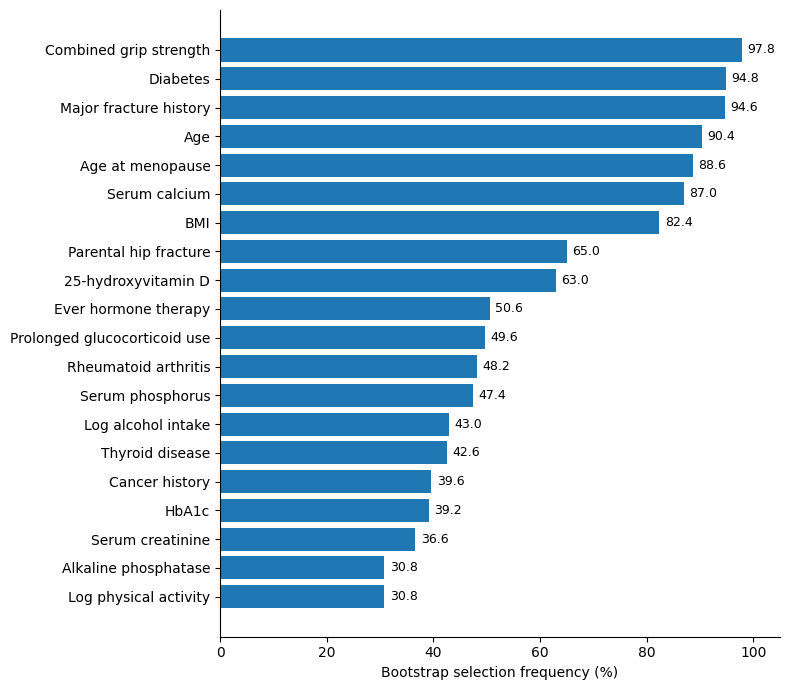


Figure 5 saved:
/content/Figure5_corrected_bootstrap_stability.png
/content/Figure5_corrected_bootstrap_stability.svg

Figure 5 data:
                       Label  Bootstrap_selection_frequency
      Combined grip strength                          0.978
                    Diabetes                          0.948
      Major fracture history                          0.946
                         Age                          0.904
            Age at menopause                          0.886
               Serum calcium                          0.870
                         BMI                          0.824
       Parental hip fracture                          0.650
         25-hydroxyvitamin D                          0.630
        Ever hormone therapy                          0.506
Prolonged glucocorticoid use                          0.496
        Rheumatoid arthritis                          0.482
            Serum phosphorus                          0.474
          Log alcohol int

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

# User-friendly labels
figure5_labels = {
    "combined_grip_kg": "Combined grip strength",
    "diabetes": "Diabetes",
    "major_fracture_history": "Major fracture history",
    "age_years": "Age",
    "menopause_age": "Age at menopause",
    "calcium_mg_dl": "Serum calcium",
    "bmi": "BMI",
    "parental_hip_fracture": "Parental hip fracture",
    "vitamin_d_nmol_l": "25-hydroxyvitamin D",
    "ever_hormone_therapy": "Ever hormone therapy",
    "glucocorticoid_history": "Prolonged glucocorticoid use",
    "rheumatoid_arthritis": "Rheumatoid arthritis",
    "phosphorus_mg_dl": "Serum phosphorus",
    "log_alcohol_week": "Log alcohol intake",
    "thyroid_problem": "Thyroid disease",
    "cancer_history": "Cancer history",
    "hba1c_pct": "HbA1c",
    "creatinine_mg_dl": "Serum creatinine",
    "alk_phos_u_l": "Alkaline phosphatase",
    "log_pa_met": "Log physical activity"
}

figure5_data = (
    corrected_bootstrap_stability
    .sort_values(
        "Bootstrap_selection_frequency",
        ascending=False
    )
    .head(20)
    .copy()
)

figure5_data["Label"] = (
    figure5_data["Feature"]
    .map(figure5_labels)
    .fillna(figure5_data["Feature"])
)

figure5_data["Percent"] = (
    figure5_data[
        "Bootstrap_selection_frequency"
    ] * 100
)

# Reverse for horizontal plotting
figure5_plot = (
    figure5_data
    .sort_values(
        "Percent",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

bars = ax.barh(
    figure5_plot["Label"],
    figure5_plot["Percent"]
)

ax.set_xlabel(
    "Bootstrap selection frequency (%)"
)

ax.set_ylabel("")

ax.set_xlim(0, 105)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    figure5_plot["Percent"]
):
    ax.text(
        value + 1,
        bar.get_y()
        + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

figure5_png = (
    "/content/"
    "Figure5_corrected_bootstrap_stability.png"
)

figure5_svg = (
    "/content/"
    "Figure5_corrected_bootstrap_stability.svg"
)

plt.savefig(
    figure5_png,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    figure5_svg,
    bbox_inches="tight"
)

plt.show()

print()
print("Figure 5 saved:")
print(figure5_png)
print(figure5_svg)

print()
print("Figure 5 data:")
print(
    figure5_data[
        [
            "Label",
            "Bootstrap_selection_frequency"
        ]
    ].to_string(
        index=False
    )
)

colab_files.download(
    figure5_png
)

colab_files.download(
    figure5_svg
)

In [ ]:
# Find prediction/model objects currently available in memory

candidate_names = []

for name in globals().keys():

    name_lower = name.lower()

    if any(
        term in name_lower
        for term in [
            "oof",
            "pred",
            "prediction",
            "clinical",
            "enhanced",
            "forest",
            "xgb",
            "age"
        ]
    ):
        candidate_names.append(name)

for name in sorted(candidate_names):
    try:
        obj = globals()[name]

        if isinstance(
            obj,
            (
                pd.DataFrame,
                pd.Series,
                np.ndarray,
                list,
                dict
            )
        ):
            print(
                name,
                "|",
                type(obj).__name__,
                "|",
                (
                    getattr(obj, "shape", None)
                    if not isinstance(obj, dict)
                    else "keys=" + str(
                        list(obj.keys())[:10]
                    )
                )
            )

    except Exception:
        pass

RuntimeError: dictionary changed size during iteration

In [ ]:
# Find prediction/model objects currently available in memory

candidate_names = []

all_global_names = list(
    globals().keys()
)

for name in all_global_names:

    name_lower = name.lower()

    if any(
        term in name_lower
        for term in [
            "oof",
            "pred",
            "prediction",
            "clinical",
            "enhanced",
            "forest",
            "xgb",
            "age"
        ]
    ):
        candidate_names.append(name)

for name in sorted(candidate_names):

    try:
        obj = globals()[name]

        if isinstance(
            obj,
            (
                pd.DataFrame,
                pd.Series,
                np.ndarray,
                list,
                dict
            )
        ):

            if isinstance(obj, dict):

                description = (
                    "keys="
                    + str(
                        list(obj.keys())[:10]
                    )
                )

            else:

                description = str(
                    getattr(
                        obj,
                        "shape",
                        None
                    )
                )

            print(
                name,
                "|",
                type(obj).__name__,
                "|",
                description
            )

    except Exception:
        pass

X_clinical_lasso | DataFrame | (309, 18)
X_enhanced_lasso | DataFrame | (309, 25)
age_only_screening_audit | dict | keys=['Sensitivity', 'Specificity', 'PPV', 'NPV', 'Referral_rate', 'False_negative_rate', 'DXAs_per_case']
age_only_screening_audit_atleast90 | dict | keys=['Sensitivity', 'Specificity', 'PPV', 'NPV', 'Referral_rate', 'False_negative_rate', 'DXAs_per_case']
age_only_screening_audit_unweighted | dict | keys=['Sensitivity', 'Specificity', 'PPV', 'NPV', 'Referral_rate', 'False_negative_rate', 'DXAs_per_case']
clinical_C_counts | Series | (3,)
clinical_C_values | list | None
clinical_all_thresholds | list | None
clinical_auc_boot | ndarray | (2000,)
clinical_b | ndarray | (309,)
clinical_brier_boot | ndarray | (2000,)
clinical_class_repeated | ndarray | (3090,)
clinical_corr_all_oof | dict | keys=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
clinical_corr_all_results | list | None
clinical_corr_rep10_oof | ndarray | (309,)
clinical_corr_rep10_results | dict | keys=['repetition', 'AUROC', '

In [ ]:
# Inspect model-related functions still available in the runtime

function_names = []

for name in list(globals().keys()):

    try:
        obj = globals()[name]

        if callable(obj):

            name_lower = name.lower()

            if any(
                term in name_lower
                for term in [
                    "age",
                    "clinical",
                    "logistic",
                    "forest",
                    "rf",
                    "xgb",
                    "boost",
                    "model",
                    "repetition",
                    "oof",
                    "enhanced"
                ]
            ):
                function_names.append(name)

    except Exception:
        pass


print("MODEL-RELATED FUNCTIONS STILL IN MEMORY:")
print()

for name in sorted(set(function_names)):
    print(name)

MODEL-RELATED FUNCTIONS STILL IN MEMORY:

LogisticRegression
build_clinical_lasso_design
build_enhanced_lasso_design
evaluate_clinical_lasso_C_3imp
evaluate_full_cohort_enhanced_grid
fit_full_enhanced_lasso_20_imputations
fit_full_enhanced_lasso_seedset
full_enhanced_lasso_apparent_predictions
get_clinical_inner_oof_predictions
get_enhanced_inner_oof_predictions
impute_clinical_categorical
impute_clinical_continuous
impute_enhanced_categorical
impute_enhanced_continuous
run_age_only_screening_audit
run_clinical_lasso_outer_fold
run_clinical_lasso_repetition
run_clinical_screening_repetition
run_enhanced_lasso_bootstrap
run_enhanced_screening_repetition


In [ ]:
import inspect

print(
    inspect.getsource(
        run_age_only_screening_audit
    )
)

def run_age_only_screening_audit():

    all_classifications = {}
    all_thresholds = []

    for repetition in range(1, 11):

        outer_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        outer_splits = list(
            outer_cv.split(
                df[["age_years"]],
                y,
                groups=groups
            )
        )

        repetition_classification = np.full(
            len(df),
            np.nan
        )

        for outer_fold_number, (train_idx, val_idx) in enumerate(
            outer_splits,
            start=1
        ):

            X_train = df[["age_years"]].iloc[train_idx].copy()
            X_val = df[["age_years"]].iloc[val_idx].copy()

            y_train = y.iloc[train_idx]
            w_train = model_weights.iloc[train_idx]
            inner_groups = groups.iloc[train_idx]

            # Inner OOF predictions
            inner_seed = repetition * 100 + ou

In [ ]:
def run_age_only_oof_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    oof_pred = np.full(
        len(df),
        np.nan
    )

    X_age = df[["age_years"]].copy()

    for outer_fold, (train_idx, val_idx) in enumerate(
        outer_cv.split(
            X_age,
            y,
            groups=groups
        ),
        start=1
    ):

        X_train = X_age.iloc[train_idx]
        X_val = X_age.iloc[val_idx]

        y_train = y.iloc[train_idx]

        w_train = model_weights.iloc[train_idx]

        scaler = StandardScaler()

        X_outer_train = scaler.fit_transform(
            X_train
        )

        X_outer_val = scaler.transform(
            X_val
        )

        outer_model = LogisticRegression(
            penalty=None,
            solver="lbfgs",
            max_iter=5000
        )

        outer_model.fit(
            X_outer_train,
            y_train,
            sample_weight=w_train
        )

        outer_pred = outer_model.predict_proba(
            X_outer_val
        )[:, 1]

        oof_pred[val_idx] = outer_pred

    return oof_pred


age_only_oof = {}

for repetition in range(1, 11):

    age_only_oof[repetition] = (
        run_age_only_oof_repetition(
            repetition
        )
    )


age_only_oof_matrix = np.column_stack([
    age_only_oof[r]
    for r in range(1, 11)
])

age_only_mean_oof = np.mean(
    age_only_oof_matrix,
    axis=1
)


age_only_metrics = apparent_metrics(
    y,
    age_only_mean_oof,
    model_weights
)


print("AGE-ONLY PARTICIPANT-LEVEL MEAN OOF")
print()

for key, value in age_only_metrics.items():
    print(key, "=", value)

print()
print(
    "Mean predicted risk =",
    np.average(
        age_only_mean_oof,
        weights=model_weights
    )
)

print()
print("MANUSCRIPT TARGETS")
print("AUROC approximately 0.621")
print("Brier approximately 0.240")
print("Calibration intercept approximately 0.002")
print("Calibration slope approximately 0.816")

AGE-ONLY PARTICIPANT-LEVEL MEAN OOF

AUROC = 0.6128907173558257
Brier = 0.24172707824265036
Calibration_intercept = 0.006856472291806359
Calibration_slope = 0.7588849842109735

Mean predicted risk = 0.5052201025974219

MANUSCRIPT TARGETS
AUROC approximately 0.621
Brier approximately 0.240
Calibration intercept approximately 0.002
Calibration slope approximately 0.816


In [ ]:
age_only_rep_metrics = []

for repetition in range(1, 11):

    pred = age_only_oof[repetition]

    metrics = apparent_metrics(
        y,
        pred,
        model_weights
    )

    age_only_rep_metrics.append({
        "repetition": repetition,
        "AUROC": metrics["AUROC"],
        "Brier": metrics["Brier"],
        "Calibration_intercept":
            metrics["Calibration_intercept"],
        "Calibration_slope":
            metrics["Calibration_slope"]
    })


age_only_rep_metrics = pd.DataFrame(
    age_only_rep_metrics
)

print("AGE-ONLY METRICS BY REPETITION")
print()
print(
    age_only_rep_metrics.to_string(
        index=False
    )
)

print()
print("=" * 60)
print("MEAN ACROSS 10 REPETITIONS")
print("=" * 60)

print(
    age_only_rep_metrics[
        [
            "AUROC",
            "Brier",
            "Calibration_intercept",
            "Calibration_slope"
        ]
    ].mean()
)

print()
print("WORKBOOK TARGETS")
print("AUROC = 0.6207358545721436")
print("Brier = 0.23994607856174024")
print("Calibration intercept = 0.0016572533841749258")
print("Calibration slope = 0.8164940642469322")

AGE-ONLY METRICS BY REPETITION

 repetition    AUROC    Brier  Calibration_intercept  Calibration_slope
          1 0.618008 0.241735              -0.001541           0.743683
          2 0.621717 0.239459               0.001032           0.845397
          3 0.606909 0.245500               0.006575           0.593326
          4 0.615935 0.241038               0.005057           0.793203
          5 0.626012 0.238169               0.007336           0.896457
          6 0.600048 0.244772               0.003223           0.658102
          7 0.600251 0.245165               0.021519           0.619284
          8 0.607849 0.242485               0.027971           0.701920
          9 0.629029 0.238022               0.005804           0.897684
         10 0.594246 0.246265              -0.003864           0.577522

MEAN ACROSS 10 REPETITIONS
AUROC                    0.612000
Brier                    0.242261
Calibration_intercept    0.007311
Calibration_slope        0.732658
dtype: float

In [ ]:
import inspect

src = inspect.getsource(
    run_age_only_screening_audit
)

lines = src.splitlines()

for i, line in enumerate(lines, start=1):

    if (
        i <= 90
        or "StratifiedGroupKFold" in line
        or "random_state" in line
        or "outer_cv" in line
        or "split(" in line
    ):
        print(
            f"{i:03d}: {line}"
        )

001: def run_age_only_screening_audit():
002: 
003:     all_classifications = {}
004:     all_thresholds = []
005: 
006:     for repetition in range(1, 11):
007: 
008:         outer_cv = StratifiedGroupKFold(
009:             n_splits=5,
010:             shuffle=True,
011:             random_state=repetition
012:         )
013: 
014:         outer_splits = list(
015:             outer_cv.split(
016:                 df[["age_years"]],
017:                 y,
018:                 groups=groups
019:             )
020:         )
021: 
022:         repetition_classification = np.full(
023:             len(df),
024:             np.nan
025:         )
026: 
027:         for outer_fold_number, (train_idx, val_idx) in enumerate(
028:             outer_splits,
029:             start=1
030:         ):
031: 
032:             X_train = df[["age_years"]].iloc[train_idx].copy()
033:             X_val = df[["age_years"]].iloc[val_idx].copy()
034: 
035:             y_train = y.iloc[train_idx]
036:      

In [ ]:
import inspect

src = inspect.getsource(
    run_clinical_lasso_repetition
)

lines = src.splitlines()

for i, line in enumerate(
    lines,
    start=1
):
    if (
        i <= 70
        or "StratifiedGroupKFold" in line
        or "random_state" in line
        or "outer_cv" in line
        or "outer_splits" in line
        or ".split(" in line
    ):
        print(
            f"{i:03d}: {line}"
        )

001: def run_clinical_lasso_repetition(repetition):
002: 
003:     outer_cv = StratifiedGroupKFold(
004:         n_splits=5,
005:         shuffle=True,
006:         random_state=repetition
007:     )
008: 
009:     outer_splits = list(
010:         outer_cv.split(
011:             X_clinical_lasso,
012:             y,
013:             groups=groups
014:         )
015:     )
016: 
017:     oof_predictions = np.full(
018:         len(df),
019:         np.nan
020:     )
021: 
022:     selected_C_values = []
023: 
024:     for outer_fold_number, (train_idx, val_idx) in enumerate(
025:         outer_splits,
026:         start=1
027:     ):
028: 
029:         result = run_clinical_lasso_outer_fold(
030:             train_idx=train_idx,
031:             val_idx=val_idx,
032:             repetition=repetition,
033:             outer_fold_number=outer_fold_number
034:         )
035: 
036:         oof_predictions[
037:             result["val_idx"]
038:         ] = result["predictions"]
039: 
04

In [ ]:
def run_age_only_oof_l2(normalize_train_weights=False):

    all_oof = {}

    for repetition in range(1, 11):

        outer_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        oof_pred = np.full(
            len(df),
            np.nan
        )

        for train_idx, val_idx in outer_cv.split(
            df[["age_years"]],
            y,
            groups=groups
        ):

            X_train = df[["age_years"]].iloc[train_idx]
            X_val = df[["age_years"]].iloc[val_idx]

            y_train = y.iloc[train_idx]

            w_train = model_weights.iloc[
                train_idx
            ].copy()

            if normalize_train_weights:
                w_train = (
                    w_train /
                    w_train.mean()
                )

            scaler = StandardScaler()

            X_train_scaled = (
                scaler.fit_transform(
                    X_train
                )
            )

            X_val_scaled = (
                scaler.transform(
                    X_val
                )
            )

            # sklearn default logistic regression:
            # L2 penalty, C=1, lbfgs
            model = LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="lbfgs",
                max_iter=5000
            )

            model.fit(
                X_train_scaled,
                y_train,
                sample_weight=w_train
            )

            oof_pred[val_idx] = (
                model.predict_proba(
                    X_val_scaled
                )[:, 1]
            )

        all_oof[repetition] = oof_pred

    matrix = np.column_stack([
        all_oof[r]
        for r in range(1, 11)
    ])

    mean_pred = np.mean(
        matrix,
        axis=1
    )

    metrics = apparent_metrics(
        y,
        mean_pred,
        model_weights
    )

    return (
        all_oof,
        matrix,
        mean_pred,
        metrics
    )


# Variant A:
# historical/global normalized weights
(
    age_l2_global_oof,
    age_l2_global_matrix,
    age_l2_global_mean,
    age_l2_global_metrics
) = run_age_only_oof_l2(
    normalize_train_weights=False
)


# Variant B:
# renormalize weights within each training fold
(
    age_l2_trainnorm_oof,
    age_l2_trainnorm_matrix,
    age_l2_trainnorm_mean,
    age_l2_trainnorm_metrics
) = run_age_only_oof_l2(
    normalize_train_weights=True
)


print("=" * 60)
print("DEFAULT L2 - GLOBAL MODEL WEIGHTS")
print("=" * 60)

for key, value in age_l2_global_metrics.items():
    print(key, "=", value)


print()
print("=" * 60)
print("DEFAULT L2 - TRAIN-FOLD NORMALIZED WEIGHTS")
print("=" * 60)

for key, value in age_l2_trainnorm_metrics.items():
    print(key, "=", value)


print()
print("=" * 60)
print("WORKBOOK TARGETS")
print("=" * 60)

print("AUROC = 0.6207358545721436")
print("Brier = 0.23994607856174024")
print("Calibration intercept = 0.0016572533841749258")
print("Calibration slope = 0.8164940642469322")

DEFAULT L2 - GLOBAL MODEL WEIGHTS
AUROC = 0.6126054677622677
Brier = 0.241650145094064
Calibration_intercept = 0.006714658386536264
Calibration_slope = 0.7735421016768003

DEFAULT L2 - TRAIN-FOLD NORMALIZED WEIGHTS
AUROC = 0.6129184186315695
Brier = 0.24165065514610304
Calibration_intercept = 0.006701815302008913
Calibration_slope = 0.7734257898598351

WORKBOOK TARGETS
AUROC = 0.6207358545721436
Brier = 0.23994607856174024
Calibration intercept = 0.0016572533841749258
Calibration slope = 0.8164940642469322


In [ ]:
def run_age_only_oof_fit_variant(
    use_fit_weights,
    penalty_type
):

    all_oof = {}

    for repetition in range(1, 11):

        outer_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        oof_pred = np.full(
            len(df),
            np.nan
        )

        for train_idx, val_idx in outer_cv.split(
            df[["age_years"]],
            y,
            groups=groups
        ):

            X_train = (
                df[["age_years"]]
                .iloc[train_idx]
            )

            X_val = (
                df[["age_years"]]
                .iloc[val_idx]
            )

            y_train = y.iloc[train_idx]

            scaler = StandardScaler()

            X_train_scaled = (
                scaler.fit_transform(
                    X_train
                )
            )

            X_val_scaled = (
                scaler.transform(
                    X_val
                )
            )

            if penalty_type == "none":

                model = LogisticRegression(
                    penalty=None,
                    solver="lbfgs",
                    max_iter=5000
                )

            else:

                model = LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="lbfgs",
                    max_iter=5000
                )

            if use_fit_weights:

                model.fit(
                    X_train_scaled,
                    y_train,
                    sample_weight=
                        model_weights.iloc[
                            train_idx
                        ]
                )

            else:

                model.fit(
                    X_train_scaled,
                    y_train
                )

            oof_pred[val_idx] = (
                model.predict_proba(
                    X_val_scaled
                )[:, 1]
            )

        all_oof[repetition] = oof_pred

    matrix = np.column_stack([
        all_oof[r]
        for r in range(1, 11)
    ])

    mean_pred = matrix.mean(axis=1)

    metrics = apparent_metrics(
        y,
        mean_pred,
        model_weights
    )

    return metrics, mean_pred


variants = [
    (
        "Weighted fit, no penalty",
        True,
        "none"
    ),
    (
        "Unweighted fit, no penalty",
        False,
        "none"
    ),
    (
        "Weighted fit, L2",
        True,
        "l2"
    ),
    (
        "Unweighted fit, L2",
        False,
        "l2"
    )
]


for label, use_weights, penalty in variants:

    metrics, pred = (
        run_age_only_oof_fit_variant(
            use_fit_weights=use_weights,
            penalty_type=penalty
        )
    )

    print("=" * 65)
    print(label)
    print("=" * 65)

    for key, value in metrics.items():
        print(
            key,
            "=",
            value
        )

    print(
        "Mean predicted risk =",
        np.average(
            pred,
            weights=model_weights
        )
    )

    print()


print("=" * 65)
print("WORKBOOK TARGETS")
print("=" * 65)

print(
    "AUROC = 0.6207358545721436"
)
print(
    "Brier = 0.23994607856174024"
)
print(
    "Calibration intercept = "
    "0.0016572533841749258"
)
print(
    "Calibration slope = "
    "0.8164940642469322"
)

Weighted fit, no penalty
AUROC = 0.6128907173558257
Brier = 0.24172707824265036
Calibration_intercept = 0.006856472291806359
Calibration_slope = 0.7588849842109735
Mean predicted risk = 0.5052201025974219

Unweighted fit, no penalty
AUROC = 0.620317056173769
Brier = 0.24034238476101788
Calibration_intercept = 0.07311116975195586
Calibration_slope = 0.7469671833747804
Mean predicted risk = 0.4846249184666057

Weighted fit, L2
AUROC = 0.6126054677622677
Brier = 0.241650145094064
Calibration_intercept = 0.006714658386536264
Calibration_slope = 0.7735421016768003
Mean predicted risk = 0.5051966728029482

Unweighted fit, L2
AUROC = 0.620149425197371
Brier = 0.240235193107174
Calibration_intercept = 0.07354979422980665
Calibration_slope = 0.7613429090492968
Mean predicted risk = 0.48476904079663496

WORKBOOK TARGETS
AUROC = 0.6207358545721436
Brier = 0.23994607856174024
Calibration intercept = 0.0016572533841749258
Calibration slope = 0.8164940642469322


In [ ]:
def run_age_only_with_seed_sequence(
    seed_start
):

    all_oof = {}

    for repetition in range(10):

        seed = seed_start + repetition

        outer_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        )

        oof_pred = np.full(
            len(df),
            np.nan
        )

        for train_idx, val_idx in outer_cv.split(
            df[["age_years"]],
            y,
            groups=groups
        ):

            X_train = (
                df[["age_years"]]
                .iloc[train_idx]
            )

            X_val = (
                df[["age_years"]]
                .iloc[val_idx]
            )

            y_train = y.iloc[train_idx]

            w_train = (
                model_weights
                .iloc[train_idx]
            )

            scaler = StandardScaler()

            X_train_scaled = (
                scaler.fit_transform(
                    X_train
                )
            )

            X_val_scaled = (
                scaler.transform(
                    X_val
                )
            )

            model = LogisticRegression(
                penalty=None,
                solver="lbfgs",
                max_iter=5000
            )

            model.fit(
                X_train_scaled,
                y_train,
                sample_weight=w_train
            )

            oof_pred[val_idx] = (
                model.predict_proba(
                    X_val_scaled
                )[:, 1]
            )

        all_oof[
            repetition + 1
        ] = oof_pred

    matrix = np.column_stack([
        all_oof[r]
        for r in range(1, 11)
    ])

    mean_pred = matrix.mean(
        axis=1
    )

    metrics = apparent_metrics(
        y,
        mean_pred,
        model_weights
    )

    return (
        all_oof,
        matrix,
        mean_pred,
        metrics
    )


(
    age_projectseed_oof,
    age_projectseed_matrix,
    age_projectseed_mean,
    age_projectseed_metrics
) = run_age_only_with_seed_sequence(
    20260729
)


print("=" * 65)
print(
    "AGE ONLY - SEEDS "
    "20260729 TO 20260738"
)
print("=" * 65)

for key, value in (
    age_projectseed_metrics.items()
):
    print(
        key,
        "=",
        value
    )

print(
    "Mean predicted risk =",
    np.average(
        age_projectseed_mean,
        weights=model_weights
    )
)

print()
print("=" * 65)
print("WORKBOOK TARGETS")
print("=" * 65)

print(
    "AUROC = 0.6207358545721436"
)
print(
    "Brier = 0.23994607856174024"
)
print(
    "Calibration intercept = "
    "0.0016572533841749258"
)
print(
    "Calibration slope = "
    "0.8164940642469322"
)

AGE ONLY - SEEDS 20260729 TO 20260738
AUROC = 0.6171676874831451
Brier = 0.24127656708940848
Calibration_intercept = -0.00012467246207134404
Calibration_slope = 0.7715771541231029
Mean predicted risk = 0.5072661229747173

WORKBOOK TARGETS
AUROC = 0.6207358545721436
Brier = 0.23994607856174024
Calibration intercept = 0.0016572533841749258
Calibration slope = 0.8164940642469322


In [ ]:
hidden_prediction_candidates = []

for name in list(globals().keys()):

    try:
        obj = globals()[name]

        arr = None

        if isinstance(
            obj,
            (
                np.ndarray,
                pd.Series,
                pd.DataFrame
            )
        ):
            arr = np.asarray(obj)

        if arr is None:
            continue

        # Candidate participant-level prediction vector
        if arr.shape == (309,):

            if np.issubdtype(
                arr.dtype,
                np.number
            ):

                finite = arr[
                    np.isfinite(arr)
                ]

                if (
                    len(finite) > 0
                    and finite.min() >= 0
                    and finite.max() <= 1
                ):

                    hidden_prediction_candidates.append({
                        "name": name,
                        "shape": arr.shape,
                        "min": float(finite.min()),
                        "max": float(finite.max()),
                        "mean": float(finite.mean()),
                        "unique": int(
                            len(
                                np.unique(
                                    np.round(
                                        finite,
                                        10
                                    )
                                )
                            )
                        )
                    })

        # Candidate repeated OOF matrix
        elif arr.shape == (309, 10):

            if np.issubdtype(
                arr.dtype,
                np.number
            ):

                finite = arr[
                    np.isfinite(arr)
                ]

                if (
                    len(finite) > 0
                    and finite.min() >= 0
                    and finite.max() <= 1
                ):

                    hidden_prediction_candidates.append({
                        "name": name,
                        "shape": arr.shape,
                        "min": float(finite.min()),
                        "max": float(finite.max()),
                        "mean": float(finite.mean()),
                        "unique": int(
                            len(
                                np.unique(
                                    np.round(
                                        finite,
                                        10
                                    )
                                )
                            )
                        )
                    })

    except Exception:
        pass


candidate_df = pd.DataFrame(
    hidden_prediction_candidates
)

if len(candidate_df) == 0:

    print(
        "No probability-like "
        "309-row objects found."
    )

else:

    print(
        candidate_df
        .sort_values("name")
        .to_string(index=False)
    )

                    name     shape      min      max     mean  unique
    age_l2_global_matrix (309, 10) 0.183147 0.823183 0.512609    1380
      age_l2_global_mean    (309,) 0.236251 0.759922 0.512609     263
 age_l2_trainnorm_matrix (309, 10) 0.183278 0.823412 0.512611    1380
   age_l2_trainnorm_mean    (309,) 0.236207 0.760087 0.512611     263
       age_only_mean_oof    (309,) 0.232179 0.764310 0.512759     263
     age_only_oof_matrix (309, 10) 0.178232 0.828004 0.512759    1380
  age_projectseed_matrix (309, 10) 0.182853 0.807781 0.515119    1399
    age_projectseed_mean    (309,) 0.222142 0.769351 0.515119     263
              clinical_b    (309,) 0.186068 0.871042 0.502299     196
 clinical_corr_rep10_oof    (309,) 0.050644 0.903450 0.499040     309
  clinical_corr_rep1_oof    (309,) 0.101619 0.959897 0.494681     309
  clinical_corr_rep2_oof    (309,) 0.141130 0.938737 0.504331     309
  clinical_corr_rep3_oof    (309,) 0.135817 0.930669 0.494807     309
  clinical_corr_rep4

In [ ]:
# Check whether any probability vector already in memory
# reproduces the historical Age-only performance.

age_target = {
    "AUROC": 0.6207358545721436,
    "Brier": 0.23994607856174024,
    "Calibration_intercept": 0.0016572533841749258,
    "Calibration_slope": 0.8164940642469322
}

candidate_results = []

for name in list(globals().keys()):

    try:
        obj = globals()[name]

        if isinstance(
            obj,
            (np.ndarray, pd.Series)
        ):
            arr = np.asarray(obj).reshape(-1)

            if arr.shape != (309,):
                continue

            if not np.issubdtype(
                arr.dtype,
                np.number
            ):
                continue

            if not np.all(
                np.isfinite(arr)
            ):
                continue

            if (
                arr.min() < 0
                or arr.max() > 1
            ):
                continue

            # Skip binary outcome/classification vectors
            if len(
                np.unique(
                    np.round(arr, 10)
                )
            ) <= 2:
                continue

            metrics = apparent_metrics(
                y,
                arr,
                model_weights
            )

            # Simple standardized closeness score
            # only for ranking possible historical matches
            distance = (
                abs(
                    metrics["AUROC"]
                    - age_target["AUROC"]
                )
                +
                abs(
                    metrics["Brier"]
                    - age_target["Brier"]
                )
                +
                abs(
                    metrics["Calibration_intercept"]
                    - age_target["Calibration_intercept"]
                )
                +
                abs(
                    metrics["Calibration_slope"]
                    - age_target["Calibration_slope"]
                )
            )

            candidate_results.append({
                "name": name,
                "AUROC":
                    metrics["AUROC"],
                "Brier":
                    metrics["Brier"],
                "Calibration_intercept":
                    metrics["Calibration_intercept"],
                "Calibration_slope":
                    metrics["Calibration_slope"],
                "distance_from_age_target":
                    distance
            })

    except Exception:
        pass


candidate_metric_table = (
    pd.DataFrame(candidate_results)
    .sort_values(
        "distance_from_age_target"
    )
    .reset_index(drop=True)
)

print(
    candidate_metric_table.head(20)
    .to_string(index=False)
)

print()
print("AGE-ONLY WORKBOOK TARGET")
print(age_target)

                   name    AUROC    Brier  Calibration_intercept  Calibration_slope  distance_from_age_target
                    arr 0.617168 0.241277              -0.000125           0.771577                  0.051597
                 finite 0.617168 0.241277              -0.000125           0.771577                  0.051597
   age_projectseed_mean 0.617168 0.241277              -0.000125           0.771577                  0.051597
  age_l2_trainnorm_mean 0.612918 0.241651               0.006702           0.773426                  0.057635
     age_l2_global_mean 0.612605 0.241650               0.006715           0.773542                  0.057844
      age_only_mean_oof 0.612891 0.241727               0.006856           0.758885                  0.072434
 clinical_corr_rep3_oof 0.645975 0.233517               0.023174           0.879487                  0.116177
                   pred 0.620149 0.240235               0.073550           0.761343                  0.127919
 clinical_

In [ ]:
# Test pooled repeated OOF predictions:
# 309 participants x 10 repetitions = 3,090 predictions

age_only_repeated_pred = (
    age_only_oof_matrix
    .T
    .reshape(-1)
)

age_only_repeated_y = np.tile(
    y.to_numpy(),
    10
)

age_only_repeated_weights = np.tile(
    model_weights.to_numpy(),
    10
)

age_only_pooled_metrics = apparent_metrics(
    pd.Series(age_only_repeated_y),
    age_only_repeated_pred,
    pd.Series(age_only_repeated_weights)
)

print("=" * 65)
print("AGE ONLY - POOLED 3,090 HELD-OUT PREDICTIONS")
print("=" * 65)

for key, value in age_only_pooled_metrics.items():
    print(key, "=", value)

print()
print(
    "Mean predicted risk =",
    np.average(
        age_only_repeated_pred,
        weights=age_only_repeated_weights
    )
)

print()
print("=" * 65)
print("WORKBOOK TARGETS")
print("=" * 65)

print("AUROC = 0.6207358545721436")
print("Brier = 0.23994607856174024")
print(
    "Calibration intercept = "
    "0.0016572533841749258"
)
print(
    "Calibration slope = "
    "0.8164940642469322"
)

AGE ONLY - POOLED 3,090 HELD-OUT PREDICTIONS
AUROC = 0.6115929071846925
Brier = 0.24226115055168476
Calibration_intercept = 0.007203867583913019
Calibration_slope = 0.7270660918990236

Mean predicted risk = 0.5052201025974219

WORKBOOK TARGETS
AUROC = 0.6207358545721436
Brier = 0.23994607856174024
Calibration intercept = 0.0016572533841749258
Calibration slope = 0.8164940642469322


In [ ]:
import sklearn
import numpy as np
import pandas as pd
import scipy
import statsmodels

print("CURRENT COLAB SOFTWARE VERSIONS")
print()

print(
    "Python:",
    __import__("sys").version
)

print(
    "scikit-learn:",
    sklearn.__version__
)

print(
    "NumPy:",
    np.__version__
)

print(
    "pandas:",
    pd.__version__
)

print(
    "SciPy:",
    scipy.__version__
)

print(
    "statsmodels:",
    statsmodels.__version__
)

print()
print("MANUSCRIPT-RECORDED VERSION")
print("scikit-learn: 1.8.0")

CURRENT COLAB SOFTWARE VERSIONS

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1
NumPy: 2.1.3
pandas: 2.2.3
SciPy: 1.16.3
statsmodels: 0.15.0

MANUSCRIPT-RECORDED VERSION
scikit-learn: 1.8.0


In [ ]:
def run_age_bmi_oof_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    oof_pred = np.full(
        len(df),
        np.nan
    )

    X_age_bmi = df[
        [
            "age_years",
            "bmi"
        ]
    ].copy()

    for train_idx, val_idx in outer_cv.split(
        X_age_bmi,
        y,
        groups=groups
    ):

        X_train = X_age_bmi.iloc[
            train_idx
        ]

        X_val = X_age_bmi.iloc[
            val_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        w_train = model_weights.iloc[
            train_idx
        ]

        scaler = StandardScaler()

        X_train_scaled = (
            scaler.fit_transform(
                X_train
            )
        )

        X_val_scaled = (
            scaler.transform(
                X_val
            )
        )

        model = LogisticRegression(
            penalty=None,
            solver="lbfgs",
            max_iter=5000
        )

        model.fit(
            X_train_scaled,
            y_train,
            sample_weight=w_train
        )

        oof_pred[val_idx] = (
            model.predict_proba(
                X_val_scaled
            )[:, 1]
        )

    return oof_pred


age_bmi_oof = {}

for repetition in range(1, 11):

    age_bmi_oof[repetition] = (
        run_age_bmi_oof_repetition(
            repetition
        )
    )


age_bmi_oof_matrix = np.column_stack([
    age_bmi_oof[r]
    for r in range(1, 11)
])

age_bmi_mean_oof = np.mean(
    age_bmi_oof_matrix,
    axis=1
)


age_bmi_metrics = apparent_metrics(
    y,
    age_bmi_mean_oof,
    model_weights
)


print(
    "AGE + BMI - CURRENT "
    "AUDITED ENVIRONMENT"
)

print()

for key, value in (
    age_bmi_metrics.items()
):
    print(
        key,
        "=",
        value
    )

print()

print(
    "Mean predicted risk =",
    np.average(
        age_bmi_mean_oof,
        weights=model_weights
    )
)

print()

print(
    "Historical workbook:"
)
print(
    "AUROC = 0.6309605948169416"
)
print(
    "Brier = 0.23793361496746976"
)
print(
    "Calibration intercept = "
    "-0.0008035613414076235"
)
print(
    "Calibration slope = "
    "0.7606606467132171"
)

AGE + BMI - CURRENT AUDITED ENVIRONMENT

AUROC = 0.6274105058233143
Brier = 0.23963155230370073
Calibration_intercept = 0.0050498513802043786
Calibration_slope = 0.7182382264514213

Mean predicted risk = 0.5061578586257

Historical workbook:
AUROC = 0.6309605948169416
Brier = 0.23793361496746976
Calibration intercept = -0.0008035613414076235
Calibration slope = 0.7606606467132171


In [ ]:
import inspect

src = inspect.getsource(
    run_clinical_lasso_outer_fold
)

lines = src.splitlines()

for i, line in enumerate(
    lines,
    start=1
):
    print(
        f"{i:03d}: {line}"
    )

001: def run_clinical_lasso_outer_fold(
002:     train_idx,
003:     val_idx,
004:     repetition,
005:     outer_fold_number
006: ):
007: 
008:     X_train = X_clinical_lasso.iloc[train_idx].copy()
009:     X_val = X_clinical_lasso.iloc[val_idx].copy()
010: 
011:     y_train = y.iloc[train_idx]
012:     y_val = y.iloc[val_idx]
013: 
014:     w_train = model_weights.iloc[train_idx]
015:     w_val = model_weights.iloc[val_idx]
016: 
017:     inner_groups = groups.iloc[train_idx]
018: 
019:     inner_seed = repetition * 100 + outer_fold_number
020: 
021:     inner_cv = StratifiedGroupKFold(
022:         n_splits=5,
023:         shuffle=True,
024:         random_state=inner_seed
025:     )
026: 
027:     inner_splits = list(
028:         inner_cv.split(
029:             X_train,
030:             y_train,
031:             groups=inner_groups
032:         )
033:     )
034: 
035:     all_inner_losses = []
036: 
037:     for inner_train_idx, inner_val_idx in inner_splits:
038: 
039:         X

In [ ]:
def run_clinical_logistic_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_clinical_lasso,
            y,
            groups=groups
        )
    )

    oof_predictions = np.full(
        len(df),
        np.nan
    )

    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            X_clinical_lasso
            .iloc[train_idx]
            .copy()
        )

        X_val = (
            X_clinical_lasso
            .iloc[val_idx]
            .copy()
        )

        y_train = y.iloc[
            train_idx
        ]

        w_train = model_weights.iloc[
            train_idx
        ]

        outer_predictions = []

        for seed in [1, 2, 3]:

            train_cont, val_cont = (
                impute_clinical_continuous(
                    X_train,
                    X_val,
                    seed=seed
                )
            )

            train_cat, val_cat = (
                impute_clinical_categorical(
                    X_train,
                    X_val,
                    w_train,
                    seed=seed
                )
            )

            train_final, val_final = (
                build_clinical_lasso_design(
                    train_cont,
                    val_cont,
                    train_cat,
                    val_cat
                )
            )

            model = LogisticRegression(
                penalty=None,
                solver="lbfgs",
                fit_intercept=True,
                max_iter=5000
            )

            model.fit(
                train_final,
                y_train,
                sample_weight=w_train
            )

            pred = model.predict_proba(
                val_final
            )[:, 1]

            outer_predictions.append(
                pred
            )

        mean_pred = np.mean(
            outer_predictions,
            axis=0
        )

        oof_predictions[
            val_idx
        ] = mean_pred

    if np.isnan(
        oof_predictions
    ).any():

        raise ValueError(
            "Some participants are missing "
            "clinical logistic OOF predictions."
        )

    return oof_predictions


clinical_logistic_oof = {}

for repetition in range(1, 11):

    print(
        "Running repetition",
        repetition
    )

    clinical_logistic_oof[
        repetition
    ] = run_clinical_logistic_repetition(
        repetition
    )


clinical_logistic_oof_matrix = (
    np.column_stack([
        clinical_logistic_oof[r]
        for r in range(1, 11)
    ])
)

clinical_logistic_mean_oof = (
    clinical_logistic_oof_matrix.mean(
        axis=1
    )
)


clinical_logistic_metrics = apparent_metrics(
    y,
    clinical_logistic_mean_oof,
    model_weights
)


print()
print("=" * 65)
print(
    "CLINICAL LOGISTIC - "
    "CURRENT AUDITED ENVIRONMENT"
)
print("=" * 65)

for key, value in (
    clinical_logistic_metrics.items()
):
    print(
        key,
        "=",
        value
    )

print()

print(
    "Mean predicted risk =",
    np.average(
        clinical_logistic_mean_oof,
        weights=model_weights
    )
)

print()
print("=" * 65)
print("HISTORICAL WORKBOOK")
print("=" * 65)

print(
    "AUROC approximately 0.703"
)
print(
    "Brier approximately 0.225"
)
print(
    "Calibration intercept "
    "approximately 0.024"
)
print(
    "Calibration slope "
    "approximately 0.594"
)

Running repetition 1
Running repetition 2
Running repetition 3
Running repetition 4
Running repetition 5
Running repetition 6
Running repetition 7
Running repetition 8
Running repetition 9
Running repetition 10

CLINICAL LOGISTIC - CURRENT AUDITED ENVIRONMENT
AUROC = 0.685644459457164
Brier = 0.23365562965894426
Calibration_intercept = 0.016134751873691833
Calibration_slope = 0.514226853209127

Mean predicted risk = 0.5004974863369798

HISTORICAL WORKBOOK
AUROC approximately 0.703
Brier approximately 0.225
Calibration intercept approximately 0.024
Calibration slope approximately 0.594


In [ ]:
keywords = [
    "RandomForestClassifier",
    "XGBClassifier",
    "random_forest",
    "xgboost",
    "Enhanced random forest",
    "Enhanced XGBoost"
]

matches = []

for i, cell in enumerate(In):

    if any(
        key.lower() in cell.lower()
        for key in keywords
    ):

        matches.append(
            (i, cell)
        )


print(
    "MATCHING COLAB HISTORY CELLS:",
    len(matches)
)

print()

for i, cell in matches:

    print("=" * 80)
    print("CELL", i)
    print("=" * 80)

    # Print enough to identify the relevant implementation
    print(
        cell[:2500]
    )

    if len(cell) > 2500:
        print(
            "\n... [truncated]"
        )

    print()

MATCHING COLAB HISTORY CELLS: 1

CELL 101
keywords = [
    "RandomForestClassifier",
    "XGBClassifier",
    "random_forest",
    "xgboost",
    "Enhanced random forest",
    "Enhanced XGBoost"
]

matches = []

for i, cell in enumerate(In):

    if any(
        key.lower() in cell.lower()
        for key in keywords
    ):

        matches.append(
            (i, cell)
        )


print(
    "MATCHING COLAB HISTORY CELLS:",
    len(matches)
)

print()

for i, cell in matches:

    print("=" * 80)
    print("CELL", i)
    print("=" * 80)

    # Print enough to identify the relevant implementation
    print(
        cell[:2500]
    )

    if len(cell) > 2500:
        print(
            "\n... [truncated]"
        )

    print()



In [ ]:
import inspect

for fn in [
    impute_enhanced_continuous,
    impute_enhanced_categorical,
    build_enhanced_lasso_design
]:

    print("=" * 80)
    print(fn.__name__)
    print("=" * 80)

    print(
        inspect.getsource(
            fn
        )
    )

    print()

impute_enhanced_continuous
def impute_enhanced_continuous(
    X_train,
    X_val,
    seed
):
    train_min = (
        X_train[enhanced_lasso_continuous]
        .min()
        .to_numpy()
    )

    train_max = (
        X_train[enhanced_lasso_continuous]
        .max()
        .to_numpy()
    )

    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        sample_posterior=True,
        max_iter=10,
        min_value=train_min,
        max_value=train_max,
        random_state=seed
    )

    imputer.fit(
        X_train[enhanced_lasso_continuous]
    )

    train_cont = pd.DataFrame(
        imputer.transform(
            X_train[enhanced_lasso_continuous]
        ),
        columns=enhanced_lasso_continuous,
        index=X_train.index
    )

    val_cont = pd.DataFrame(
        imputer.transform(
            X_val[enhanced_lasso_continuous]
        ),
        columns=enhanced_lasso_continuous,
        index=X_val.index
    )

    return train_cont, val_cont


impute

In [ ]:
def build_enhanced_tree_design(
    train_cont,
    val_cont,
    train_cat,
    val_cat
):

    # Continuous + binary variables remain
    # on their original numerical scales.
    train_numeric = pd.concat(
        [
            train_cont,
            train_cat[
                enhanced_lasso_binary_model
            ]
        ],
        axis=1
    )

    val_numeric = pd.concat(
        [
            val_cont,
            val_cat[
                enhanced_lasso_binary_model
            ]
        ],
        axis=1
    )

    # Multi-level categorical variables
    # are one-hot encoded exactly as in
    # the enhanced LASSO design.
    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    train_encoded = pd.DataFrame(
        encoder.fit_transform(
            train_cat[
                enhanced_lasso_multilevel
            ]
        ),
        columns=encoder.get_feature_names_out(
            enhanced_lasso_multilevel
        ),
        index=train_cat.index
    )

    val_encoded = pd.DataFrame(
        encoder.transform(
            val_cat[
                enhanced_lasso_multilevel
            ]
        ),
        columns=encoder.get_feature_names_out(
            enhanced_lasso_multilevel
        ),
        index=val_cat.index
    )

    train_final = pd.concat(
        [
            train_numeric,
            train_encoded
        ],
        axis=1
    )

    val_final = pd.concat(
        [
            val_numeric,
            val_encoded
        ],
        axis=1
    )

    return (
        train_final,
        val_final
    )


# Diagnostic check:
# repetition 1, outer fold 1, imputation seed 1

outer_cv_check = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

train_idx_check, val_idx_check = next(
    outer_cv_check.split(
        X_enhanced_lasso,
        y,
        groups=groups
    )
)

X_train_check = (
    X_enhanced_lasso
    .iloc[train_idx_check]
    .copy()
)

X_val_check = (
    X_enhanced_lasso
    .iloc[val_idx_check]
    .copy()
)

w_train_check = (
    model_weights
    .iloc[train_idx_check]
)

train_cont_check, val_cont_check = (
    impute_enhanced_continuous(
        X_train_check,
        X_val_check,
        seed=1
    )
)

train_cat_check, val_cat_check = (
    impute_enhanced_categorical(
        X_train_check,
        X_val_check,
        w_train_check,
        seed=1
    )
)

tree_train_check, tree_val_check = (
    build_enhanced_tree_design(
        train_cont_check,
        val_cont_check,
        train_cat_check,
        val_cat_check
    )
)


print(
    "TRAIN SHAPE =",
    tree_train_check.shape
)

print(
    "VALIDATION SHAPE =",
    tree_val_check.shape
)

print(
    "TRAIN MISSING VALUES =",
    int(
        tree_train_check
        .isna()
        .sum()
        .sum()
    )
)

print(
    "VALIDATION MISSING VALUES =",
    int(
        tree_val_check
        .isna()
        .sum()
        .sum()
    )
)

print()
print("TREE DESIGN COLUMNS:")

for i, column in enumerate(
    tree_train_check.columns
):
    print(
        i,
        column
    )

TRAIN SHAPE = (245, 30)
VALIDATION SHAPE = (64, 30)
TRAIN MISSING VALUES = 0
VALIDATION MISSING VALUES = 0

TREE DESIGN COLUMNS:
0 age_years
1 bmi
2 waist_cm
3 menopause_age
4 combined_grip_kg
5 log_alcohol_week
6 log_pa_met
7 vitamin_d_nmol_l
8 albumin_g_dl
9 alk_phos_u_l
10 calcium_mg_dl
11 creatinine_mg_dl
12 phosphorus_mg_dl
13 hba1c_pct
14 ever_hormone_therapy
15 major_fracture_history
16 parental_hip_fracture
17 glucocorticoid_history
18 diabetes
19 rheumatoid_arthritis
20 thyroid_problem
21 cancer_history
22 menopause_surgical
23 race_ethnicity_Non-Hispanic Asian
24 race_ethnicity_Non-Hispanic Black
25 race_ethnicity_Non-Hispanic White
26 race_ethnicity_Other Hispanic
27 race_ethnicity_Other/Multiracial
28 smoking_status_Former
29 smoking_status_Never


In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_grid = [
    {
        "max_depth": 3,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },
    {
        "max_depth": 5,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },
    {
        "max_depth": None,
        "max_features": "sqrt",
        "min_samples_leaf": 15
    }
]


def run_enhanced_rf_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    X_train = (
        X_enhanced_lasso
        .iloc[train_idx]
        .copy()
    )

    X_val = (
        X_enhanced_lasso
        .iloc[val_idx]
        .copy()
    )

    y_train = y.iloc[train_idx]
    w_train = model_weights.iloc[train_idx]

    inner_groups = groups.iloc[train_idx]

    inner_seed = (
        repetition * 100
        + outer_fold_number
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    grid_losses = []

    for params in rf_grid:

        fold_losses = []

        for inner_fold_number, (
            inner_train_idx,
            inner_val_idx
        ) in enumerate(
            inner_splits,
            start=1
        ):

            X_inner_train = (
                X_train
                .iloc[inner_train_idx]
                .copy()
            )

            X_inner_val = (
                X_train
                .iloc[inner_val_idx]
                .copy()
            )

            y_inner_train = (
                y_train
                .iloc[inner_train_idx]
            )

            y_inner_val = (
                y_train
                .iloc[inner_val_idx]
            )

            w_inner_train = (
                w_train
                .iloc[inner_train_idx]
            )

            w_inner_val = (
                w_train
                .iloc[inner_val_idx]
            )

            imputation_predictions = []

            for seed in [1, 2, 3]:

                train_cont, val_cont = (
                    impute_enhanced_continuous(
                        X_inner_train,
                        X_inner_val,
                        seed=seed
                    )
                )

                train_cat, val_cat = (
                    impute_enhanced_categorical(
                        X_inner_train,
                        X_inner_val,
                        w_inner_train,
                        seed=seed
                    )
                )

                train_final, val_final = (
                    build_enhanced_tree_design(
                        train_cont,
                        val_cont,
                        train_cat,
                        val_cat
                    )
                )

                model = RandomForestClassifier(
                    n_estimators=300,
                    max_depth=params[
                        "max_depth"
                    ],
                    max_features=params[
                        "max_features"
                    ],
                    min_samples_leaf=params[
                        "min_samples_leaf"
                    ],
                    random_state=(
                        repetition * 10000
                        + outer_fold_number * 100
                        + inner_fold_number * 10
                        + seed
                    ),
                    n_jobs=-1
                )

                model.fit(
                    train_final,
                    y_inner_train,
                    sample_weight=w_inner_train
                )

                pred = (
                    model.predict_proba(
                        val_final
                    )[:, 1]
                )

                imputation_predictions.append(
                    pred
                )

            mean_inner_pred = np.mean(
                imputation_predictions,
                axis=0
            )

            fold_loss = log_loss(
                y_inner_val,
                mean_inner_pred,
                sample_weight=w_inner_val,
                labels=[0, 1]
            )

            fold_losses.append(
                fold_loss
            )

        grid_losses.append(
            np.mean(
                fold_losses
            )
        )

    best_index = int(
        np.argmin(
            grid_losses
        )
    )

    selected_params = (
        rf_grid[best_index].copy()
    )

    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = (
            impute_enhanced_continuous(
                X_train,
                X_val,
                seed=seed
            )
        )

        train_cat, val_cat = (
            impute_enhanced_categorical(
                X_train,
                X_val,
                w_train,
                seed=seed
            )
        )

        train_final, val_final = (
            build_enhanced_tree_design(
                train_cont,
                val_cont,
                train_cat,
                val_cat
            )
        )

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=selected_params[
                "max_depth"
            ],
            max_features=selected_params[
                "max_features"
            ],
            min_samples_leaf=selected_params[
                "min_samples_leaf"
            ],
            random_state=(
                repetition * 10000
                + outer_fold_number * 100
                + seed
            ),
            n_jobs=-1
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        outer_predictions.append(
            pred
        )

    mean_outer_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "val_idx": val_idx,
        "predictions": mean_outer_pred,
        "selected_params": selected_params,
        "inner_log_losses": grid_losses
    }


def run_enhanced_rf_repetition(
    repetition
):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    oof_predictions = np.full(
        len(df),
        np.nan
    )

    selected_params = []

    for outer_fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_splits,
        start=1
    ):

        result = (
            run_enhanced_rf_outer_fold(
                train_idx=train_idx,
                val_idx=val_idx,
                repetition=repetition,
                outer_fold_number=(
                    outer_fold_number
                )
            )
        )

        oof_predictions[
            result["val_idx"]
        ] = result["predictions"]

        selected_params.append(
            result["selected_params"]
        )

        print(
            "Repetition",
            repetition,
            "| Fold",
            outer_fold_number,
            "|",
            result["selected_params"]
        )

    return {
        "predictions":
            oof_predictions,
        "selected_params":
            selected_params
    }


enhanced_rf_results = {}
enhanced_rf_oof = {}

for repetition in range(1, 11):

    result = (
        run_enhanced_rf_repetition(
            repetition
        )
    )

    enhanced_rf_results[
        repetition
    ] = result

    enhanced_rf_oof[
        repetition
    ] = result["predictions"]


enhanced_rf_oof_matrix = (
    np.column_stack([
        enhanced_rf_oof[r]
        for r in range(1, 11)
    ])
)

enhanced_rf_mean_oof = (
    enhanced_rf_oof_matrix.mean(
        axis=1
    )
)


enhanced_rf_metrics = apparent_metrics(
    y,
    enhanced_rf_mean_oof,
    model_weights
)


print()
print("=" * 70)
print(
    "ENHANCED RANDOM FOREST - "
    "CURRENT AUDITED ENVIRONMENT"
)
print("=" * 70)

for key, value in (
    enhanced_rf_metrics.items()
):
    print(
        key,
        "=",
        value
    )


print()
print("SELECTED HYPERPARAMETERS")

rf_selected_flat = []

for repetition in range(1, 11):
    rf_selected_flat.extend(
        enhanced_rf_results[
            repetition
        ]["selected_params"]
    )

rf_selection_table = (
    pd.Series([
        str(x)
        for x in rf_selected_flat
    ])
    .value_counts()
)

print(
    rf_selection_table
)

print()
print(
    "Historical workbook AUROC "
    "approximately 0.689"
)
print(
    "Historical Brier "
    "approximately 0.226"
)
print(
    "Historical calibration slope "
    "approximately 1.707"
)

Repetition 1 | Fold 1 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 1 | Fold 2 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 1 | Fold 3 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 1 | Fold 4 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 1 | Fold 5 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 2 | Fold 1 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 2 | Fold 2 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 2 | Fold 3 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 2 | Fold 4 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 2 | Fold 5 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 3 | Fold 1 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 3 | Fold 2

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Repetition 5 | Fold 3 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 5 | Fold 4 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 5 | Fold 5 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 6 | Fold 1 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 6 | Fold 2 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 6 | Fold 3 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 6 | Fold 4 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 6 | Fold 5 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 7 | Fold 1 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 7 | Fold 2 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 7 | Fold 3 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}
Repetition 7 | Fold 4

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Repetition 10 | Fold 5 | {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}

ENHANCED RANDOM FOREST - CURRENT AUDITED ENVIRONMENT
AUROC = 0.6808150317307256
Brier = 0.22688268094513675
Calibration_intercept = -0.0071830898251186055
Calibration_slope = 1.6350536275851044

SELECTED HYPERPARAMETERS
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}       47
{'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10}        2
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 15}     1
Name: count, dtype: int64

Historical workbook AUROC approximately 0.689
Historical Brier approximately 0.226
Historical calibration slope approximately 1.707


In [ ]:
import xgboost
from xgboost import XGBClassifier

print(
    "XGBoost version =",
    xgboost.__version__
)

print()

print(
    "XGBClassifier available =",
    XGBClassifier
)

print()

print("DOCUMENTED FINAL GRID")
print(
    {
        "learning_rate": 0.03,
        "max_depth": 1,
        "min_child_weight": 8,
        "n_estimators": 100
    }
)

print(
    {
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 8,
        "n_estimators": 150
    }
)

print(
    {
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 10,
        "n_estimators": 150
    }
)

print(
    {
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 10,
        "n_estimators": 100
    }
)

XGBoost version = 3.4.1

XGBClassifier available = <class 'xgboost.sklearn.XGBClassifier'>

DOCUMENTED FINAL GRID
{'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 8, 'n_estimators': 100}
{'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
{'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 150}
{'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100}


In [ ]:
from xgboost import XGBClassifier


xgb_grid = [
    {
        "learning_rate": 0.03,
        "max_depth": 1,
        "min_child_weight": 8,
        "n_estimators": 100
    },
    {
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 8,
        "n_estimators": 150
    },
    {
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 10,
        "n_estimators": 150
    },
    {
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 10,
        "n_estimators": 100
    }
]


def make_xgb_model(
    params,
    random_state
):

    return XGBClassifier(
        n_estimators=params[
            "n_estimators"
        ],
        max_depth=params[
            "max_depth"
        ],
        learning_rate=params[
            "learning_rate"
        ],
        min_child_weight=params[
            "min_child_weight"
        ],

        # Fixed project settings
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,

        objective="binary:logistic",
        eval_metric="logloss",

        random_state=random_state,
        n_jobs=-1,
        verbosity=0
    )


def run_enhanced_xgb_outer_fold(
    train_idx,
    val_idx,
    repetition,
    outer_fold_number
):

    X_train = (
        X_enhanced_lasso
        .iloc[train_idx]
        .copy()
    )

    X_val = (
        X_enhanced_lasso
        .iloc[val_idx]
        .copy()
    )

    y_train = y.iloc[
        train_idx
    ]

    w_train = model_weights.iloc[
        train_idx
    ]

    inner_groups = groups.iloc[
        train_idx
    ]

    inner_seed = (
        repetition * 100
        + outer_fold_number
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )


    # --------------------------------------------------
    # Build the 3 imputed datasets once per inner fold.
    # --------------------------------------------------

    prepared_inner_folds = []

    for inner_fold_number, (
        inner_train_idx,
        inner_val_idx
    ) in enumerate(
        inner_splits,
        start=1
    ):

        X_inner_train = (
            X_train
            .iloc[inner_train_idx]
            .copy()
        )

        X_inner_val = (
            X_train
            .iloc[inner_val_idx]
            .copy()
        )

        y_inner_train = (
            y_train
            .iloc[inner_train_idx]
        )

        y_inner_val = (
            y_train
            .iloc[inner_val_idx]
        )

        w_inner_train = (
            w_train
            .iloc[inner_train_idx]
        )

        w_inner_val = (
            w_train
            .iloc[inner_val_idx]
        )

        imputed_pairs = []

        for seed in [1, 2, 3]:

            train_cont, val_cont = (
                impute_enhanced_continuous(
                    X_inner_train,
                    X_inner_val,
                    seed=seed
                )
            )

            train_cat, val_cat = (
                impute_enhanced_categorical(
                    X_inner_train,
                    X_inner_val,
                    w_inner_train,
                    seed=seed
                )
            )

            train_final, val_final = (
                build_enhanced_tree_design(
                    train_cont,
                    val_cont,
                    train_cat,
                    val_cat
                )
            )

            imputed_pairs.append({
                "seed": seed,
                "train_final":
                    train_final,
                "val_final":
                    val_final
            })

        prepared_inner_folds.append({
            "inner_fold_number":
                inner_fold_number,
            "y_train":
                y_inner_train,
            "y_val":
                y_inner_val,
            "w_train":
                w_inner_train,
            "w_val":
                w_inner_val,
            "imputed_pairs":
                imputed_pairs
        })


    # --------------------------------------------------
    # Tune using weighted inner-fold log loss.
    # --------------------------------------------------

    grid_losses = []

    for params in xgb_grid:

        fold_losses = []

        for fold_data in (
            prepared_inner_folds
        ):

            imputation_predictions = []

            for pair in (
                fold_data[
                    "imputed_pairs"
                ]
            ):

                seed = pair[
                    "seed"
                ]

                model_seed = (
                    repetition * 10000
                    + outer_fold_number * 100
                    + fold_data[
                        "inner_fold_number"
                    ] * 10
                    + seed
                )

                model = make_xgb_model(
                    params=params,
                    random_state=model_seed
                )

                model.fit(
                    pair[
                        "train_final"
                    ],
                    fold_data[
                        "y_train"
                    ],
                    sample_weight=
                        fold_data[
                            "w_train"
                        ]
                )

                pred = (
                    model.predict_proba(
                        pair[
                            "val_final"
                        ]
                    )[:, 1]
                )

                imputation_predictions.append(
                    pred
                )

            mean_inner_pred = np.mean(
                imputation_predictions,
                axis=0
            )

            fold_loss = log_loss(
                fold_data[
                    "y_val"
                ],
                mean_inner_pred,
                sample_weight=
                    fold_data[
                        "w_val"
                    ],
                labels=[0, 1]
            )

            fold_losses.append(
                fold_loss
            )

        grid_losses.append(
            np.mean(
                fold_losses
            )
        )


    best_index = int(
        np.argmin(
            grid_losses
        )
    )

    selected_params = (
        xgb_grid[
            best_index
        ].copy()
    )


    # --------------------------------------------------
    # Fit selected model in outer training set using
    # three independent imputations.
    # --------------------------------------------------

    outer_predictions = []

    for seed in [1, 2, 3]:

        train_cont, val_cont = (
            impute_enhanced_continuous(
                X_train,
                X_val,
                seed=seed
            )
        )

        train_cat, val_cat = (
            impute_enhanced_categorical(
                X_train,
                X_val,
                w_train,
                seed=seed
            )
        )

        train_final, val_final = (
            build_enhanced_tree_design(
                train_cont,
                val_cont,
                train_cat,
                val_cat
            )
        )

        model_seed = (
            repetition * 10000
            + outer_fold_number * 100
            + seed
        )

        model = make_xgb_model(
            params=selected_params,
            random_state=model_seed
        )

        model.fit(
            train_final,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict_proba(
            val_final
        )[:, 1]

        outer_predictions.append(
            pred
        )


    mean_outer_pred = np.mean(
        outer_predictions,
        axis=0
    )

    return {
        "val_idx":
            val_idx,
        "predictions":
            mean_outer_pred,
        "selected_params":
            selected_params,
        "inner_log_losses":
            grid_losses
    }


def run_enhanced_xgb_repetition(
    repetition
):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    oof_predictions = np.full(
        len(df),
        np.nan
    )

    selected_params = []

    for outer_fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_splits,
        start=1
    ):

        result = (
            run_enhanced_xgb_outer_fold(
                train_idx=train_idx,
                val_idx=val_idx,
                repetition=repetition,
                outer_fold_number=
                    outer_fold_number
            )
        )

        oof_predictions[
            result["val_idx"]
        ] = result[
            "predictions"
        ]

        selected_params.append(
            result[
                "selected_params"
            ]
        )

        print(
            "Repetition",
            repetition,
            "| Fold",
            outer_fold_number,
            "|",
            result[
                "selected_params"
            ]
        )

    if np.isnan(
        oof_predictions
    ).any():

        raise ValueError(
            "Missing XGBoost "
            "OOF predictions."
        )

    return {
        "predictions":
            oof_predictions,
        "selected_params":
            selected_params
    }


enhanced_xgb_results = {}
enhanced_xgb_oof = {}

for repetition in range(
    1,
    11
):

    result = (
        run_enhanced_xgb_repetition(
            repetition
        )
    )

    enhanced_xgb_results[
        repetition
    ] = result

    enhanced_xgb_oof[
        repetition
    ] = result[
        "predictions"
    ]


enhanced_xgb_oof_matrix = (
    np.column_stack([
        enhanced_xgb_oof[r]
        for r in range(
            1,
            11
        )
    ])
)

enhanced_xgb_mean_oof = (
    enhanced_xgb_oof_matrix.mean(
        axis=1
    )
)


enhanced_xgb_metrics = (
    apparent_metrics(
        y,
        enhanced_xgb_mean_oof,
        model_weights
    )
)


print()
print("=" * 70)

print(
    "ENHANCED XGBOOST - "
    "CURRENT AUDITED ENVIRONMENT"
)

print("=" * 70)

for key, value in (
    enhanced_xgb_metrics.items()
):

    print(
        key,
        "=",
        value
    )


print()
print(
    "Mean predicted risk =",
    np.average(
        enhanced_xgb_mean_oof,
        weights=model_weights
    )
)


print()
print(
    "SELECTED HYPERPARAMETERS"
)


xgb_selected_flat = []

for repetition in range(
    1,
    11
):

    xgb_selected_flat.extend(
        enhanced_xgb_results[
            repetition
        ][
            "selected_params"
        ]
    )


xgb_selection_table = (
    pd.Series([
        str(x)
        for x in (
            xgb_selected_flat
        )
    ])
    .value_counts()
)


print(
    xgb_selection_table
)


print()
print("=" * 70)
print(
    "HISTORICAL WORKBOOK"
)
print("=" * 70)

print(
    "AUROC approximately 0.659"
)

print(
    "Brier approximately 0.231"
)

print(
    "Calibration intercept "
    "approximately 0.000"
)

print(
    "Calibration slope "
    "approximately 0.851"
)

print()

print(
    "Historical tuning counts:"
)

print(
    "100 trees, depth 1, "
    "lr .03, child 8: 12/50"
)

print(
    "150 trees, depth 2, "
    "lr .03, child 8: 11/50"
)

print(
    "150 trees, depth 3, "
    "lr .03, child 10: 14/50"
)

print(
    "100 trees, depth 2, "
    "lr .05, child 10: 13/50"
)

Repetition 1 | Fold 1 | {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
Repetition 1 | Fold 2 | {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100}
Repetition 1 | Fold 3 | {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
Repetition 1 | Fold 4 | {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
Repetition 1 | Fold 5 | {'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 150}
Repetition 2 | Fold 1 | {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
Repetition 2 | Fold 2 | {'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 150}
Repetition 2 | Fold 3 | {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100}
Repetition 2 | Fold 4 | {'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 8, 'n_estimators': 100}
Repetition 2 | Fold 5 | 

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 5 | Fold 3 | {'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 8, 'n_estimators': 100}
Repetition 5 | Fold 4 | {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
Repetition 5 | Fold 5 | {'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 8, 'n_estimators': 100}
Repetition 6 | Fold 1 | {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100}
Repetition 6 | Fold 2 | {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100}
Repetition 6 | Fold 3 | {'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 8, 'n_estimators': 100}
Repetition 6 | Fold 4 | {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
Repetition 6 | Fold 5 | {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}
Repetition 7 | Fold 1 | {'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 8, 'n_estimators': 100}
Repetition 7 | Fold 2 | {'

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Repetition 10 | Fold 5 | {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100}

ENHANCED XGBOOST - CURRENT AUDITED ENVIRONMENT
AUROC = 0.6524817181804424
Brier = 0.23336132109402916
Calibration_intercept = -0.00013406004386667955
Calibration_slope = 0.8541598228378574

Mean predicted risk = 0.5069121089942243

SELECTED HYPERPARAMETERS
{'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 8, 'n_estimators': 100}     20
{'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 150}     11
{'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100}    10
{'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 150}     9
Name: count, dtype: int64

HISTORICAL WORKBOOK
AUROC approximately 0.659
Brier approximately 0.231
Calibration intercept approximately 0.000
Calibration slope approximately 0.851

Historical tuning counts:
100 trees, depth 1, lr .03, child 8: 12/50
150 trees, depth 2,

In [ ]:
# Consolidate the seven audited models and save a checkpoint

audited_model_predictions = {
    "Age only":
        age_only_mean_oof,

    "Age + BMI":
        age_bmi_mean_oof,

    "Clinical logistic":
        clinical_logistic_mean_oof,

    "Clinical LASSO":
        clinical_mean_oof,

    "Enhanced LASSO":
        enhanced_mean_oof,

    "Enhanced random forest":
        enhanced_rf_mean_oof,

    "Enhanced XGBoost":
        enhanced_xgb_mean_oof
}


audited_rows = []

for model_name, pred in (
    audited_model_predictions.items()
):

    pred = np.asarray(pred)

    if pred.shape != (309,):
        raise ValueError(
            f"{model_name}: unexpected "
            f"prediction shape {pred.shape}"
        )

    if np.isnan(pred).any():
        raise ValueError(
            f"{model_name}: contains "
            "missing predictions"
        )

    metrics = apparent_metrics(
        y,
        pred,
        model_weights
    )

    audited_rows.append({
        "Model":
            model_name,
        "AUROC":
            metrics["AUROC"],
        "Brier":
            metrics["Brier"],
        "Calibration_intercept":
            metrics[
                "Calibration_intercept"
            ],
        "Calibration_slope":
            metrics[
                "Calibration_slope"
            ],
        "Weighted_mean_risk":
            np.average(
                pred,
                weights=model_weights
            )
    })


audited_performance_point = (
    pd.DataFrame(
        audited_rows
    )
)


print(
    "AUDITED PARTICIPANT-LEVEL "
    "MEAN OOF PERFORMANCE"
)

print()

print(
    audited_performance_point
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


print()
print(
    "Weighted observed prevalence =",
    np.average(
        y,
        weights=model_weights
    )
)


# --------------------------------------------------
# Save all current OOF predictions and key results.
# --------------------------------------------------

import pickle

audited_oof_checkpoint = {
    "sklearn_version":
        sklearn.__version__,

    "xgboost_version":
        xgboost.__version__,

    "predictions":
        audited_model_predictions,

    "performance_point":
        audited_performance_point,

    "age_only_oof_matrix":
        age_only_oof_matrix,

    "age_bmi_oof_matrix":
        age_bmi_oof_matrix,

    "clinical_logistic_oof_matrix":
        clinical_logistic_oof_matrix,

    "clinical_lasso_oof_matrix":
        clinical_oof_matrix,

    "enhanced_lasso_oof_matrix":
        enhanced_oof_matrix,

    "enhanced_rf_oof_matrix":
        enhanced_rf_oof_matrix,

    "enhanced_xgb_oof_matrix":
        enhanced_xgb_oof_matrix,

    "rf_selected_parameters":
        enhanced_rf_results,

    "xgb_selected_parameters":
        enhanced_xgb_results
}


checkpoint_path = (
    "/content/"
    "NHANES_all7_audited_OOF_checkpoint.pkl"
)

with open(
    checkpoint_path,
    "wb"
) as f:

    pickle.dump(
        audited_oof_checkpoint,
        f
    )


print()
print(
    "Checkpoint saved:",
    checkpoint_path
)

AUDITED PARTICIPANT-LEVEL MEAN OOF PERFORMANCE

                 Model    AUROC    Brier  Calibration_intercept  Calibration_slope  Weighted_mean_risk
              Age only 0.612891 0.241727               0.006856           0.758885            0.505220
             Age + BMI 0.627411 0.239632               0.005050           0.718238            0.506158
     Clinical logistic 0.685644 0.233656               0.016135           0.514227            0.500497
        Clinical LASSO 0.684505 0.225791               0.018559           1.281168            0.501926
        Enhanced LASSO 0.694181 0.223520               0.033193           1.440213            0.499331
Enhanced random forest 0.680815 0.226883              -0.007183           1.635054            0.504961
      Enhanced XGBoost 0.652482 0.233361              -0.000134           0.854160            0.506912

Weighted observed prevalence = 0.5059056255648255

Checkpoint saved: /content/NHANES_all7_audited_OOF_checkpoint.pkl


In [ ]:
# 2,000 outcome-stratified participant bootstrap CIs
# for all seven audited models.
#
# The SAME bootstrap samples are used for every model,
# which also allows paired comparisons later.

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

N_BOOT = 2000
BOOT_SEED = 20260920

rng = np.random.default_rng(
    BOOT_SEED
)

y_arr = y.to_numpy(
    dtype=int
)

w_arr = model_weights.to_numpy(
    dtype=float
)

case_idx = np.where(
    y_arr == 1
)[0]

control_idx = np.where(
    y_arr == 0
)[0]


# --------------------------------------------------
# Generate ONE common set of stratified bootstrap
# indices for all models.
# --------------------------------------------------

bootstrap_indices = []

for b in range(N_BOOT):

    sampled_cases = rng.choice(
        case_idx,
        size=len(case_idx),
        replace=True
    )

    sampled_controls = rng.choice(
        control_idx,
        size=len(control_idx),
        replace=True
    )

    idx = np.concatenate([
        sampled_cases,
        sampled_controls
    ])

    bootstrap_indices.append(
        idx
    )


# --------------------------------------------------
# Calibration helper
# --------------------------------------------------

def bootstrap_calibration_metrics(
    y_true,
    pred,
    weights
):

    p = np.clip(
        np.asarray(pred),
        1e-6,
        1 - 1e-6
    )

    lp = np.log(
        p / (1 - p)
    ).reshape(-1, 1)

    cal_model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000
    )

    cal_model.fit(
        lp,
        y_true,
        sample_weight=weights
    )

    intercept = float(
        cal_model.intercept_[0]
    )

    slope = float(
        cal_model.coef_[0, 0]
    )

    return intercept, slope


# --------------------------------------------------
# Bootstrap all seven models
# --------------------------------------------------

audited_bootstrap_results = {}

for model_name, pred in (
    audited_model_predictions.items()
):

    print(
        "Bootstrapping:",
        model_name
    )

    pred_arr = np.asarray(
        pred,
        dtype=float
    )

    auc_boot = np.empty(
        N_BOOT
    )

    brier_boot = np.empty(
        N_BOOT
    )

    logloss_boot = np.empty(
        N_BOOT
    )

    intercept_boot = np.empty(
        N_BOOT
    )

    slope_boot = np.empty(
        N_BOOT
    )

    for b, idx in enumerate(
        bootstrap_indices
    ):

        y_b = y_arr[idx]
        p_b = pred_arr[idx]
        w_b = w_arr[idx]

        auc_boot[b] = (
            roc_auc_score(
                y_b,
                p_b,
                sample_weight=w_b
            )
        )

        brier_boot[b] = (
            brier_score_loss(
                y_b,
                p_b,
                sample_weight=w_b
            )
        )

        logloss_boot[b] = (
            log_loss(
                y_b,
                p_b,
                sample_weight=w_b,
                labels=[0, 1]
            )
        )

        (
            intercept_boot[b],
            slope_boot[b]
        ) = (
            bootstrap_calibration_metrics(
                y_b,
                p_b,
                w_b
            )
        )

    audited_bootstrap_results[
        model_name
    ] = {
        "AUROC":
            auc_boot,

        "Brier":
            brier_boot,

        "Log_loss":
            logloss_boot,

        "Calibration_intercept":
            intercept_boot,

        "Calibration_slope":
            slope_boot
    }


# --------------------------------------------------
# Assemble corrected Table 2 results
# --------------------------------------------------

table2_rows = []

for model_name, pred in (
    audited_model_predictions.items()
):

    point = apparent_metrics(
        y,
        pred,
        model_weights
    )

    boot = (
        audited_bootstrap_results[
            model_name
        ]
    )

    auc_ci = np.percentile(
        boot["AUROC"],
        [2.5, 97.5]
    )

    brier_ci = np.percentile(
        boot["Brier"],
        [2.5, 97.5]
    )

    intercept_ci = np.percentile(
        boot[
            "Calibration_intercept"
        ],
        [2.5, 97.5]
    )

    slope_ci = np.percentile(
        boot[
            "Calibration_slope"
        ],
        [2.5, 97.5]
    )

    logloss_point = log_loss(
        y_arr,
        np.asarray(pred),
        sample_weight=w_arr,
        labels=[0, 1]
    )

    table2_rows.append({
        "Model":
            model_name,

        "AUROC":
            point["AUROC"],

        "AUROC_CI_low":
            auc_ci[0],

        "AUROC_CI_high":
            auc_ci[1],

        "Brier":
            point["Brier"],

        "Brier_CI_low":
            brier_ci[0],

        "Brier_CI_high":
            brier_ci[1],

        "Log_loss":
            logloss_point,

        "Calibration_intercept":
            point[
                "Calibration_intercept"
            ],

        "Intercept_CI_low":
            intercept_ci[0],

        "Intercept_CI_high":
            intercept_ci[1],

        "Calibration_slope":
            point[
                "Calibration_slope"
            ],

        "Slope_CI_low":
            slope_ci[0],

        "Slope_CI_high":
            slope_ci[1]
    })


audited_table2 = pd.DataFrame(
    table2_rows
)


print()
print("=" * 100)

print(
    "CORRECTED TABLE 2 - "
    "2,000 STRATIFIED BOOTSTRAP CIs"
)

print("=" * 100)

display_table = (
    audited_table2.copy()
)

for col in (
    display_table.columns
):

    if col != "Model":

        display_table[col] = (
            display_table[col]
            .map(
                lambda x:
                    f"{x:.3f}"
            )
        )


print(
    display_table.to_string(
        index=False
    )
)


# --------------------------------------------------
# Save bootstrap results into a new checkpoint
# --------------------------------------------------

table2_checkpoint = {
    "bootstrap_seed":
        BOOT_SEED,

    "n_bootstrap":
        N_BOOT,

    "bootstrap_indices":
        bootstrap_indices,

    "predictions":
        audited_model_predictions,

    "point_performance":
        audited_performance_point,

    "table2":
        audited_table2,

    "bootstrap_results":
        audited_bootstrap_results,

    "sklearn_version":
        sklearn.__version__,

    "xgboost_version":
        xgboost.__version__
}


table2_checkpoint_path = (
    "/content/"
    "NHANES_all7_audited_Table2_bootstrap2000.pkl"
)


with open(
    table2_checkpoint_path,
    "wb"
) as f:

    pickle.dump(
        table2_checkpoint,
        f
    )


print()
print(
    "Saved:",
    table2_checkpoint_path
)

Bootstrapping: Age only
Bootstrapping: Age + BMI
Bootstrapping: Clinical logistic
Bootstrapping: Clinical LASSO
Bootstrapping: Enhanced LASSO
Bootstrapping: Enhanced random forest
Bootstrapping: Enhanced XGBoost

CORRECTED TABLE 2 - 2,000 STRATIFIED BOOTSTRAP CIs
                 Model AUROC AUROC_CI_low AUROC_CI_high Brier Brier_CI_low Brier_CI_high Log_loss Calibration_intercept Intercept_CI_low Intercept_CI_high Calibration_slope Slope_CI_low Slope_CI_high
              Age only 0.613        0.533         0.688 0.242        0.227         0.258    0.677                 0.007           -0.205             0.217             0.759        0.195         1.365
             Age + BMI 0.627        0.551         0.704 0.240        0.221         0.259    0.673                 0.005           -0.205             0.222             0.718        0.256         1.258
     Clinical logistic 0.686        0.609         0.757 0.234        0.202         0.266    0.672                 0.016           -0.208

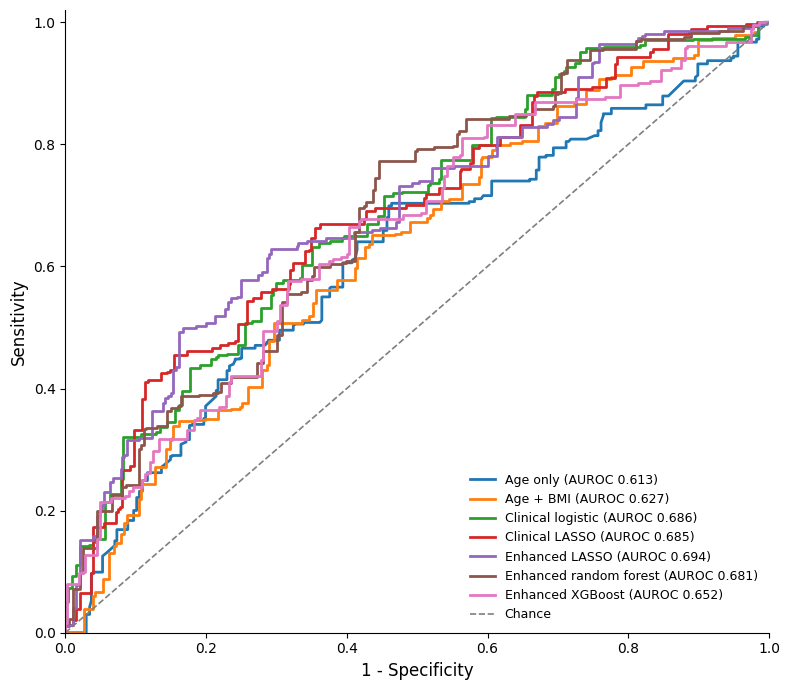


AUROC CONSISTENCY CHECK
Age only                 ROC curve = 0.612891 | Table 2 = 0.612891 | difference = +0.00000000
Age + BMI                ROC curve = 0.627411 | Table 2 = 0.627411 | difference = +0.00000000
Clinical logistic        ROC curve = 0.685644 | Table 2 = 0.685644 | difference = +0.00000000
Clinical LASSO           ROC curve = 0.684505 | Table 2 = 0.684505 | difference = +0.00000000
Enhanced LASSO           ROC curve = 0.694181 | Table 2 = 0.694181 | difference = +0.00000000
Enhanced random forest   ROC curve = 0.680815 | Table 2 = 0.680815 | difference = +0.00000000
Enhanced XGBoost         ROC curve = 0.652482 | Table 2 = 0.652482 | difference = +0.00000000

Saved: /content/Figure2_Audited_ROC_Curves.png
Saved: /content/Figure2_Audited_ROC_Curves.svg


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


figure2_auc_check = {}


fig, ax = plt.subplots(
    figsize=(8.0, 7.0)
)


for model_name, pred in (
    audited_model_predictions.items()
):

    pred_arr = np.asarray(
        pred,
        dtype=float
    )

    fpr, tpr, _ = roc_curve(
        y_arr,
        pred_arr,
        sample_weight=w_arr
    )

    curve_auc = auc(
        fpr,
        tpr
    )

    figure2_auc_check[
        model_name
    ] = curve_auc

    ax.plot(
        fpr,
        tpr,
        linewidth=2.0,
        label=(
            f"{model_name} "
            f"(AUROC {curve_auc:.3f})"
        )
    )


# Reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Chance"
)


ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.02
)

ax.set_xlabel(
    "1 - Specificity",
    fontsize=12
)

ax.set_ylabel(
    "Sensitivity",
    fontsize=12
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.legend(
    loc="lower right",
    fontsize=9,
    frameon=False
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

fig.tight_layout()


figure2_png = (
    "/content/"
    "Figure2_Audited_ROC_Curves.png"
)

figure2_svg = (
    "/content/"
    "Figure2_Audited_ROC_Curves.svg"
)


fig.savefig(
    figure2_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure2_svg,
    bbox_inches="tight"
)


plt.show()


print()
print(
    "AUROC CONSISTENCY CHECK"
)

for model_name, auc_value in (
    figure2_auc_check.items()
):

    table_auc = float(
        audited_table2.loc[
            audited_table2[
                "Model"
            ] == model_name,
            "AUROC"
        ].iloc[0]
    )

    print(
        f"{model_name:24s} "
        f"ROC curve = {auc_value:.6f} | "
        f"Table 2 = {table_auc:.6f} | "
        f"difference = "
        f"{auc_value - table_auc:+.8f}"
    )


print()
print(
    "Saved:",
    figure2_png
)

print(
    "Saved:",
    figure2_svg
)

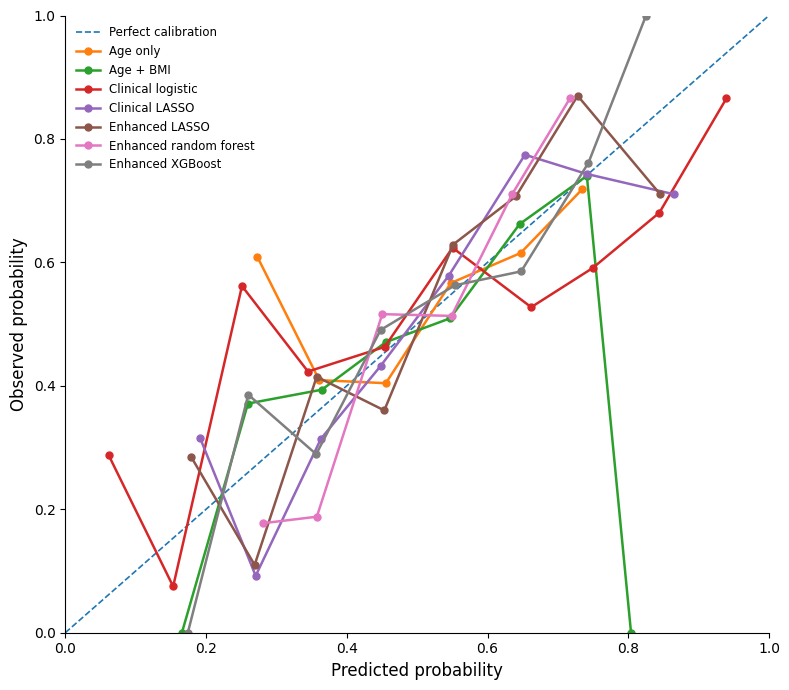


FIGURE 3 CALIBRATION DIAGNOSTIC

Age only
Occupied 0.10-risk bins = 6
       bin  n  weighted_mean_predicted  weighted_observed
(0.2, 0.3] 10                    0.273              0.609
(0.3, 0.4] 52                    0.361              0.409
(0.4, 0.5] 87                    0.456              0.404
(0.5, 0.6] 82                    0.548              0.567
(0.6, 0.7] 55                    0.647              0.615
(0.7, 0.8] 23                    0.735              0.718

Age + BMI
Occupied 0.10-risk bins = 8
       bin  n  weighted_mean_predicted  weighted_observed
(0.1, 0.2]  3                    0.166              0.000
(0.2, 0.3] 24                    0.260              0.371
(0.3, 0.4] 47                    0.365              0.394
(0.4, 0.5] 81                    0.455              0.471
(0.5, 0.6] 62                    0.547              0.509
(0.6, 0.7] 56                    0.646              0.662
(0.7, 0.8] 33                    0.741              0.740
(0.8, 0.9]  3       

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Fixed predicted-risk intervals:
# [0.0,0.1), [0.1,0.2), ... [0.9,1.0]
calibration_bins = np.linspace(
    0,
    1,
    11
)


def weighted_calibration_points(
    y_true,
    pred,
    weights,
    bins
):

    temp = pd.DataFrame({
        "y": np.asarray(
            y_true,
            dtype=float
        ),
        "pred": np.asarray(
            pred,
            dtype=float
        ),
        "weight": np.asarray(
            weights,
            dtype=float
        )
    })

    # Ensure probability 1.0 falls
    # into the final interval.
    temp["bin"] = pd.cut(
        temp["pred"],
        bins=bins,
        include_lowest=True,
        right=True
    )

    rows = []

    for interval, group in temp.groupby(
        "bin",
        observed=True
    ):

        if len(group) == 0:
            continue

        w = group[
            "weight"
        ].to_numpy()

        mean_pred = np.average(
            group["pred"],
            weights=w
        )

        observed_rate = np.average(
            group["y"],
            weights=w
        )

        rows.append({
            "bin":
                str(interval),

            "n":
                len(group),

            "weighted_mean_predicted":
                mean_pred,

            "weighted_observed":
                observed_rate,

            "weight_sum":
                w.sum()
        })

    return pd.DataFrame(
        rows
    )


# --------------------------------------------------
# Calculate calibration points for all seven models
# --------------------------------------------------

figure3_calibration_data = {}

for model_name, pred in (
    audited_model_predictions.items()
):

    figure3_calibration_data[
        model_name
    ] = weighted_calibration_points(
        y_true=y_arr,
        pred=pred,
        weights=w_arr,
        bins=calibration_bins
    )


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.0, 7.0)
)


# Perfect calibration reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Perfect calibration"
)


for model_name in (
    audited_model_predictions.keys()
):

    cal = (
        figure3_calibration_data[
            model_name
        ]
    )

    ax.plot(
        cal[
            "weighted_mean_predicted"
        ],
        cal[
            "weighted_observed"
        ],
        marker="o",
        markersize=5,
        linewidth=1.8,
        label=model_name
    )


ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.set_xlabel(
    "Predicted probability",
    fontsize=12
)

ax.set_ylabel(
    "Observed probability",
    fontsize=12
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.legend(
    loc="upper left",
    fontsize=8.5,
    frameon=False
)

fig.tight_layout()


figure3_png = (
    "/content/"
    "Figure3_Audited_Calibration.png"
)

figure3_svg = (
    "/content/"
    "Figure3_Audited_Calibration.svg"
)


fig.savefig(
    figure3_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure3_svg,
    bbox_inches="tight"
)


plt.show()


# --------------------------------------------------
# Diagnostic output
# --------------------------------------------------

print()
print("=" * 78)
print(
    "FIGURE 3 CALIBRATION DIAGNOSTIC"
)
print("=" * 78)

for model_name, cal in (
    figure3_calibration_data.items()
):

    print()
    print(
        model_name
    )

    print(
        "Occupied 0.10-risk bins =",
        len(cal)
    )

    print(
        cal[
            [
                "bin",
                "n",
                "weighted_mean_predicted",
                "weighted_observed"
            ]
        ]
        .to_string(
            index=False,
            float_format=lambda x:
                f"{x:.3f}"
        )
    )


print()
print(
    "Saved:",
    figure3_png
)

print(
    "Saved:",
    figure3_svg
)

In [ ]:
# Paired bootstrap comparisons:
# Enhanced LASSO versus each of the other six models.
#
# Positive AUROC difference favors Enhanced LASSO.
# Negative Brier/log-loss difference favors Enhanced LASSO.

reference_model = "Enhanced LASSO"

comparison_rows = []

reference_point = audited_table2.loc[
    audited_table2["Model"] == reference_model
].iloc[0]

reference_boot = audited_bootstrap_results[
    reference_model
]


for comparator in audited_model_predictions.keys():

    if comparator == reference_model:
        continue

    comparator_point = audited_table2.loc[
        audited_table2["Model"] == comparator
    ].iloc[0]

    comparator_boot = audited_bootstrap_results[
        comparator
    ]


    # --------------------------------------------------
    # AUROC difference
    # --------------------------------------------------

    auc_diff_point = (
        reference_point["AUROC"]
        - comparator_point["AUROC"]
    )

    auc_diff_boot = (
        reference_boot["AUROC"]
        - comparator_boot["AUROC"]
    )

    auc_ci = np.percentile(
        auc_diff_boot,
        [2.5, 97.5]
    )


    # --------------------------------------------------
    # Brier difference
    # --------------------------------------------------

    brier_diff_point = (
        reference_point["Brier"]
        - comparator_point["Brier"]
    )

    brier_diff_boot = (
        reference_boot["Brier"]
        - comparator_boot["Brier"]
    )

    brier_ci = np.percentile(
        brier_diff_boot,
        [2.5, 97.5]
    )


    # --------------------------------------------------
    # Log-loss difference
    # --------------------------------------------------

    logloss_diff_point = (
        reference_point["Log_loss"]
        - comparator_point["Log_loss"]
    )

    logloss_diff_boot = (
        reference_boot["Log_loss"]
        - comparator_boot["Log_loss"]
    )

    logloss_ci = np.percentile(
        logloss_diff_boot,
        [2.5, 97.5]
    )


    comparison_rows.append({
        "Comparator":
            comparator,

        "AUROC_difference":
            auc_diff_point,

        "AUROC_CI_low":
            auc_ci[0],

        "AUROC_CI_high":
            auc_ci[1],

        "Brier_difference":
            brier_diff_point,

        "Brier_CI_low":
            brier_ci[0],

        "Brier_CI_high":
            brier_ci[1],

        "LogLoss_difference":
            logloss_diff_point,

        "LogLoss_CI_low":
            logloss_ci[0],

        "LogLoss_CI_high":
            logloss_ci[1]
    })


paired_model_comparisons = pd.DataFrame(
    comparison_rows
)


print("=" * 120)
print(
    "PAIRED BOOTSTRAP COMPARISONS: "
    "ENHANCED LASSO MINUS COMPARATOR"
)
print("=" * 120)

print()

print(
    paired_model_comparisons.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}"
    )
)


print()
print(
    "Interpretation:"
)

print(
    "AUROC: positive difference favors "
    "Enhanced LASSO."
)

print(
    "Brier/log loss: negative difference favors "
    "Enhanced LASSO."
)

print(
    "A 95% CI containing 0 indicates that the "
    "paired bootstrap does not clearly distinguish "
    "the models on that metric."
)

PAIRED BOOTSTRAP COMPARISONS: ENHANCED LASSO MINUS COMPARATOR

            Comparator  AUROC_difference  AUROC_CI_low  AUROC_CI_high  Brier_difference  Brier_CI_low  Brier_CI_high  LogLoss_difference  LogLoss_CI_low  LogLoss_CI_high
              Age only            0.0813        0.0132         0.1547           -0.0182       -0.0330        -0.0038             -0.0391         -0.0712          -0.0087
             Age + BMI            0.0668        0.0030         0.1347           -0.0161       -0.0318        -0.0008             -0.0351         -0.0687          -0.0019
     Clinical logistic            0.0085       -0.0415         0.0574           -0.0101       -0.0345         0.0130             -0.0334         -0.1021           0.0282
        Clinical LASSO            0.0097       -0.0213         0.0400           -0.0023       -0.0080         0.0029             -0.0050         -0.0168           0.0058
Enhanced random forest            0.0134       -0.0423         0.0700           -0.0034

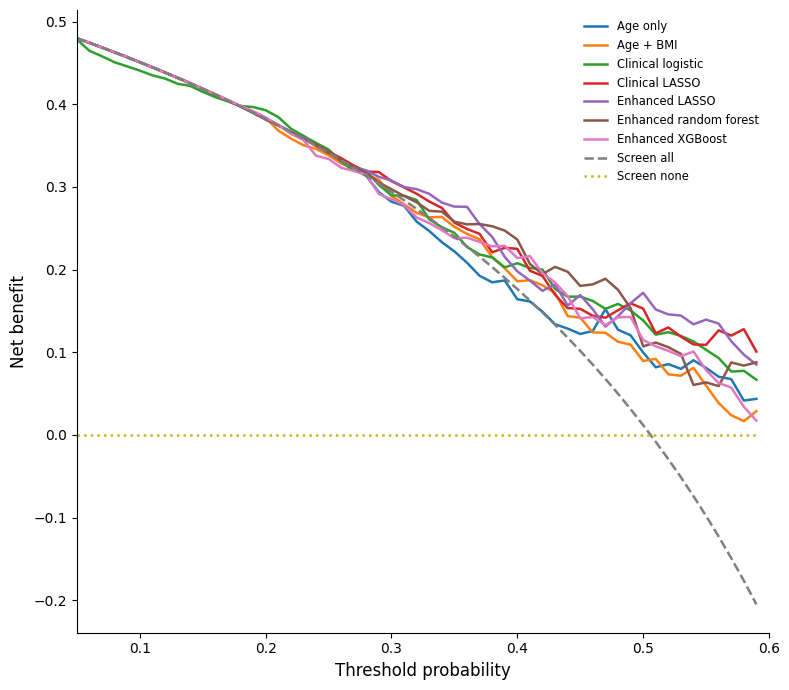


FIGURE 4 DECISION-CURVE DIAGNOSTIC
Weighted prevalence = 0.5059056255648255

Age only                 | minimum NB = 0.0416 | above screen-none throughout 0.05-0.60 = True | first threshold > screen-all = 0.24000000000000005
Age + BMI                | minimum NB = 0.0166 | above screen-none throughout 0.05-0.60 = True | first threshold > screen-all = 0.12000000000000001
Clinical logistic        | minimum NB = 0.0668 | above screen-none throughout 0.05-0.60 = True | first threshold > screen-all = 0.18000000000000005
Clinical LASSO           | minimum NB = 0.1008 | above screen-none throughout 0.05-0.60 = True | first threshold > screen-all = 0.19
Enhanced LASSO           | minimum NB = 0.0851 | above screen-none throughout 0.05-0.60 = True | first threshold > screen-all = 0.17000000000000004
Enhanced random forest   | minimum NB = 0.0591 | above screen-none throughout 0.05-0.60 = True | first threshold > screen-all = 0.27
Enhanced XGBoost         | minimum NB = 0.0172 | above screen-no

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# Decision-curve analysis
# --------------------------------------------------

dca_thresholds = np.arange(
    0.05,
    0.751,
    0.01
)


def weighted_net_benefit(
    y_true,
    pred,
    weights,
    threshold
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )

    pred = np.asarray(
        pred,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    positive = (
        pred >= threshold
    )

    total_weight = (
        weights.sum()
    )

    tp_weight = (
        weights[
            positive
            & (y_true == 1)
        ].sum()
    )

    fp_weight = (
        weights[
            positive
            & (y_true == 0)
        ].sum()
    )

    odds = (
        threshold
        / (1.0 - threshold)
    )

    net_benefit = (
        tp_weight
        / total_weight
        -
        (
            fp_weight
            / total_weight
        )
        * odds
    )

    return net_benefit


# Survey-weighted observed prevalence
weighted_prevalence = np.average(
    y_arr,
    weights=w_arr
)


dca_rows = []

for threshold in dca_thresholds:

    # Screen-none
    screen_none_nb = 0.0

    # Screen-all
    screen_all_nb = (
        weighted_prevalence
        -
        (
            1.0
            - weighted_prevalence
        )
        * (
            threshold
            / (
                1.0
                - threshold
            )
        )
    )

    dca_rows.append({
        "Threshold":
            threshold,
        "Strategy":
            "Screen all",
        "Net_benefit":
            screen_all_nb
    })

    dca_rows.append({
        "Threshold":
            threshold,
        "Strategy":
            "Screen none",
        "Net_benefit":
            screen_none_nb
    })

    for model_name, pred in (
        audited_model_predictions.items()
    ):

        nb = weighted_net_benefit(
            y_true=y_arr,
            pred=pred,
            weights=w_arr,
            threshold=threshold
        )

        dca_rows.append({
            "Threshold":
                threshold,
            "Strategy":
                model_name,
            "Net_benefit":
                nb
        })


figure4_dca_data = pd.DataFrame(
    dca_rows
)


# --------------------------------------------------
# Plot only 0.05 to 0.60
# --------------------------------------------------

display_dca = (
    figure4_dca_data[
        figure4_dca_data[
            "Threshold"
        ] <= 0.60
    ]
    .copy()
)


fig, ax = plt.subplots(
    figsize=(8.0, 7.0)
)


# Plot model curves
for model_name in (
    audited_model_predictions.keys()
):

    temp = display_dca[
        display_dca[
            "Strategy"
        ] == model_name
    ]

    ax.plot(
        temp["Threshold"],
        temp["Net_benefit"],
        linewidth=1.8,
        label=model_name
    )


# Screen-all
temp_all = display_dca[
    display_dca[
        "Strategy"
    ] == "Screen all"
]

ax.plot(
    temp_all["Threshold"],
    temp_all["Net_benefit"],
    linestyle="--",
    linewidth=1.8,
    label="Screen all"
)


# Screen-none
temp_none = display_dca[
    display_dca[
        "Strategy"
    ] == "Screen none"
]

ax.plot(
    temp_none["Threshold"],
    temp_none["Net_benefit"],
    linestyle=":",
    linewidth=1.8,
    label="Screen none"
)


ax.set_xlim(
    0.05,
    0.60
)

ax.set_xlabel(
    "Threshold probability",
    fontsize=12
)

ax.set_ylabel(
    "Net benefit",
    fontsize=12
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.legend(
    loc="best",
    fontsize=8.3,
    frameon=False
)

fig.tight_layout()


figure4_png = (
    "/content/"
    "Figure4_Audited_Decision_Curve.png"
)

figure4_svg = (
    "/content/"
    "Figure4_Audited_Decision_Curve.svg"
)


fig.savefig(
    figure4_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure4_svg,
    bbox_inches="tight"
)


plt.show()


# --------------------------------------------------
# Diagnostics
# --------------------------------------------------

print()
print("=" * 90)
print(
    "FIGURE 4 DECISION-CURVE DIAGNOSTIC"
)
print("=" * 90)

print(
    "Weighted prevalence =",
    weighted_prevalence
)

print()


for model_name in (
    audited_model_predictions.keys()
):

    model_temp = display_dca[
        display_dca[
            "Strategy"
        ] == model_name
    ].copy()

    screen_all_temp = (
        temp_all[
            [
                "Threshold",
                "Net_benefit"
            ]
        ]
        .rename(
            columns={
                "Net_benefit":
                    "Screen_all_NB"
            }
        )
    )

    merged = model_temp.merge(
        screen_all_temp,
        on="Threshold",
        how="left"
    )

    merged[
        "Difference_vs_screen_all"
    ] = (
        merged[
            "Net_benefit"
        ]
        -
        merged[
            "Screen_all_NB"
        ]
    )

    min_nb = (
        merged[
            "Net_benefit"
        ].min()
    )

    positive_vs_none = (
        merged[
            "Net_benefit"
        ] > 0
    ).all()

    better_than_all = merged[
        merged[
            "Difference_vs_screen_all"
        ] > 0
    ]

    if len(
        better_than_all
    ) > 0:

        first_better_threshold = (
            better_than_all[
                "Threshold"
            ].min()
        )

    else:

        first_better_threshold = (
            np.nan
        )

    print(
        f"{model_name:24s} | "
        f"minimum NB = {min_nb:.4f} | "
        f"above screen-none throughout 0.05-0.60 = "
        f"{positive_vs_none} | "
        f"first threshold > screen-all = "
        f"{first_better_threshold}"
    )


print()
print(
    "NET BENEFIT AT SELECTED THRESHOLDS"
)

selected_thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60
]

summary = (
    display_dca[
        display_dca[
            "Threshold"
        ].round(2).isin(
            selected_thresholds
        )
    ]
    .pivot(
        index="Threshold",
        columns="Strategy",
        values="Net_benefit"
    )
)

print(
    summary.to_string(
        float_format=lambda x:
            f"{x:.4f}"
    )
)


print()
print(
    "Saved:",
    figure4_png
)

print(
    "Saved:",
    figure4_svg
)

In [ ]:
import inspect

print("=" * 80)
print("THRESHOLD HELPER")
print("=" * 80)

print(
    inspect.signature(
        threshold_for_target_sensitivity_at_least_unweighted
    )
)

print()

print(
    inspect.getsource(
        threshold_for_target_sensitivity_at_least_unweighted
    )
)

print()
print("=" * 80)
print("AGE-ONLY SCREENING AUDIT")
print("=" * 80)

print(
    inspect.getsource(
        run_age_only_screening_audit
    )
)

THRESHOLD HELPER
(y_true, pred, weights=None, target_sensitivity=0.9)

def threshold_for_target_sensitivity_at_least_unweighted(
    y_true,
    pred,
    weights=None,
    target_sensitivity=0.90
):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)

    thresholds = np.unique(pred)

    valid_thresholds = []

    for threshold in thresholds:

        predicted_positive = (
            pred >= threshold
        ).astype(int)

        tp = np.sum(
            (y_true == 1)
            & (predicted_positive == 1)
        )

        fn = np.sum(
            (y_true == 1)
            & (predicted_positive == 0)
        )

        sensitivity = (
            tp / (tp + fn)
        )

        if sensitivity >= target_sensitivity:

            valid_thresholds.append(
                (
                    threshold,
                    sensitivity
                )
            )

    if len(valid_thresholds) == 0:
        raise ValueError(
            "No threshold achieved target s

In [ ]:
import inspect

print("=" * 80)
print("ACTUAL THRESHOLD FUNCTION USED BY AGE-ONLY AUDIT")
print("=" * 80)

print(
    inspect.signature(
        threshold_for_target_sensitivity
    )
)

print()

print(
    inspect.getsource(
        threshold_for_target_sensitivity
    )
)


print()
print("=" * 80)
print("FINAL SCREENING METRICS FUNCTION")
print("=" * 80)

print(
    inspect.signature(
        calculate_screening_metrics
    )
)

print()

print(
    inspect.getsource(
        calculate_screening_metrics
    )
)

ACTUAL THRESHOLD FUNCTION USED BY AGE-ONLY AUDIT
(y_true, pred, weights, target_sensitivity=0.9)

def threshold_for_target_sensitivity(
    y_true,
    pred,
    weights,
    target_sensitivity=0.90
):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    weights = np.asarray(weights)

    thresholds = np.unique(pred)

    best_threshold = None
    best_difference = np.inf
    best_sensitivity = None

    for threshold in thresholds:

        predicted_positive = (
            pred >= threshold
        ).astype(int)

        tp = np.sum(
            weights[
                (y_true == 1)
                & (predicted_positive == 1)
            ]
        )

        fn = np.sum(
            weights[
                (y_true == 1)
                & (predicted_positive == 0)
            ]
        )

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        difference = abs(
            sensitivity - target_sensitivity

In [ ]:
import inspect

print("=" * 80)
print("CURRENT ENHANCED SCREENING REPETITION FUNCTION")
print("=" * 80)

print(
    inspect.getsource(
        run_enhanced_screening_repetition
    )
)

print()
print("=" * 80)
print("CURRENT ENHANCED INNER OOF FUNCTION")
print("=" * 80)

print(
    inspect.getsource(
        get_enhanced_inner_oof_predictions
    )
)

CURRENT ENHANCED SCREENING REPETITION FUNCTION
def run_enhanced_screening_repetition(repetition):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    repetition_result = next(
        r for r in enhanced_lasso_all_results
        if r["repetition"] == repetition
    )

    outer_oof = (
        enhanced_lasso_all_oof[repetition]
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    for outer_fold_number, (train_idx, val_idx) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            X_enhanced_lasso.iloc[train_idx].copy()
        )

        y_train = y.iloc[train_idx]

        w_train = model_weights.iloc[train_idx]

        inner_groups = groups.iloc[tra

In [ ]:
# Find the exact notebook cells that generated the corrected
# "original rule" screening analyses.

search_terms = [
    "enhanced_screening_results_original_rule",
    "clinical_screening_results_original_rule",
    "threshold_for_target_sensitivity_at_least_unweighted",
    "original_rule"
]

matching_cells = []

for i, cell in enumerate(In):

    cell_lower = cell.lower()

    if any(
        term.lower() in cell_lower
        for term in search_terms
    ):
        matching_cells.append(
            (i, cell)
        )


print(
    "MATCHING CELLS:",
    len(matching_cells)
)

print()

for i, cell in matching_cells:

    print("=" * 100)
    print("CELL", i)
    print("=" * 100)

    print(cell[:6000])

    if len(cell) > 6000:
        print(
            "\n... [truncated]"
        )

    print()

MATCHING CELLS: 8

CELL 61
def threshold_for_target_sensitivity_at_least_unweighted(
    y_true,
    pred,
    weights=None,
    target_sensitivity=0.90
):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)

    thresholds = np.unique(pred)

    valid_thresholds = []

    for threshold in thresholds:

        predicted_positive = (
            pred >= threshold
        ).astype(int)

        tp = np.sum(
            (y_true == 1)
            & (predicted_positive == 1)
        )

        fn = np.sum(
            (y_true == 1)
            & (predicted_positive == 0)
        )

        sensitivity = (
            tp / (tp + fn)
        )

        if sensitivity >= target_sensitivity:

            valid_thresholds.append(
                (
                    threshold,
                    sensitivity
                )
            )

    if len(valid_thresholds) == 0:
        raise ValueError(
            "No threshold achieved target sensitivity."
        )

    # Highest thresh

In [ ]:
# Corrected Table 3 screening analysis:
# AGE + BMI
#
# Authoritative recovered rule:
# - inner OOF predictions
# - UNWEIGHTED sensitivity
# - highest threshold achieving sensitivity >= 0.90
# - apply threshold to corresponding outer held-out fold
# - calculate final pooled metrics using survey weights


def run_age_bmi_screening_original_rule(
    repetition
):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            df[["age_years", "bmi"]],
            y,
            groups=groups
        )
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    # Use the exact audited held-out predictions
    # already used for Table 2.
    outer_oof = age_bmi_oof[
        repetition
    ]

    for outer_fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            df[
                ["age_years", "bmi"]
            ]
            .iloc[train_idx]
            .copy()
        )

        y_train = y.iloc[
            train_idx
        ]

        w_train = model_weights.iloc[
            train_idx
        ]

        inner_groups = groups.iloc[
            train_idx
        ]

        inner_seed = (
            repetition * 100
            + outer_fold_number
        )

        inner_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=inner_seed
        )

        inner_oof = np.full(
            len(X_train),
            np.nan
        )

        for (
            inner_train_idx,
            inner_val_idx
        ) in inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        ):

            scaler = StandardScaler()

            X_inner_train = (
                scaler.fit_transform(
                    X_train.iloc[
                        inner_train_idx
                    ]
                )
            )

            X_inner_val = (
                scaler.transform(
                    X_train.iloc[
                        inner_val_idx
                    ]
                )
            )

            model = LogisticRegression(
                penalty=None,
                solver="lbfgs",
                max_iter=5000
            )

            model.fit(
                X_inner_train,
                y_train.iloc[
                    inner_train_idx
                ],
                sample_weight=
                    w_train.iloc[
                        inner_train_idx
                    ]
            )

            inner_oof[
                inner_val_idx
            ] = (
                model.predict_proba(
                    X_inner_val
                )[:, 1]
            )

        if np.isnan(
            inner_oof
        ).any():

            raise ValueError(
                "Missing Age + BMI "
                "inner OOF predictions."
            )

        (
            threshold,
            inner_sensitivity
        ) = (
            threshold_for_target_sensitivity_at_least_unweighted(
                y_true=
                    y_train.to_numpy(),

                pred=
                    inner_oof,

                target_sensitivity=
                    0.90
            )
        )

        outer_pred = outer_oof[
            val_idx
        ]

        screening_classification[
            val_idx
        ] = (
            outer_pred
            >= threshold
        ).astype(int)

        fold_thresholds.append(
            threshold
        )

        fold_inner_sensitivities.append(
            inner_sensitivity
        )

    if np.isnan(
        screening_classification
    ).any():

        raise ValueError(
            "Missing Age + BMI "
            "screening classifications."
        )

    return {
        "repetition":
            repetition,

        "classification":
            screening_classification.astype(
                int
            ),

        "thresholds":
            fold_thresholds,

        "inner_sensitivities":
            fold_inner_sensitivities
    }


age_bmi_screening_results_original_rule = {}

for repetition in range(
    1,
    11
):

    age_bmi_screening_results_original_rule[
        repetition
    ] = (
        run_age_bmi_screening_original_rule(
            repetition
        )
    )


# --------------------------------------------------
# Pool all 10 repeated held-out classifications
# --------------------------------------------------

age_bmi_screen_matrix = np.column_stack([
    age_bmi_screening_results_original_rule[
        r
    ]["classification"]

    for r in range(
        1,
        11
    )
])

age_bmi_class_repeated = (
    age_bmi_screen_matrix
    .T
    .reshape(-1)
)


age_bmi_screening_final = (
    calculate_screening_metrics(
        y_true=np.tile(
            y.to_numpy(),
            10
        ),

        classification=
            age_bmi_class_repeated,

        weights=np.tile(
            model_weights.to_numpy(),
            10
        )
    )
)


age_bmi_thresholds = []

for r in range(
    1,
    11
):

    age_bmi_thresholds.extend(
        age_bmi_screening_results_original_rule[
            r
        ]["thresholds"]
    )


print(
    "CORRECTED AGE + BMI SCREENING"
)

print()

for key, value in (
    age_bmi_screening_final.items()
):

    print(
        key,
        "=",
        value
    )

print()

print(
    "Median threshold =",
    np.median(
        age_bmi_thresholds
    )
)

print(
    "Threshold range =",
    (
        np.min(
            age_bmi_thresholds
        ),
        np.max(
            age_bmi_thresholds
        )
    )
)

print(
    "Number of held-out decisions =",
    len(
        age_bmi_class_repeated
    )
)

print()
print(
    "Historical workbook:"
)

print(
    "Sensitivity 0.9087 | "
    "Specificity 0.2267 | "
    "NPV 0.7080 | "
    "Referral 0.8418 | "
    "DXAs/case 1.8311"
)

CORRECTED AGE + BMI SCREENING

Sensitivity = 0.9127298001364964
Specificity = 0.22016917236823977
PPV = 0.5451235150986223
NPV = 0.7113117806934666
Referral_rate = 0.8470651654536914
False_negative_rate = 0.08727019986350368
DXAs_per_case = 1.8344466387935634

Median threshold = 0.3618582767411921
Threshold range = (np.float64(0.3071331361810265), np.float64(0.39350890731242266))
Number of held-out decisions = 3090

Historical workbook:
Sensitivity 0.9087 | Specificity 0.2267 | NPV 0.7080 | Referral 0.8418 | DXAs/case 1.8311


In [ ]:
def get_clinical_logistic_inner_oof_predictions(
    X_train,
    y_train,
    w_train,
    inner_groups,
    repetition,
    outer_fold_number
):

    inner_seed = (
        repetition * 100
        + outer_fold_number
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_oof = np.full(
        len(X_train),
        np.nan
    )

    for (
        inner_train_idx,
        inner_val_idx
    ) in inner_cv.split(
        X_train,
        y_train,
        groups=inner_groups
    ):

        X_inner_train = (
            X_train
            .iloc[inner_train_idx]
            .copy()
        )

        X_inner_val = (
            X_train
            .iloc[inner_val_idx]
            .copy()
        )

        y_inner_train = (
            y_train
            .iloc[inner_train_idx]
        )

        w_inner_train = (
            w_train
            .iloc[inner_train_idx]
        )

        fold_predictions = []

        for seed in [1, 2, 3]:

            train_cont, val_cont = (
                impute_clinical_continuous(
                    X_inner_train,
                    X_inner_val,
                    seed=seed
                )
            )

            train_cat, val_cat = (
                impute_clinical_categorical(
                    X_inner_train,
                    X_inner_val,
                    w_inner_train,
                    seed=seed
                )
            )

            train_final, val_final = (
                build_clinical_lasso_design(
                    train_cont,
                    val_cont,
                    train_cat,
                    val_cat
                )
            )

            model = LogisticRegression(
                penalty=None,
                solver="lbfgs",
                fit_intercept=True,
                max_iter=5000
            )

            model.fit(
                train_final,
                y_inner_train,
                sample_weight=w_inner_train
            )

            pred = model.predict_proba(
                val_final
            )[:, 1]

            fold_predictions.append(
                pred
            )

        inner_oof[
            inner_val_idx
        ] = np.mean(
            fold_predictions,
            axis=0
        )

    if np.isnan(
        inner_oof
    ).any():

        raise ValueError(
            "Missing Clinical logistic "
            "inner OOF predictions."
        )

    return inner_oof


def run_clinical_logistic_screening_original_rule(
    repetition
):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_clinical_lasso,
            y,
            groups=groups
        )
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    # Exact audited held-out predictions
    outer_oof = (
        clinical_logistic_oof[
            repetition
        ]
    )

    for outer_fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            X_clinical_lasso
            .iloc[train_idx]
            .copy()
        )

        y_train = y.iloc[
            train_idx
        ]

        w_train = model_weights.iloc[
            train_idx
        ]

        inner_groups = groups.iloc[
            train_idx
        ]

        inner_oof = (
            get_clinical_logistic_inner_oof_predictions(
                X_train=X_train,
                y_train=y_train,
                w_train=w_train,
                inner_groups=inner_groups,
                repetition=repetition,
                outer_fold_number=
                    outer_fold_number
            )
        )

        (
            threshold,
            inner_sensitivity
        ) = (
            threshold_for_target_sensitivity_at_least_unweighted(
                y_true=
                    y_train.to_numpy(),
                pred=
                    inner_oof,
                target_sensitivity=
                    0.90
            )
        )

        outer_pred = (
            outer_oof[
                val_idx
            ]
        )

        screening_classification[
            val_idx
        ] = (
            outer_pred >= threshold
        ).astype(int)

        fold_thresholds.append(
            threshold
        )

        fold_inner_sensitivities.append(
            inner_sensitivity
        )

    if np.isnan(
        screening_classification
    ).any():

        raise ValueError(
            "Missing Clinical logistic "
            "screening classifications."
        )

    return {
        "repetition":
            repetition,

        "classification":
            screening_classification.astype(
                int
            ),

        "thresholds":
            fold_thresholds,

        "inner_sensitivities":
            fold_inner_sensitivities
    }


clinical_logistic_screening_results_original_rule = {}

for repetition in range(
    1,
    11
):

    print(
        "Running repetition",
        repetition
    )

    clinical_logistic_screening_results_original_rule[
        repetition
    ] = (
        run_clinical_logistic_screening_original_rule(
            repetition
        )
    )


clinical_logistic_screen_matrix = np.column_stack([
    clinical_logistic_screening_results_original_rule[
        r
    ]["classification"]

    for r in range(
        1,
        11
    )
])

clinical_logistic_class_repeated = (
    clinical_logistic_screen_matrix
    .T
    .reshape(-1)
)


clinical_logistic_screening_final = (
    calculate_screening_metrics(
        y_true=np.tile(
            y.to_numpy(),
            10
        ),

        classification=
            clinical_logistic_class_repeated,

        weights=np.tile(
            model_weights.to_numpy(),
            10
        )
    )
)


clinical_logistic_thresholds = []

for r in range(
    1,
    11
):

    clinical_logistic_thresholds.extend(
        clinical_logistic_screening_results_original_rule[
            r
        ]["thresholds"]
    )


print()
print(
    "CORRECTED CLINICAL LOGISTIC SCREENING"
)

print()

for key, value in (
    clinical_logistic_screening_final.items()
):

    print(
        key,
        "=",
        value
    )

print()

print(
    "Median threshold =",
    np.median(
        clinical_logistic_thresholds
    )
)

print(
    "Threshold range =",
    (
        np.min(
            clinical_logistic_thresholds
        ),
        np.max(
            clinical_logistic_thresholds
        )
    )
)

print(
    "Number of held-out decisions =",
    len(
        clinical_logistic_class_repeated
    )
)

print()
print(
    "Historical workbook:"
)

print(
    "Sensitivity 0.9000 | "
    "Specificity 0.3066 | "
    "NPV 0.7497 | "
    "Referral 0.7979 | "
    "DXAs/case 1.7524"
)

Running repetition 1
Running repetition 2
Running repetition 3
Running repetition 4
Running repetition 5


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Running repetition 6
Running repetition 7
Running repetition 8
Running repetition 9
Running repetition 10


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



CORRECTED CLINICAL LOGISTIC SCREENING

Sensitivity = 0.9354467235857825
Specificity = 0.22865120337071346
PPV = 0.5539163343872908
NPV = 0.7757525113078692
Referral_rate = 0.8543668610201037
False_negative_rate = 0.06455327641421754
DXAs_per_case = 1.8053267938128965

Median threshold = 0.1837358194346687
Threshold range = (np.float64(0.08498692912696088), np.float64(0.263667393277167))
Number of held-out decisions = 3090

Historical workbook:
Sensitivity 0.9000 | Specificity 0.3066 | NPV 0.7497 | Referral 0.7979 | DXAs/case 1.7524


In [ ]:
def get_enhanced_rf_inner_oof_predictions(
    X_train,
    y_train,
    w_train,
    inner_groups,
    repetition,
    outer_fold_number,
    selected_params
):

    inner_seed = (
        repetition * 100
        + outer_fold_number
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    inner_oof = np.full(
        len(X_train),
        np.nan
    )

    for inner_fold_number, (
        inner_train_idx,
        inner_val_idx
    ) in enumerate(
        inner_splits,
        start=1
    ):

        X_inner_train = (
            X_train
            .iloc[inner_train_idx]
            .copy()
        )

        X_inner_val = (
            X_train
            .iloc[inner_val_idx]
            .copy()
        )

        y_inner_train = (
            y_train
            .iloc[inner_train_idx]
        )

        w_inner_train = (
            w_train
            .iloc[inner_train_idx]
        )

        fold_predictions = []

        for seed in [1, 2, 3]:

            train_cont, val_cont = (
                impute_enhanced_continuous(
                    X_inner_train,
                    X_inner_val,
                    seed=seed
                )
            )

            train_cat, val_cat = (
                impute_enhanced_categorical(
                    X_inner_train,
                    X_inner_val,
                    w_inner_train,
                    seed=seed
                )
            )

            train_final, val_final = (
                build_enhanced_tree_design(
                    train_cont,
                    val_cont,
                    train_cat,
                    val_cat
                )
            )

            model_seed = (
                repetition * 10000
                + outer_fold_number * 100
                + inner_fold_number * 10
                + seed
            )

            model = RandomForestClassifier(
                n_estimators=300,
                max_depth=
                    selected_params[
                        "max_depth"
                    ],
                max_features=
                    selected_params[
                        "max_features"
                    ],
                min_samples_leaf=
                    selected_params[
                        "min_samples_leaf"
                    ],
                random_state=
                    model_seed,
                n_jobs=-1
            )

            model.fit(
                train_final,
                y_inner_train,
                sample_weight=
                    w_inner_train
            )

            pred = model.predict_proba(
                val_final
            )[:, 1]

            fold_predictions.append(
                pred
            )

        inner_oof[
            inner_val_idx
        ] = np.mean(
            fold_predictions,
            axis=0
        )

    if np.isnan(
        inner_oof
    ).any():

        raise ValueError(
            "Missing RF inner "
            "OOF predictions."
        )

    return inner_oof


def run_enhanced_rf_screening_original_rule(
    repetition
):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    # Exact audited RF held-out predictions
    outer_oof = (
        enhanced_rf_oof[
            repetition
        ]
    )

    selected_params_by_fold = (
        enhanced_rf_results[
            repetition
        ][
            "selected_params"
        ]
    )

    for outer_fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            X_enhanced_lasso
            .iloc[train_idx]
            .copy()
        )

        y_train = y.iloc[
            train_idx
        ]

        w_train = (
            model_weights
            .iloc[train_idx]
        )

        inner_groups = (
            groups
            .iloc[train_idx]
        )

        selected_params = (
            selected_params_by_fold[
                outer_fold_number - 1
            ]
        )

        inner_oof = (
            get_enhanced_rf_inner_oof_predictions(
                X_train=X_train,
                y_train=y_train,
                w_train=w_train,
                inner_groups=inner_groups,
                repetition=repetition,
                outer_fold_number=
                    outer_fold_number,
                selected_params=
                    selected_params
            )
        )

        (
            threshold,
            inner_sensitivity
        ) = (
            threshold_for_target_sensitivity_at_least_unweighted(
                y_true=
                    y_train.to_numpy(),
                pred=
                    inner_oof,
                target_sensitivity=
                    0.90
            )
        )

        outer_pred = (
            outer_oof[
                val_idx
            ]
        )

        screening_classification[
            val_idx
        ] = (
            outer_pred
            >= threshold
        ).astype(int)

        fold_thresholds.append(
            threshold
        )

        fold_inner_sensitivities.append(
            inner_sensitivity
        )

    if np.isnan(
        screening_classification
    ).any():

        raise ValueError(
            "Missing RF screening "
            "classifications."
        )

    return {
        "repetition":
            repetition,

        "classification":
            screening_classification.astype(
                int
            ),

        "thresholds":
            fold_thresholds,

        "inner_sensitivities":
            fold_inner_sensitivities
    }


enhanced_rf_screening_results_original_rule = {}

for repetition in range(
    1,
    11
):

    print(
        "Running repetition",
        repetition
    )

    enhanced_rf_screening_results_original_rule[
        repetition
    ] = (
        run_enhanced_rf_screening_original_rule(
            repetition
        )
    )


rf_screen_matrix = np.column_stack([
    enhanced_rf_screening_results_original_rule[
        r
    ]["classification"]

    for r in range(
        1,
        11
    )
])

rf_class_repeated = (
    rf_screen_matrix
    .T
    .reshape(-1)
)


enhanced_rf_screening_final = (
    calculate_screening_metrics(
        y_true=np.tile(
            y.to_numpy(),
            10
        ),

        classification=
            rf_class_repeated,

        weights=np.tile(
            model_weights.to_numpy(),
            10
        )
    )
)


enhanced_rf_thresholds = []

for r in range(
    1,
    11
):

    enhanced_rf_thresholds.extend(
        enhanced_rf_screening_results_original_rule[
            r
        ]["thresholds"]
    )


print()
print(
    "CORRECTED ENHANCED RANDOM FOREST SCREENING"
)

print()

for key, value in (
    enhanced_rf_screening_final.items()
):

    print(
        key,
        "=",
        value
    )

print()

print(
    "Median threshold =",
    np.median(
        enhanced_rf_thresholds
    )
)

print(
    "Threshold range =",
    (
        np.min(
            enhanced_rf_thresholds
        ),
        np.max(
            enhanced_rf_thresholds
        )
    )
)

print(
    "Number of held-out decisions =",
    len(
        rf_class_repeated
    )
)

print()
print(
    "Historical workbook:"
)

print(
    "Sensitivity 0.8955 | "
    "Specificity 0.3098 | "
    "NPV 0.7433 | "
    "Referral 0.7941 | "
    "DXAs/case 1.7528"
)

Running repetition 1
Running repetition 2
Running repetition 3
Running repetition 4
Running repetition 5


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Running repetition 6
Running repetition 7
Running repetition 8
Running repetition 9
Running repetition 10


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



CORRECTED ENHANCED RANDOM FOREST SCREENING

Sensitivity = 0.8888837085552156
Specificity = 0.3302255354735737
PPV = 0.5760671052980484
NPV = 0.7437544808476731
Referral_rate = 0.780623063693847
False_negative_rate = 0.11111629144478435
DXAs_per_case = 1.7359088738153434

Median threshold = 0.407400030800223
Threshold range = (np.float64(0.3729902504158154), np.float64(0.4477476623078276))
Number of held-out decisions = 3090

Historical workbook:
Sensitivity 0.8955 | Specificity 0.3098 | NPV 0.7433 | Referral 0.7941 | DXAs/case 1.7528


In [ ]:
def get_enhanced_xgb_inner_oof_predictions(
    X_train,
    y_train,
    w_train,
    inner_groups,
    repetition,
    outer_fold_number,
    selected_params
):

    inner_seed = (
        repetition * 100
        + outer_fold_number
    )

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=inner_seed
    )

    inner_splits = list(
        inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        )
    )

    inner_oof = np.full(
        len(X_train),
        np.nan
    )

    for inner_fold_number, (
        inner_train_idx,
        inner_val_idx
    ) in enumerate(
        inner_splits,
        start=1
    ):

        X_inner_train = (
            X_train
            .iloc[inner_train_idx]
            .copy()
        )

        X_inner_val = (
            X_train
            .iloc[inner_val_idx]
            .copy()
        )

        y_inner_train = (
            y_train
            .iloc[inner_train_idx]
        )

        w_inner_train = (
            w_train
            .iloc[inner_train_idx]
        )

        fold_predictions = []

        for seed in [1, 2, 3]:

            train_cont, val_cont = (
                impute_enhanced_continuous(
                    X_inner_train,
                    X_inner_val,
                    seed=seed
                )
            )

            train_cat, val_cat = (
                impute_enhanced_categorical(
                    X_inner_train,
                    X_inner_val,
                    w_inner_train,
                    seed=seed
                )
            )

            train_final, val_final = (
                build_enhanced_tree_design(
                    train_cont,
                    val_cont,
                    train_cat,
                    val_cat
                )
            )

            model_seed = (
                repetition * 10000
                + outer_fold_number * 100
                + inner_fold_number * 10
                + seed
            )

            model = make_xgb_model(
                params=selected_params,
                random_state=model_seed
            )

            model.fit(
                train_final,
                y_inner_train,
                sample_weight=
                    w_inner_train
            )

            pred = model.predict_proba(
                val_final
            )[:, 1]

            fold_predictions.append(
                pred
            )

        inner_oof[
            inner_val_idx
        ] = np.mean(
            fold_predictions,
            axis=0
        )

    if np.isnan(
        inner_oof
    ).any():

        raise ValueError(
            "Missing XGBoost inner "
            "OOF predictions."
        )

    return inner_oof


def run_enhanced_xgb_screening_original_rule(
    repetition
):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            X_enhanced_lasso,
            y,
            groups=groups
        )
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    # Exact audited held-out predictions
    outer_oof = (
        enhanced_xgb_oof[
            repetition
        ]
    )

    selected_params_by_fold = (
        enhanced_xgb_results[
            repetition
        ][
            "selected_params"
        ]
    )

    for outer_fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            X_enhanced_lasso
            .iloc[train_idx]
            .copy()
        )

        y_train = y.iloc[
            train_idx
        ]

        w_train = (
            model_weights
            .iloc[train_idx]
        )

        inner_groups = (
            groups
            .iloc[train_idx]
        )

        selected_params = (
            selected_params_by_fold[
                outer_fold_number - 1
            ]
        )

        inner_oof = (
            get_enhanced_xgb_inner_oof_predictions(
                X_train=X_train,
                y_train=y_train,
                w_train=w_train,
                inner_groups=inner_groups,
                repetition=repetition,
                outer_fold_number=
                    outer_fold_number,
                selected_params=
                    selected_params
            )
        )

        (
            threshold,
            inner_sensitivity
        ) = (
            threshold_for_target_sensitivity_at_least_unweighted(
                y_true=
                    y_train.to_numpy(),
                pred=
                    inner_oof,
                target_sensitivity=
                    0.90
            )
        )

        outer_pred = (
            outer_oof[
                val_idx
            ]
        )

        screening_classification[
            val_idx
        ] = (
            outer_pred >= threshold
        ).astype(int)

        fold_thresholds.append(
            threshold
        )

        fold_inner_sensitivities.append(
            inner_sensitivity
        )

    if np.isnan(
        screening_classification
    ).any():

        raise ValueError(
            "Missing XGBoost screening "
            "classifications."
        )

    return {
        "repetition":
            repetition,

        "classification":
            screening_classification.astype(
                int
            ),

        "thresholds":
            fold_thresholds,

        "inner_sensitivities":
            fold_inner_sensitivities
    }


enhanced_xgb_screening_results_original_rule = {}

for repetition in range(
    1,
    11
):

    print(
        "Running repetition",
        repetition
    )

    enhanced_xgb_screening_results_original_rule[
        repetition
    ] = (
        run_enhanced_xgb_screening_original_rule(
            repetition
        )
    )


xgb_screen_matrix = np.column_stack([
    enhanced_xgb_screening_results_original_rule[
        r
    ]["classification"]

    for r in range(
        1,
        11
    )
])

xgb_class_repeated = (
    xgb_screen_matrix
    .T
    .reshape(-1)
)


enhanced_xgb_screening_final = (
    calculate_screening_metrics(
        y_true=np.tile(
            y.to_numpy(),
            10
        ),

        classification=
            xgb_class_repeated,

        weights=np.tile(
            model_weights.to_numpy(),
            10
        )
    )
)


enhanced_xgb_thresholds = []

for r in range(
    1,
    11
):

    enhanced_xgb_thresholds.extend(
        enhanced_xgb_screening_results_original_rule[
            r
        ]["thresholds"]
    )


print()
print(
    "CORRECTED ENHANCED XGBOOST SCREENING"
)

print()

for key, value in (
    enhanced_xgb_screening_final.items()
):

    print(
        key,
        "=",
        value
    )

print()

print(
    "Median threshold =",
    np.median(
        enhanced_xgb_thresholds
    )
)

print(
    "Threshold range =",
    (
        np.min(
            enhanced_xgb_thresholds
        ),
        np.max(
            enhanced_xgb_thresholds
        )
    )
)

print(
    "Number of held-out decisions =",
    len(
        xgb_class_repeated
    )
)

print()
print(
    "Historical workbook:"
)

print(
    "Sensitivity 0.8832 | "
    "Specificity 0.2496 | "
    "NPV 0.6761 | "
    "Referral 0.8176 | "
    "DXAs/case 1.8298"
)

Running repetition 1
Running repetition 2
Running repetition 3
Running repetition 4
Running repetition 5


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Running repetition 6
Running repetition 7
Running repetition 8
Running repetition 9
Running repetition 10


In [ ]:
def run_age_only_screening_original_rule(
    repetition
):

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=repetition
    )

    outer_splits = list(
        outer_cv.split(
            df[["age_years"]],
            y,
            groups=groups
        )
    )

    screening_classification = np.full(
        len(df),
        np.nan
    )

    fold_thresholds = []
    fold_inner_sensitivities = []

    # Exact audited held-out predictions
    outer_oof = age_only_oof[
        repetition
    ]

    for outer_fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_splits,
        start=1
    ):

        X_train = (
            df[["age_years"]]
            .iloc[train_idx]
            .copy()
        )

        y_train = y.iloc[
            train_idx
        ]

        w_train = model_weights.iloc[
            train_idx
        ]

        inner_groups = groups.iloc[
            train_idx
        ]

        inner_seed = (
            repetition * 100
            + outer_fold_number
        )

        inner_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=inner_seed
        )

        inner_oof = np.full(
            len(X_train),
            np.nan
        )

        for (
            inner_train_idx,
            inner_val_idx
        ) in inner_cv.split(
            X_train,
            y_train,
            groups=inner_groups
        ):

            scaler = StandardScaler()

            X_inner_train = (
                scaler.fit_transform(
                    X_train.iloc[
                        inner_train_idx
                    ]
                )
            )

            X_inner_val = (
                scaler.transform(
                    X_train.iloc[
                        inner_val_idx
                    ]
                )
            )

            model = LogisticRegression(
                penalty=None,
                solver="lbfgs",
                max_iter=5000
            )

            model.fit(
                X_inner_train,
                y_train.iloc[
                    inner_train_idx
                ],
                sample_weight=
                    w_train.iloc[
                        inner_train_idx
                    ]
            )

            inner_oof[
                inner_val_idx
            ] = (
                model.predict_proba(
                    X_inner_val
                )[:, 1]
            )

        if np.isnan(
            inner_oof
        ).any():

            raise ValueError(
                "Missing Age-only "
                "inner OOF predictions."
            )

        (
            threshold,
            inner_sensitivity
        ) = (
            threshold_for_target_sensitivity_at_least_unweighted(
                y_true=
                    y_train.to_numpy(),
                pred=
                    inner_oof,
                target_sensitivity=
                    0.90
            )
        )

        outer_pred = (
            outer_oof[
                val_idx
            ]
        )

        screening_classification[
            val_idx
        ] = (
            outer_pred >= threshold
        ).astype(int)

        fold_thresholds.append(
            threshold
        )

        fold_inner_sensitivities.append(
            inner_sensitivity
        )

    if np.isnan(
        screening_classification
    ).any():

        raise ValueError(
            "Missing Age-only "
            "screening classifications."
        )

    return {
        "repetition":
            repetition,

        "classification":
            screening_classification.astype(
                int
            ),

        "thresholds":
            fold_thresholds,

        "inner_sensitivities":
            fold_inner_sensitivities
    }


age_only_screening_results_original_rule = {}

for repetition in range(
    1,
    11
):

    age_only_screening_results_original_rule[
        repetition
    ] = (
        run_age_only_screening_original_rule(
            repetition
        )
    )


age_only_screen_matrix = np.column_stack([
    age_only_screening_results_original_rule[
        r
    ]["classification"]

    for r in range(
        1,
        11
    )
])

age_only_class_repeated = (
    age_only_screen_matrix
    .T
    .reshape(-1)
)


age_only_screening_final = (
    calculate_screening_metrics(
        y_true=np.tile(
            y.to_numpy(),
            10
        ),

        classification=
            age_only_class_repeated,

        weights=np.tile(
            model_weights.to_numpy(),
            10
        )
    )
)


age_only_thresholds = []

for r in range(
    1,
    11
):

    age_only_thresholds.extend(
        age_only_screening_results_original_rule[
            r
        ]["thresholds"]
    )


print(
    "CORRECTED AGE-ONLY SCREENING"
)

print()

for key, value in (
    age_only_screening_final.items()
):

    print(
        key,
        "=",
        value
    )

print()

print(
    "Median threshold =",
    np.median(
        age_only_thresholds
    )
)

print(
    "Threshold range =",
    (
        np.min(
            age_only_thresholds
        ),
        np.max(
            age_only_thresholds
        )
    )
)

print(
    "Number of held-out decisions =",
    len(
        age_only_class_repeated
    )
)

print()
print(
    "Historical workbook:"
)

print(
    "Sensitivity 0.8973 | "
    "Specificity 0.1415 | "
    "NPV 0.5738 | "
    "Referral 0.8781 | "
    "DXAs/case 1.9344"
)

CORRECTED AGE-ONLY SCREENING

Sensitivity = 0.8966971265161572
Specificity = 0.1405440772312925
PPV = 0.51650455491315
NPV = 0.570583537254105
Referral_rate = 0.8782964572473482
False_negative_rate = 0.10330287348384287
DXAs_per_case = 1.9360913480581978

Median threshold = 0.36571088119442663
Threshold range = (np.float64(0.33029004913423105), np.float64(0.41243000009619724))
Number of held-out decisions = 3090

Historical workbook:
Sensitivity 0.8973 | Specificity 0.1415 | NPV 0.5738 | Referral 0.8781 | DXAs/case 1.9344


In [ ]:
# ============================================================
# FINAL CORRECTED TABLE 3
# Screening performance at fold-specific thresholds targeting
# >=90% sensitivity in INNER OOF predictions.
#
# Threshold selection:
# - unweighted sensitivity
# - highest threshold achieving sensitivity >= 0.90
#
# Final screening metrics:
# - survey weighted
# - pooled across 10 repeated outer-fold classifications
# ============================================================


table3_sources = {
    "Age only":
        (
            age_only_screening_final,
            age_only_thresholds
        ),

    "Age + BMI":
        (
            age_bmi_screening_final,
            age_bmi_thresholds
        ),

    "Clinical logistic":
        (
            clinical_logistic_screening_final,
            clinical_logistic_thresholds
        ),

    "Clinical LASSO":
        (
            clinical_original_screening_final,
            clinical_original_thresholds
        ),

    "Enhanced LASSO":
        (
            enhanced_original_screening_final,
            enhanced_original_thresholds
        ),

    "Enhanced random forest":
        (
            enhanced_rf_screening_final,
            enhanced_rf_thresholds
        ),

    "Enhanced XGBoost":
        (
            enhanced_xgb_screening_final,
            enhanced_xgb_thresholds
        )
}


table3_rows = []

for model_name, (
    metrics,
    thresholds
) in table3_sources.items():

    table3_rows.append({
        "Model":
            model_name,

        "Sensitivity":
            metrics[
                "Sensitivity"
            ],

        "Specificity":
            metrics[
                "Specificity"
            ],

        "PPV":
            metrics[
                "PPV"
            ],

        "NPV":
            metrics[
                "NPV"
            ],

        "Referral_rate":
            metrics[
                "Referral_rate"
            ],

        "False_negative_rate":
            metrics[
                "False_negative_rate"
            ],

        "DXAs_per_case":
            metrics[
                "DXAs_per_case"
            ],

        "Median_threshold":
            np.median(
                thresholds
            ),

        "Threshold_min":
            np.min(
                thresholds
            ),

        "Threshold_max":
            np.max(
                thresholds
            )
    })


corrected_table3 = pd.DataFrame(
    table3_rows
)


# Manuscript ordering
model_order = [
    "Clinical logistic",
    "Enhanced LASSO",
    "Enhanced random forest",
    "Clinical LASSO",
    "Enhanced XGBoost",
    "Age + BMI",
    "Age only"
]

corrected_table3[
    "Model"
] = pd.Categorical(
    corrected_table3[
        "Model"
    ],
    categories=model_order,
    ordered=True
)

corrected_table3 = (
    corrected_table3
    .sort_values(
        "Model"
    )
    .reset_index(
        drop=True
    )
)

corrected_table3[
    "Model"
] = corrected_table3[
    "Model"
].astype(str)


print("=" * 110)
print(
    "FINAL CORRECTED TABLE 3 - "
    "AUDITED SCREENING PERFORMANCE"
)
print("=" * 110)
print()


display_table3 = (
    corrected_table3.copy()
)


for col in [
    "Sensitivity",
    "Specificity",
    "PPV",
    "NPV",
    "Referral_rate",
    "False_negative_rate"
]:

    display_table3[col] = (
        display_table3[col]
        * 100
    ).map(
        lambda x:
            f"{x:.1f}%"
    )


display_table3[
    "DXAs_per_case"
] = (
    display_table3[
        "DXAs_per_case"
    ]
    .map(
        lambda x:
            f"{x:.2f}"
    )
)


display_table3[
    "Median_threshold"
] = (
    display_table3[
        "Median_threshold"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )
)


print(
    display_table3[
        [
            "Model",
            "Sensitivity",
            "Specificity",
            "PPV",
            "NPV",
            "Referral_rate",
            "False_negative_rate",
            "DXAs_per_case",
            "Median_threshold"
        ]
    ]
    .to_string(
        index=False
    )
)


print()
print("=" * 110)
print(
    "SCREENING RANGE CHECK"
)
print("=" * 110)

print(
    "Referral rate range:",
    f"{corrected_table3['Referral_rate'].min()*100:.1f}%",
    "to",
    f"{corrected_table3['Referral_rate'].max()*100:.1f}%"
)

print(
    "Sensitivity range:",
    f"{corrected_table3['Sensitivity'].min()*100:.1f}%",
    "to",
    f"{corrected_table3['Sensitivity'].max()*100:.1f}%"
)

print(
    "Specificity range:",
    f"{corrected_table3['Specificity'].min()*100:.1f}%",
    "to",
    f"{corrected_table3['Specificity'].max()*100:.1f}%"
)


# ------------------------------------------------------------
# Save complete screening audit checkpoint
# ------------------------------------------------------------

screening_audit_checkpoint = {
    "threshold_method": (
        "Within each outer training set, generate inner "
        "out-of-fold predictions; calculate unweighted "
        "sensitivity; choose the highest probability threshold "
        "achieving sensitivity >= 0.90; apply that threshold "
        "to the corresponding outer held-out fold; calculate "
        "final screening metrics using survey weights; pool "
        "held-out classifications across 10 repetitions."
    ),

    "table3":
        corrected_table3,

    "age_only_results":
        age_only_screening_results_original_rule,

    "age_bmi_results":
        age_bmi_screening_results_original_rule,

    "clinical_logistic_results":
        clinical_logistic_screening_results_original_rule,

    "clinical_lasso_results":
        clinical_screening_results_original_rule,

    "enhanced_lasso_results":
        enhanced_screening_results_original_rule,

    "enhanced_rf_results":
        enhanced_rf_screening_results_original_rule,

    "enhanced_xgb_results":
        enhanced_xgb_screening_results_original_rule,

    "age_only_classification":
        age_only_class_repeated,

    "age_bmi_classification":
        age_bmi_class_repeated,

    "clinical_logistic_classification":
        clinical_logistic_class_repeated,

    "clinical_lasso_classification":
        clinical_original_class_repeated,

    "enhanced_lasso_classification":
        enhanced_original_class_repeated,

    "enhanced_rf_classification":
        rf_class_repeated,

    "enhanced_xgb_classification":
        xgb_class_repeated
}


table3_checkpoint_path = (
    "/content/"
    "NHANES_all7_corrected_Table3_screening_audit.pkl"
)


with open(
    table3_checkpoint_path,
    "wb"
) as f:

    pickle.dump(
        screening_audit_checkpoint,
        f
    )


print()
print(
    "Saved:",
    table3_checkpoint_path
)

FINAL CORRECTED TABLE 3 - AUDITED SCREENING PERFORMANCE

                 Model Sensitivity Specificity   PPV   NPV Referral_rate False_negative_rate DXAs_per_case Median_threshold
     Clinical logistic       93.5%       22.9% 55.4% 77.6%         85.4%                6.5%          1.81            0.184
        Enhanced LASSO       90.8%       24.4% 55.1% 72.1%         83.3%                9.2%          1.81            0.375
Enhanced random forest       88.9%       33.0% 57.6% 74.4%         78.1%               11.1%          1.74            0.407
        Clinical LASSO       90.3%       25.6% 55.4% 72.1%         82.4%                9.7%          1.80            0.373
      Enhanced XGBoost       87.3%       25.5% 54.6% 66.3%         81.0%               12.7%          1.83            0.346
             Age + BMI       91.3%       22.0% 54.5% 71.1%         84.7%                8.7%          1.83            0.362
              Age only       89.7%       14.1% 51.7% 57.1%         87.8%   

In [ ]:
# Final software-environment audit for the corrected analysis

import sys
import sklearn
import numpy as np
import pandas as pd
import scipy
import statsmodels
import xgboost
import matplotlib

software_versions = {
    "Python": sys.version.split()[0],
    "pandas": pd.__version__,
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "XGBoost": xgboost.__version__,
    "Matplotlib": matplotlib.__version__
}

print("=" * 60)
print("ACTUAL CORRECTED-ANALYSIS SOFTWARE ENVIRONMENT")
print("=" * 60)

for package, version in software_versions.items():
    print(
        f"{package:15s} {version}"
    )

print()
print(
    "These are the versions that should be reported "
    "for the corrected analysis."
)

ACTUAL CORRECTED-ANALYSIS SOFTWARE ENVIRONMENT
Python          3.13.15
pandas          2.2.3
NumPy           2.1.3
SciPy           1.16.3
scikit-learn    1.6.1
statsmodels     0.15.0
XGBoost         3.4.1
Matplotlib      3.10.0

These are the versions that should be reported for the corrected analysis.
